# 02 — Raw Distribution Explorer (P2)

Deep inspection of raw, per-event metrics — deliberately **before** window aggregation.
Quantization/comb artifacts (the P1 typing comb, `touchstart.force`'s 4 fixed values,
`pointer_pressure`'s constant `0`) are only visible at the individual-event level; a
window's mean/std can look perfectly smooth even when the raw values underneath are
heavily quantized. This is why this notebook operates on `raw_events.parquet`, not
`windows.parquet`.

**Not a port of P1's `02_raw_distribution_explorer.ipynb`.** Real structural differences,
not cosmetic ones:

- P1's raw CSV already had metrics as named columns (`dwell_ms`, `press_to_press_ms`),
  pre-computed during `build_raw_dataset.py`. P2's `build_raw_dataset.py` deliberately
  stays a pure flatten/stack — no feature engineering at that layer. So this notebook
  computes its own lightweight per-event derived metrics (pairing keydown→keyup for
  dwell, diffing consecutive touchmove samples for speed, etc.) as a prep step, rather
  than assuming they already exist as columns.
- Added a **systematic separability screen** (§6) — not present in P1's version at all.
  P1 never needed it: with more participants and a settled device-regime finding, "does
  this metric separate people" wasn't an open question the way it is for P2 right now.
  This is the section built specifically to stop guessing and start measuring which raw
  metrics actually carry personal signal, across every metric × activity × device
  combination, not just the few we've checked by hand so far.
- Registry entries were derived from fields **confirmed present in real P2 data**
  throughout this project's data-audit work, not assumed from schema.js alone.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (16, 4)

RAW_EVENTS_PARQUET = "../../data/processed/raw_events.parquet"
RAW_EVENTS_CSV = "../../data/processed/raw_events.csv"

raw = pd.read_parquet(RAW_EVENTS_PARQUET) if Path(RAW_EVENTS_PARQUET).exists() else pd.read_csv(RAW_EVENTS_CSV, low_memory=False)
print(f"{len(raw):,} raw events, {raw['sessionId'].nunique()} sessions, {raw['participantId'].nunique()} participants")
print(f"Device models present: {sorted(raw['deviceModel'].dropna().unique())}")

238,413 raw events, 15 sessions, 8 participants
Device models present: ['iphone_13_13_mini', 'iphone_15', 'iphone_16', 'iphone_16_plus', 'macbook_trackpad', 'windows_laptop_with_mouse']


## Task-driven activity type

Same mapping used in `00_data_audit.ipynb` §10 and `build_windows_dataset.py` — every
event already carries its own `taskId`. Confirmed real in this project: mixing all
activities together dilutes signal that's actually strong within a single activity
context (the `payload_ay` / tap-activity finding). This notebook lets every plot below
be split by activity type, not just device family, for exactly that reason.

In [2]:
BASE_TASK_TYPE = {
    'unlock_code': 'tap', 'home_balance_check': 'tap', 'home_explore_cards': 'scroll',
    'activity_search': 'type', 'activity_filter_review': 'tap', 'activity_scroll_select': 'scroll',
    'transaction_category': 'tap', 'transaction_note': 'type', 'pots_drag_amount': 'drag_swipe',
    'pots_transfer': 'tap', 'insights_swipe_cards': 'drag_swipe', 'insights_review': 'tap',
    'secure_approval': 'drag_swipe', 'secure_reply': 'type', 'finish_feeling': 'tap',
}

def base_task_id(task_id):
    if pd.isna(task_id):
        return None
    parts = str(task_id).rsplit('_', 1)
    return parts[0] if len(parts) == 2 and parts[1].isdigit() else task_id

raw = raw.copy()
raw['baseTaskId'] = raw['taskId'].apply(base_task_id)
raw['activityType'] = raw['baseTaskId'].map(BASE_TASK_TYPE).fillna('pre_task_or_other')
raw['deviceFamily'] = raw['deviceFamily'].astype(str).str.lower()
print(raw['activityType'].value_counts())

activityType
type                 95234
tap                  70387
drag_swipe           38457
scroll               33950
pre_task_or_other      385
Name: count, dtype: int64


## Raw metric registry

Each entry is `(family, metric_name, extraction_type, kind_or_kinds, field)`.
Extraction types:

- **`direct`** — a raw payload field, used as-is (e.g. `motion_ax`, `orientation_beta`)
- **`diff_consecutive`** — time gap between consecutive same-kind events within a session
  (e.g. `typing_press_to_press_ms`)
- **`paired_duration`** — nearest-preceding pairing between a start kind and end kind
  within a session (e.g. `typing_dwell_ms` = keyup − nearest preceding keydown)
- **`speed`** — frame-to-frame speed from consecutive `x`/`y` samples within a session
  (e.g. `touch_speed`, `pointer_speed`)
- **`magnitude`** — combined magnitude of 3 axes (e.g. `motion_magnitude` from ax/ay/az)
- **`alpha_trig`** — sin/cos of `deviceorientation.alpha`, never raw degrees (confirmed
  necessary: real wraps are frequent, not gap artifacts — see `00_data_audit.ipynb` §7)

Includes fields already confirmed dead/constant (`touch_force`, `pointer_pressure`,
`pointer_tiltX/Y`, `touch_radiusY`, `motion_interval`) deliberately — the point of this
notebook is to let the quantisation screen (§5) catch these automatically, not to
pre-filter them out before looking.

In [3]:
RAW_METRIC_REGISTRY = [
    # family, metric_name, extraction_type, kind(s), field
    ("typing", "typing_press_to_press_ms", "diff_consecutive", "keydown", None),
    ("typing", "typing_dwell_ms", "paired_duration", ("keydown", "keyup"), None),
    ("typing", "typing_value_length", "direct", "input", "payload_valueLength"),
    ("typing", "typing_delta_length", "direct", "input", "payload_deltaLength"),

    ("touch", "touch_hold_ms", "paired_duration", ("touchstart", "touchend"), None),
    ("touch", "touch_speed", "speed", "touchmove", None),
    ("touch", "touch_force", "direct", "touchstart", "payload_force"),
    ("touch", "touch_radiusX", "direct", "touchmove", "payload_radiusX"),
    ("touch", "touch_radiusY", "direct", "touchmove", "payload_radiusY"),

    ("pointer", "pointer_hold_ms", "paired_duration", ("pointerdown", "pointerup"), None),
    ("pointer", "pointer_speed", "speed", "pointermove", None),
    ("pointer", "pointer_pressure", "direct", "pointermove", "payload_pressure"),
    ("pointer", "pointer_width", "direct", "pointermove", "payload_width"),
    ("pointer", "pointer_height", "direct", "pointermove", "payload_height"),
    ("pointer", "pointer_tiltX", "direct", "pointermove", "payload_tiltX"),
    ("pointer", "pointer_tiltY", "direct", "pointermove", "payload_tiltY"),

    ("scroll", "scroll_velocity", "scroll_velocity", "scroll", None),

    ("motion", "motion_ax", "direct", "devicemotion", "payload_ax"),
    ("motion", "motion_ay", "direct", "devicemotion", "payload_ay"),
    ("motion", "motion_az", "direct", "devicemotion", "payload_az"),
    ("motion", "motion_agx", "direct", "devicemotion", "payload_agx"),
    ("motion", "motion_agy", "direct", "devicemotion", "payload_agy"),
    ("motion", "motion_agz", "direct", "devicemotion", "payload_agz"),
    ("motion", "motion_rotAlpha", "direct", "devicemotion", "payload_rotAlpha"),
    ("motion", "motion_rotBeta", "direct", "devicemotion", "payload_rotBeta"),
    ("motion", "motion_rotGamma", "direct", "devicemotion", "payload_rotGamma"),
    ("motion", "motion_interval", "direct", "devicemotion", "payload_interval"),
    ("motion", "motion_magnitude", "magnitude", "devicemotion", ("payload_ax", "payload_ay", "payload_az")),

    ("orientation", "orientation_beta", "direct", "deviceorientation", "payload_beta"),
    ("orientation", "orientation_gamma", "direct", "deviceorientation", "payload_gamma"),
    ("orientation", "orientation_alpha_sin", "alpha_trig_sin", "deviceorientation", "payload_alpha"),
    ("orientation", "orientation_alpha_cos", "alpha_trig_cos", "deviceorientation", "payload_alpha"),

    ("gesture", "drag_distance", "direct", "gesture_drag_end", "payload_distancePx"),
    ("gesture", "drag_duration", "direct", "gesture_drag_end", "payload_durationMs"),
    ("gesture", "pot_drag_duration", "direct", "pot_drag_release", "payload_durationMs"),
    ("gesture", "approval_swipe_duration", "direct", "approval_swipe_release", "payload_durationMs"),
    ("gesture", "approval_swipe_ratio", "direct", "approval_swipe_release", "payload_swipeRatio"),
]

FAMILIES = sorted(set(r[0] for r in RAW_METRIC_REGISTRY))
print("Families:", FAMILIES)
print(f"{len(RAW_METRIC_REGISTRY)} registered metrics")

Families: ['gesture', 'motion', 'orientation', 'pointer', 'scroll', 'touch', 'typing']
37 registered metrics


## Extraction functions — build a long-format (value, metric, sessionId, participantId, deviceFamily, activityType) table from raw events

In [4]:
def _paired_duration_per_session(sub, start_kind, end_kind):
    rows = []
    for sid, s in sub.groupby('sessionId'):
        starts = s.loc[s['kind'] == start_kind, ['tRelMs', 'participantId', 'deviceFamily', 'activityType']].sort_values('tRelMs')
        ends = s.loc[s['kind'] == end_kind, 'tRelMs'].sort_values()
        start_times = starts['tRelMs'].tolist()
        used = [False] * len(start_times)
        for end_t in ends:
            best_i, best_dt = None, None
            for i, s_t in enumerate(start_times):
                if used[i] or s_t > end_t:
                    continue
                dt = end_t - s_t
                if best_dt is None or dt < best_dt:
                    best_dt, best_i = dt, i
            if best_i is not None:
                used[best_i] = True
                row = starts.iloc[best_i]
                rows.append({'sessionId': sid, 'participantId': row['participantId'],
                             'deviceFamily': row['deviceFamily'], 'activityType': row['activityType'],
                             'value': best_dt})
    return pd.DataFrame(rows)


def _diff_consecutive_per_session(sub, kind):
    rows = []
    for sid, s in sub.groupby('sessionId'):
        k = s.loc[s['kind'] == kind].sort_values('tRelMs')
        if len(k) < 2:
            continue
        diffs = k['tRelMs'].diff().dropna()
        meta = k.iloc[1:][['participantId', 'deviceFamily', 'activityType']].reset_index(drop=True)
        out = pd.DataFrame({'value': diffs.values})
        out = pd.concat([out.reset_index(drop=True), meta], axis=1)
        out['sessionId'] = sid
        rows.append(out)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=['value', 'participantId', 'deviceFamily', 'activityType', 'sessionId'])


def _speed_per_session(sub, kind):
    rows = []
    for sid, s in sub.groupby('sessionId'):
        k = s.loc[s['kind'] == kind].sort_values('tRelMs')
        if len(k) < 2 or not {'payload_x', 'payload_y'}.issubset(k.columns):
            continue
        x = pd.to_numeric(k['payload_x'], errors='coerce').to_numpy(dtype=float)
        y = pd.to_numeric(k['payload_y'], errors='coerce').to_numpy(dtype=float)
        t = pd.to_numeric(k['tRelMs'], errors='coerce').to_numpy(dtype=float)
        valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(t)
        x, y, t = x[valid], y[valid], t[valid]
        if len(x) < 2:
            continue
        dt = np.diff(t) / 1000.0
        dist = np.sqrt(np.diff(x) ** 2 + np.diff(y) ** 2)
        with np.errstate(divide='ignore', invalid='ignore'):
            speed = dist / dt
        meta = k.iloc[1:][['participantId', 'deviceFamily', 'activityType']].reset_index(drop=True).iloc[valid[1:]].reset_index(drop=True) if False else k.iloc[np.where(valid)[0][1:]][['participantId', 'deviceFamily', 'activityType']].reset_index(drop=True)
        n = min(len(speed), len(meta))
        out = pd.DataFrame({'value': speed[:n]})
        out = pd.concat([out.reset_index(drop=True), meta.iloc[:n].reset_index(drop=True)], axis=1)
        out['sessionId'] = sid
        rows.append(out)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=['value', 'participantId', 'deviceFamily', 'activityType', 'sessionId'])


def _scroll_velocity_per_session(sub):
    rows = []
    for sid, s in sub.groupby('sessionId'):
        k = s.loc[s['kind'] == 'scroll'].sort_values('tRelMs')
        if len(k) < 2 or 'payload_scrollTop' not in k.columns:
            continue
        t = pd.to_numeric(k['tRelMs'], errors='coerce')
        top = pd.to_numeric(k['payload_scrollTop'], errors='coerce')
        dt = (t.diff() / 1000.0).replace(0, np.nan)
        velocity = (top.diff() / dt).replace([np.inf, -np.inf], np.nan)
        meta = k[['participantId', 'deviceFamily', 'activityType']].reset_index(drop=True)
        out = pd.DataFrame({'value': velocity.values})
        out = pd.concat([out.reset_index(drop=True), meta], axis=1)
        out['sessionId'] = sid
        rows.append(out.dropna(subset=['value']))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=['value', 'participantId', 'deviceFamily', 'activityType', 'sessionId'])


def build_raw_metric_df(raw_df, registry):
    frames = []
    for family, metric, ext_type, kind, field in registry:
        if ext_type == "direct":
            sub = raw_df.loc[raw_df['kind'] == kind].copy()
            if field not in sub.columns:
                continue
            sub['value'] = pd.to_numeric(sub[field], errors='coerce')
            sub = sub.dropna(subset=['value'])
            out = sub[['value', 'participantId', 'deviceFamily', 'activityType', 'sessionId']].copy()
        elif ext_type == "diff_consecutive":
            out = _diff_consecutive_per_session(raw_df, kind)
        elif ext_type == "paired_duration":
            out = _paired_duration_per_session(raw_df, kind[0], kind[1])
        elif ext_type == "speed":
            out = _speed_per_session(raw_df, kind)
        elif ext_type == "scroll_velocity":
            out = _scroll_velocity_per_session(raw_df)
        elif ext_type == "magnitude":
            sub = raw_df.loc[raw_df['kind'] == kind].copy()
            if not all(f in sub.columns for f in field):
                continue
            vals = [pd.to_numeric(sub[f], errors='coerce') for f in field]
            sub['value'] = np.sqrt(sum(v ** 2 for v in vals))
            sub = sub.dropna(subset=['value'])
            out = sub[['value', 'participantId', 'deviceFamily', 'activityType', 'sessionId']].copy()
        elif ext_type in ("alpha_trig_sin", "alpha_trig_cos"):
            sub = raw_df.loc[raw_df['kind'] == kind].copy()
            if field not in sub.columns:
                continue
            rad = np.radians(pd.to_numeric(sub[field], errors='coerce'))
            sub['value'] = np.sin(rad) if ext_type == "alpha_trig_sin" else np.cos(rad)
            sub = sub.dropna(subset=['value'])
            out = sub[['value', 'participantId', 'deviceFamily', 'activityType', 'sessionId']].copy()
        else:
            continue

        if out.empty:
            continue
        out['family'] = family
        out['metric'] = metric
        frames.append(out)

    if not frames:
        return pd.DataFrame(columns=['value', 'participantId', 'deviceFamily', 'activityType', 'sessionId', 'family', 'metric'])
    return pd.concat(frames, ignore_index=True)


raw_metric_df = build_raw_metric_df(raw, RAW_METRIC_REGISTRY)
print(f"{len(raw_metric_df):,} extracted metric observations across {raw_metric_df['metric'].nunique()} metrics")
raw_metric_df.groupby(['family', 'metric']).size().rename('n_obs').reset_index()

1,196,330 extracted metric observations across 37 metrics


,family,metric,n_obs
0,gesture,approval_swipe_duration,43
1,gesture,approval_swipe_ratio,43
2,gesture,drag_distance,80
3,gesture,drag_duration,80
4,gesture,pot_drag_duration,37
5,motion,motion_agx,66964
6,motion,motion_agy,66964
7,motion,motion_agz,66964
8,motion,motion_ax,66964
9,motion,motion_ay,66964


## Plotting functions

Pooled, device-split, and participant-split distributions — same visual style as P1's
version, adapted to reference `deviceFamily`/`activityType` from the table built above
rather than assuming pre-existing named columns.

In [5]:
def plot_metric_pooled(df, metric, clip_q=0.8, max_unique_for_bar=120, bins=160):
    sub = df.loc[df['metric'] == metric, 'value'].dropna()
    if sub.empty:
        print(f"No data for {metric}")
        return
    upper = sub.quantile(clip_q)
    clipped = sub.loc[sub <= upper]
    unique_vals = np.sort(clipped.unique())

    plt.figure(figsize=(16, 3.2))
    if len(unique_vals) <= max_unique_for_bar:
        vc = clipped.value_counts().sort_index()
        plt.bar(vc.index, vc.values, width=(unique_vals.max() - unique_vals.min()) / max(len(unique_vals), 1) * 0.7 or 0.35)
    else:
        plt.hist(clipped, bins=bins)
    plt.title(f"{metric} | pooled (<= q{int(clip_q*100)})")
    plt.xlabel(metric)
    plt.ylabel("Raw event count")
    plt.tight_layout()
    plt.show()


def plot_metric_split(df, metric, split_col, clip_q=0.8, max_unique_for_bar=120, bins=160):
    sub = df.loc[df['metric'] == metric, ['value', split_col]].dropna()
    if sub.empty:
        print(f"No data for {metric}")
        return
    groups = sub[split_col].astype(str).unique().tolist()
    upper = sub['value'].quantile(clip_q)
    sub = sub.loc[sub['value'] <= upper]
    if sub.empty:
        return
    x_min, x_max = sub['value'].min(), sub['value'].max()

    fig, axes = plt.subplots(len(groups), 1, figsize=(16, 2.8 * len(groups)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, g in zip(axes, sorted(groups)):
        gsub = sub.loc[sub[split_col].astype(str) == g, 'value']
        if gsub.empty:
            ax.set_visible(False)
            continue
        unique_vals = np.sort(gsub.unique())
        if len(unique_vals) <= max_unique_for_bar:
            vc = gsub.value_counts().sort_index()
            ax.bar(vc.index, vc.values, width=0.35)
        else:
            ax.hist(gsub, bins=bins, range=(x_min, x_max))
        ax.set_xlim(x_min, x_max)
        ax.set_title(f"{metric} | {split_col}={g} (<= q{int(clip_q*100)})")
        ax.set_ylabel("Count")
    axes[-1].set_xlabel(metric)
    plt.tight_layout()
    plt.show()

In [6]:
import matplotlib.colors as mcolors

def _session_shades(base_color, n_shades):
    """n_shades variants of one participant's base colour, lightened progressively
    so multiple sessions from the same participant stay visually grouped (same hue)
    while still being distinguishable from each other."""
    rgb = mcolors.to_rgb(base_color)
    if n_shades <= 1:
        return [rgb]
    return [tuple(c + (1 - c) * (i / (n_shades - 1)) * 0.55 for c in rgb) for i in range(n_shades)]


def plot_metric_by_participant_session_stacked(df, metric, clip_q=0.8, max_unique_for_bar=120, bins=160, bar_width=0.35):
    sub = df.loc[df['metric'] == metric, ['value', 'participantId', 'sessionId']].dropna()
    if sub.empty:
        print(f"No data for {metric}")
        return

    upper = sub['value'].quantile(clip_q)
    sub = sub.loc[sub['value'] <= upper]
    if sub.empty:
        print(f"No clipped data for {metric} at q={clip_q}")
        return

    x_min, x_max = sub['value'].min(), sub['value'].max()
    participants = sorted(sub['participantId'].astype(str).unique())
    cmap = plt.get_cmap('tab10')
    base_colors = {p: cmap(i % 10) for i, p in enumerate(participants)}

    global_unique = np.sort(sub['value'].unique())
    use_bar = len(global_unique) <= max_unique_for_bar
    if not use_bar:
        bin_edges = np.linspace(x_min, x_max, bins + 1)

    fig, axes = plt.subplots(len(participants), 1, figsize=(16, 2.8 * len(participants)), sharex=True)
    axes = np.atleast_1d(axes)

    for ax, pid in zip(axes, participants):
        psub = sub.loc[sub['participantId'].astype(str) == pid]
        sessions = sorted(psub['sessionId'].astype(str).unique())
        shades = _session_shades(base_colors[pid], len(sessions))

        for sid, shade in zip(sessions, shades):
            ssub = psub.loc[psub['sessionId'].astype(str) == sid, 'value']
            if ssub.empty:
                continue
            label = f"session {sid[:8]}" if len(sessions) > 1 else None
            if use_bar:
                vc = ssub.value_counts().sort_index()
                ax.bar(vc.index, vc.values, width=bar_width, color=shade, alpha=0.9, label=label)
            else:
                ax.hist(ssub, bins=bin_edges, color=shade, alpha=0.9, label=label)

        ax.set_xlim(x_min, x_max)
        ax.set_title(f"{metric} | {pid} (<= q{int(clip_q*100)})")
        ax.set_ylabel("Count")
        if len(sessions) > 1:
            ax.legend(fontsize=8, title="Session")

    axes[-1].set_xlabel(metric)
    plt.tight_layout()
    plt.show()

## Pooled distributions — one family at a time

Metrics in scope: ['typing_press_to_press_ms', 'typing_dwell_ms', 'typing_value_length', 'typing_delta_length', 'touch_hold_ms', 'touch_speed', 'touch_force', 'touch_radiusX', 'touch_radiusY', 'pointer_hold_ms', 'pointer_speed', 'pointer_pressure', 'pointer_width', 'pointer_height', 'pointer_tiltX', 'pointer_tiltY', 'scroll_velocity', 'motion_ax', 'motion_ay', 'motion_az', 'motion_agx', 'motion_agy', 'motion_agz', 'motion_rotAlpha', 'motion_rotBeta', 'motion_rotGamma', 'motion_interval', 'motion_magnitude', 'orientation_beta', 'orientation_gamma', 'orientation_alpha_sin', 'orientation_alpha_cos', 'drag_distance', 'drag_duration', 'pot_drag_duration', 'approval_swipe_duration', 'approval_swipe_ratio']


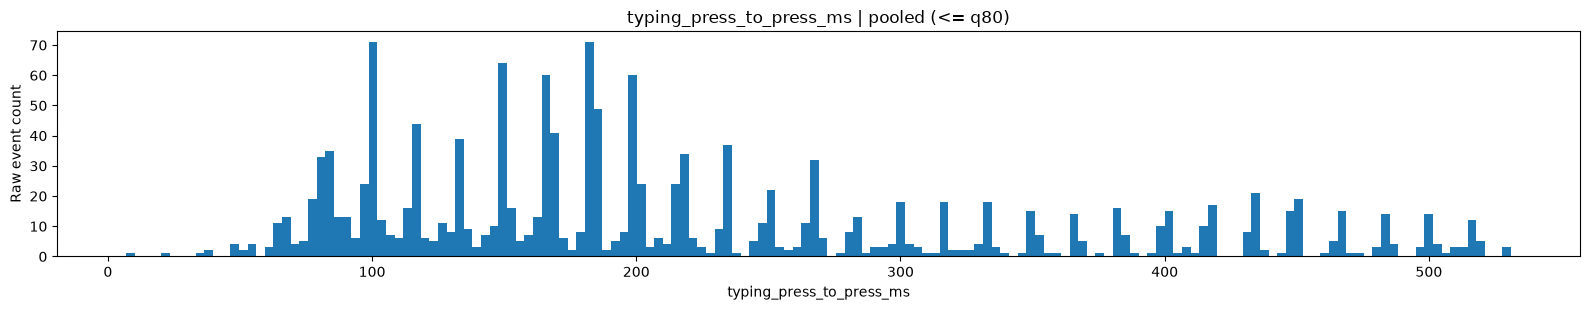

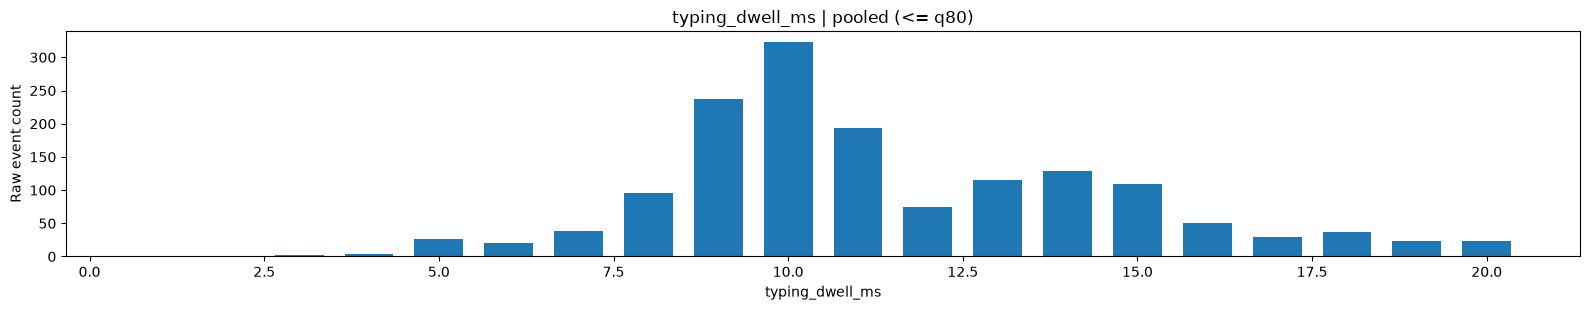

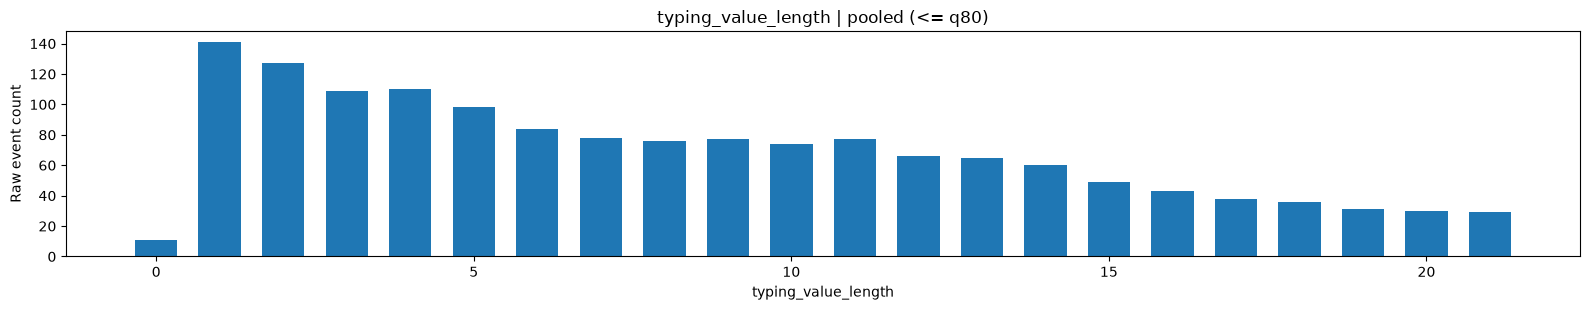

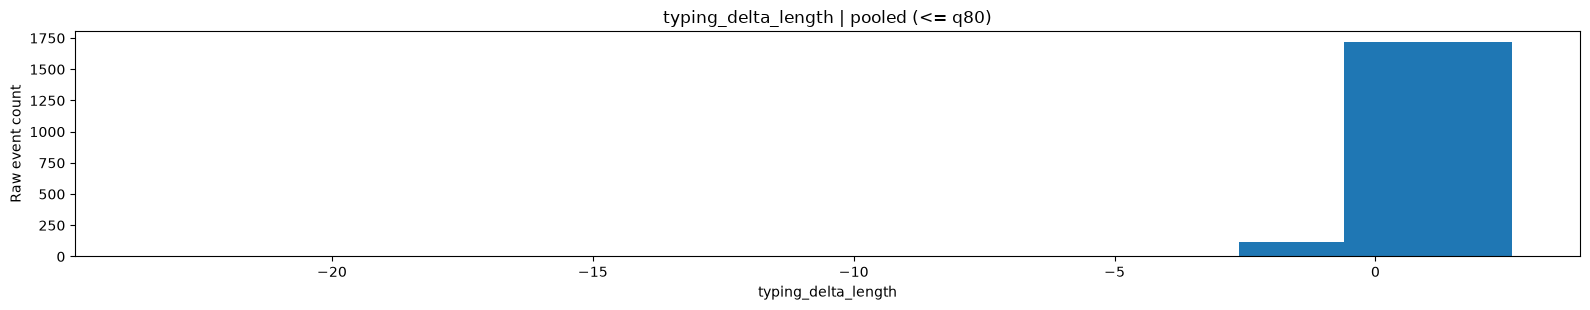

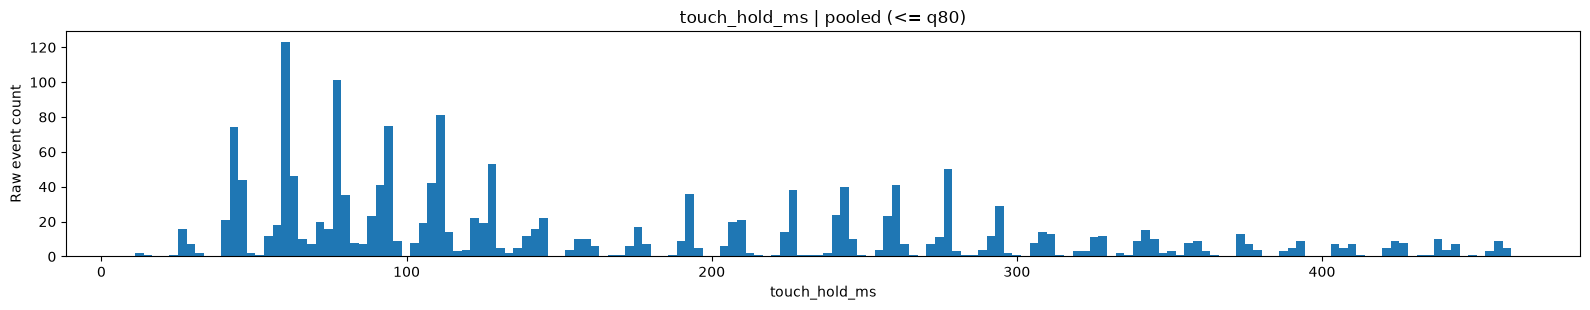

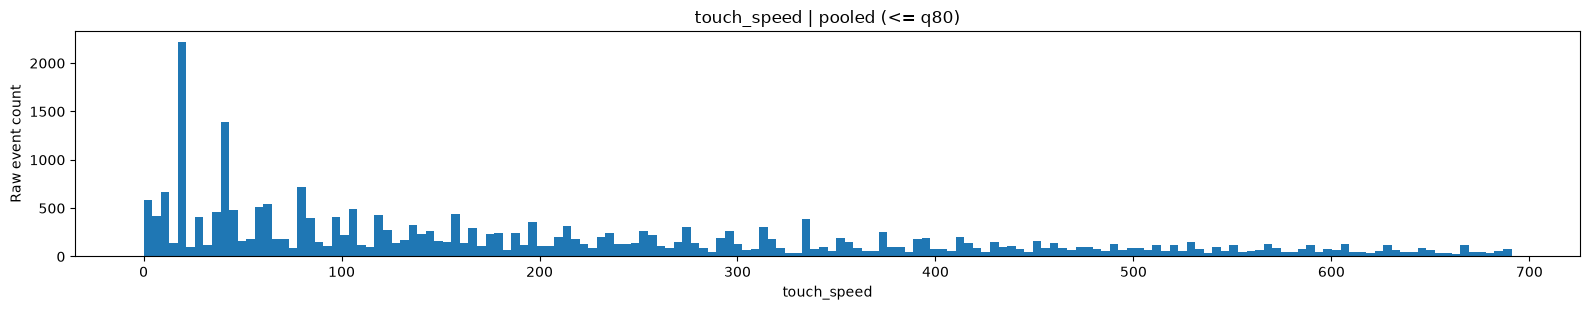

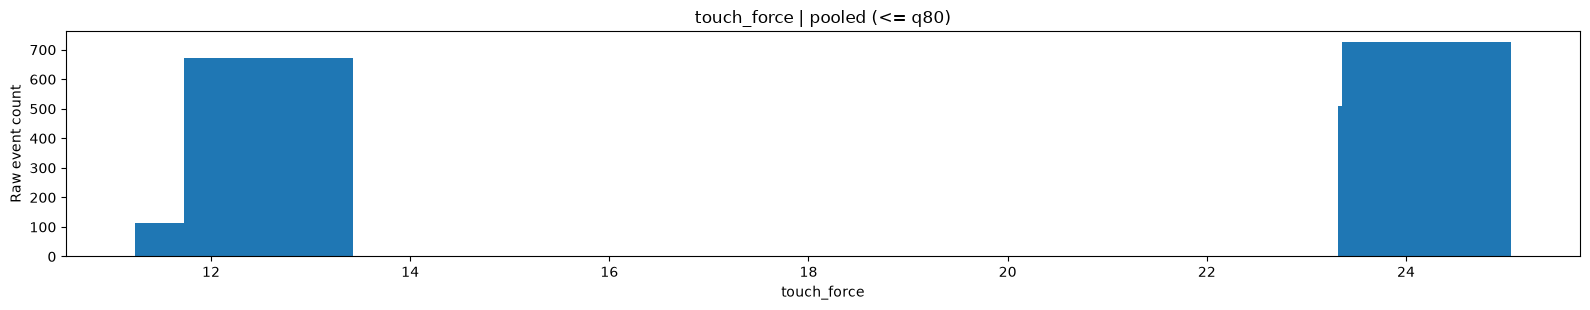

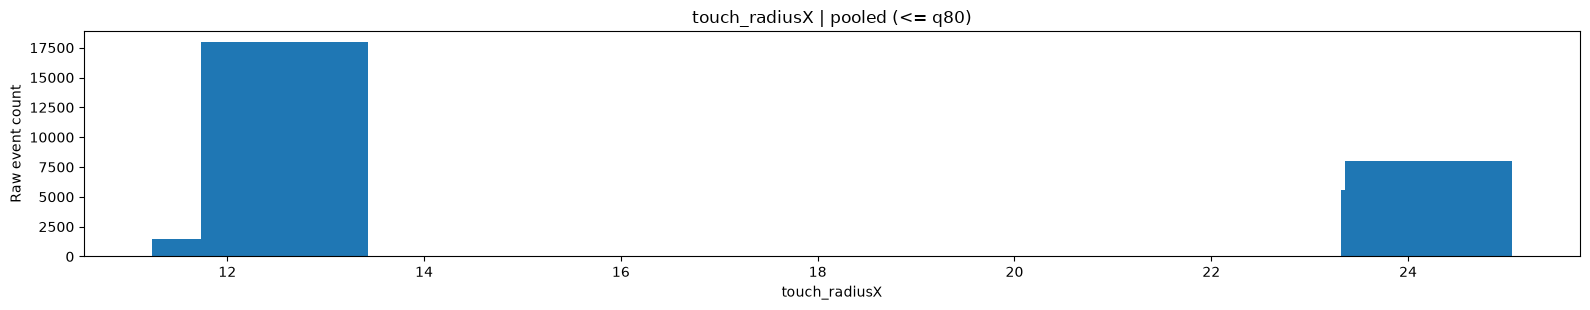

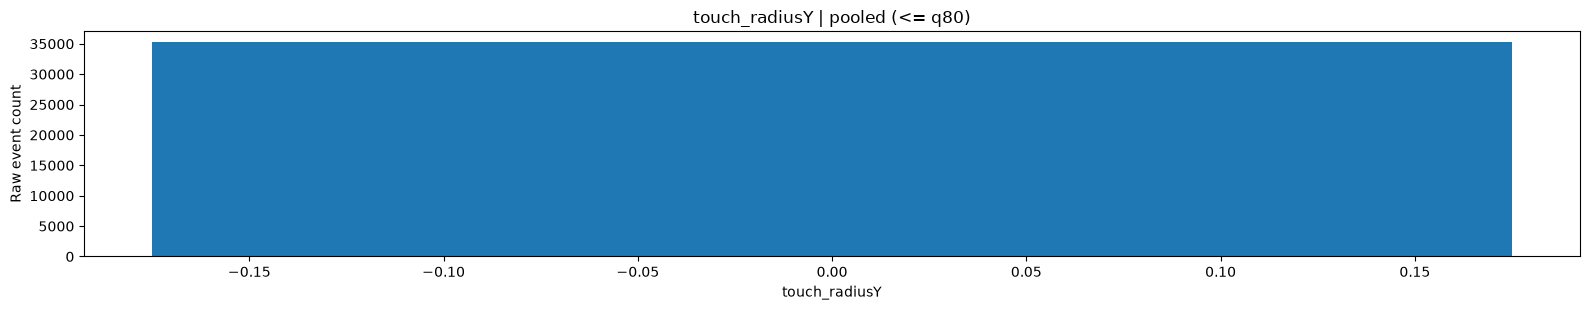

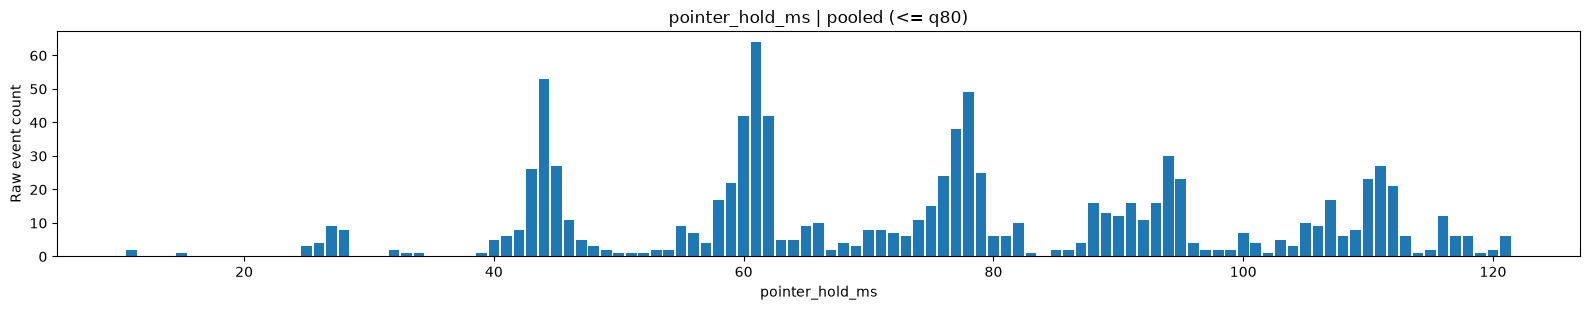

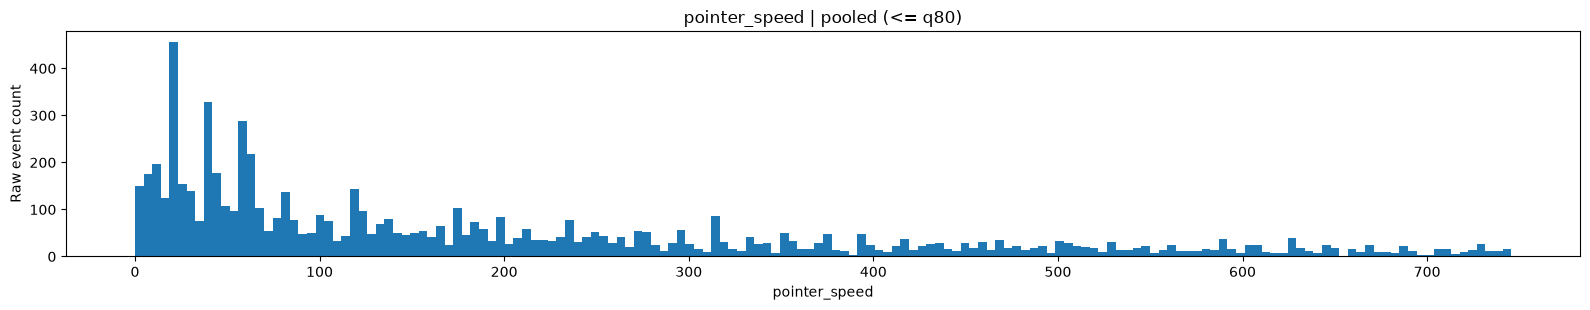

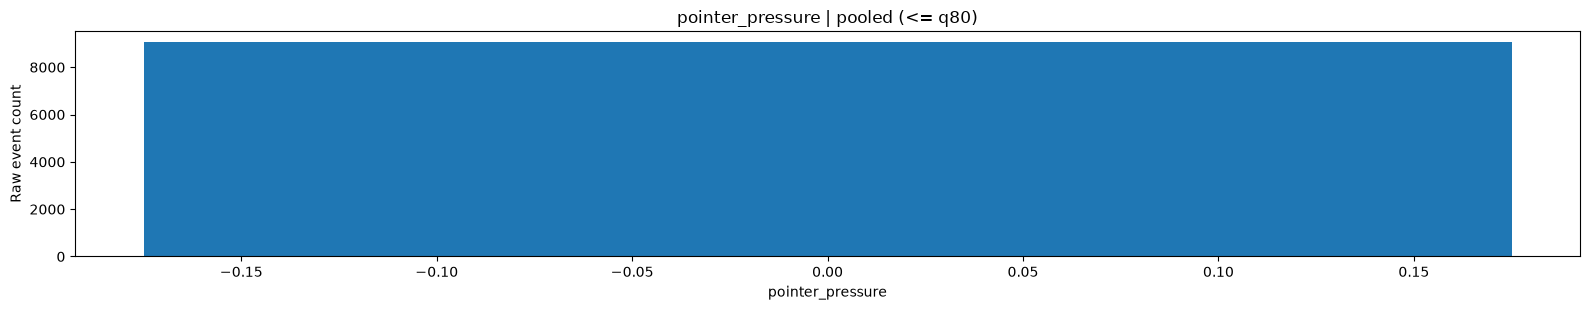

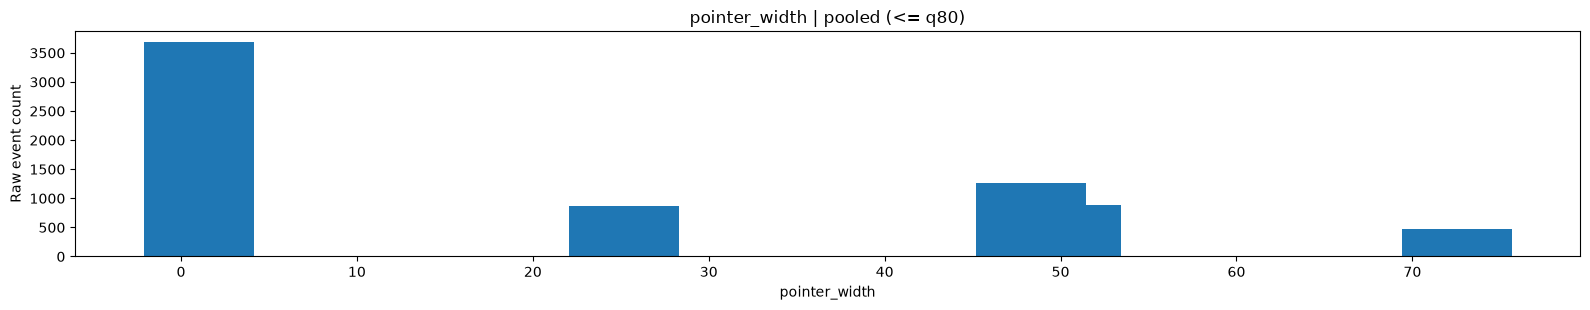

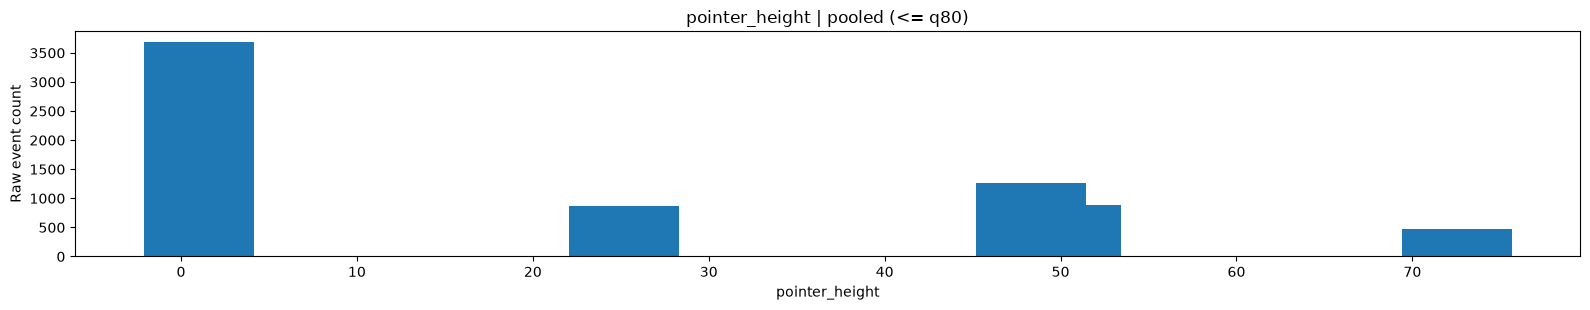

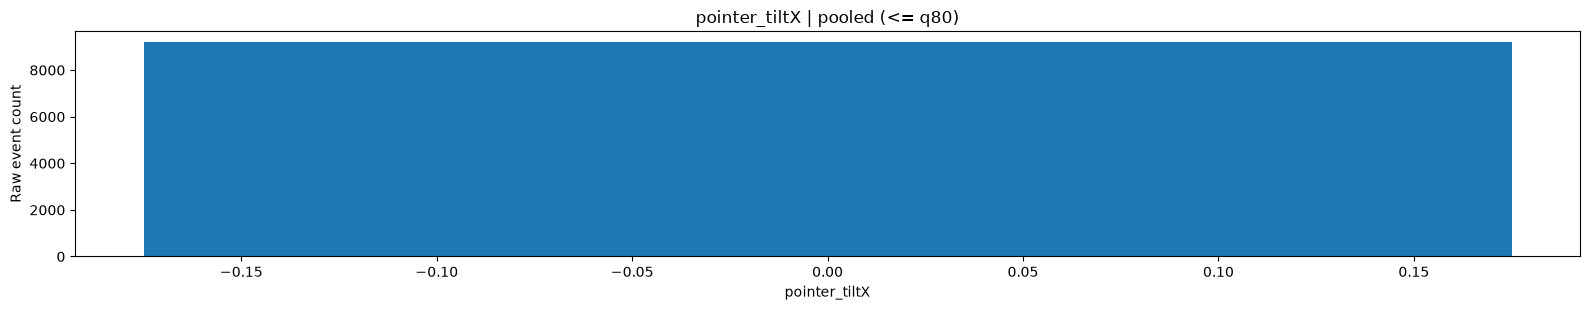

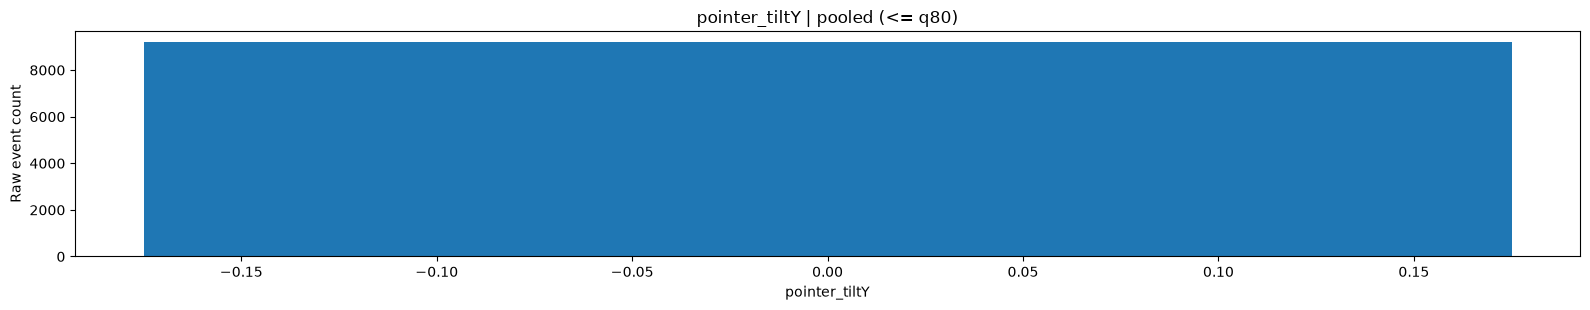

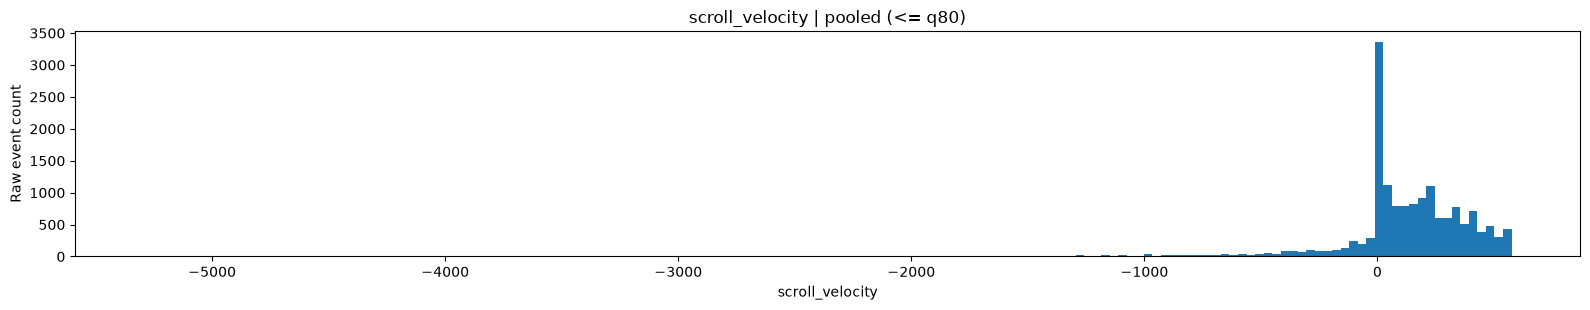

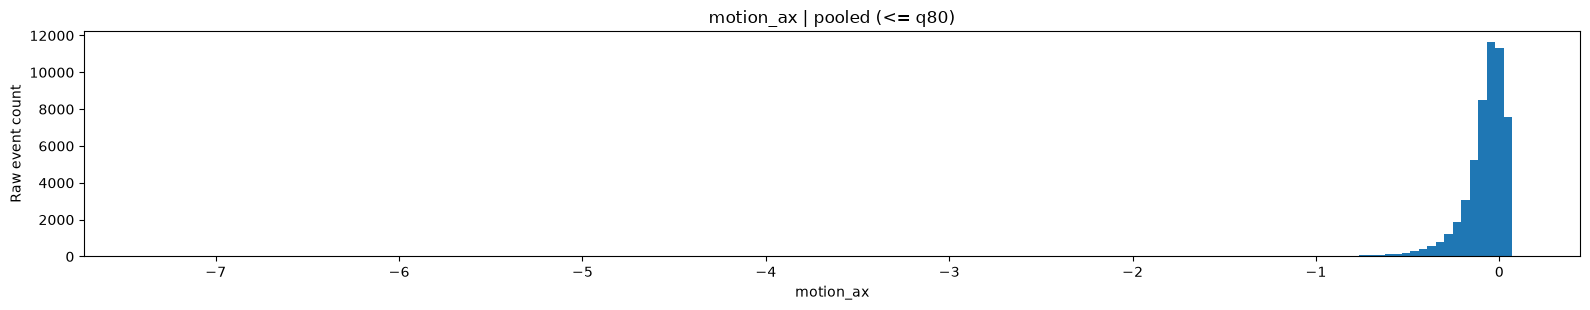

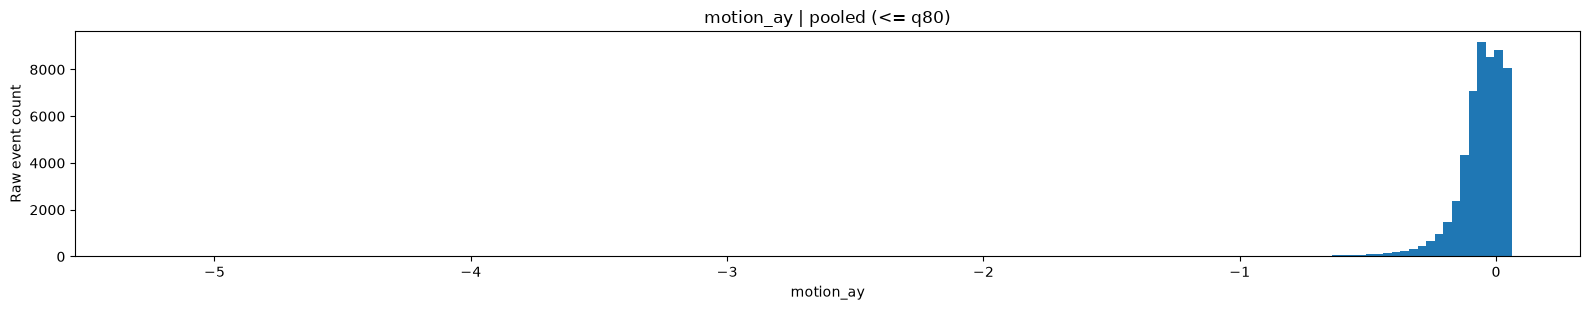

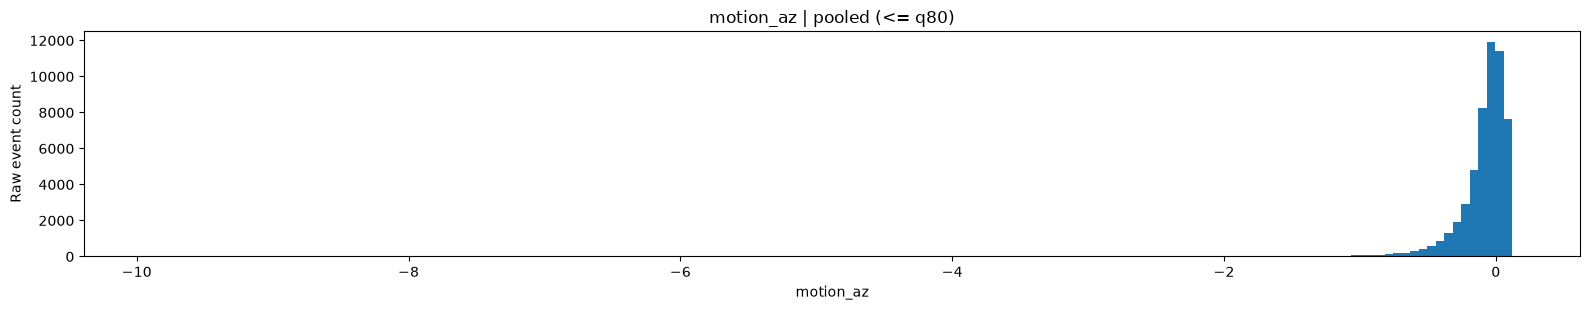

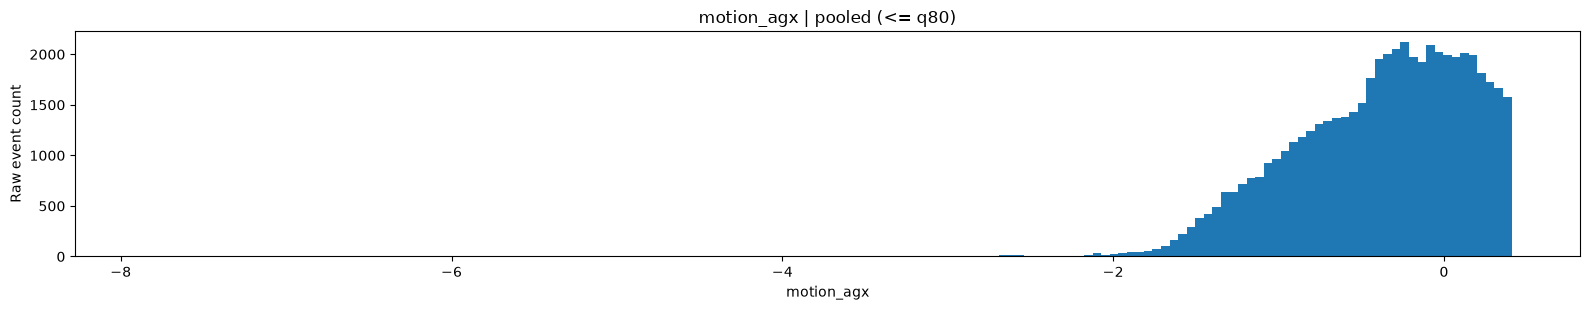

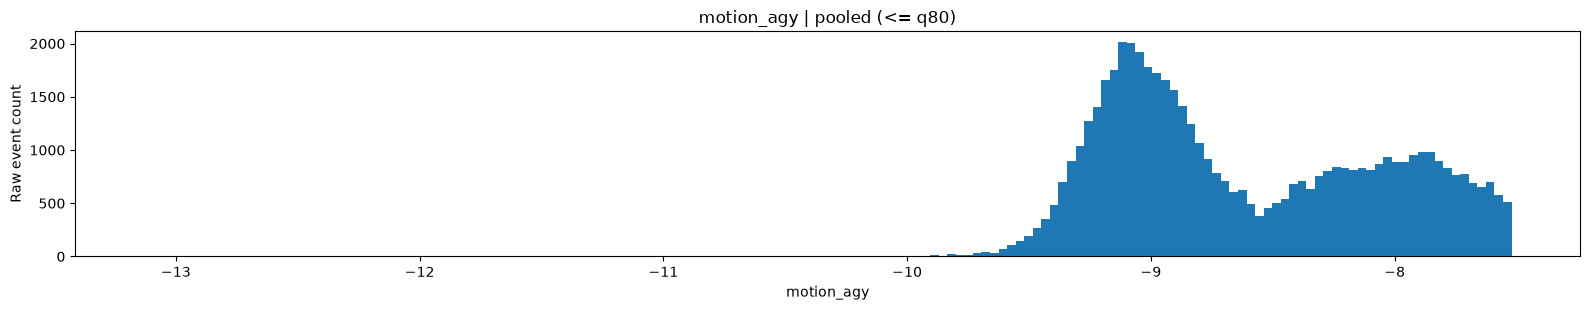

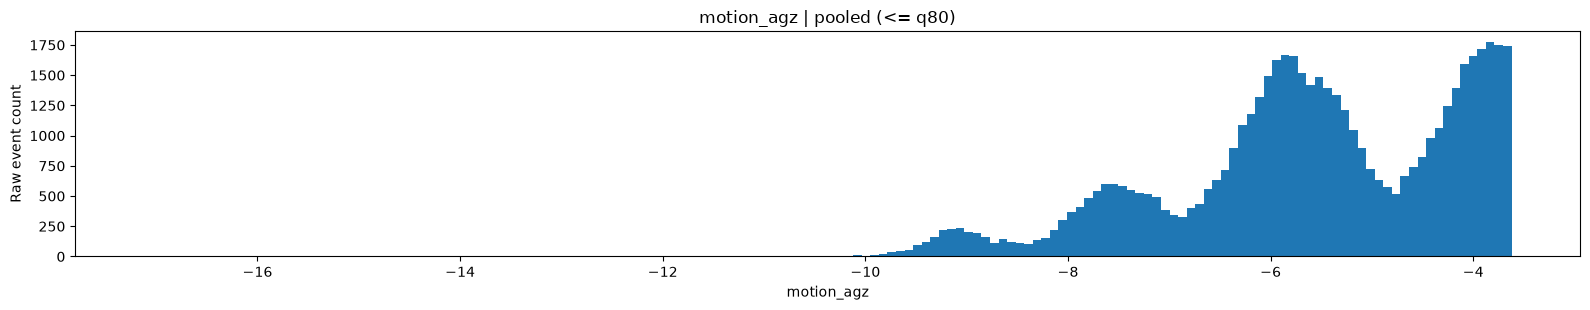

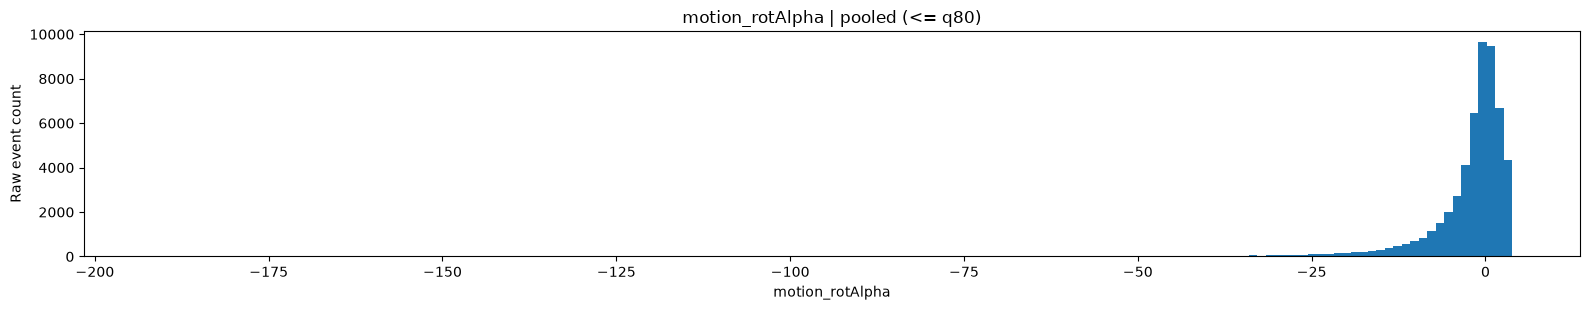

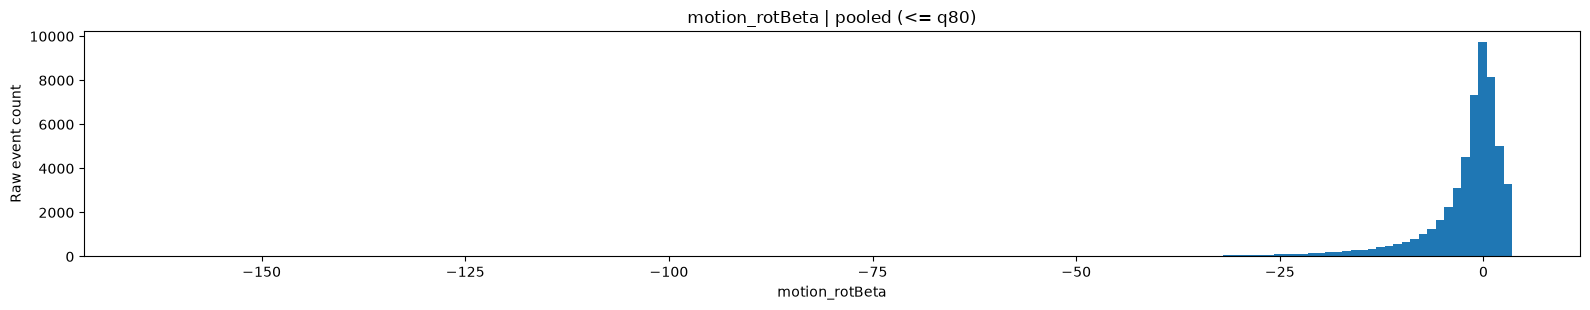

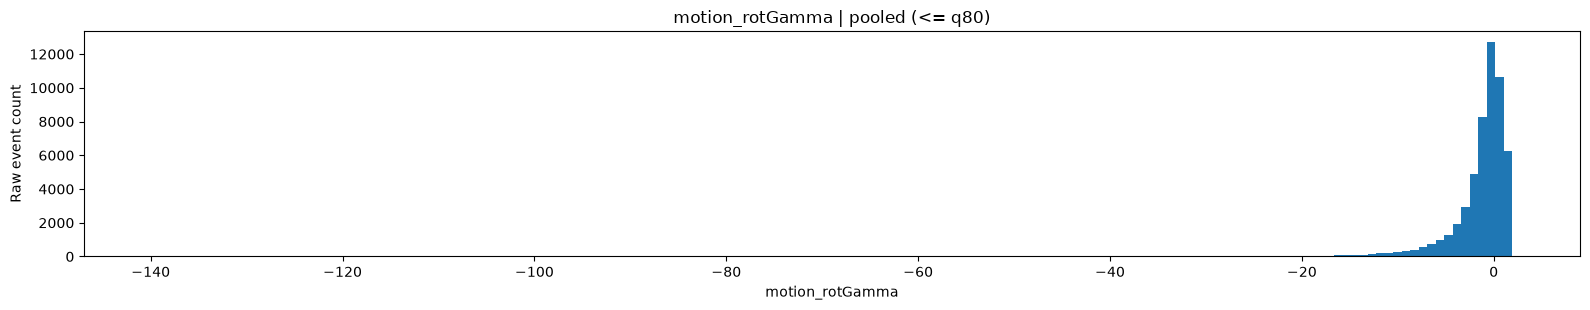

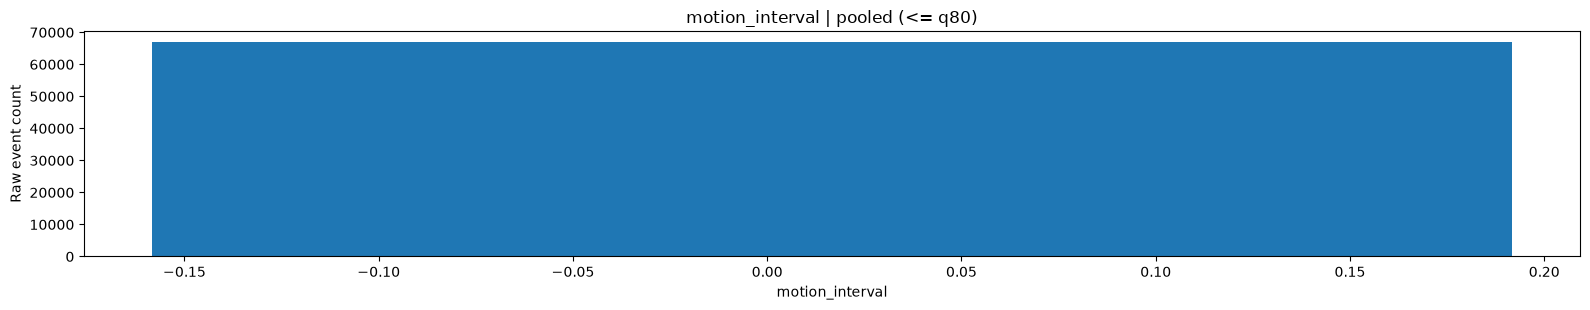

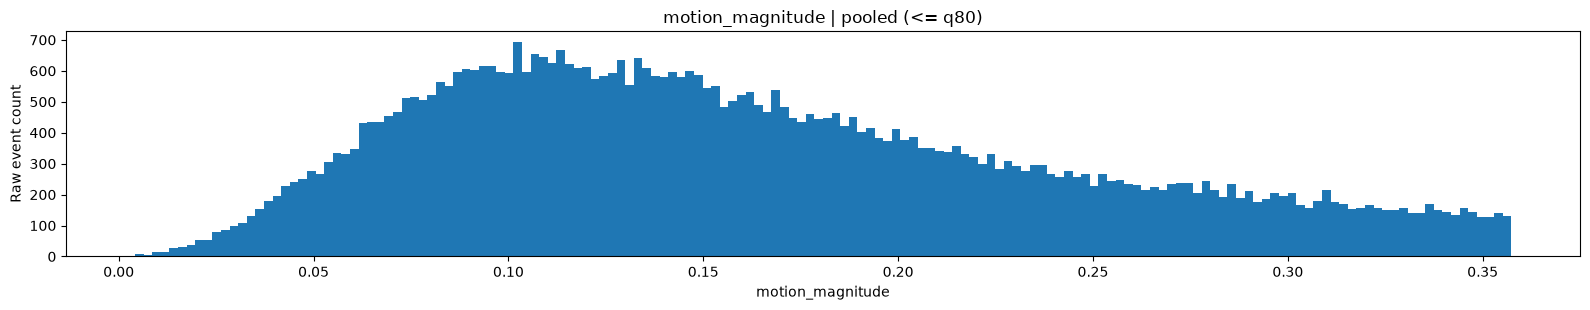

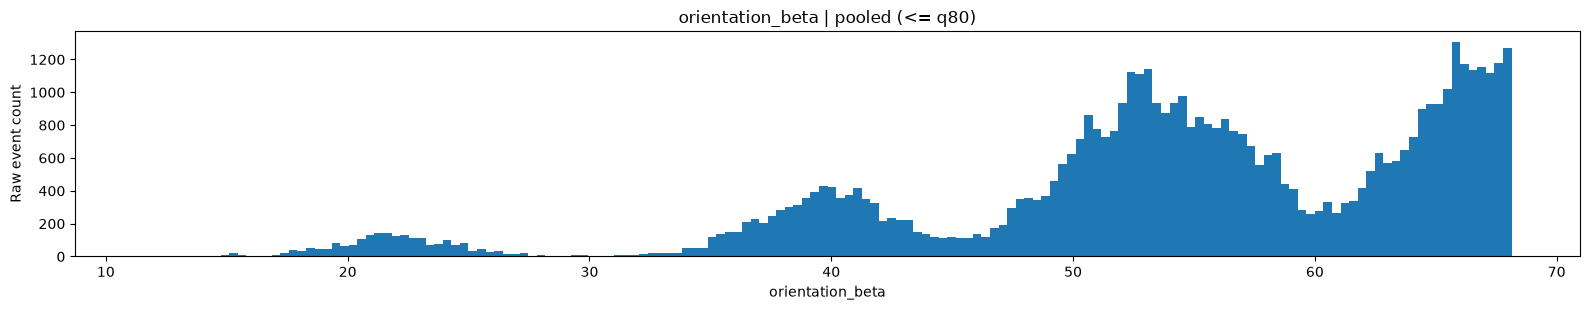

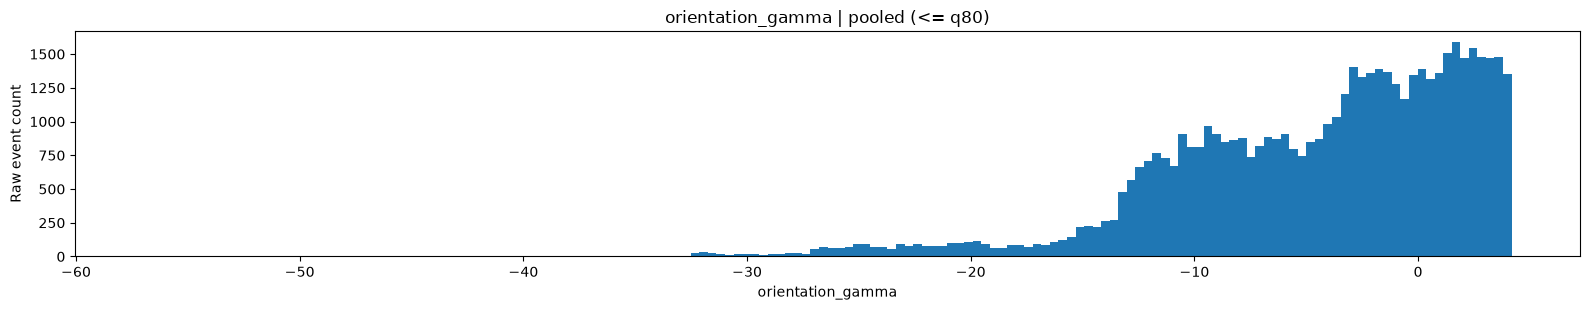

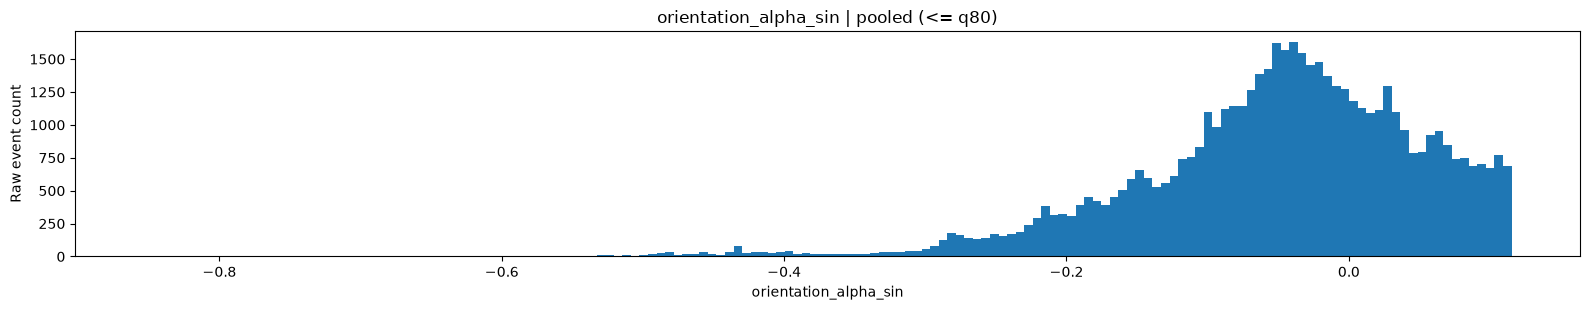

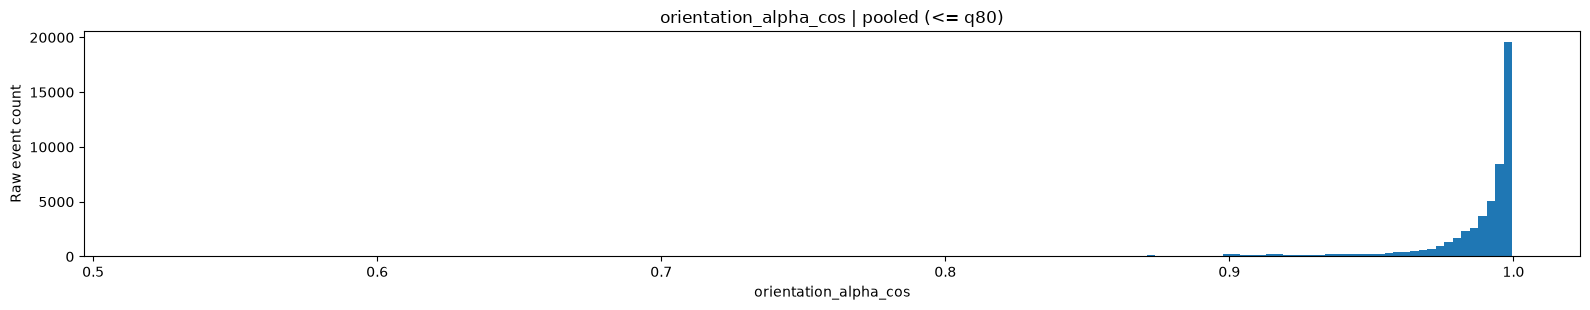

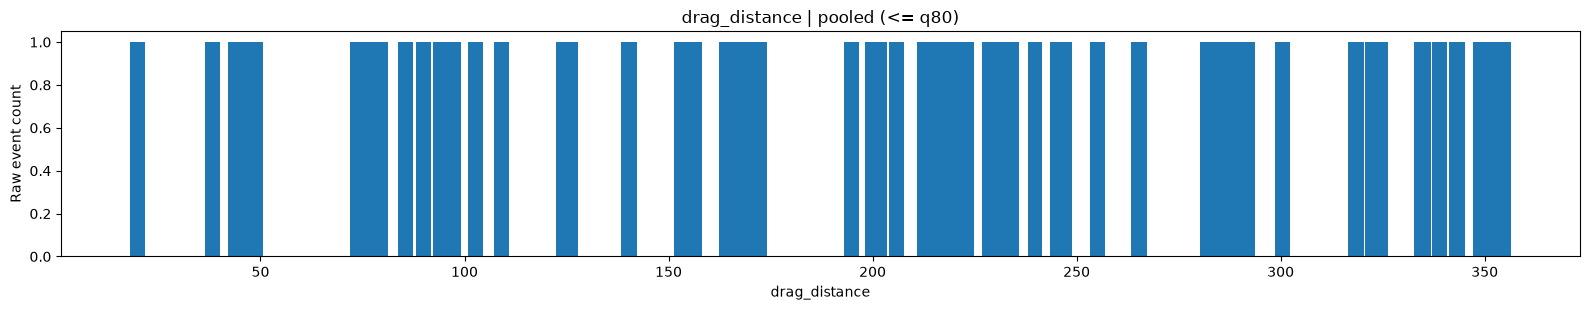

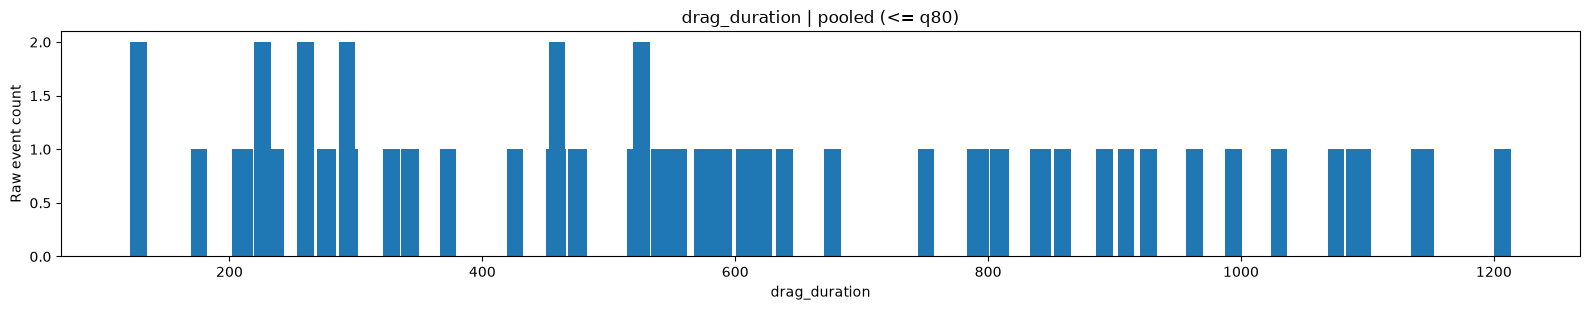

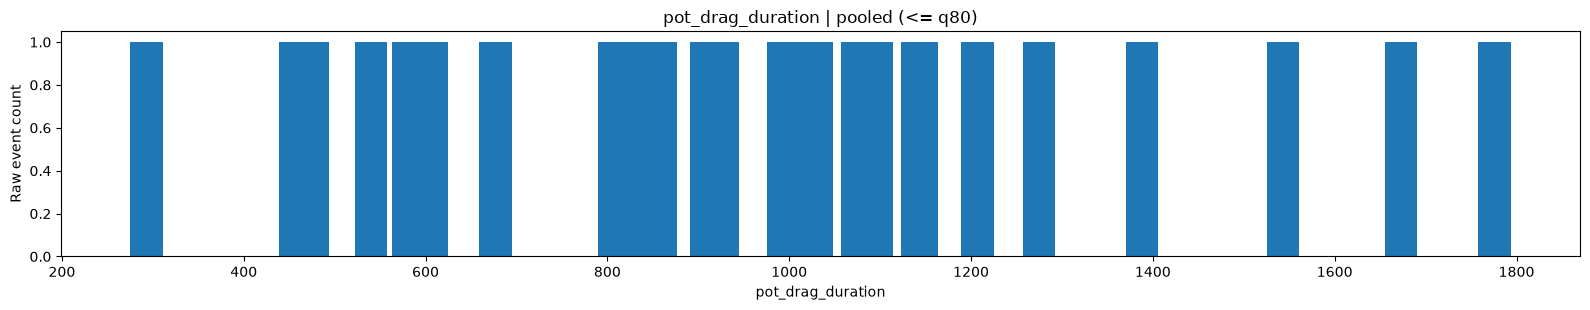

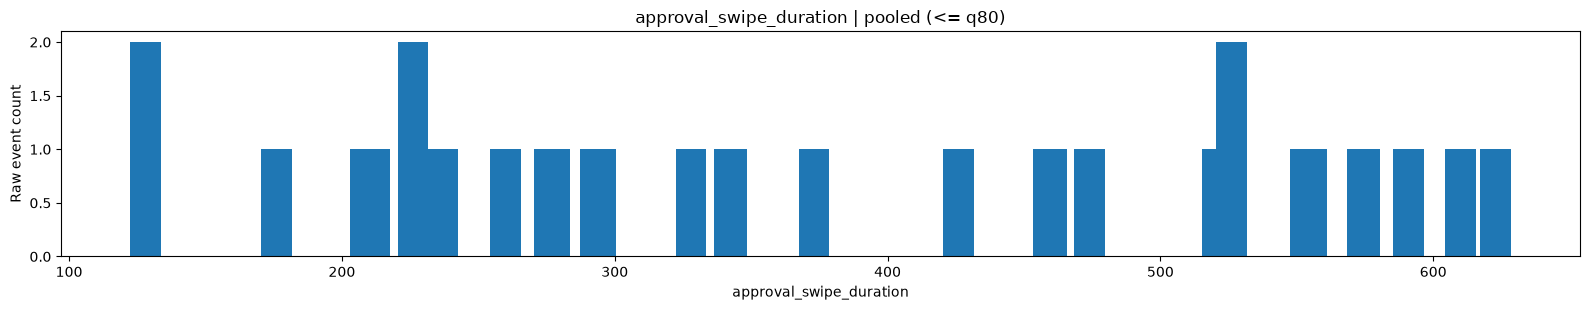

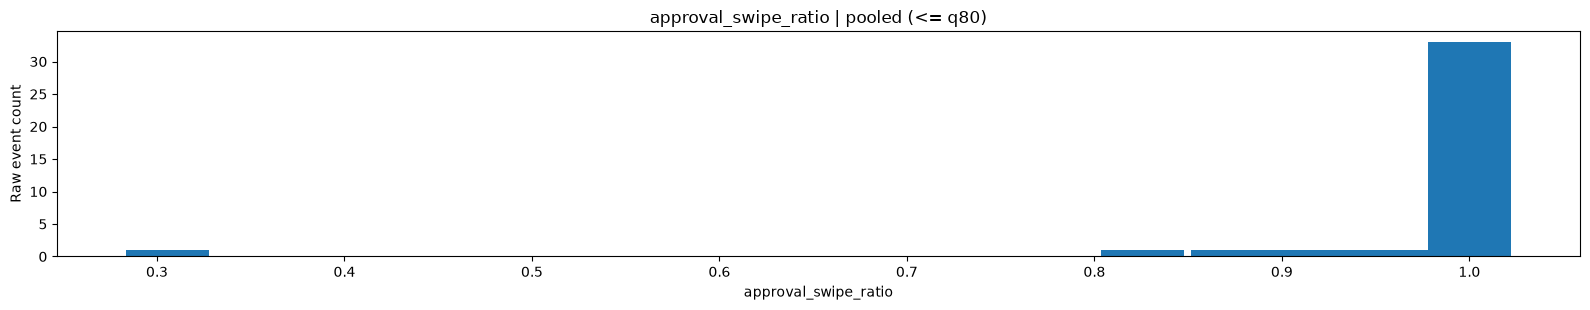

In [7]:
FEATURE_FAMILY = "all"   # change to any family in FAMILIES, or "all"
SELECTED = FAMILIES if FEATURE_FAMILY == "all" else [FEATURE_FAMILY]
metrics_in_scope = raw_metric_df.loc[raw_metric_df['family'].isin(SELECTED), 'metric'].unique().tolist()
print("Metrics in scope:", metrics_in_scope)

for m in metrics_in_scope:
    plot_metric_pooled(raw_metric_df, m)

## Participant split — replaces the device-family view

Same stacked-panel style as before (filled bars, one panel per group, shared x-axis for
direct comparison) — but grouped by **participant** instead of device family, since
that's the comparison this project actually cares about. Each participant gets a
distinct colour; a participant with multiple sessions (`pA6XL23`) gets that same colour
in progressively lighter shades per session, so repeated-session consistency (or drift)
is visible within one panel rather than needing a separate view.

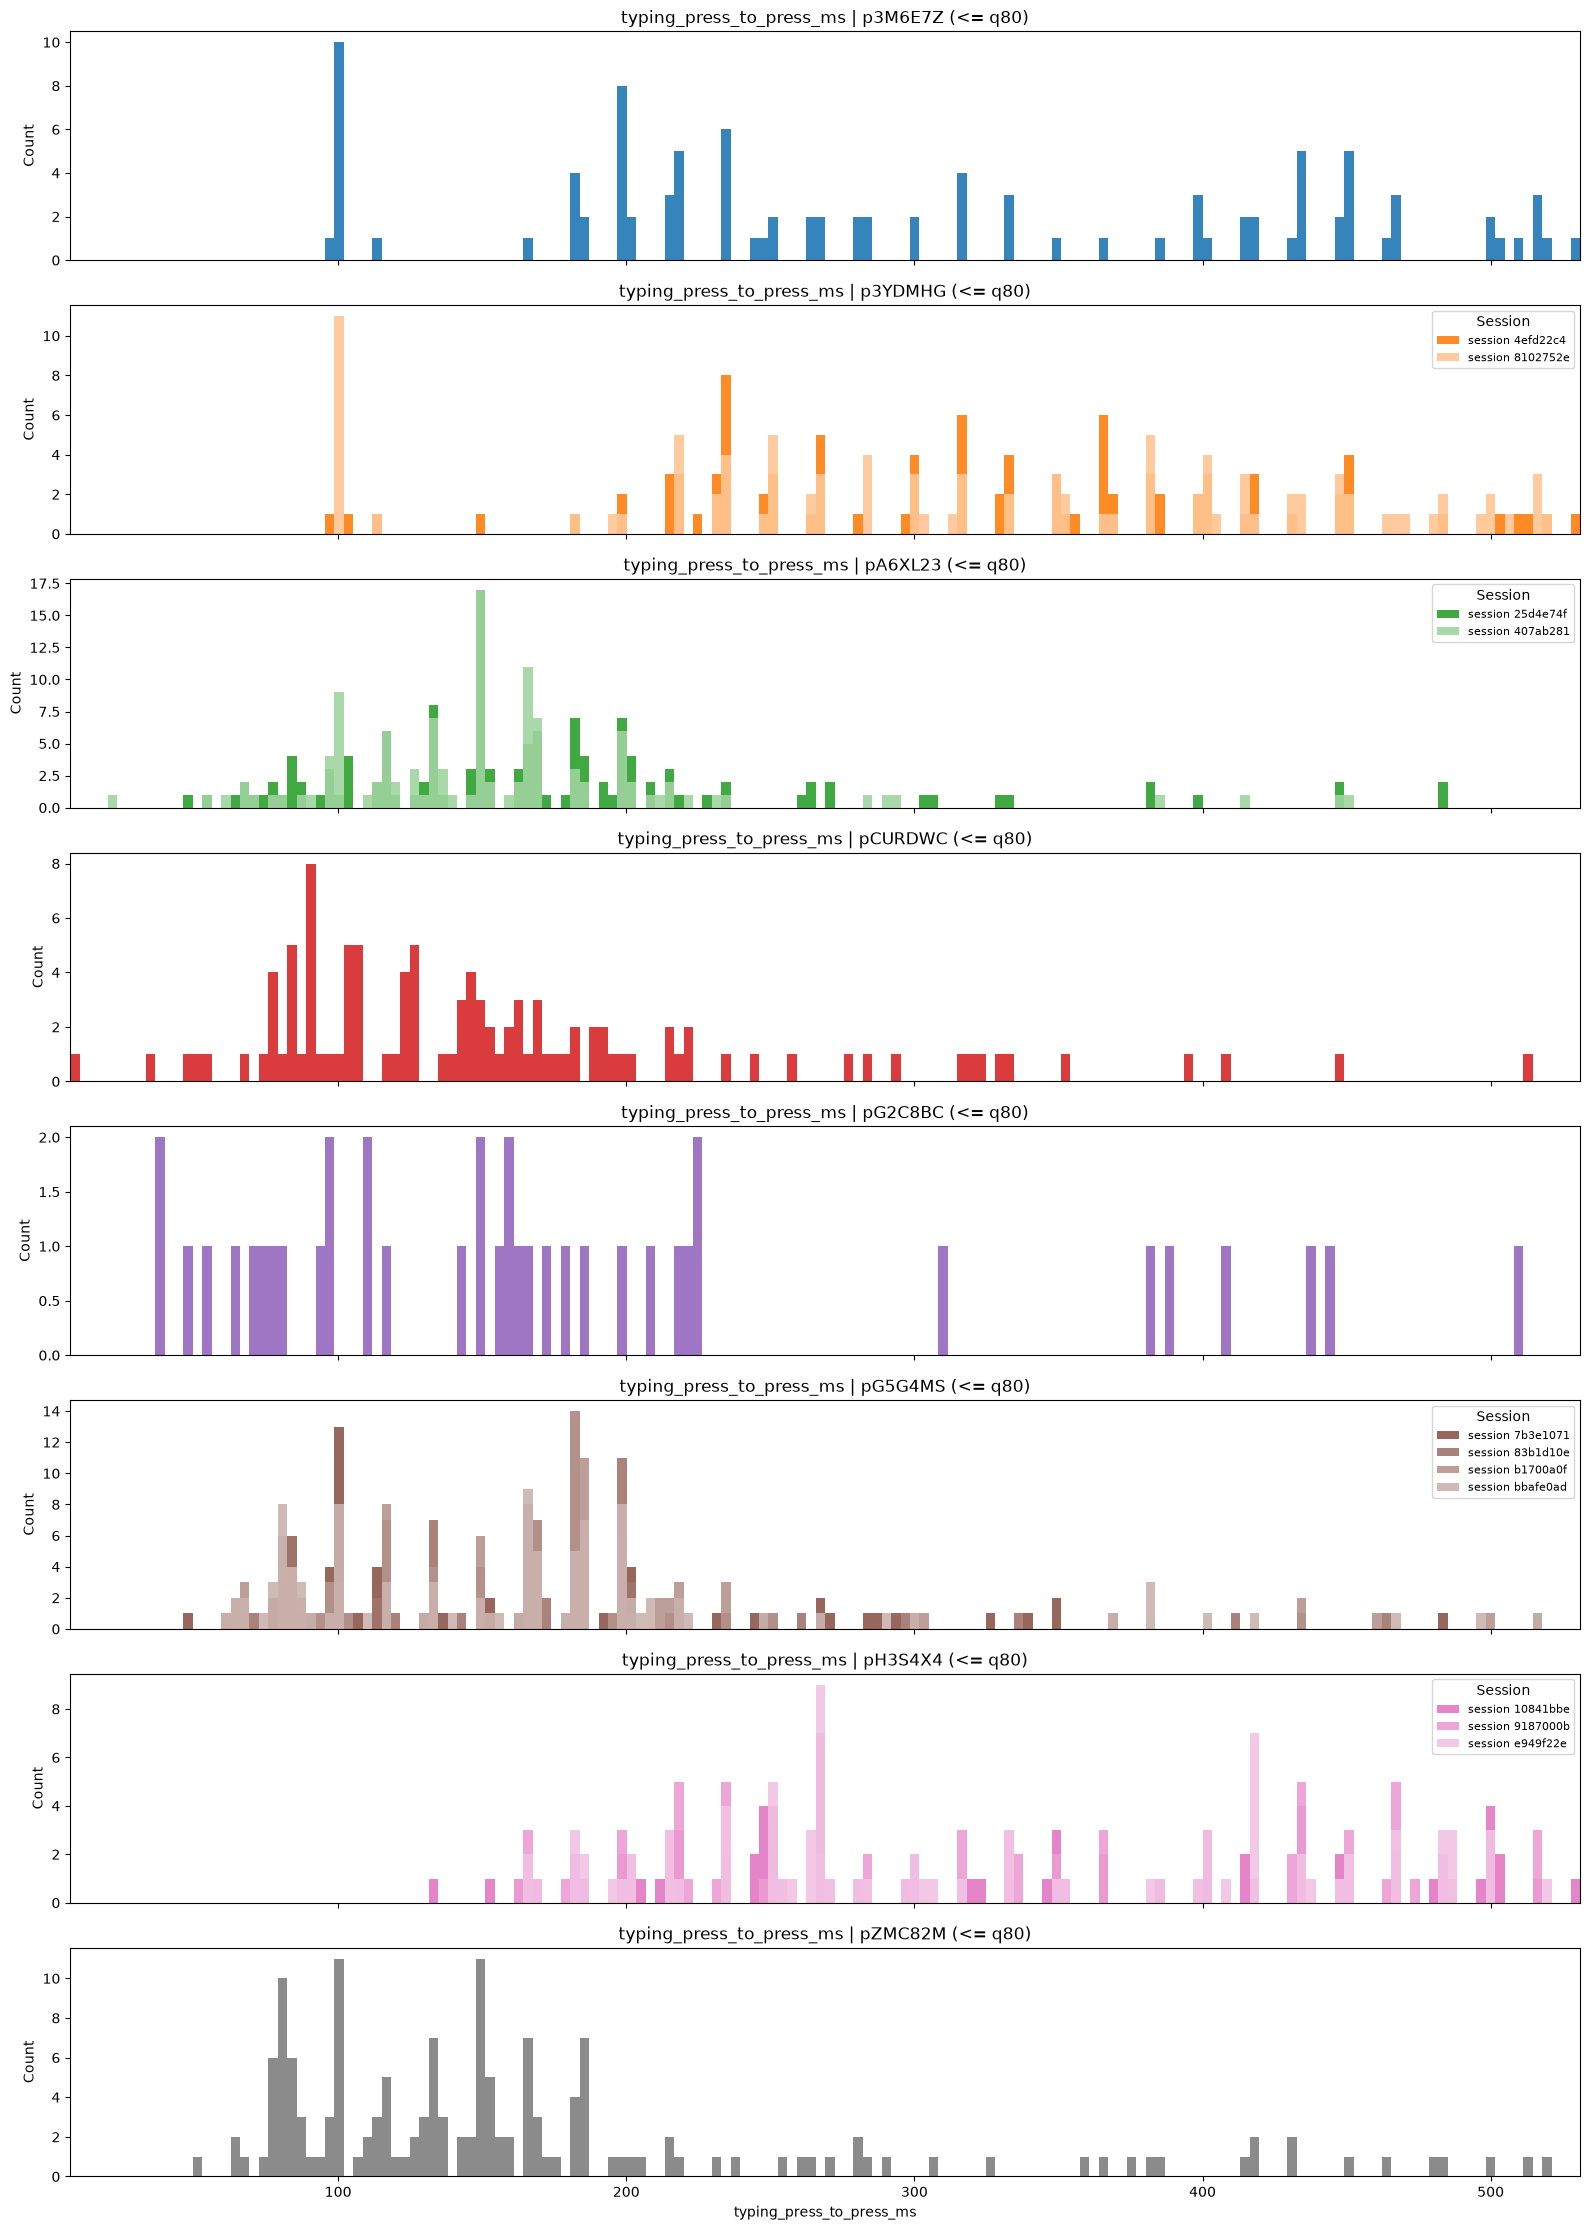

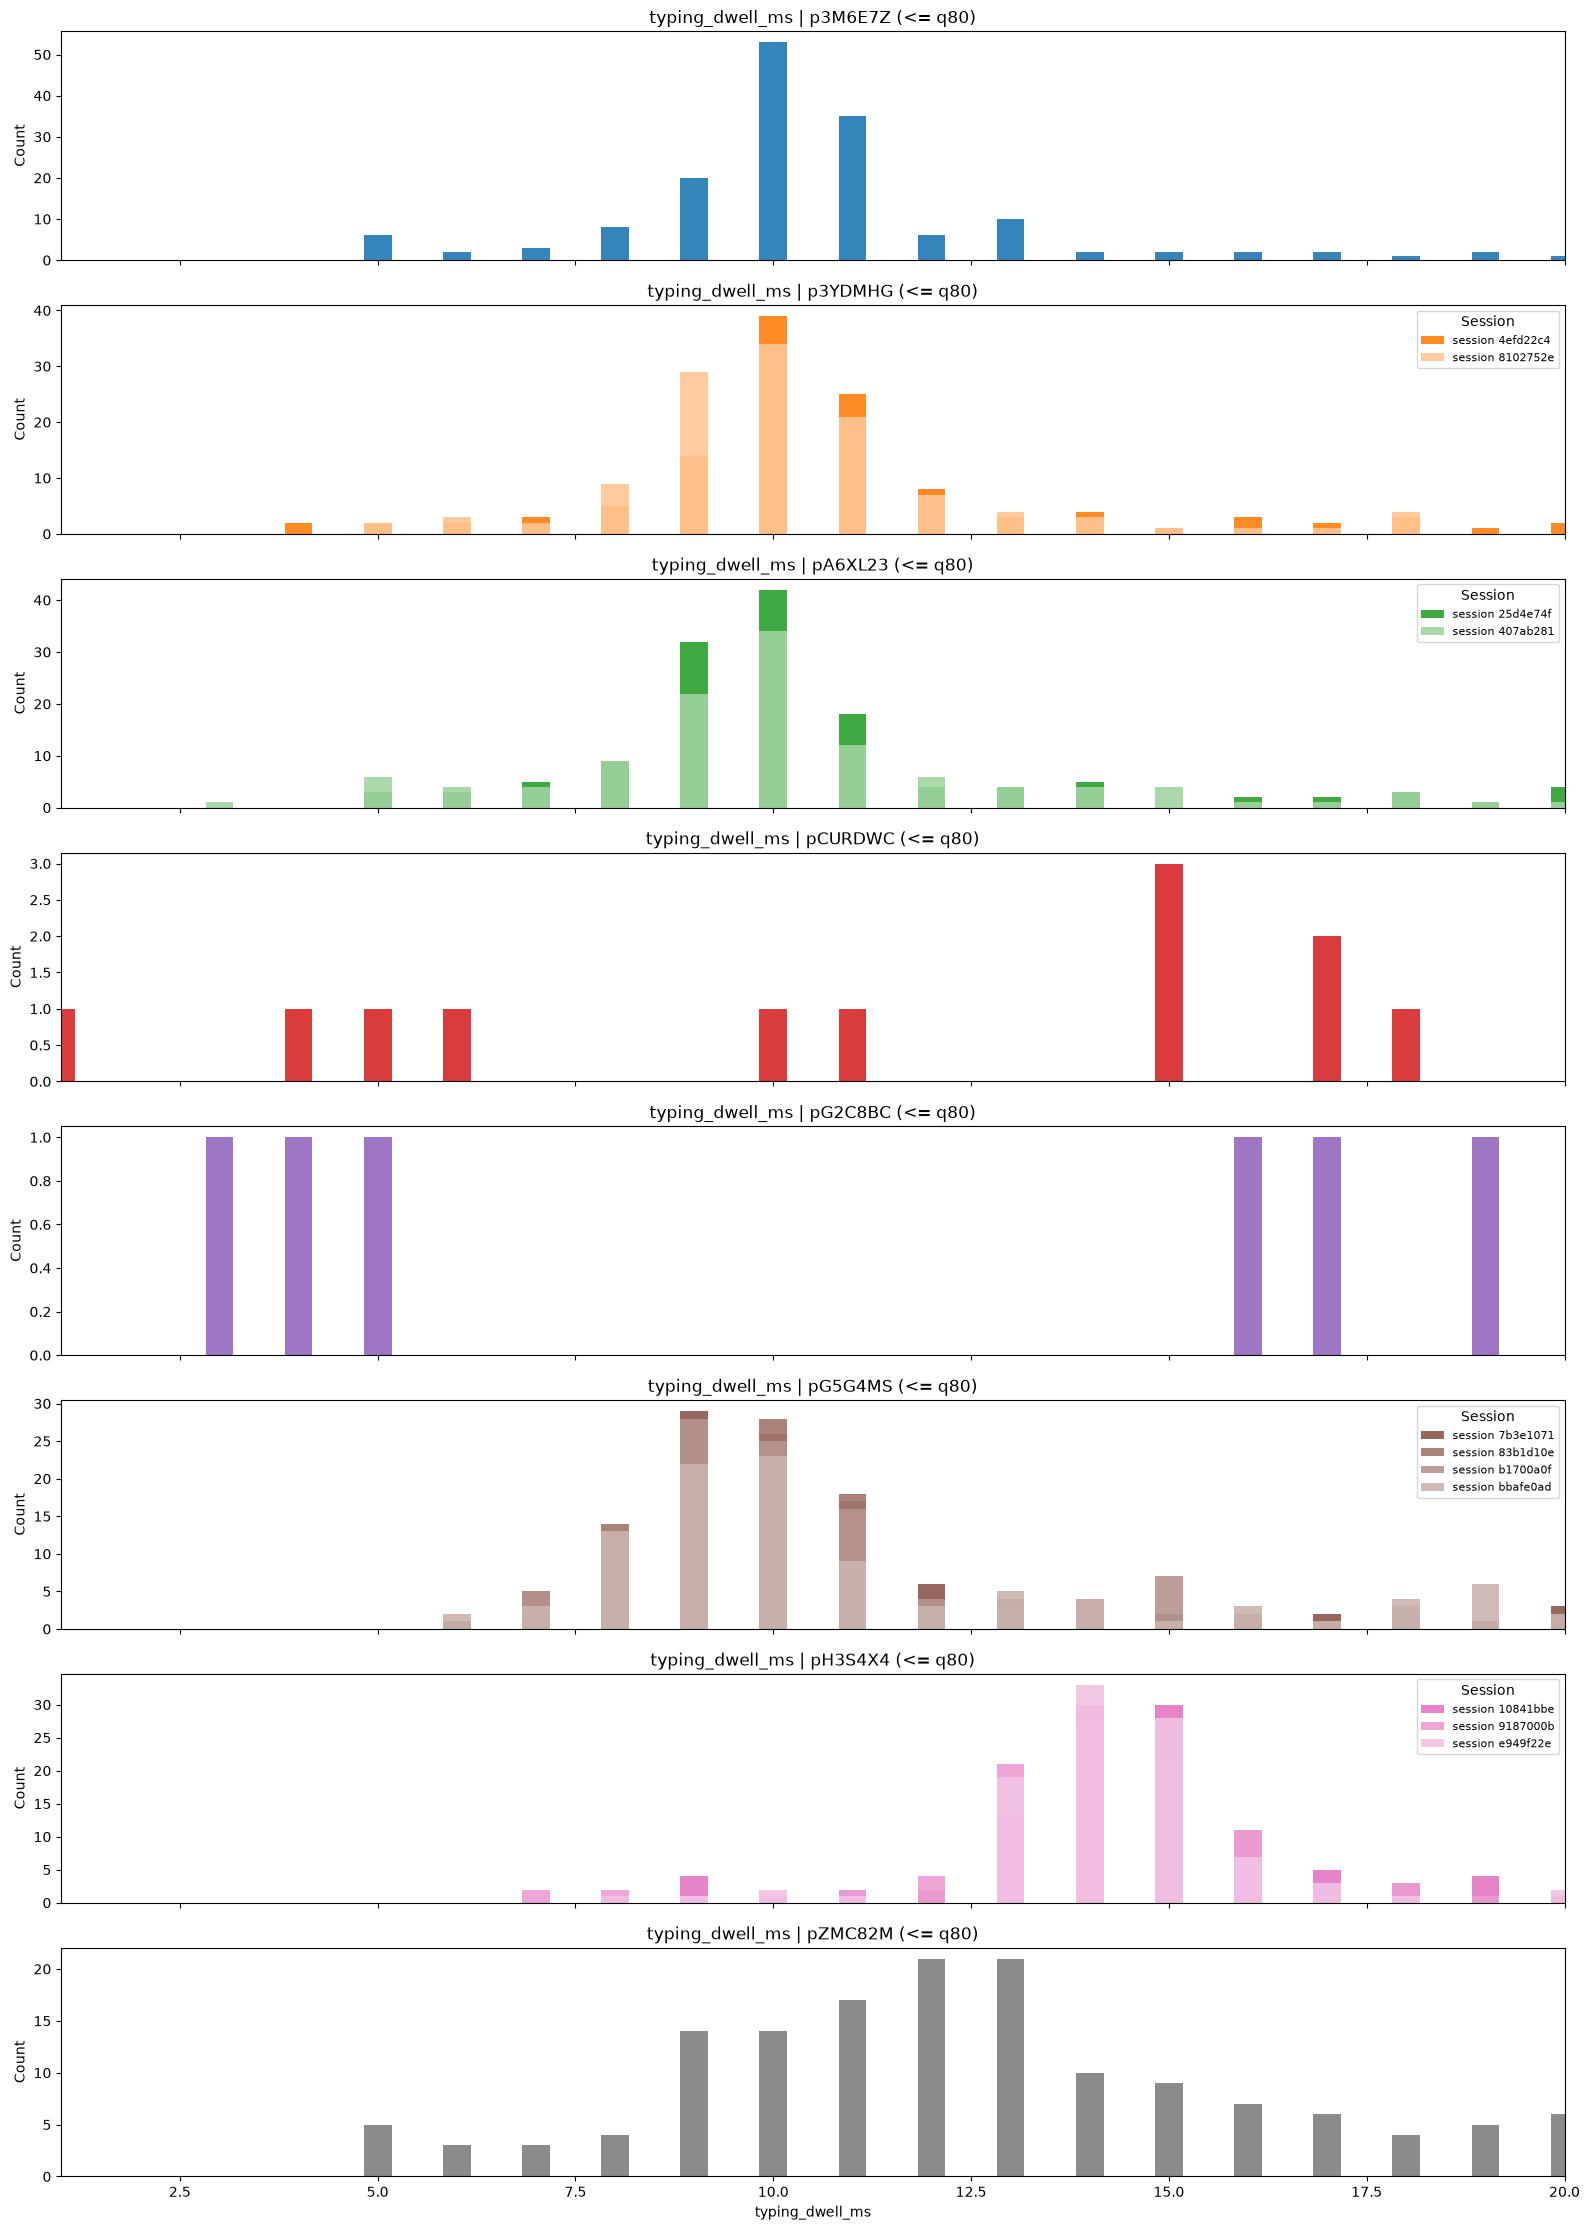

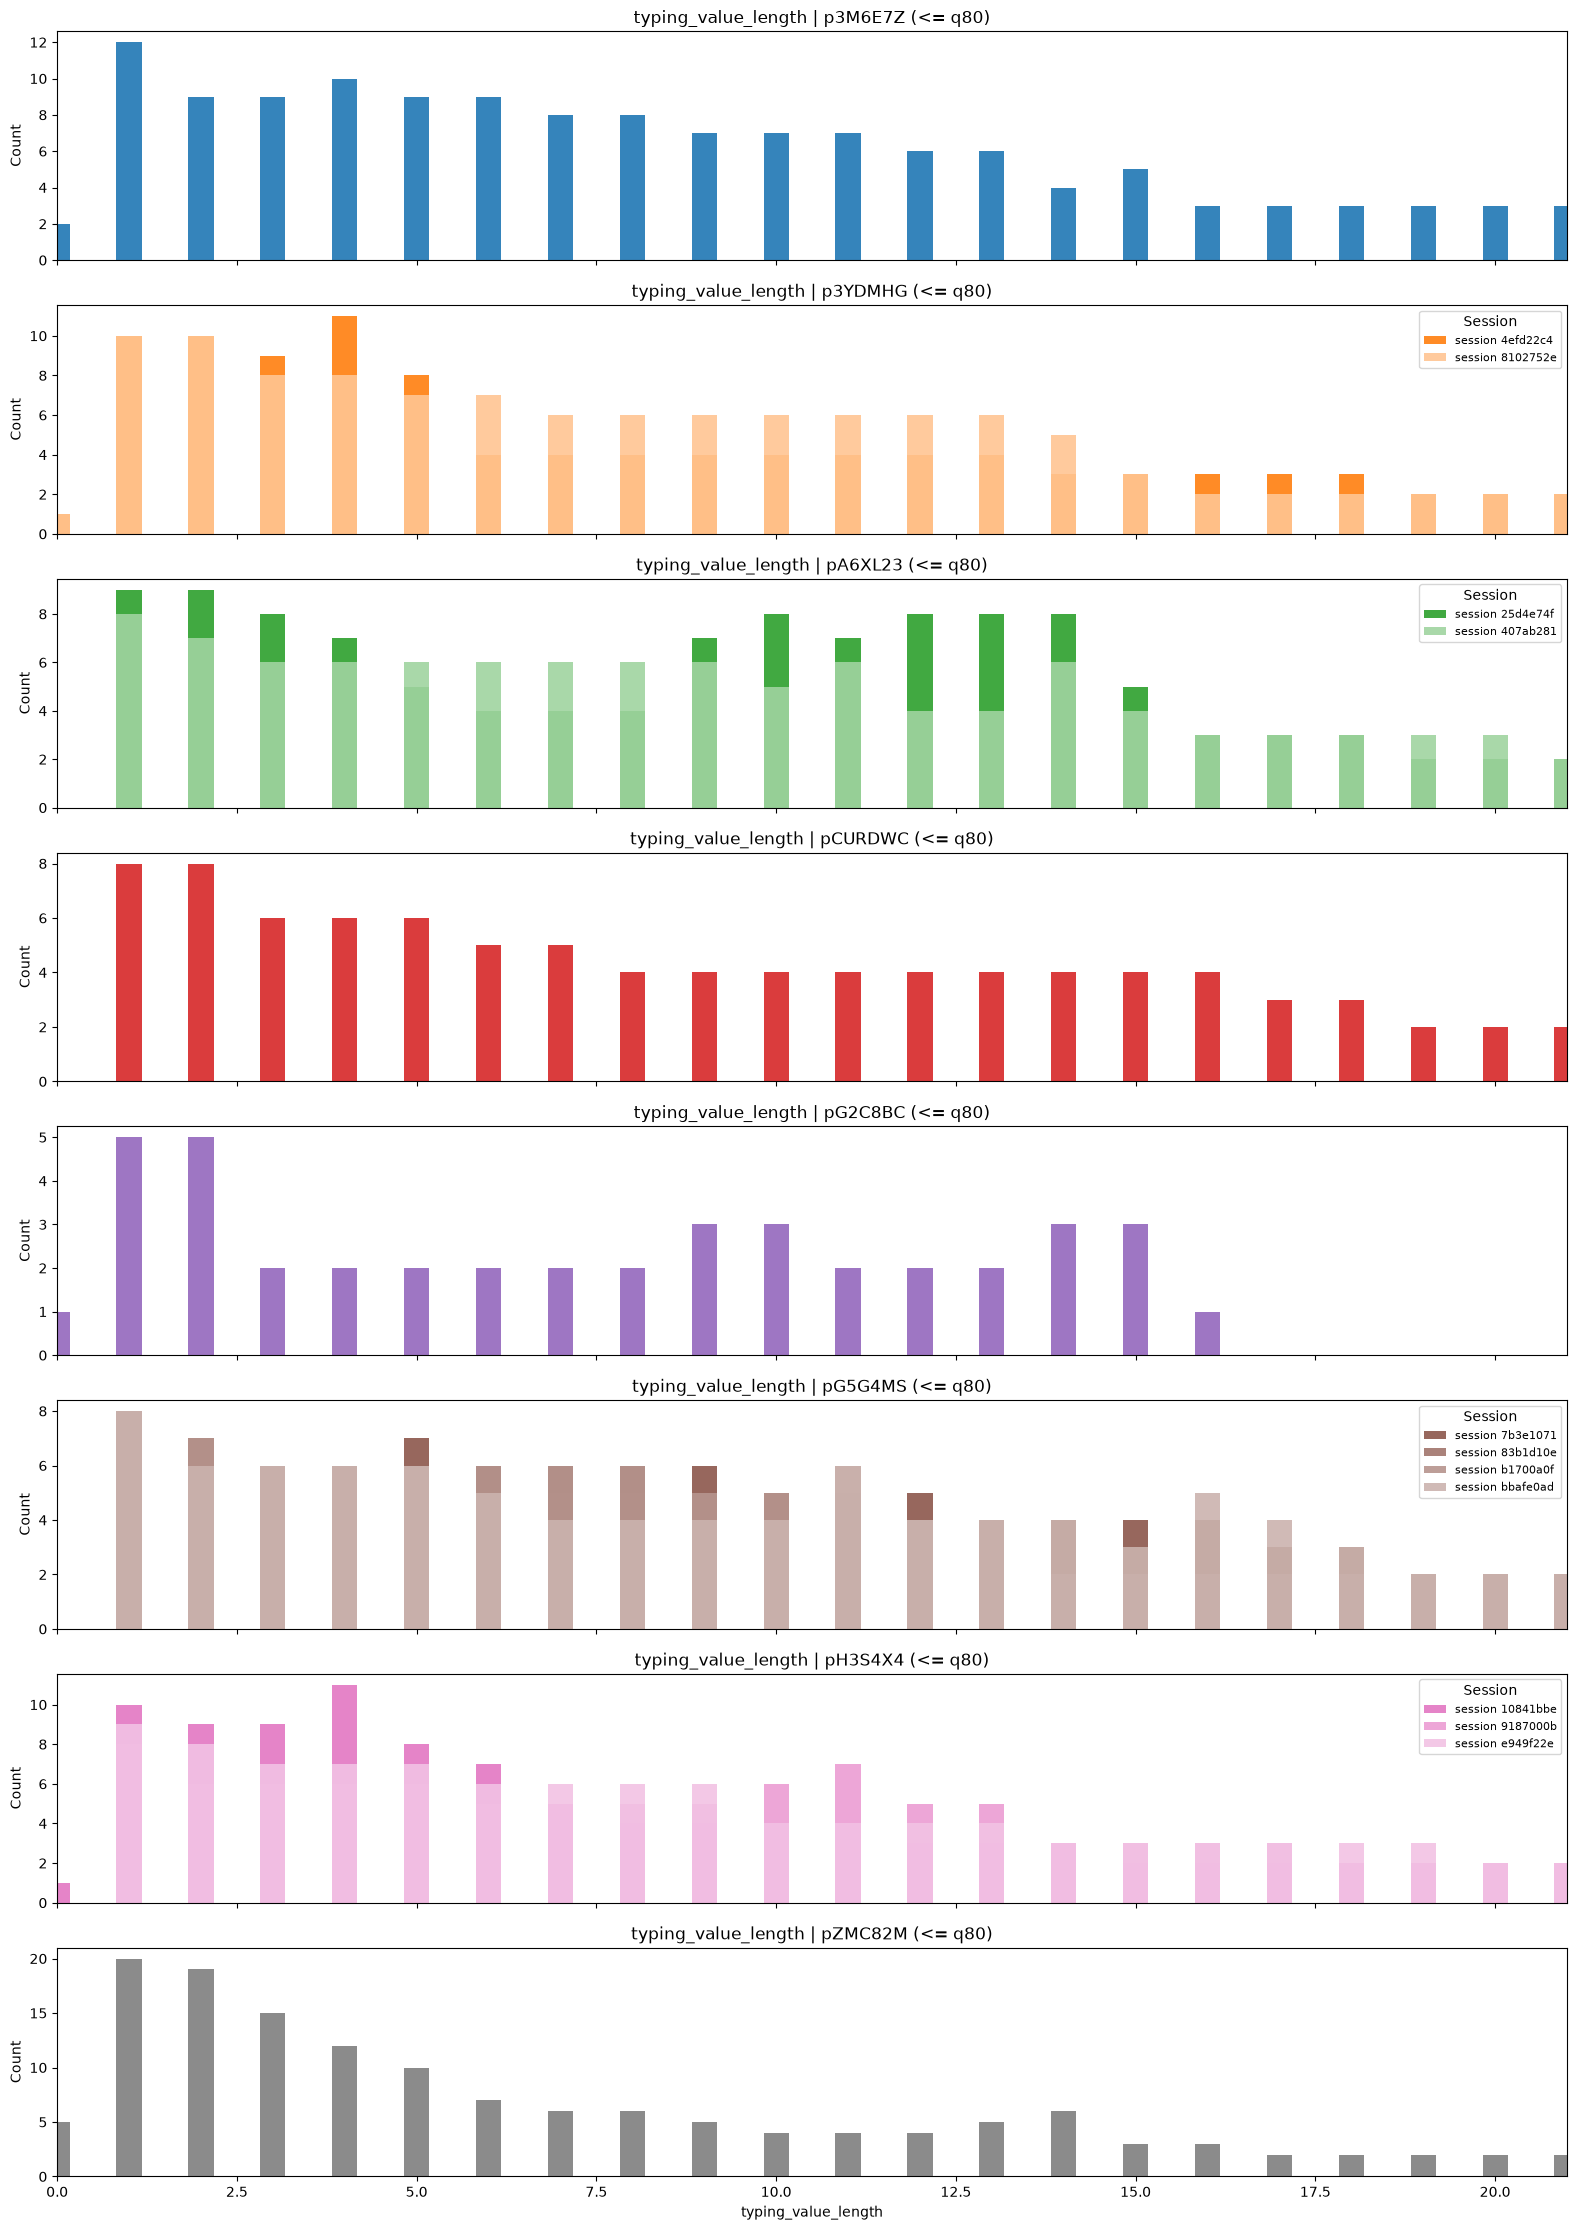

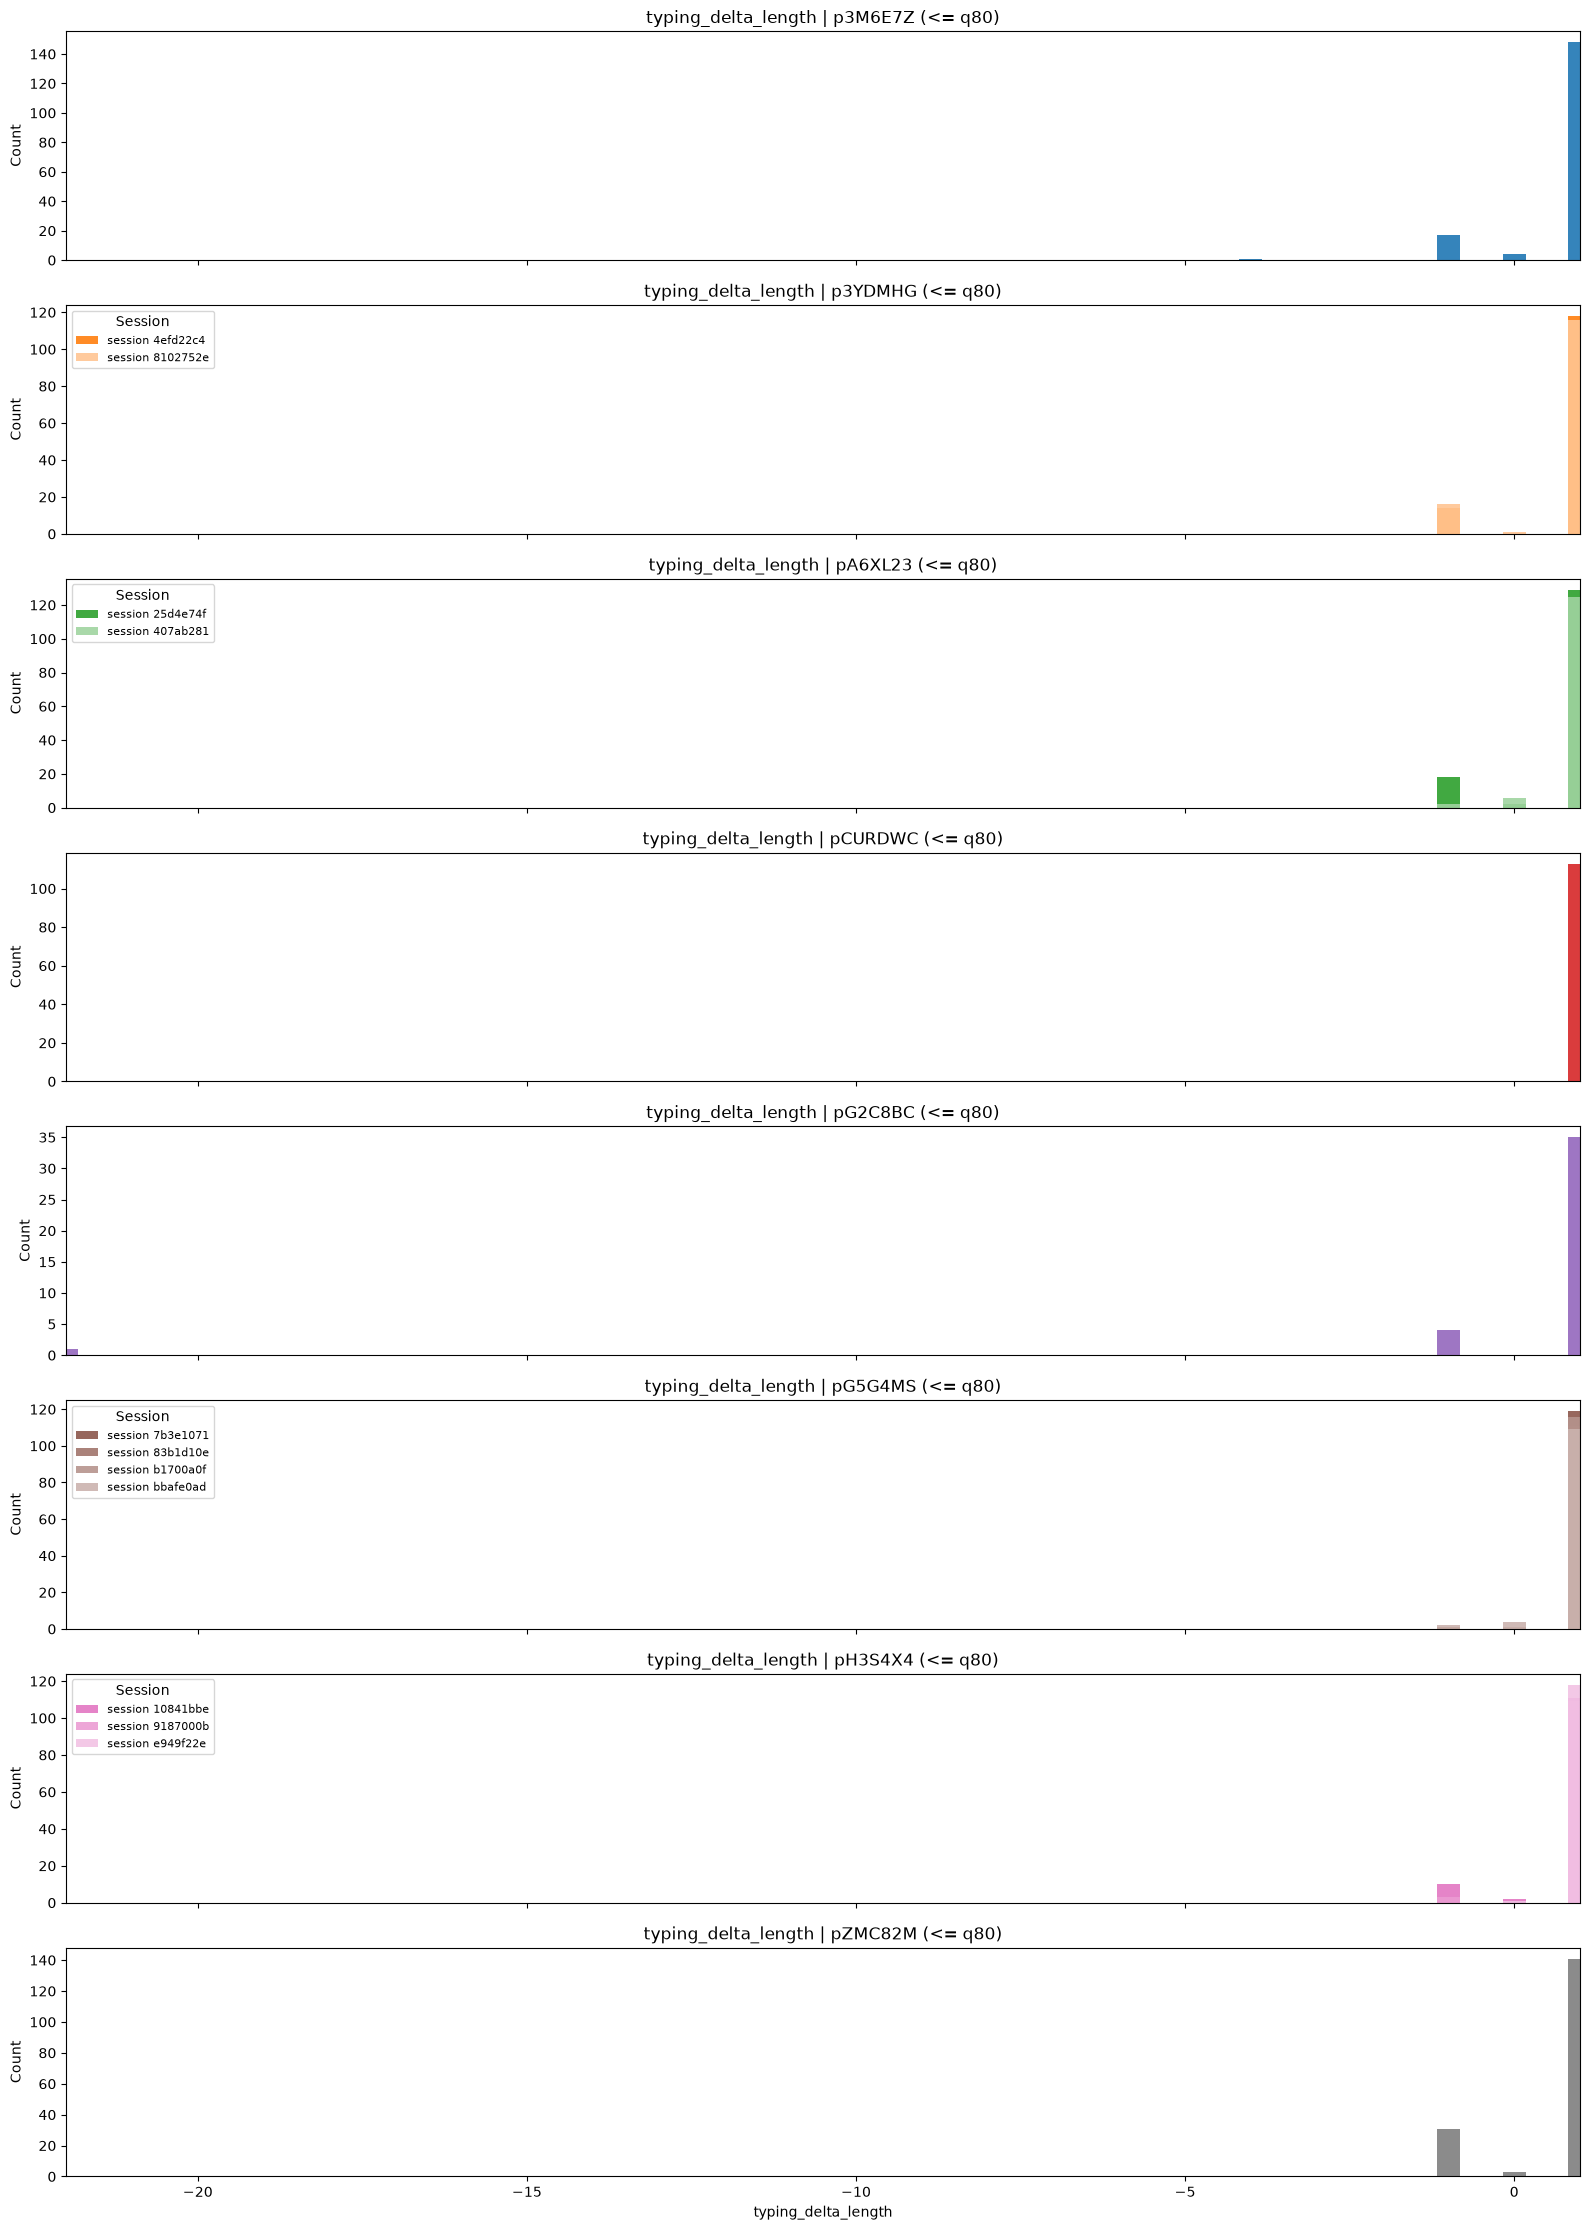

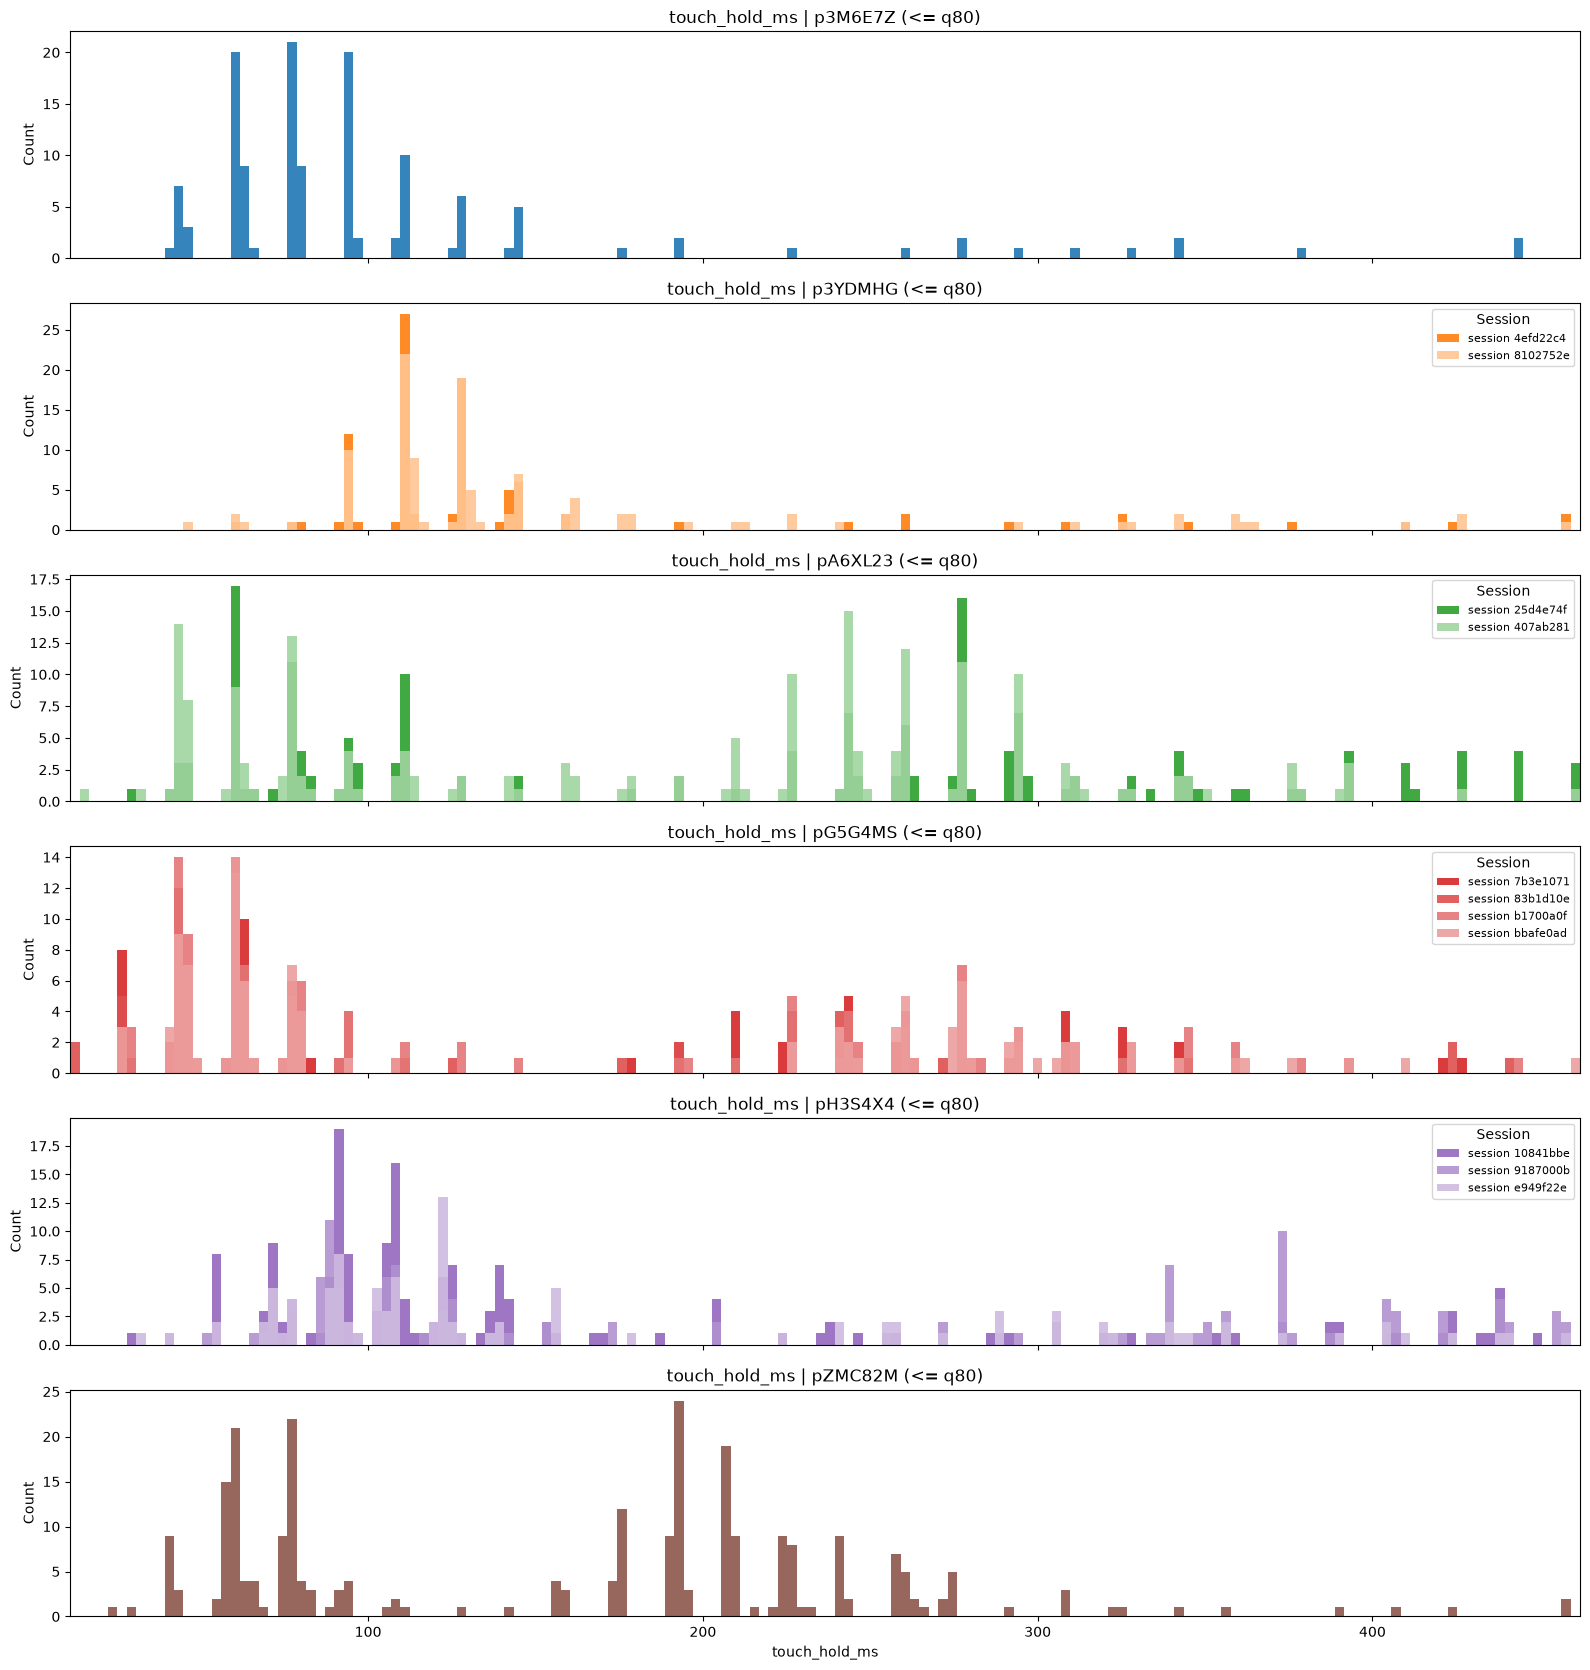

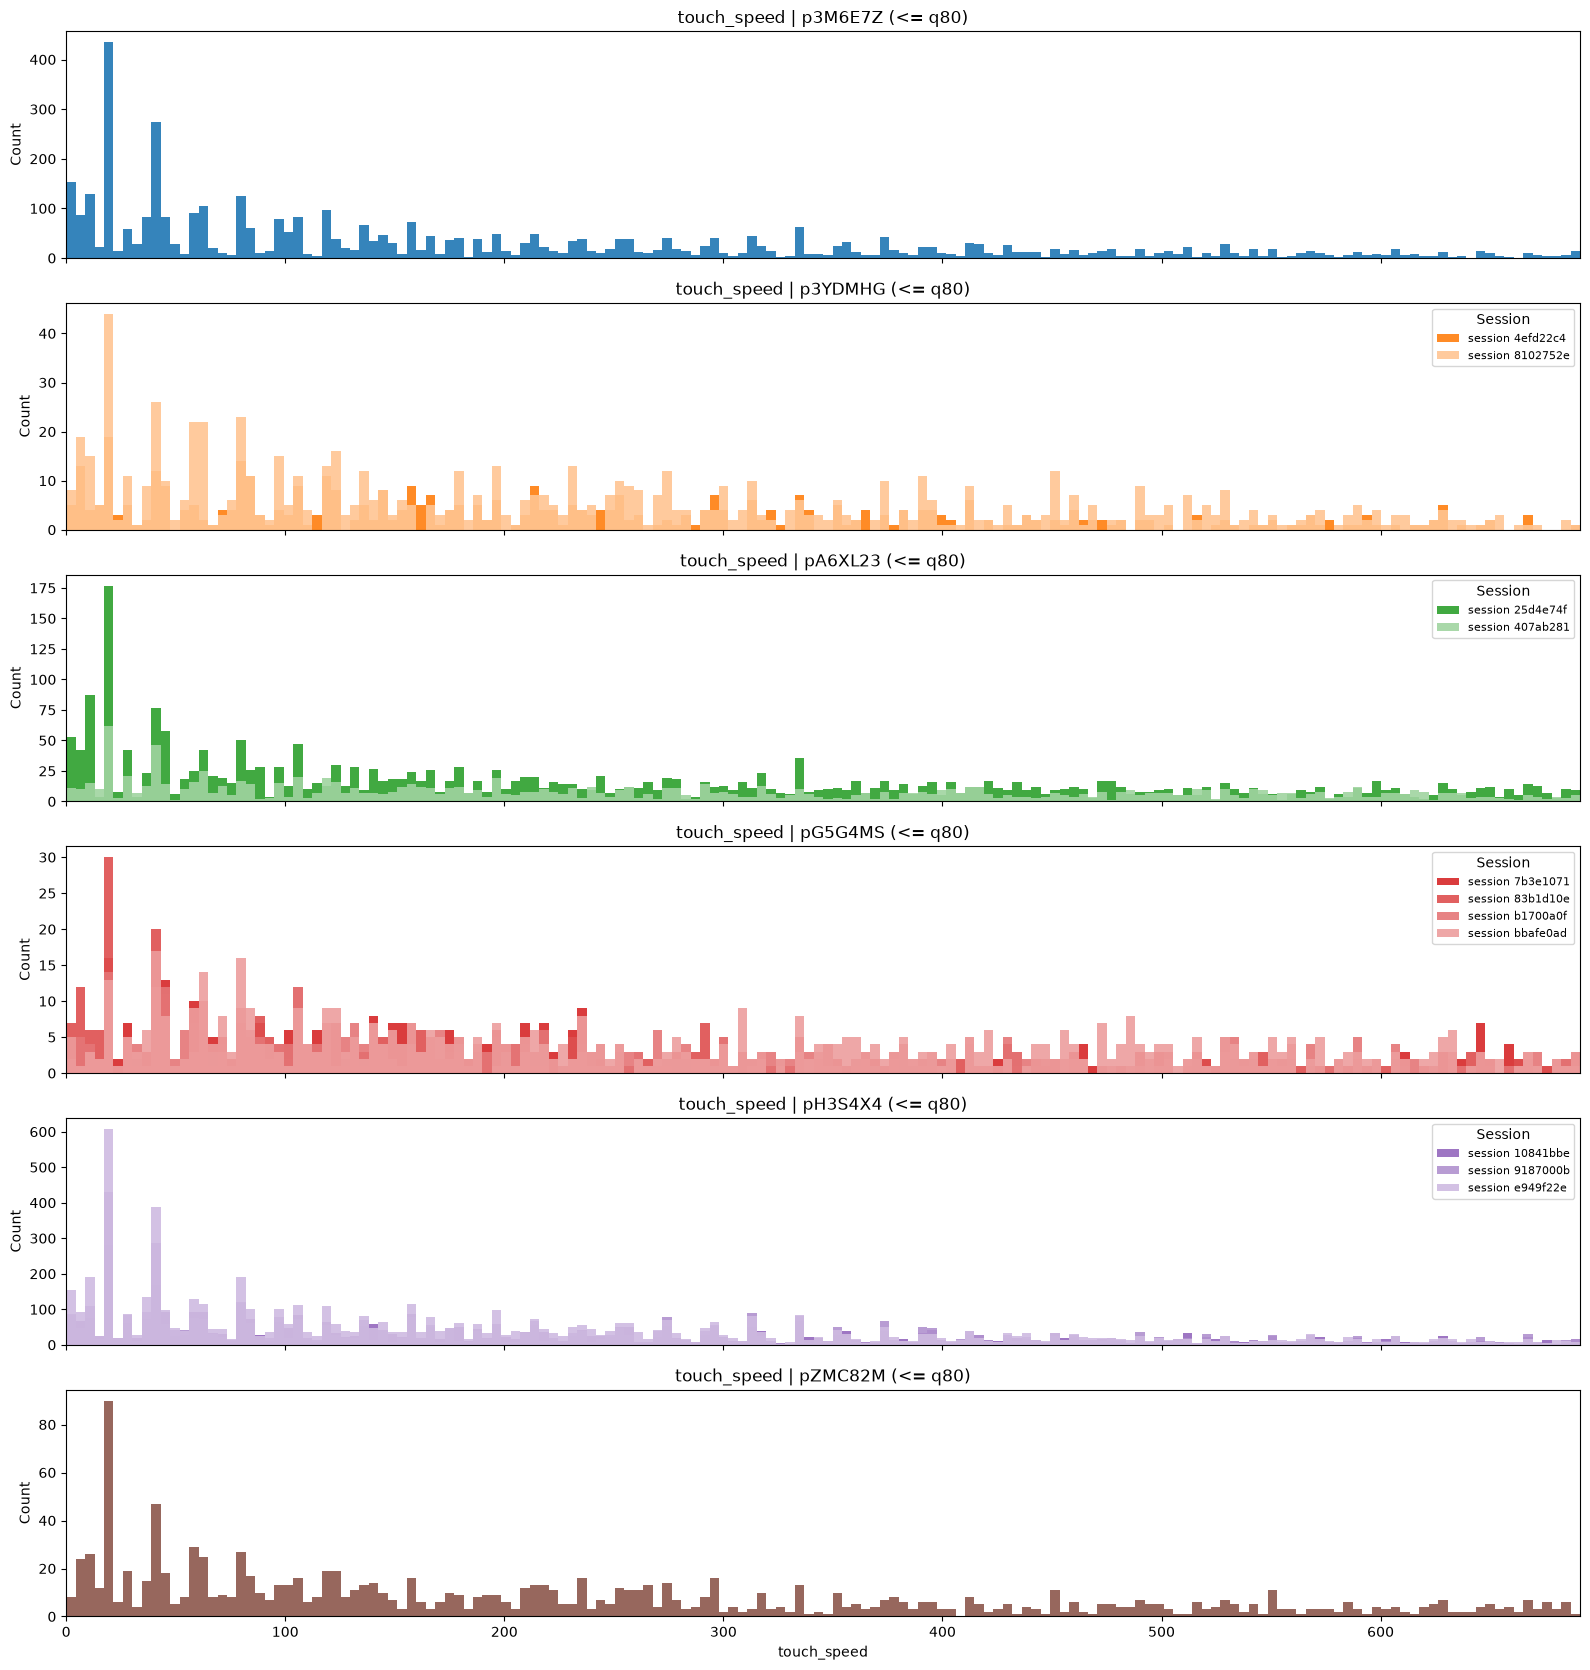

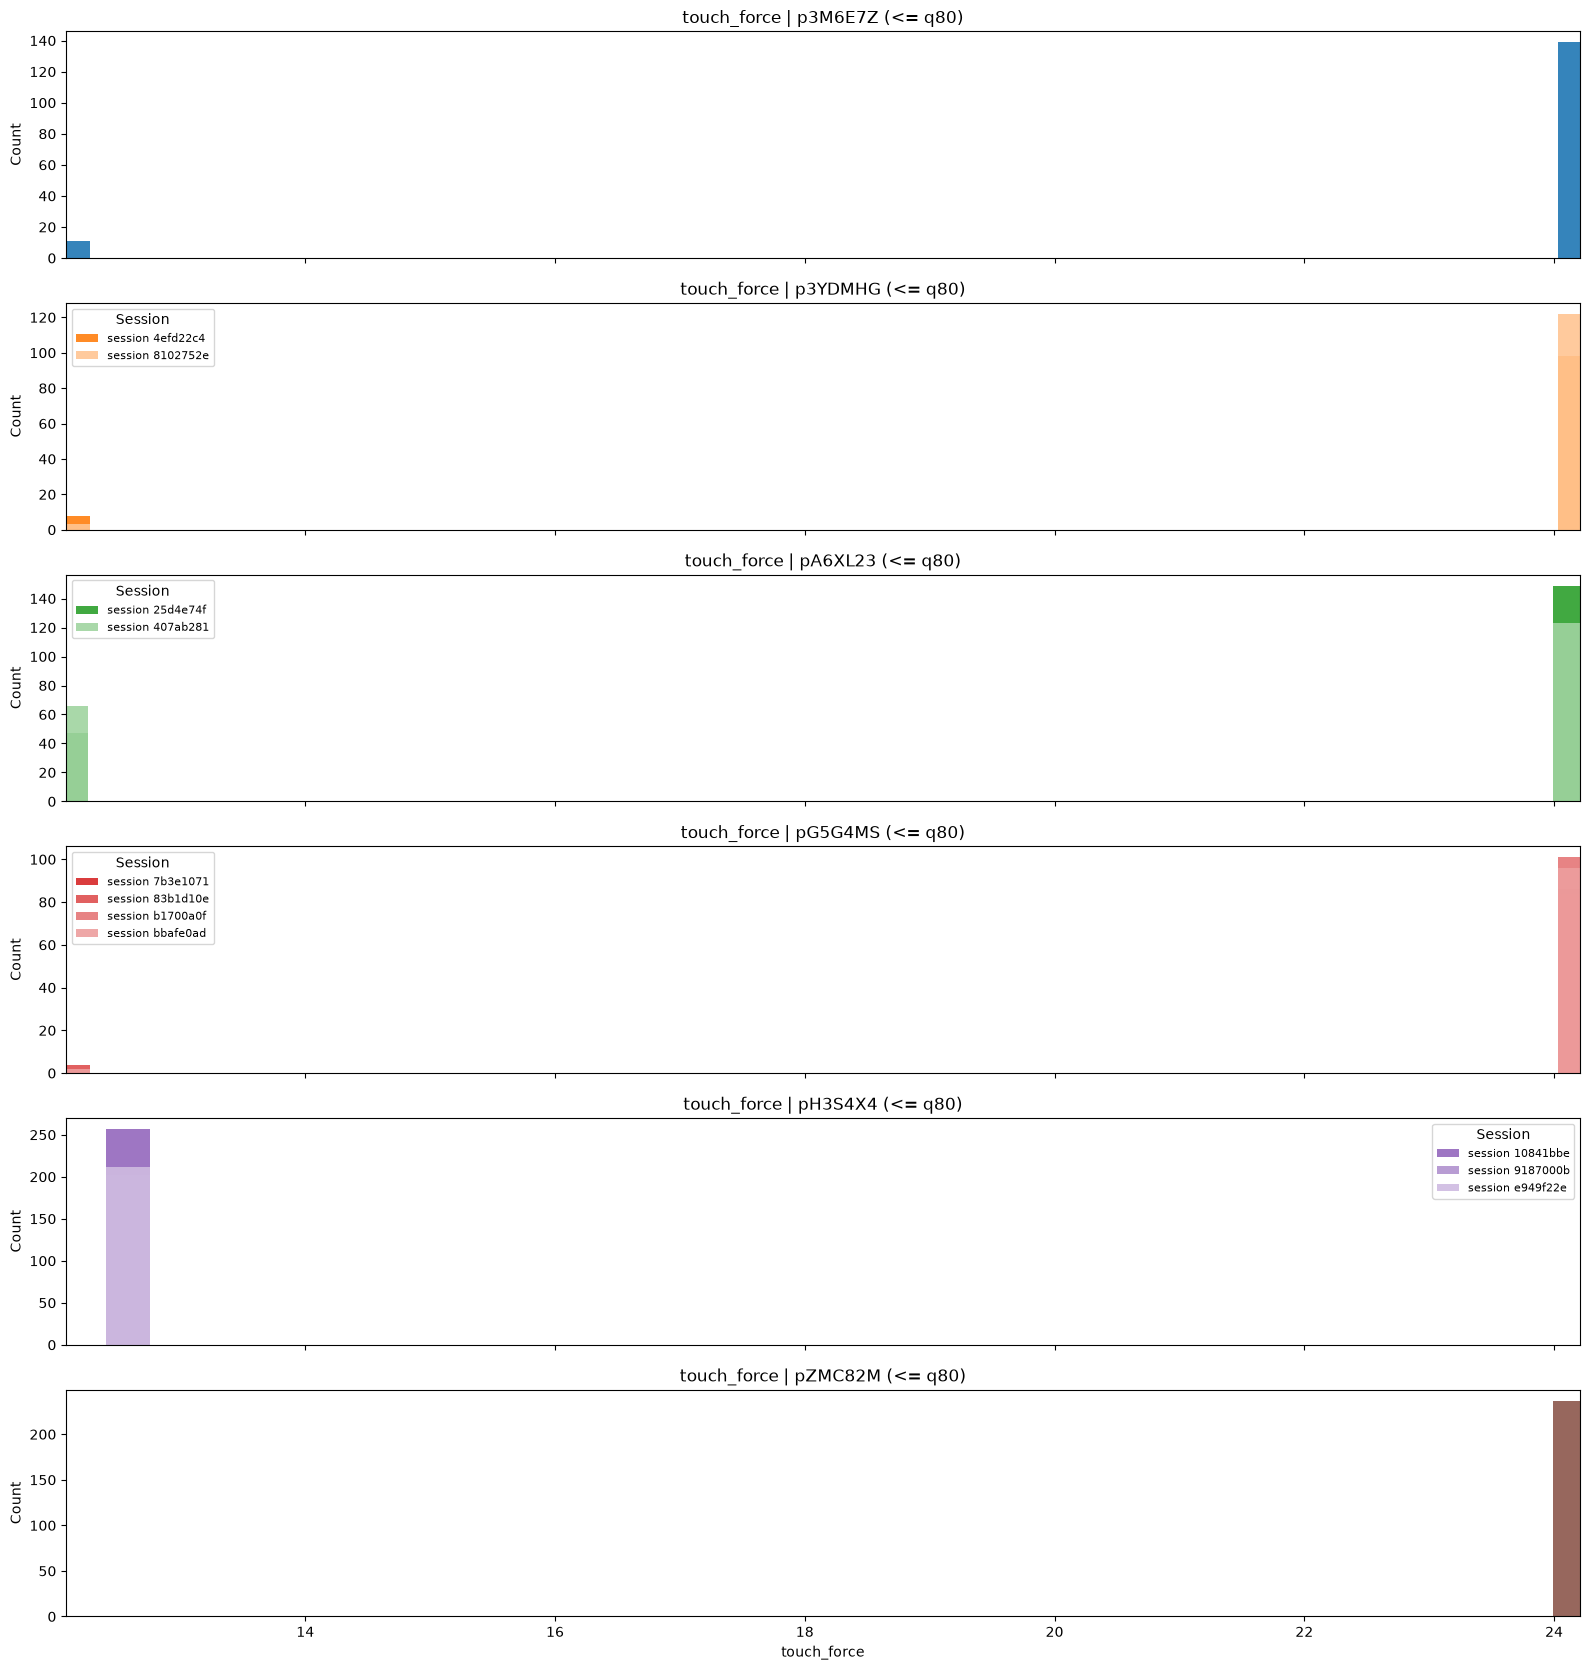

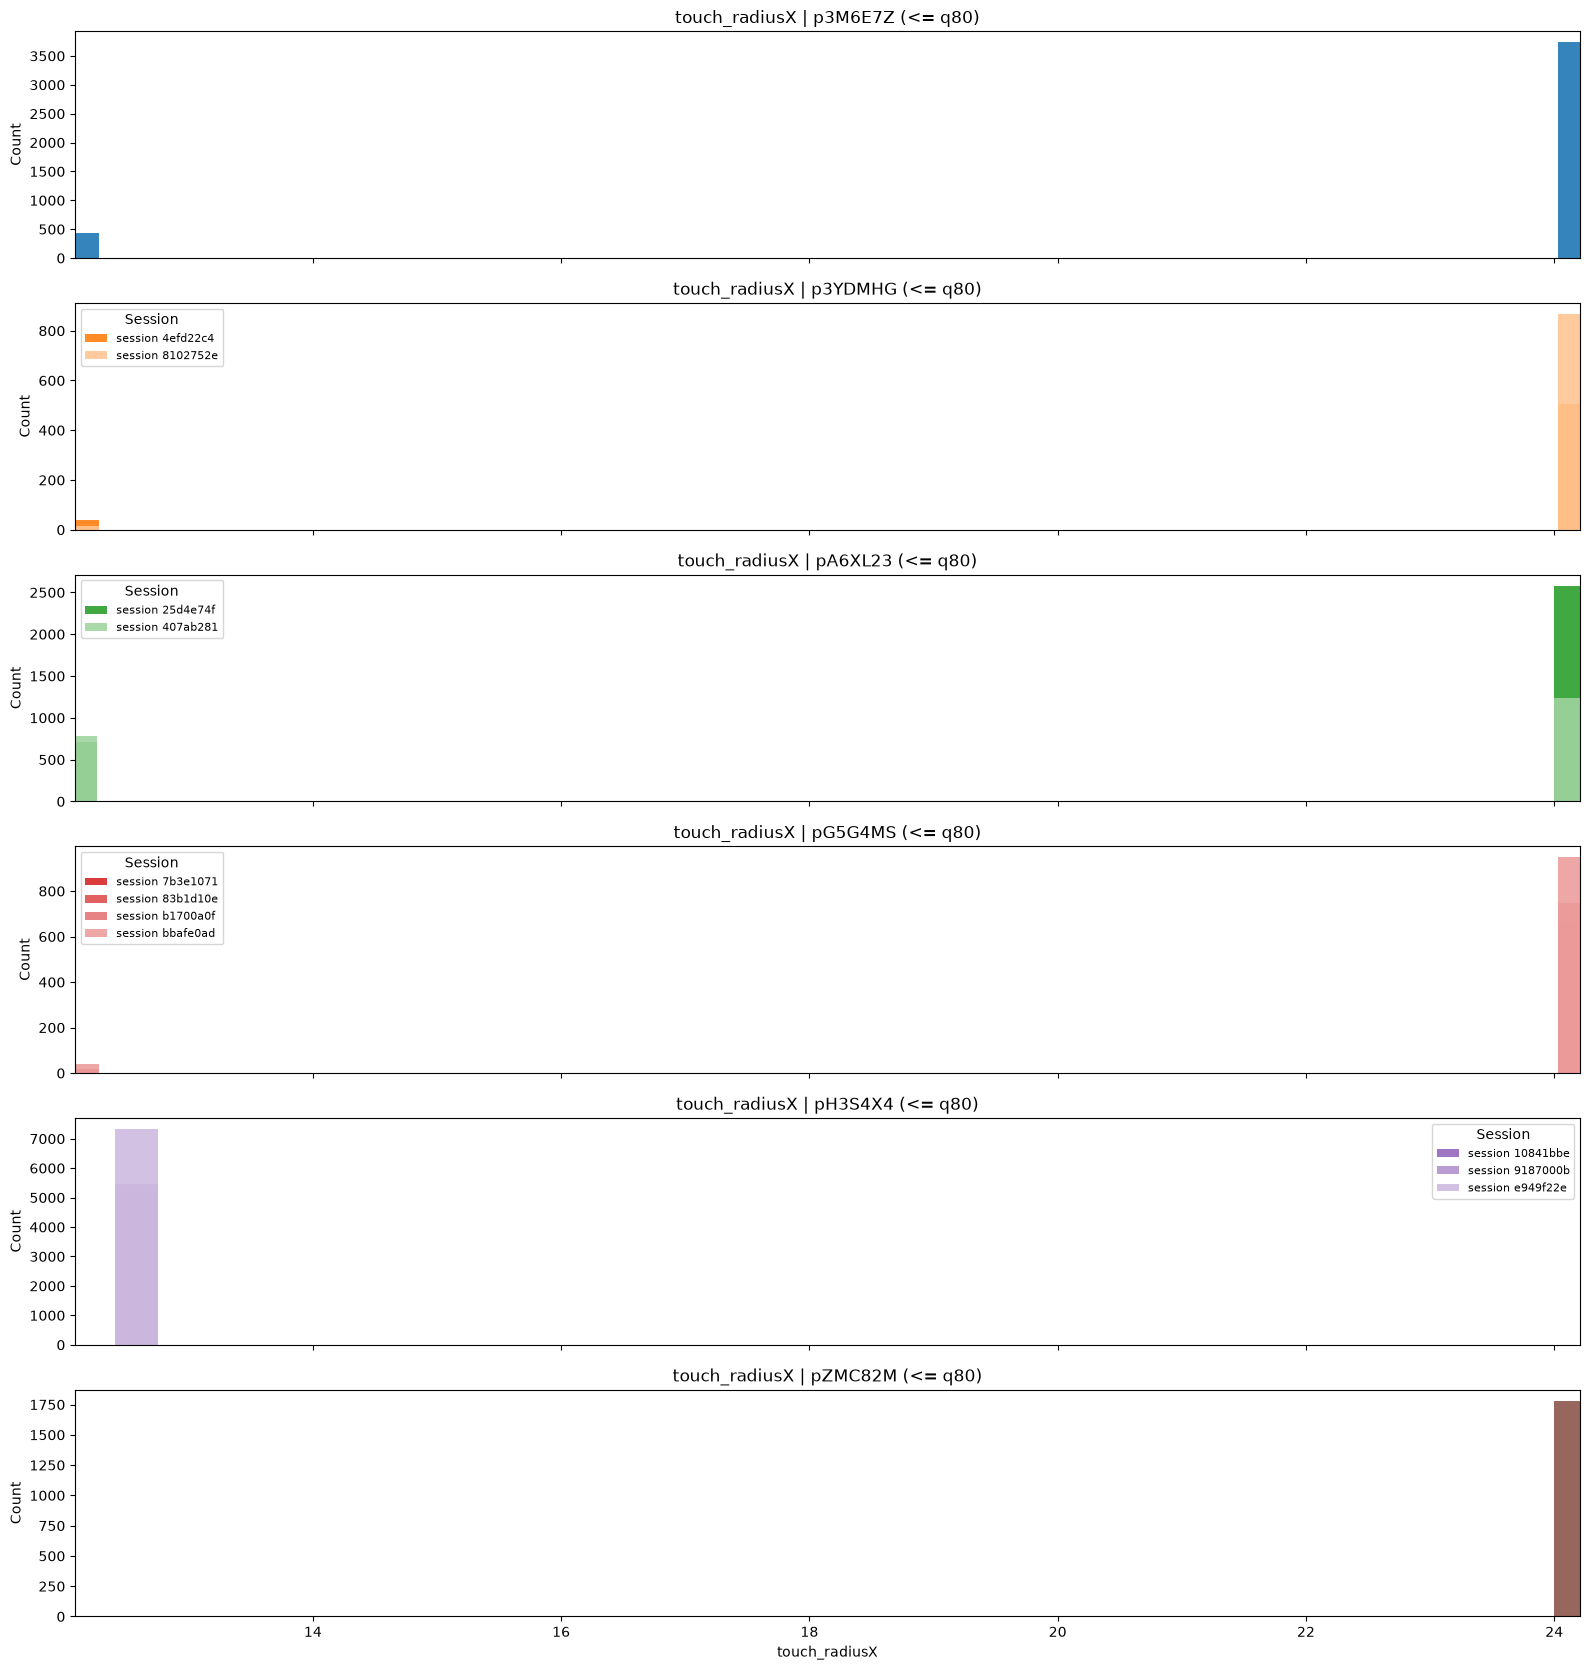

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarni

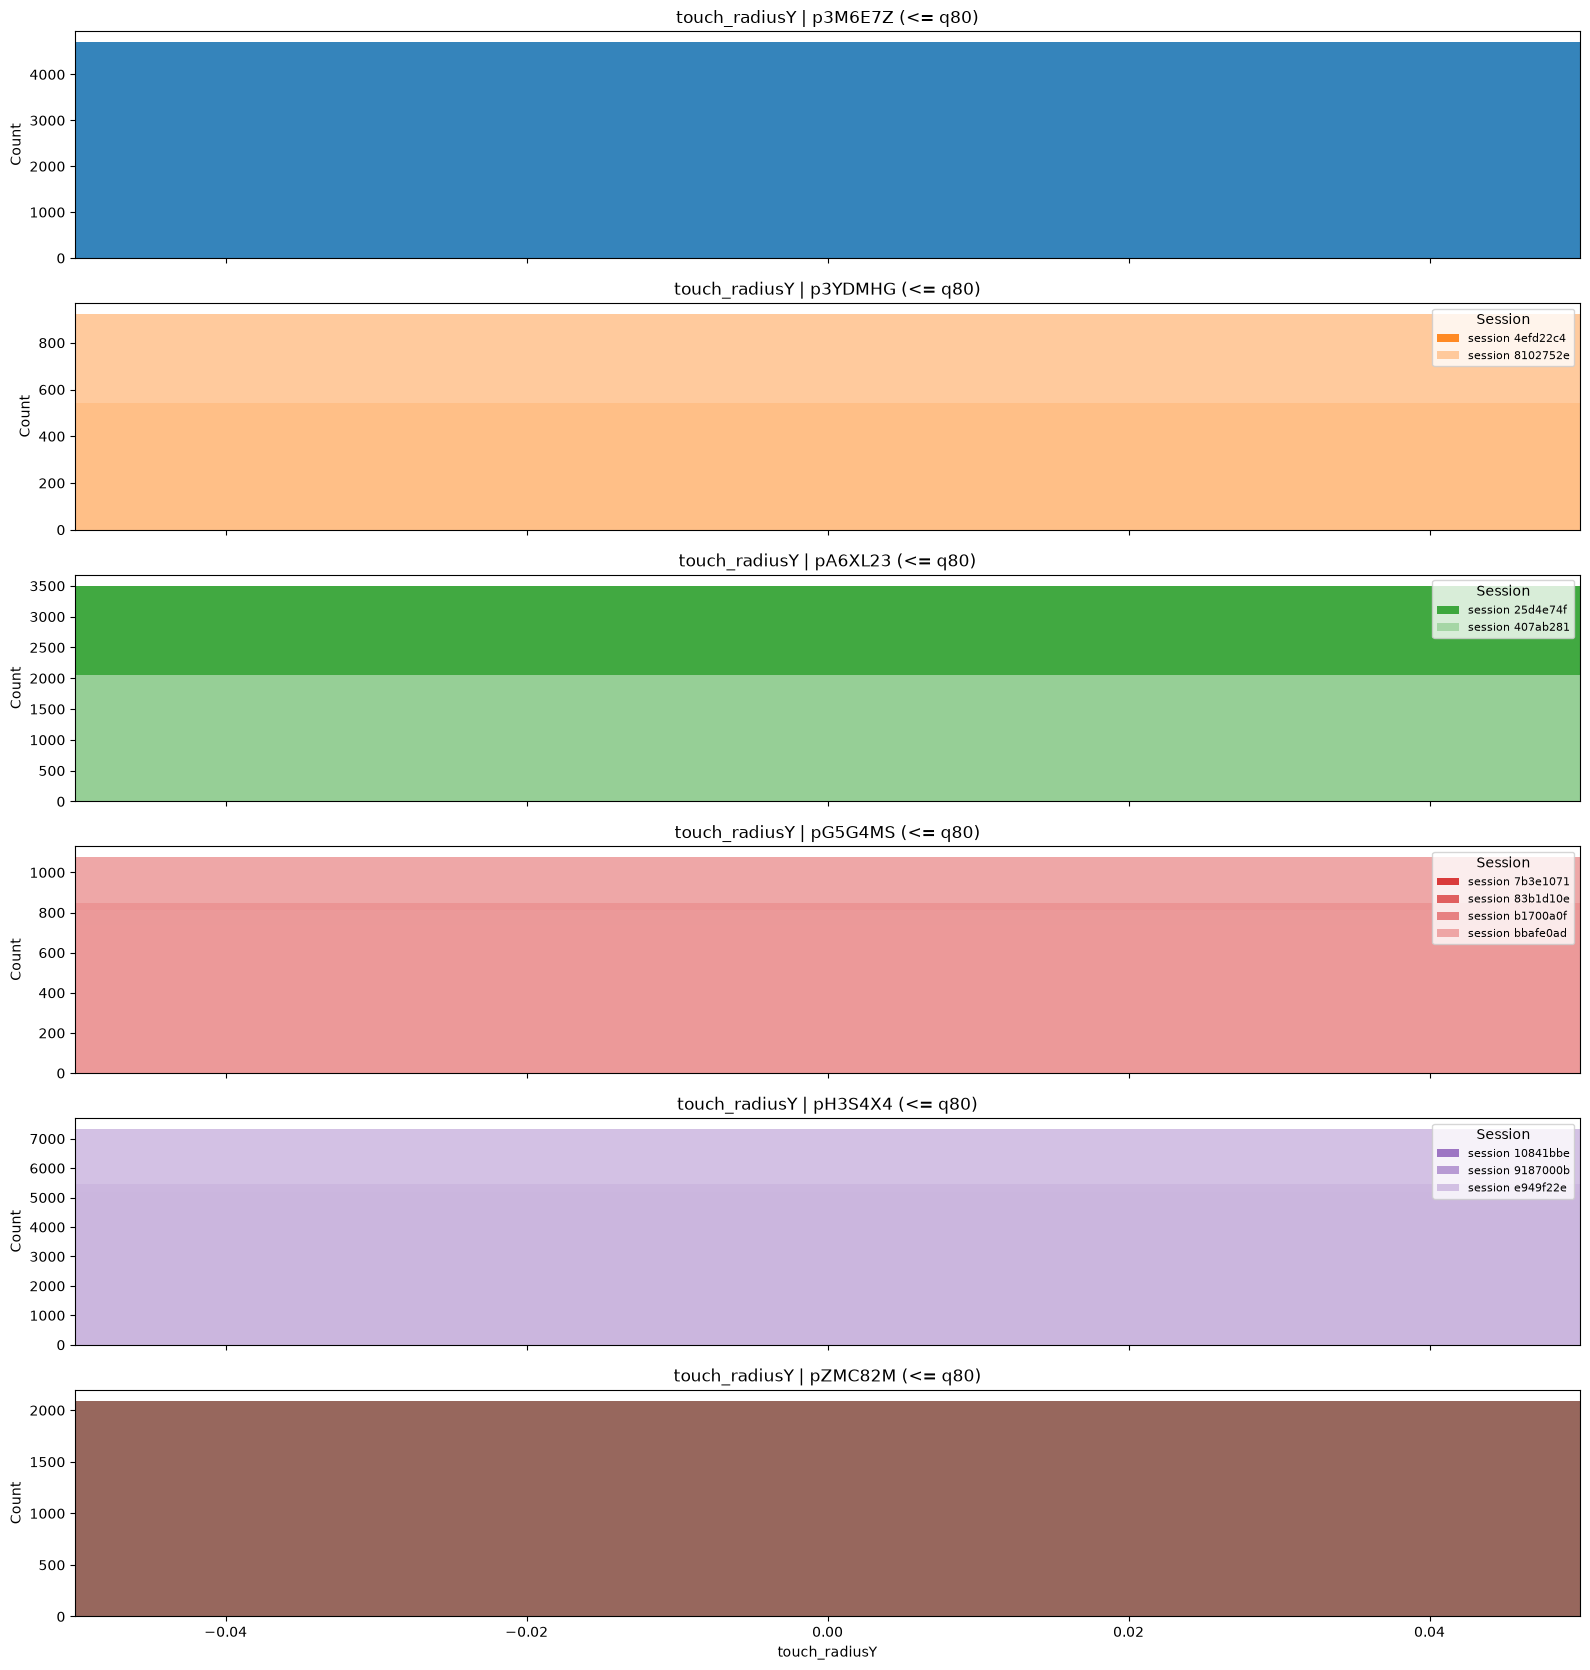

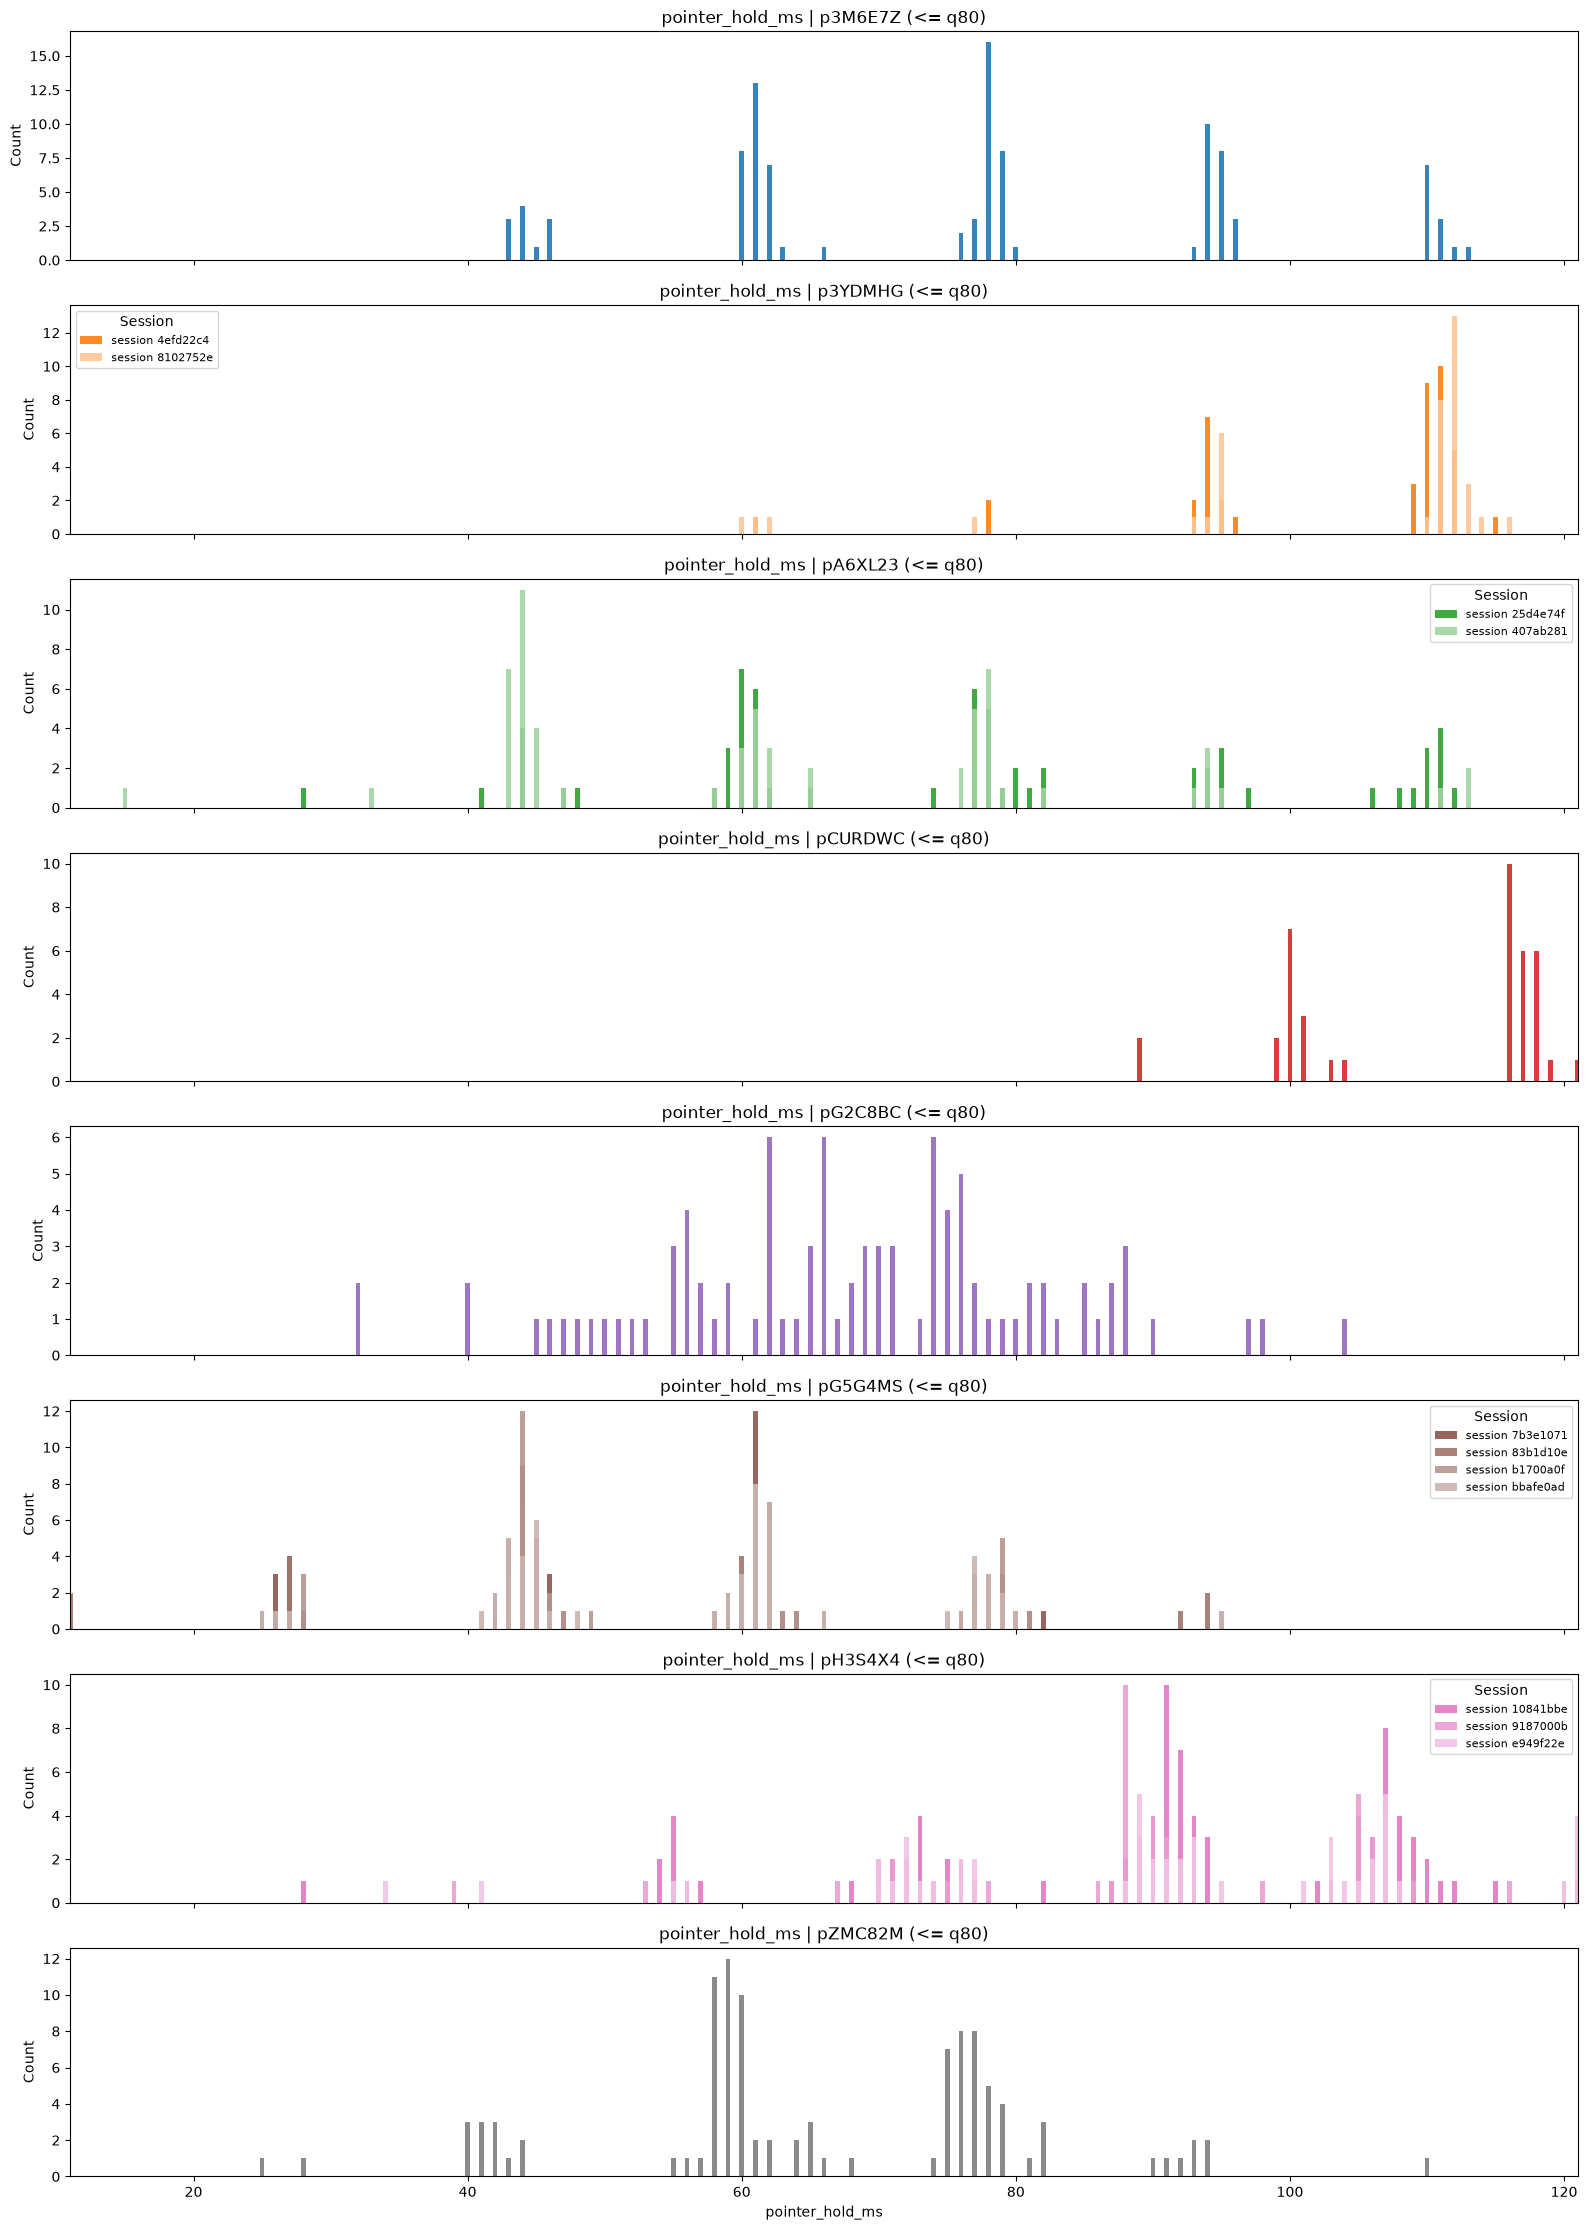

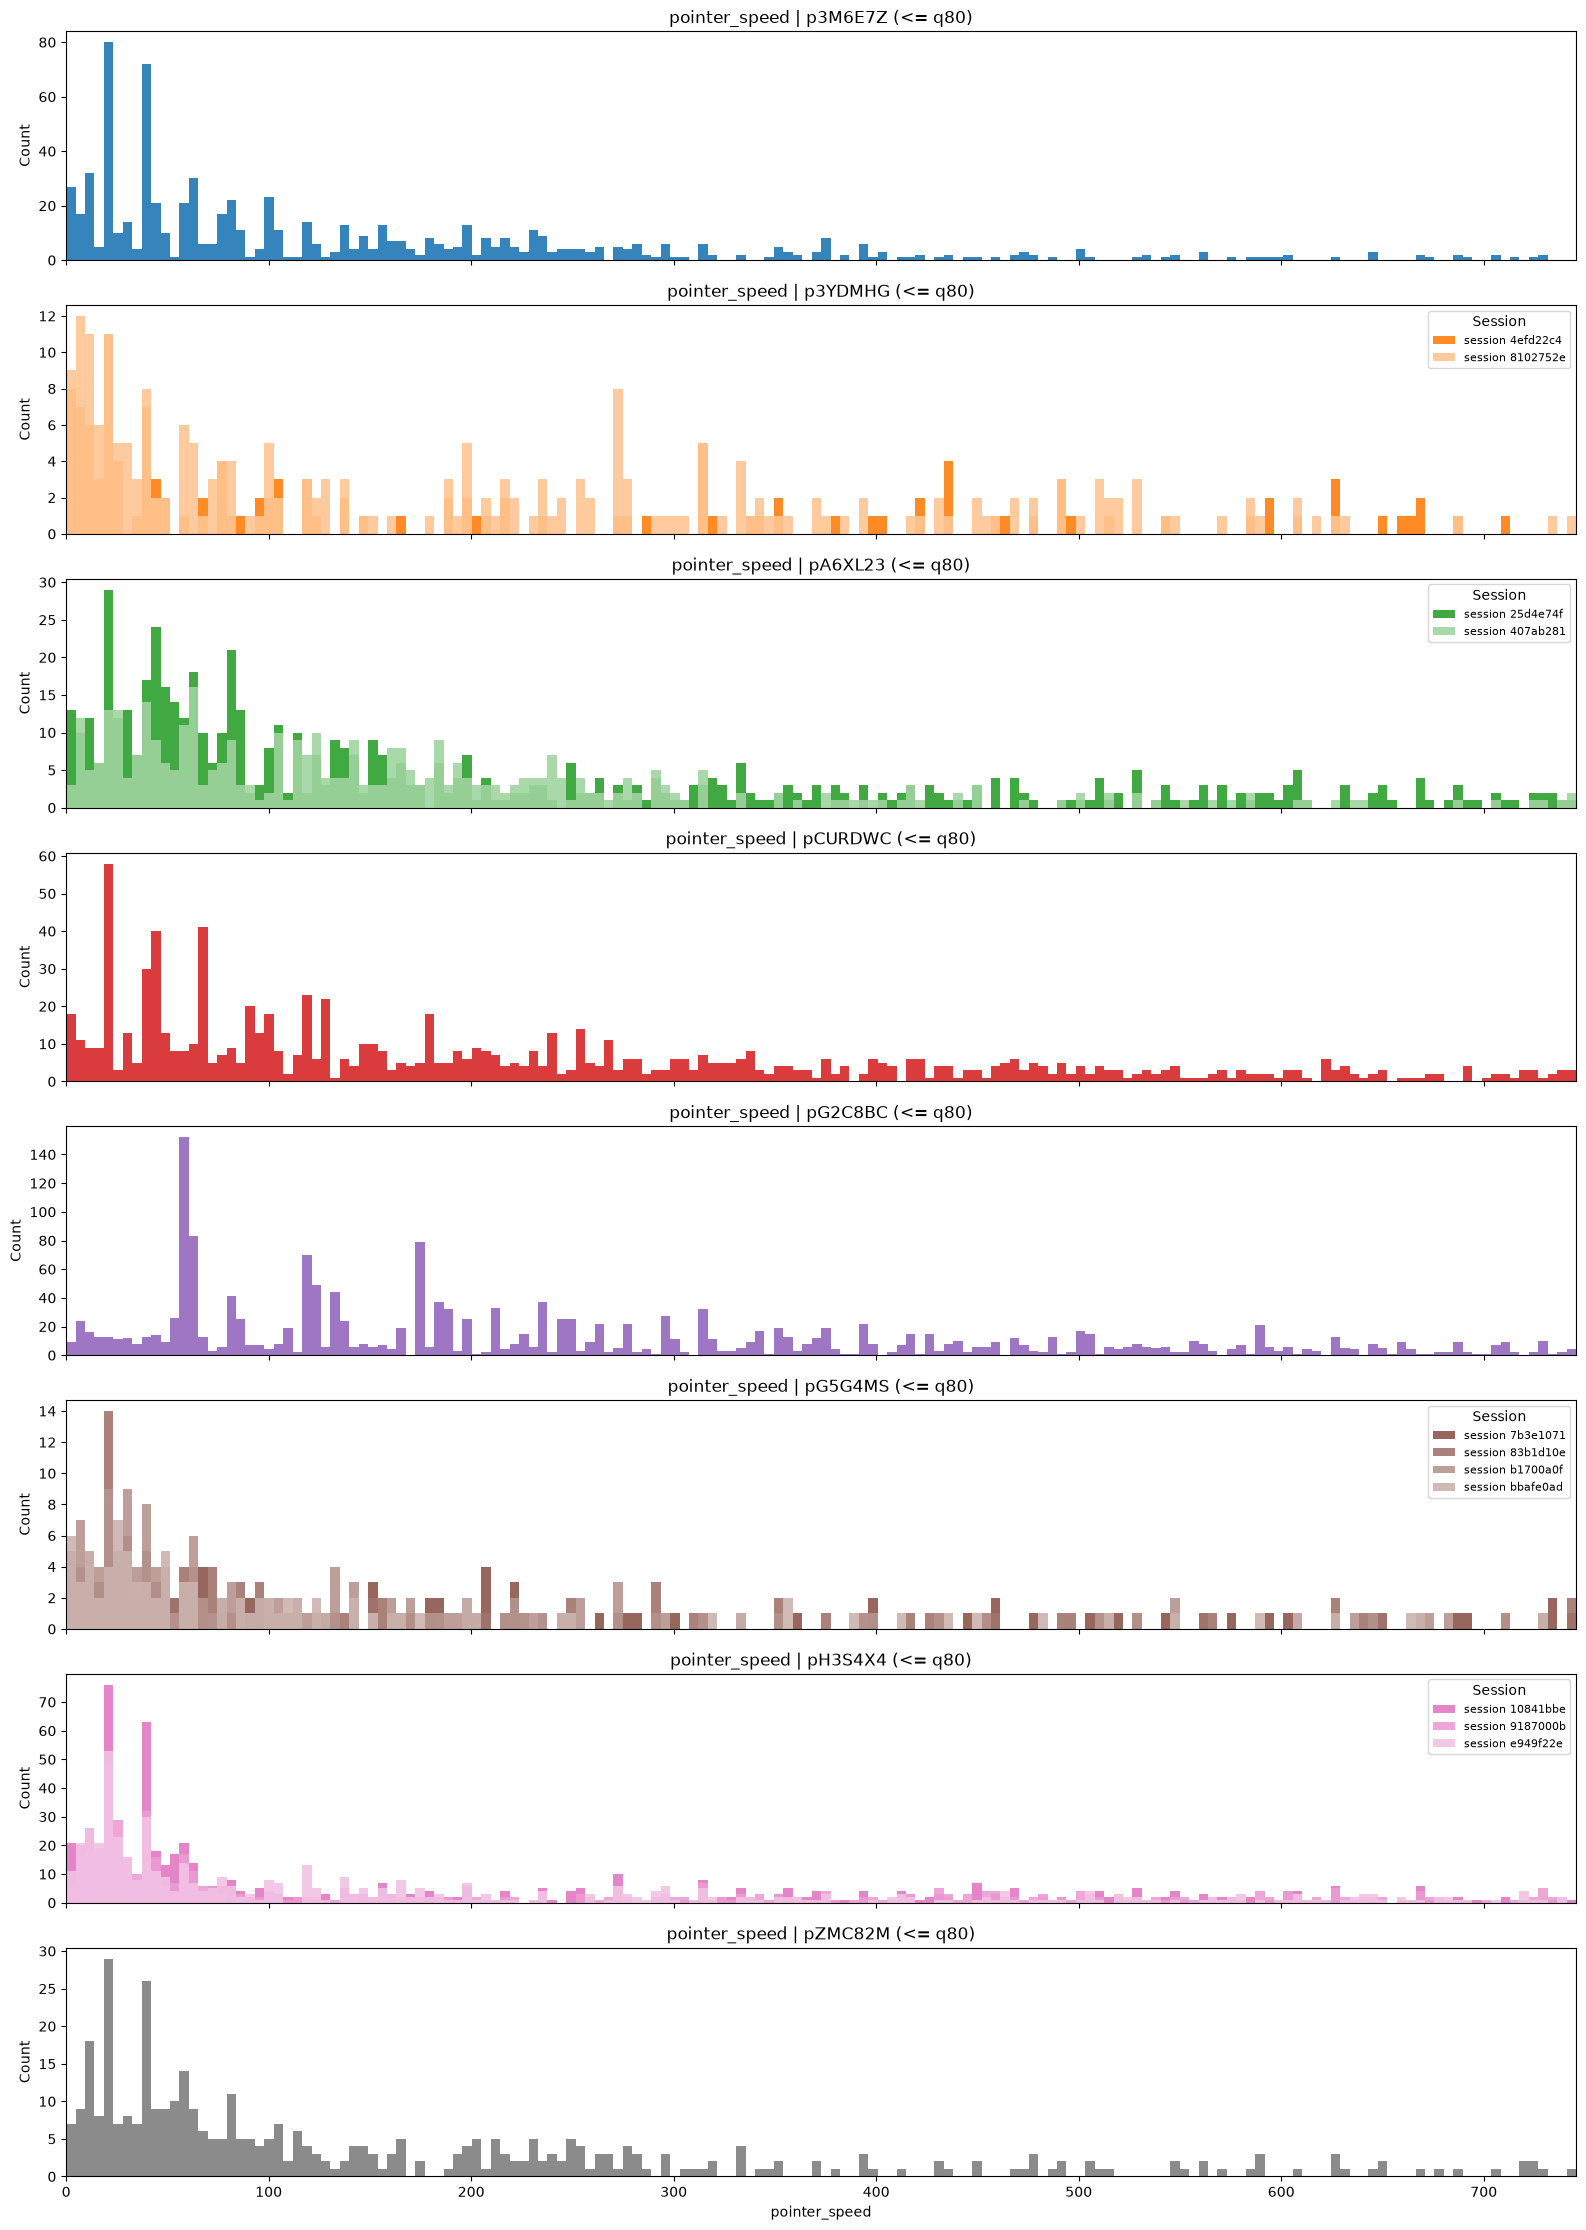

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarni

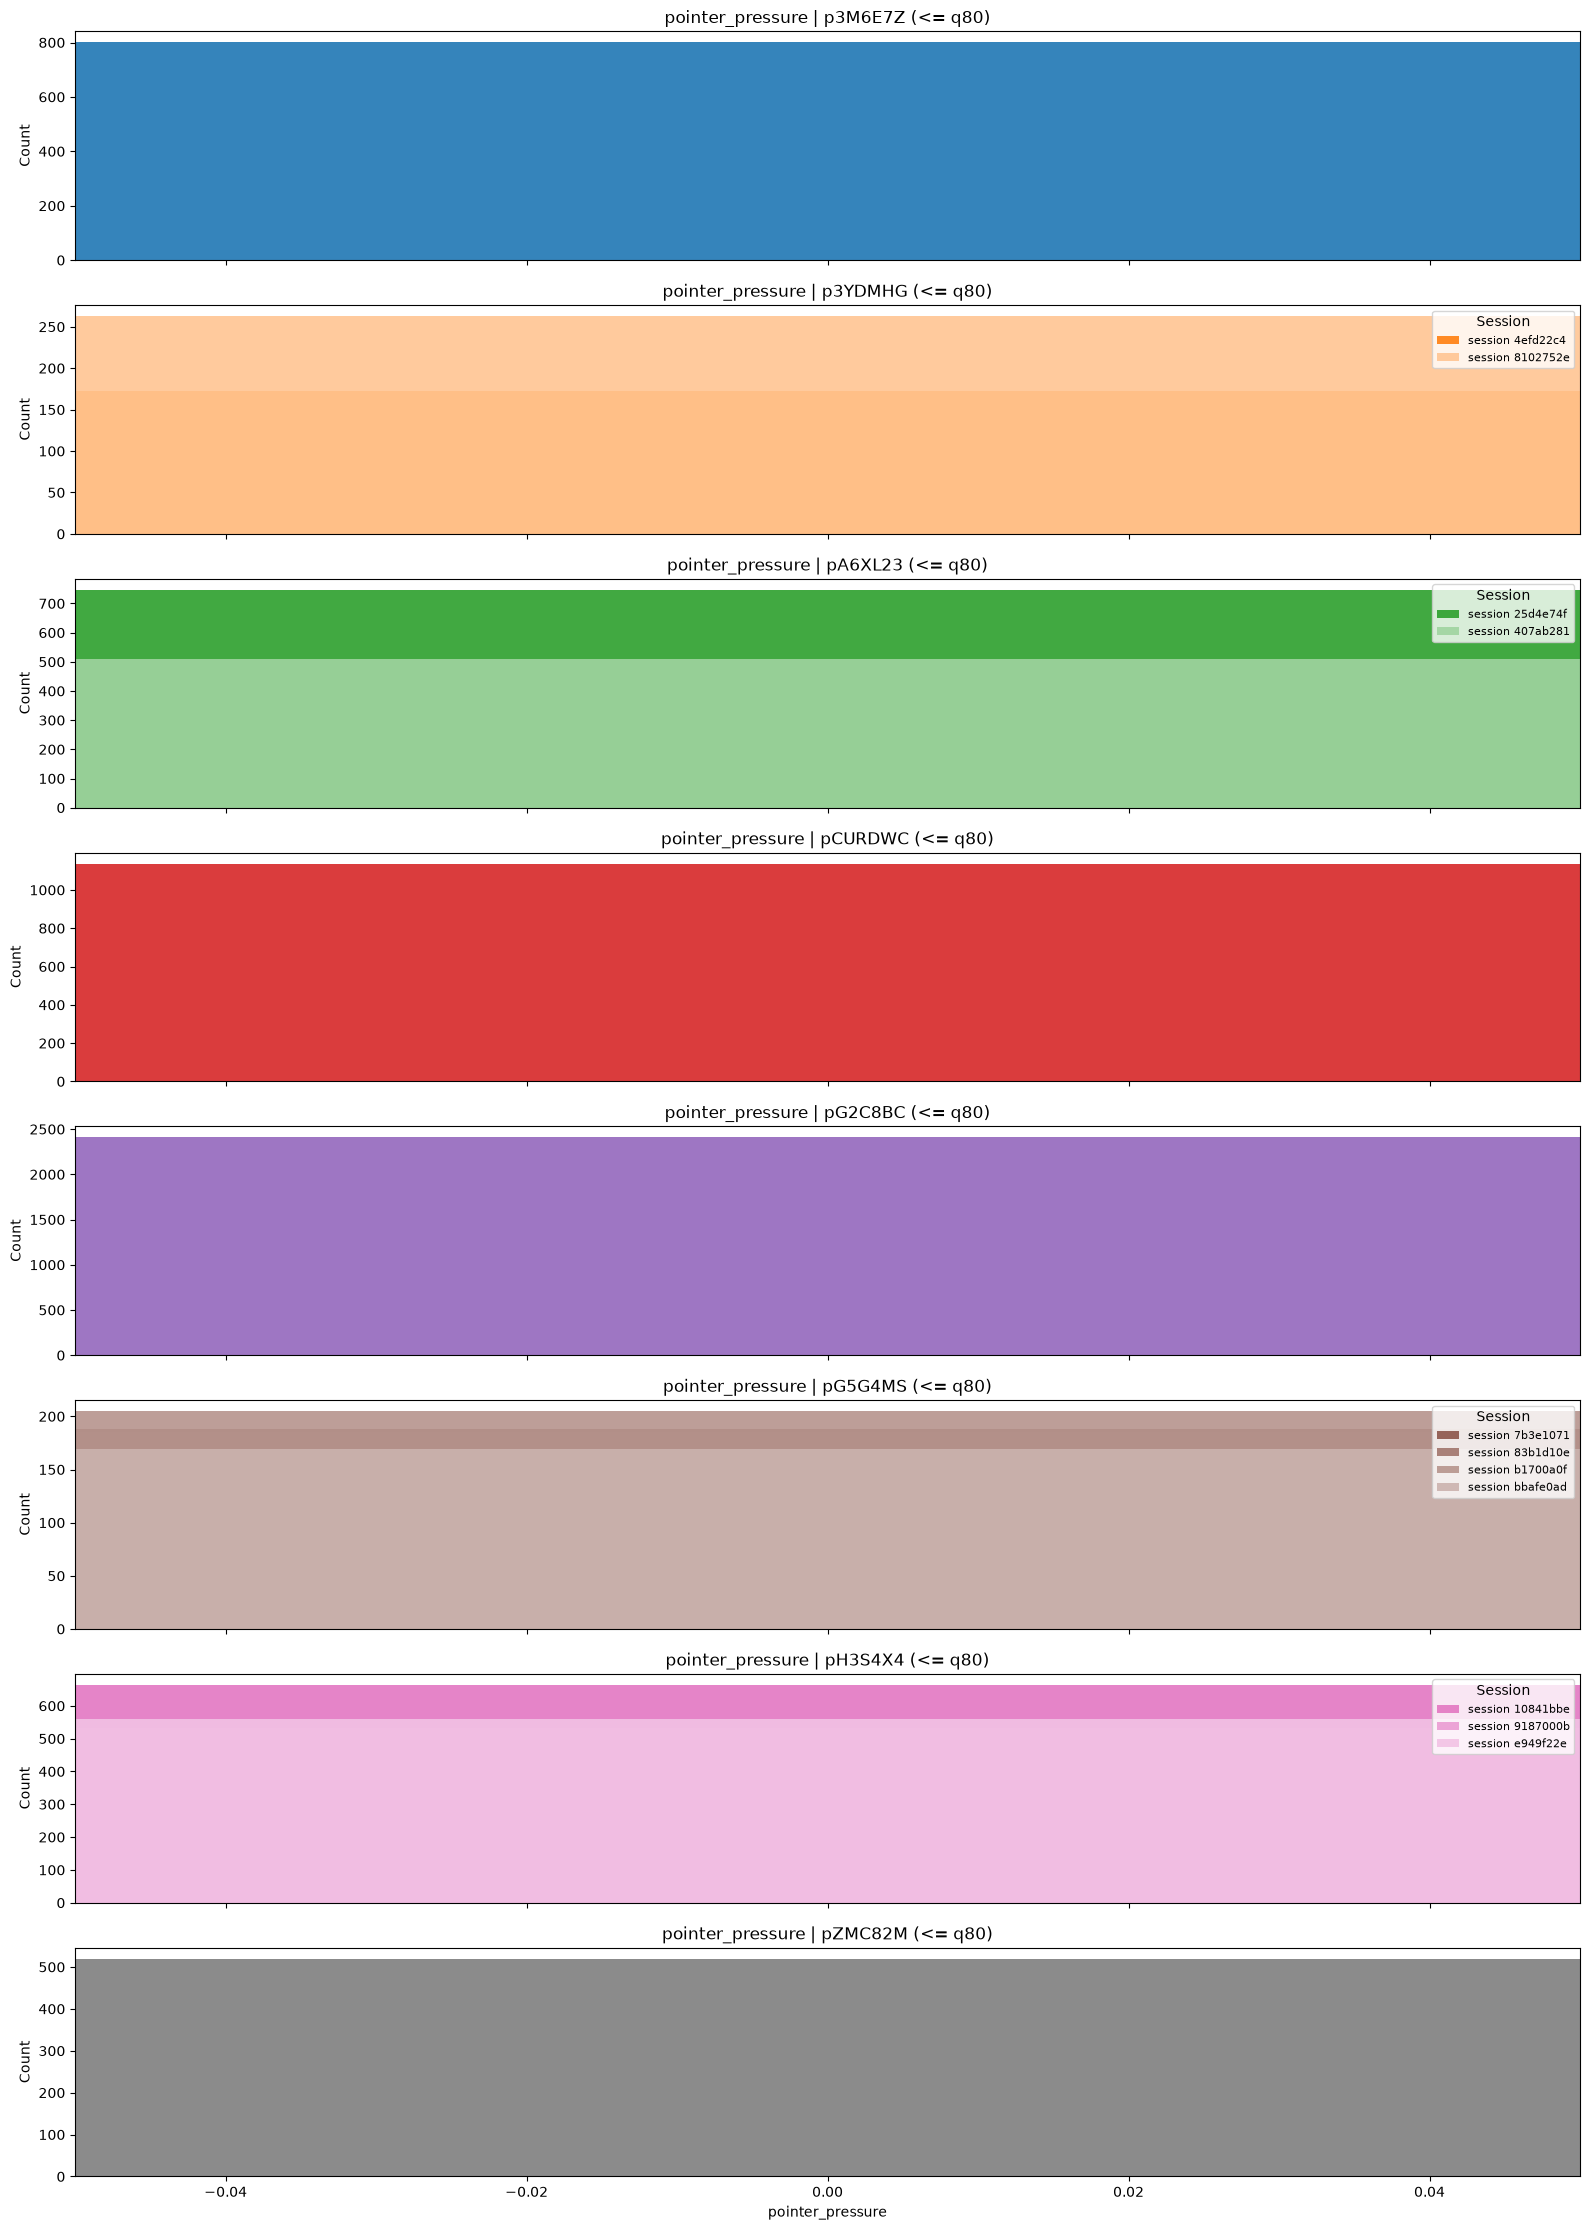

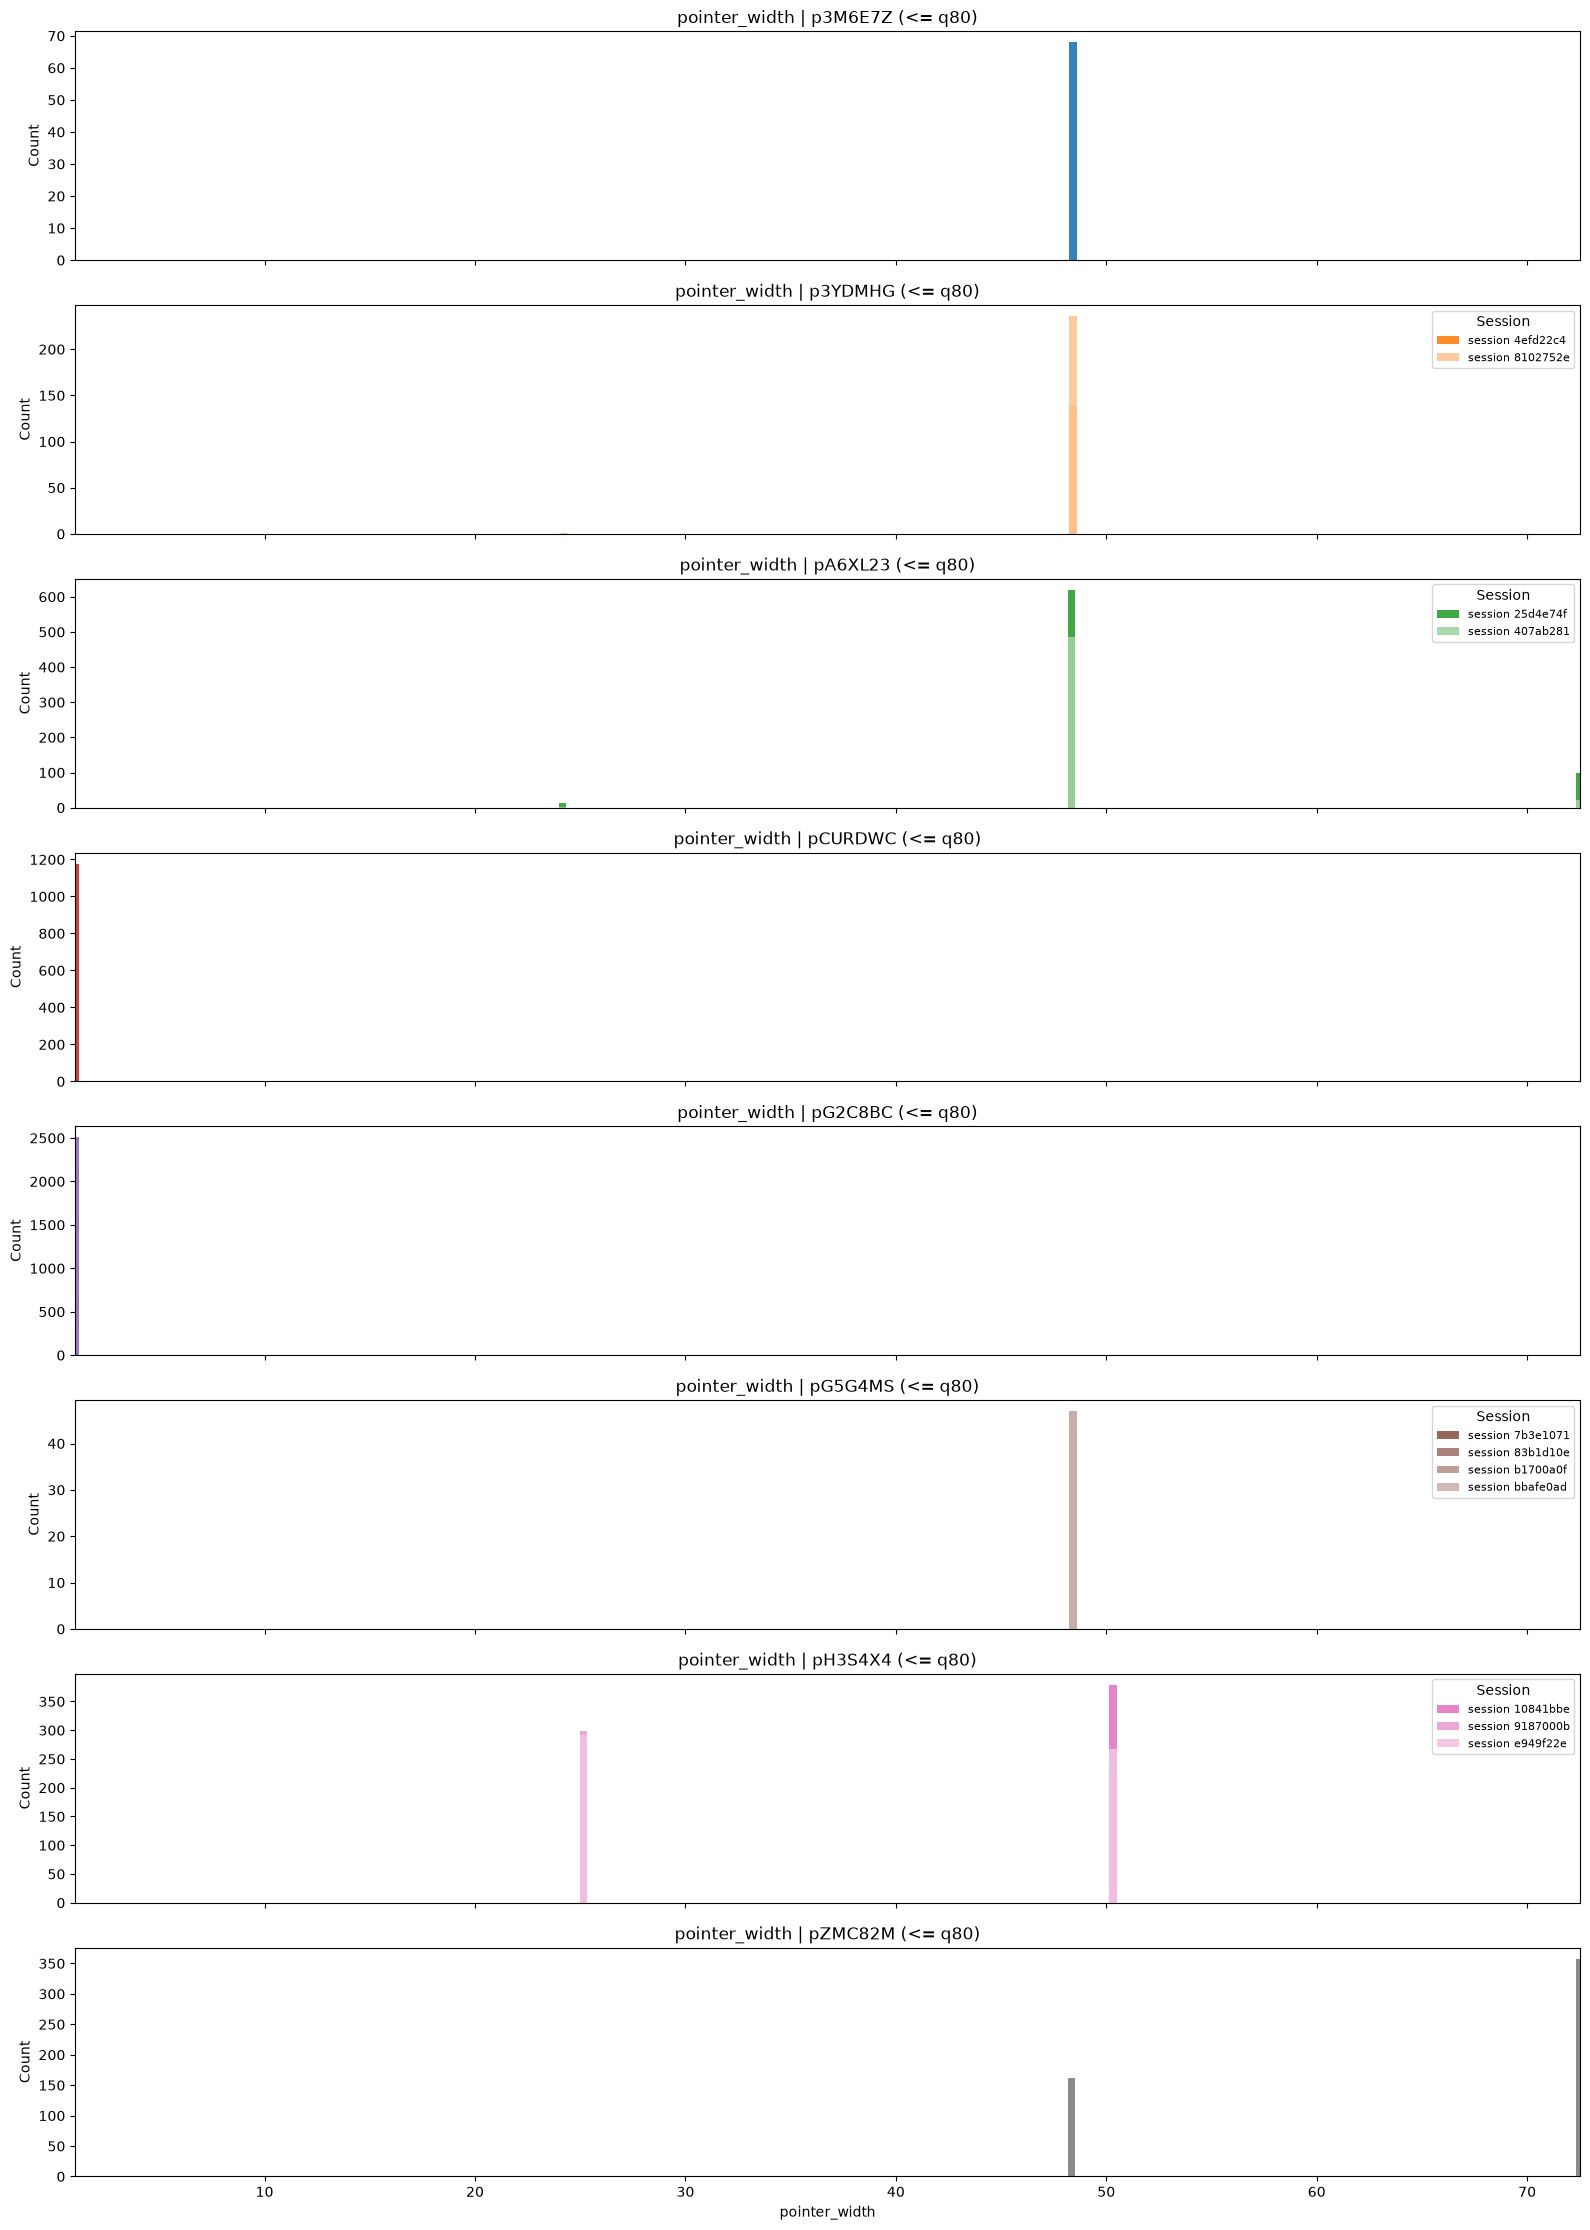

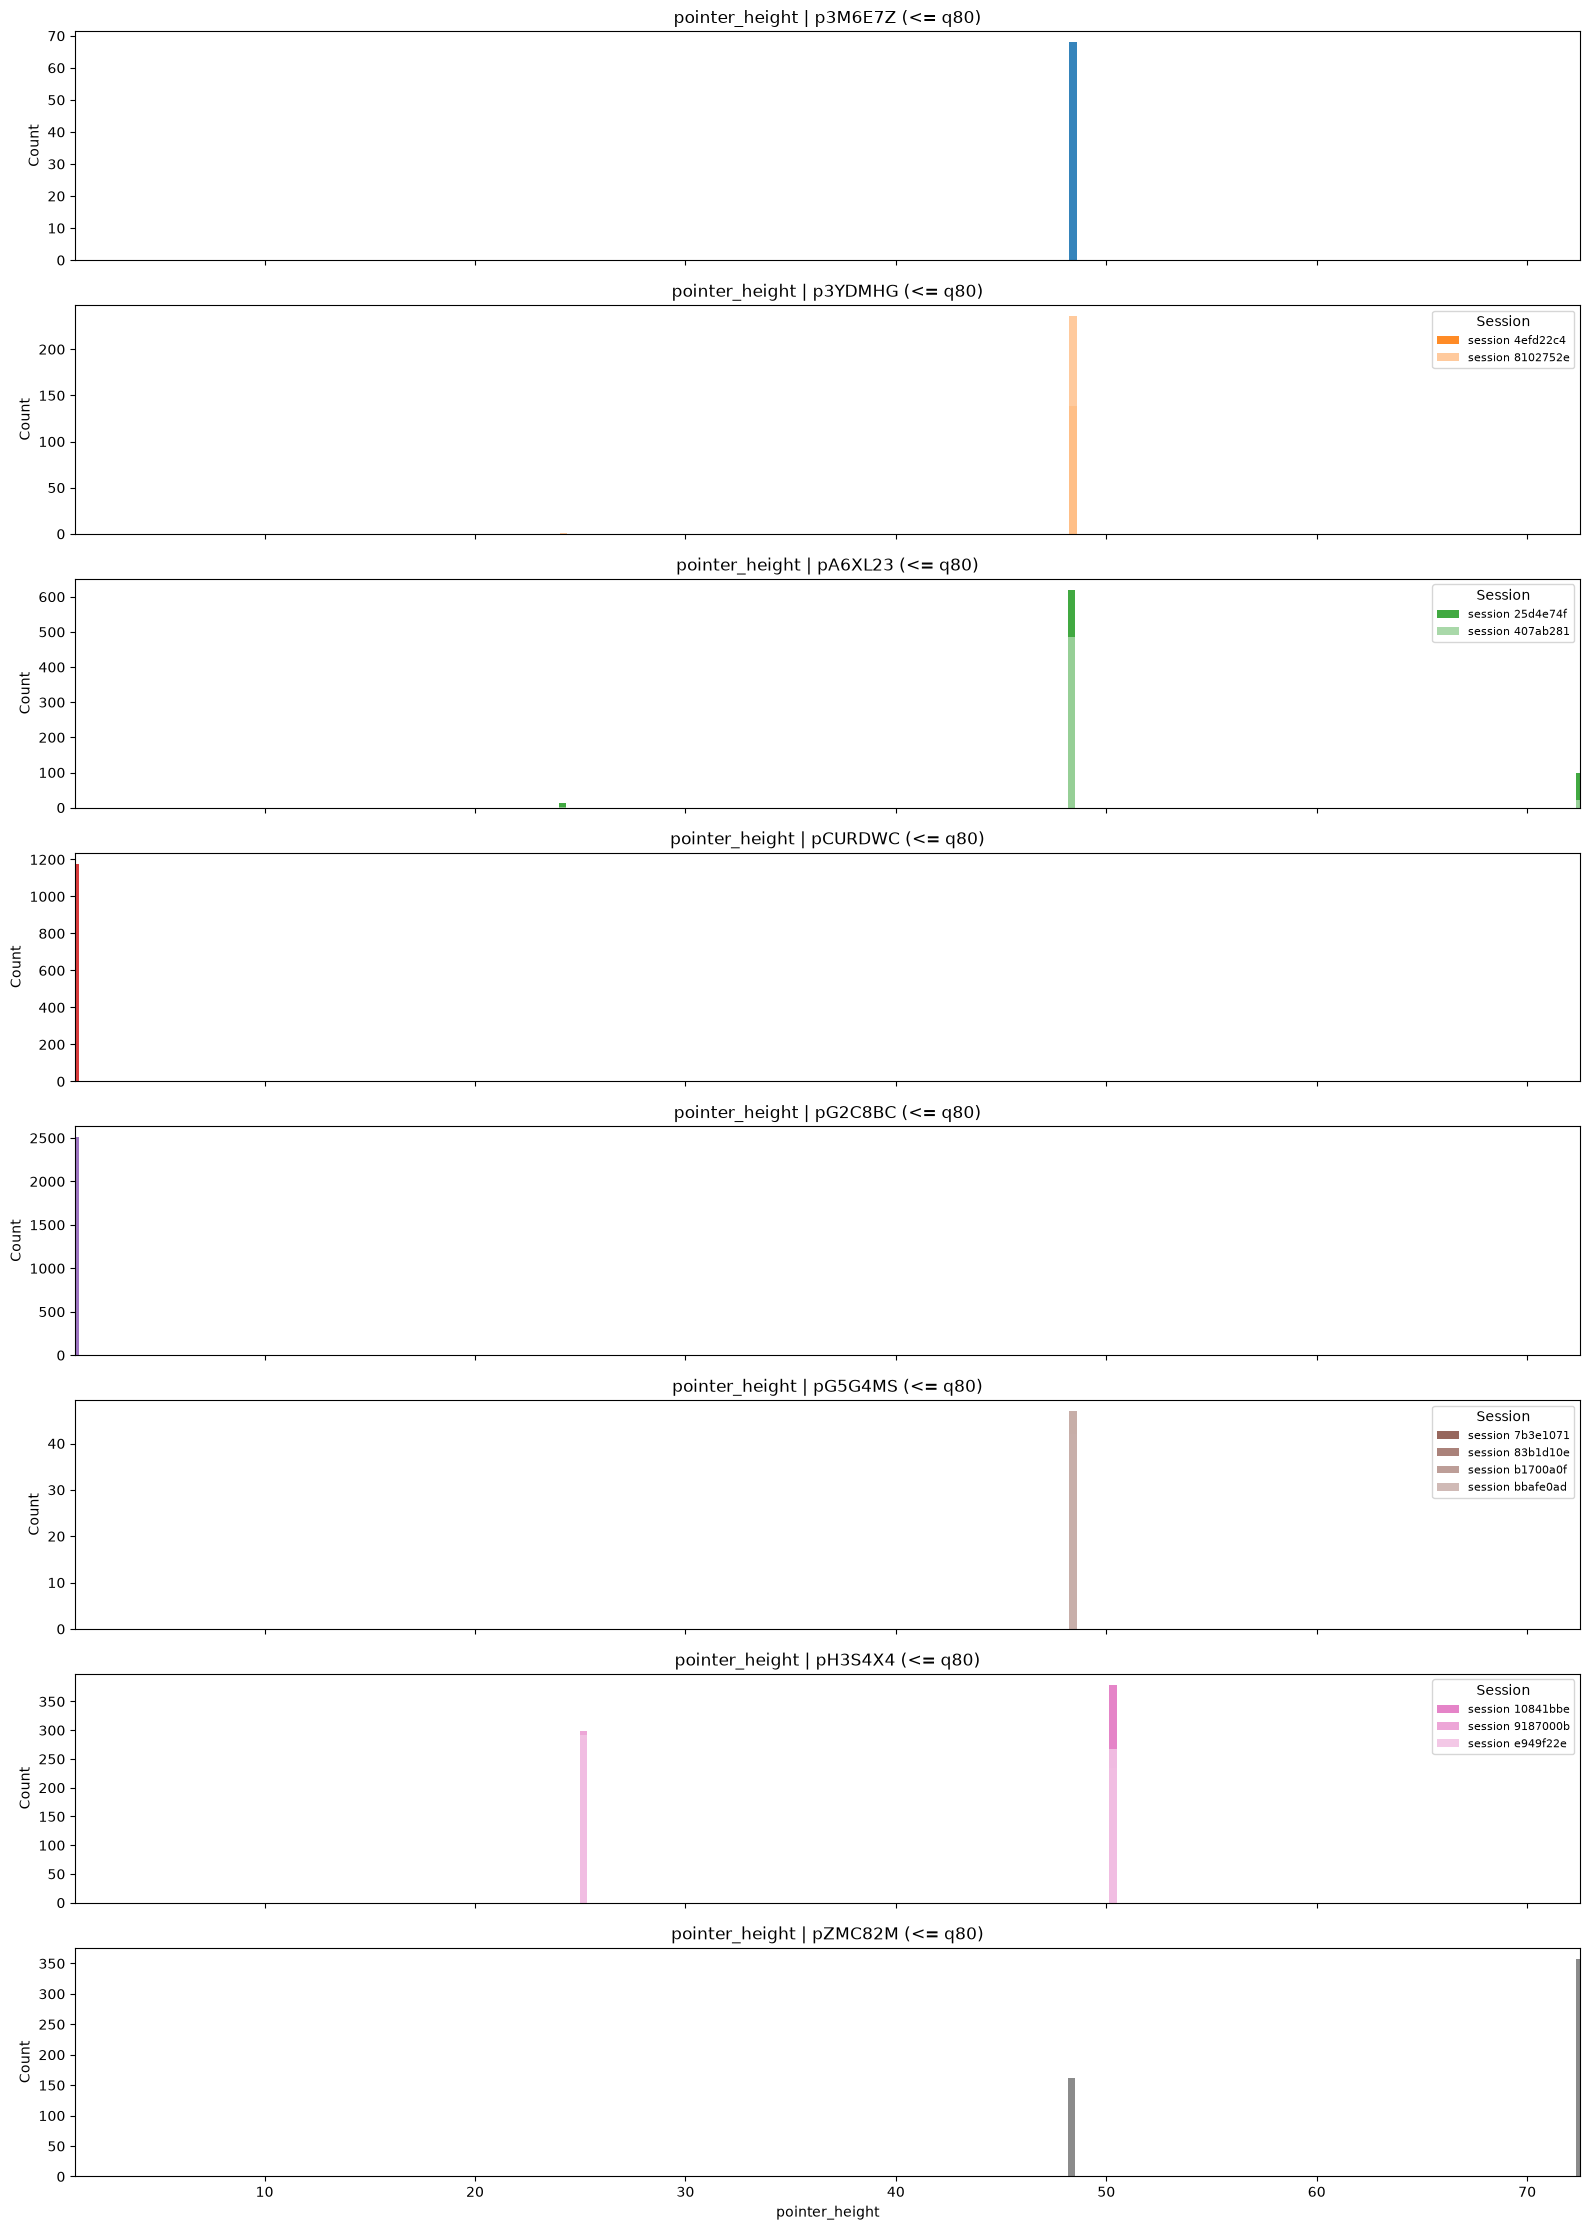

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarni

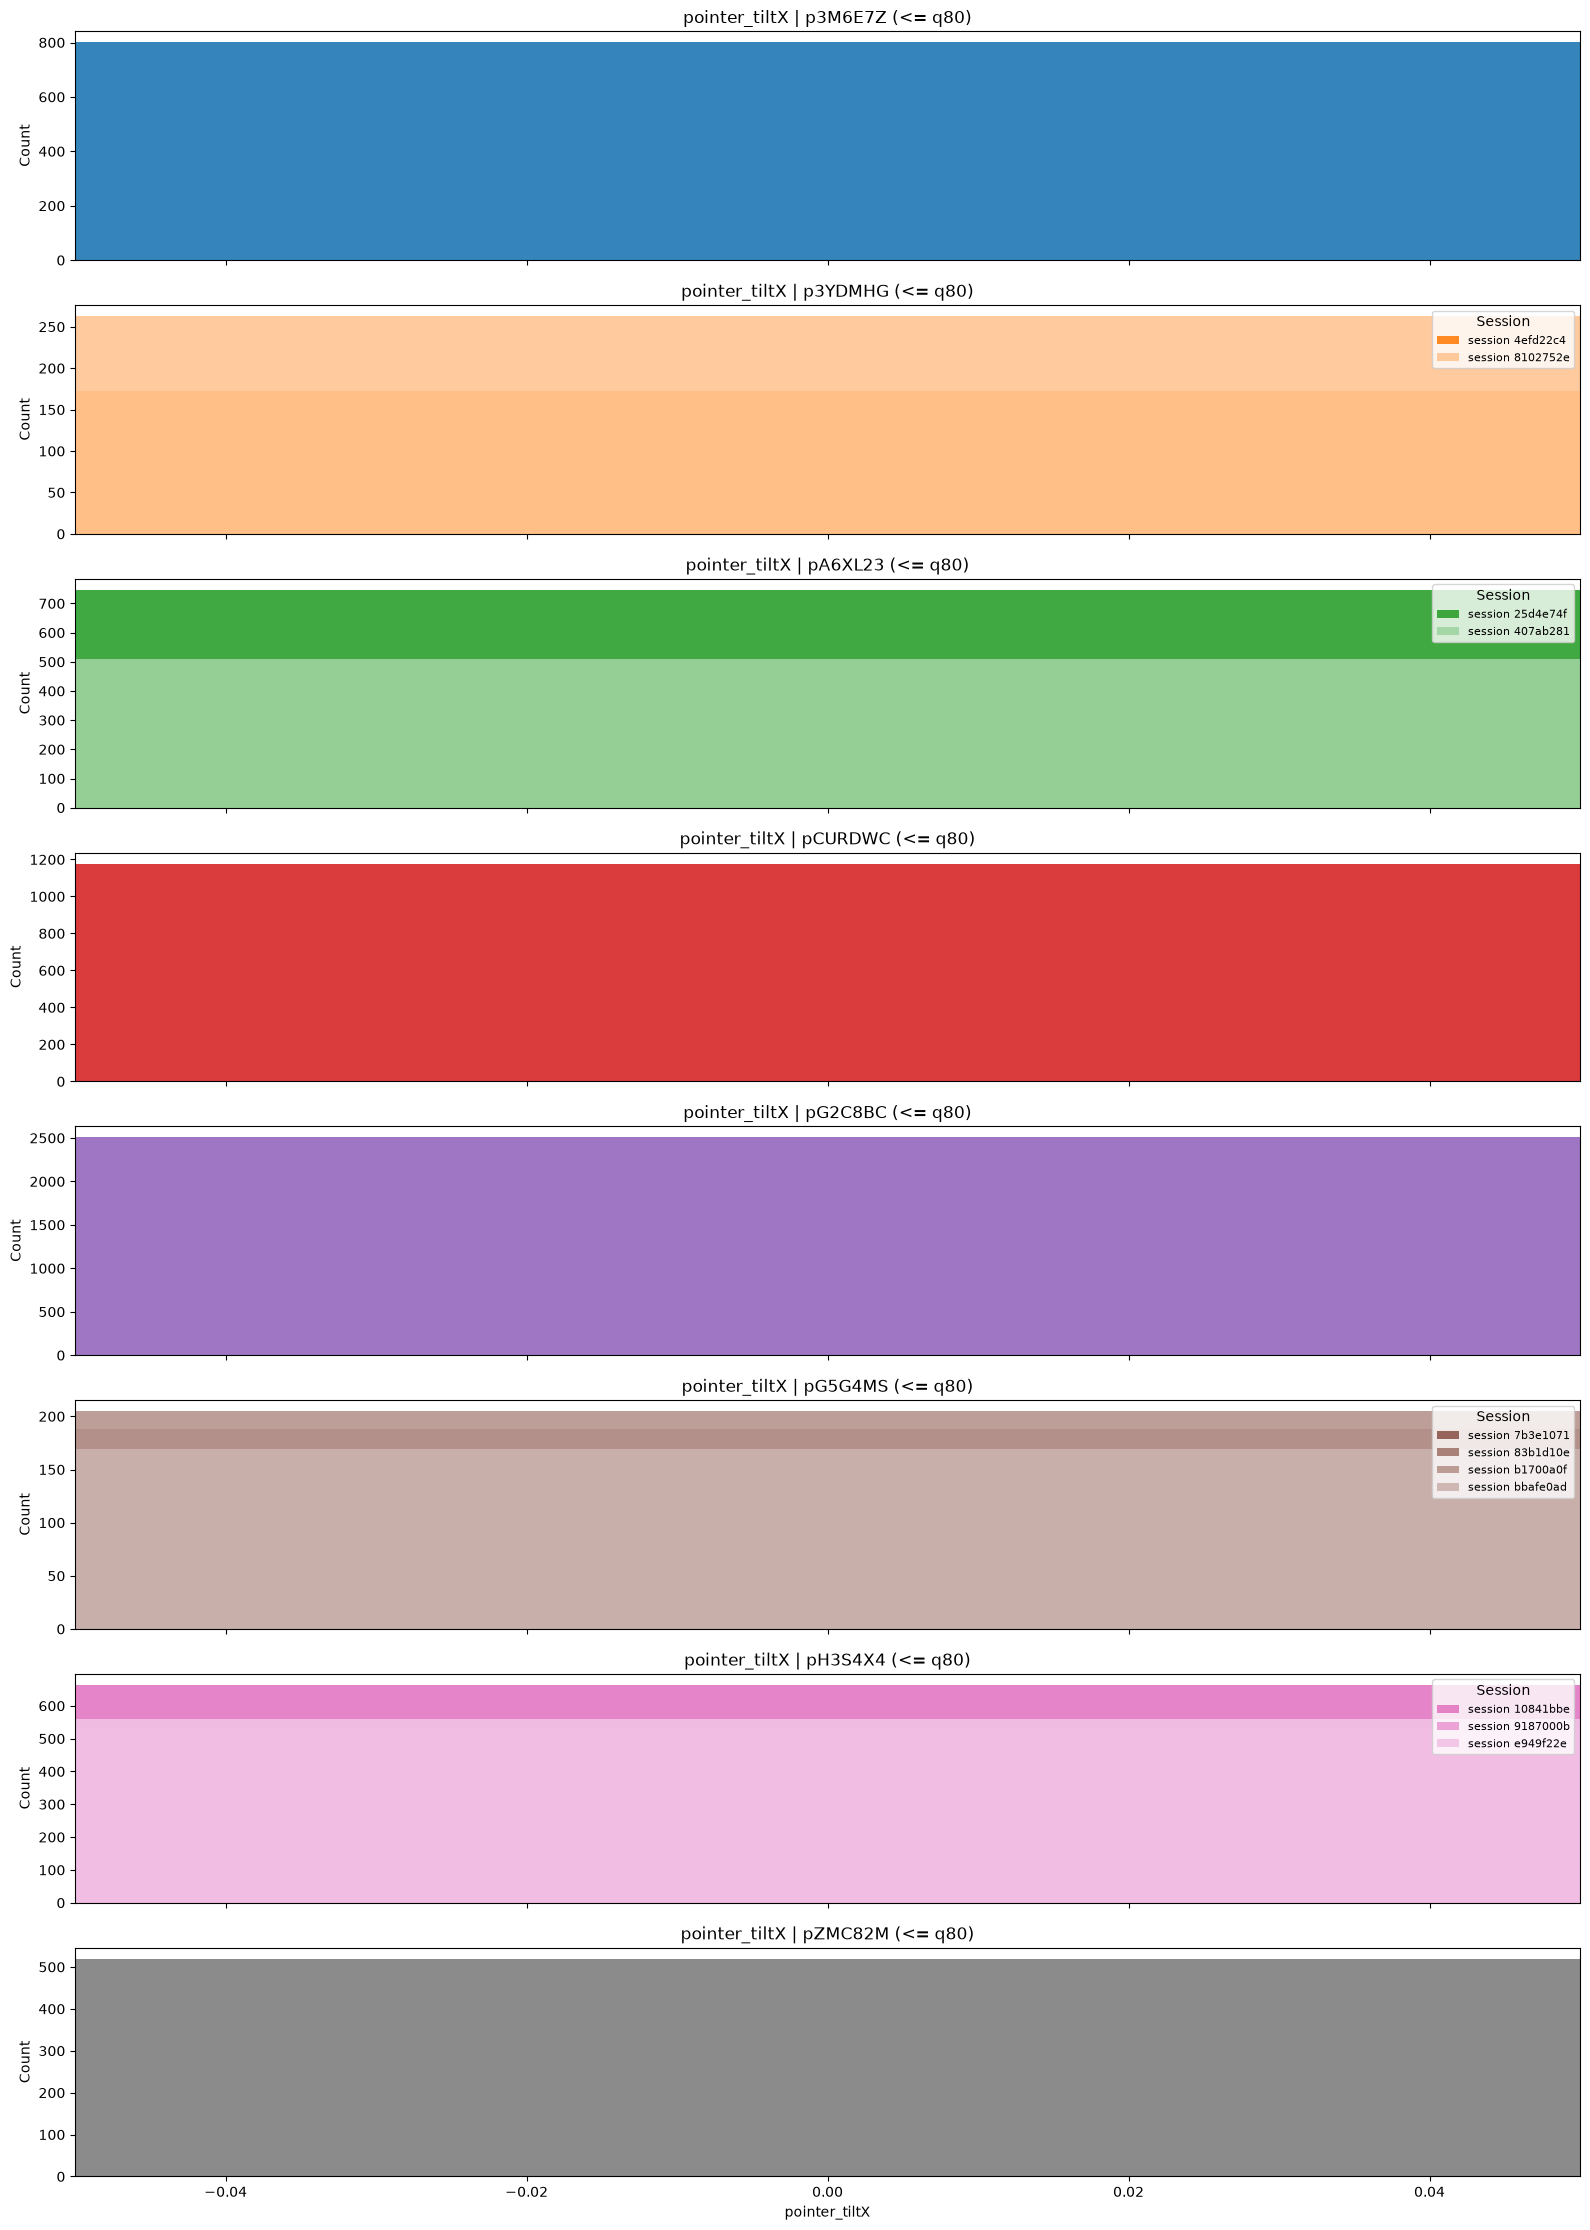

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarni

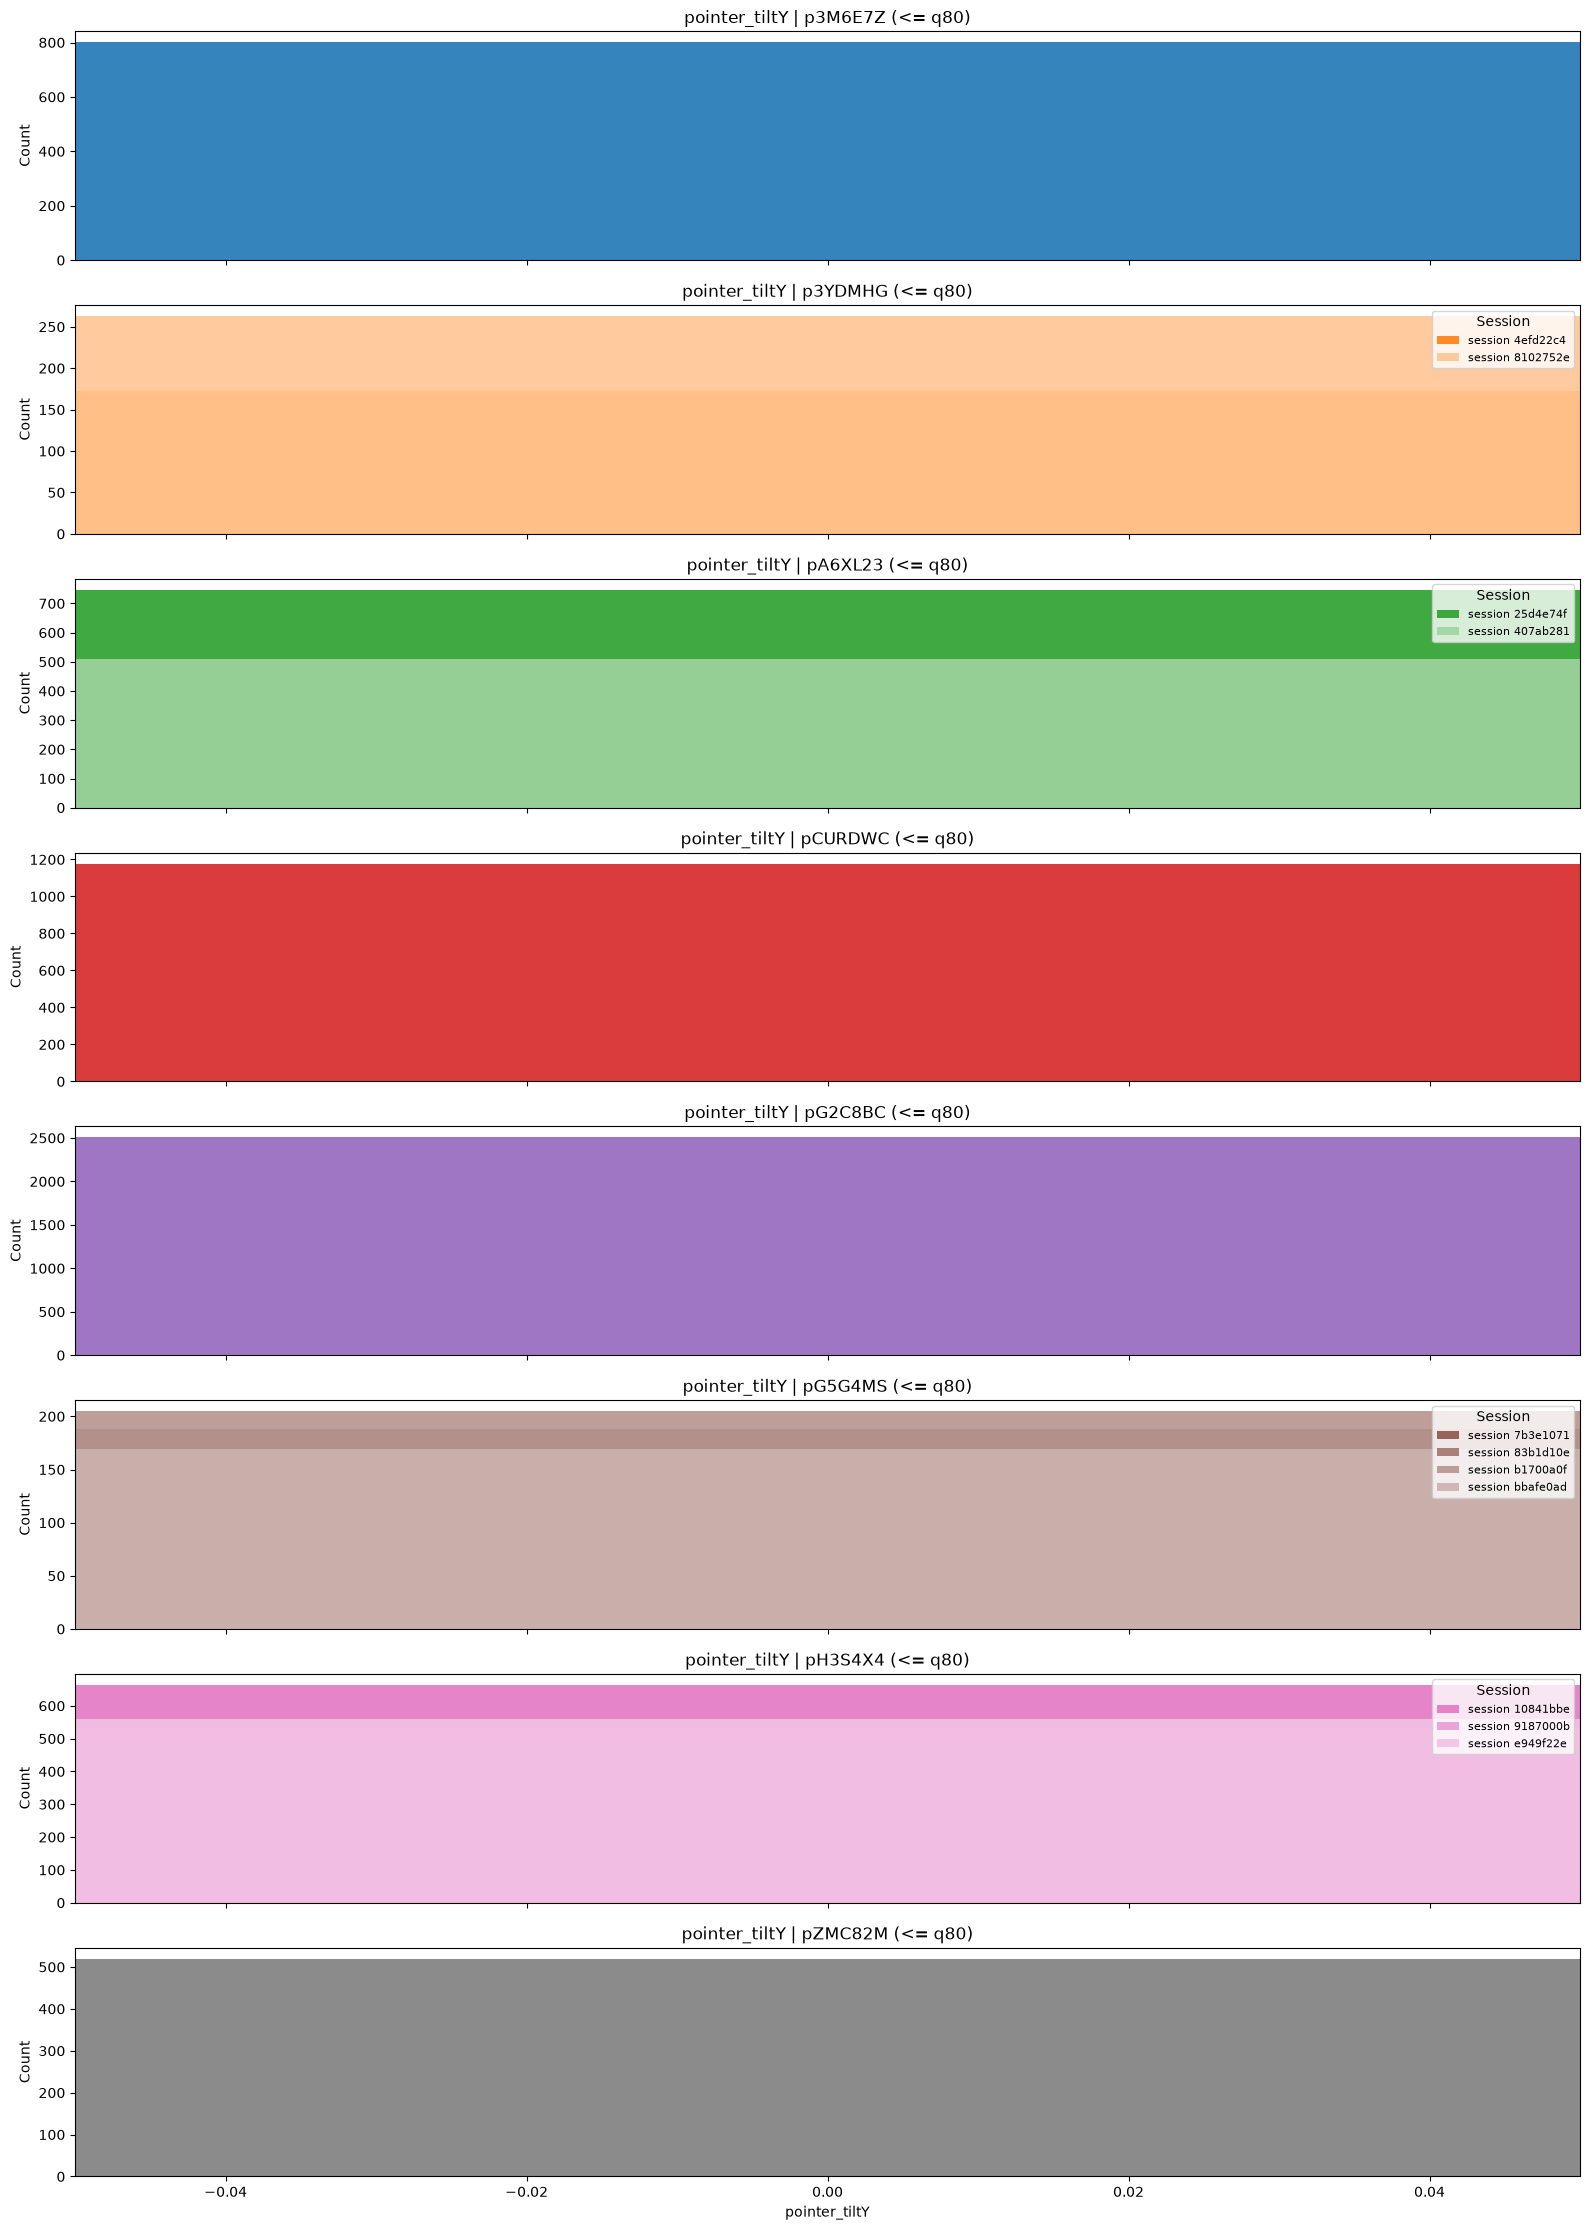

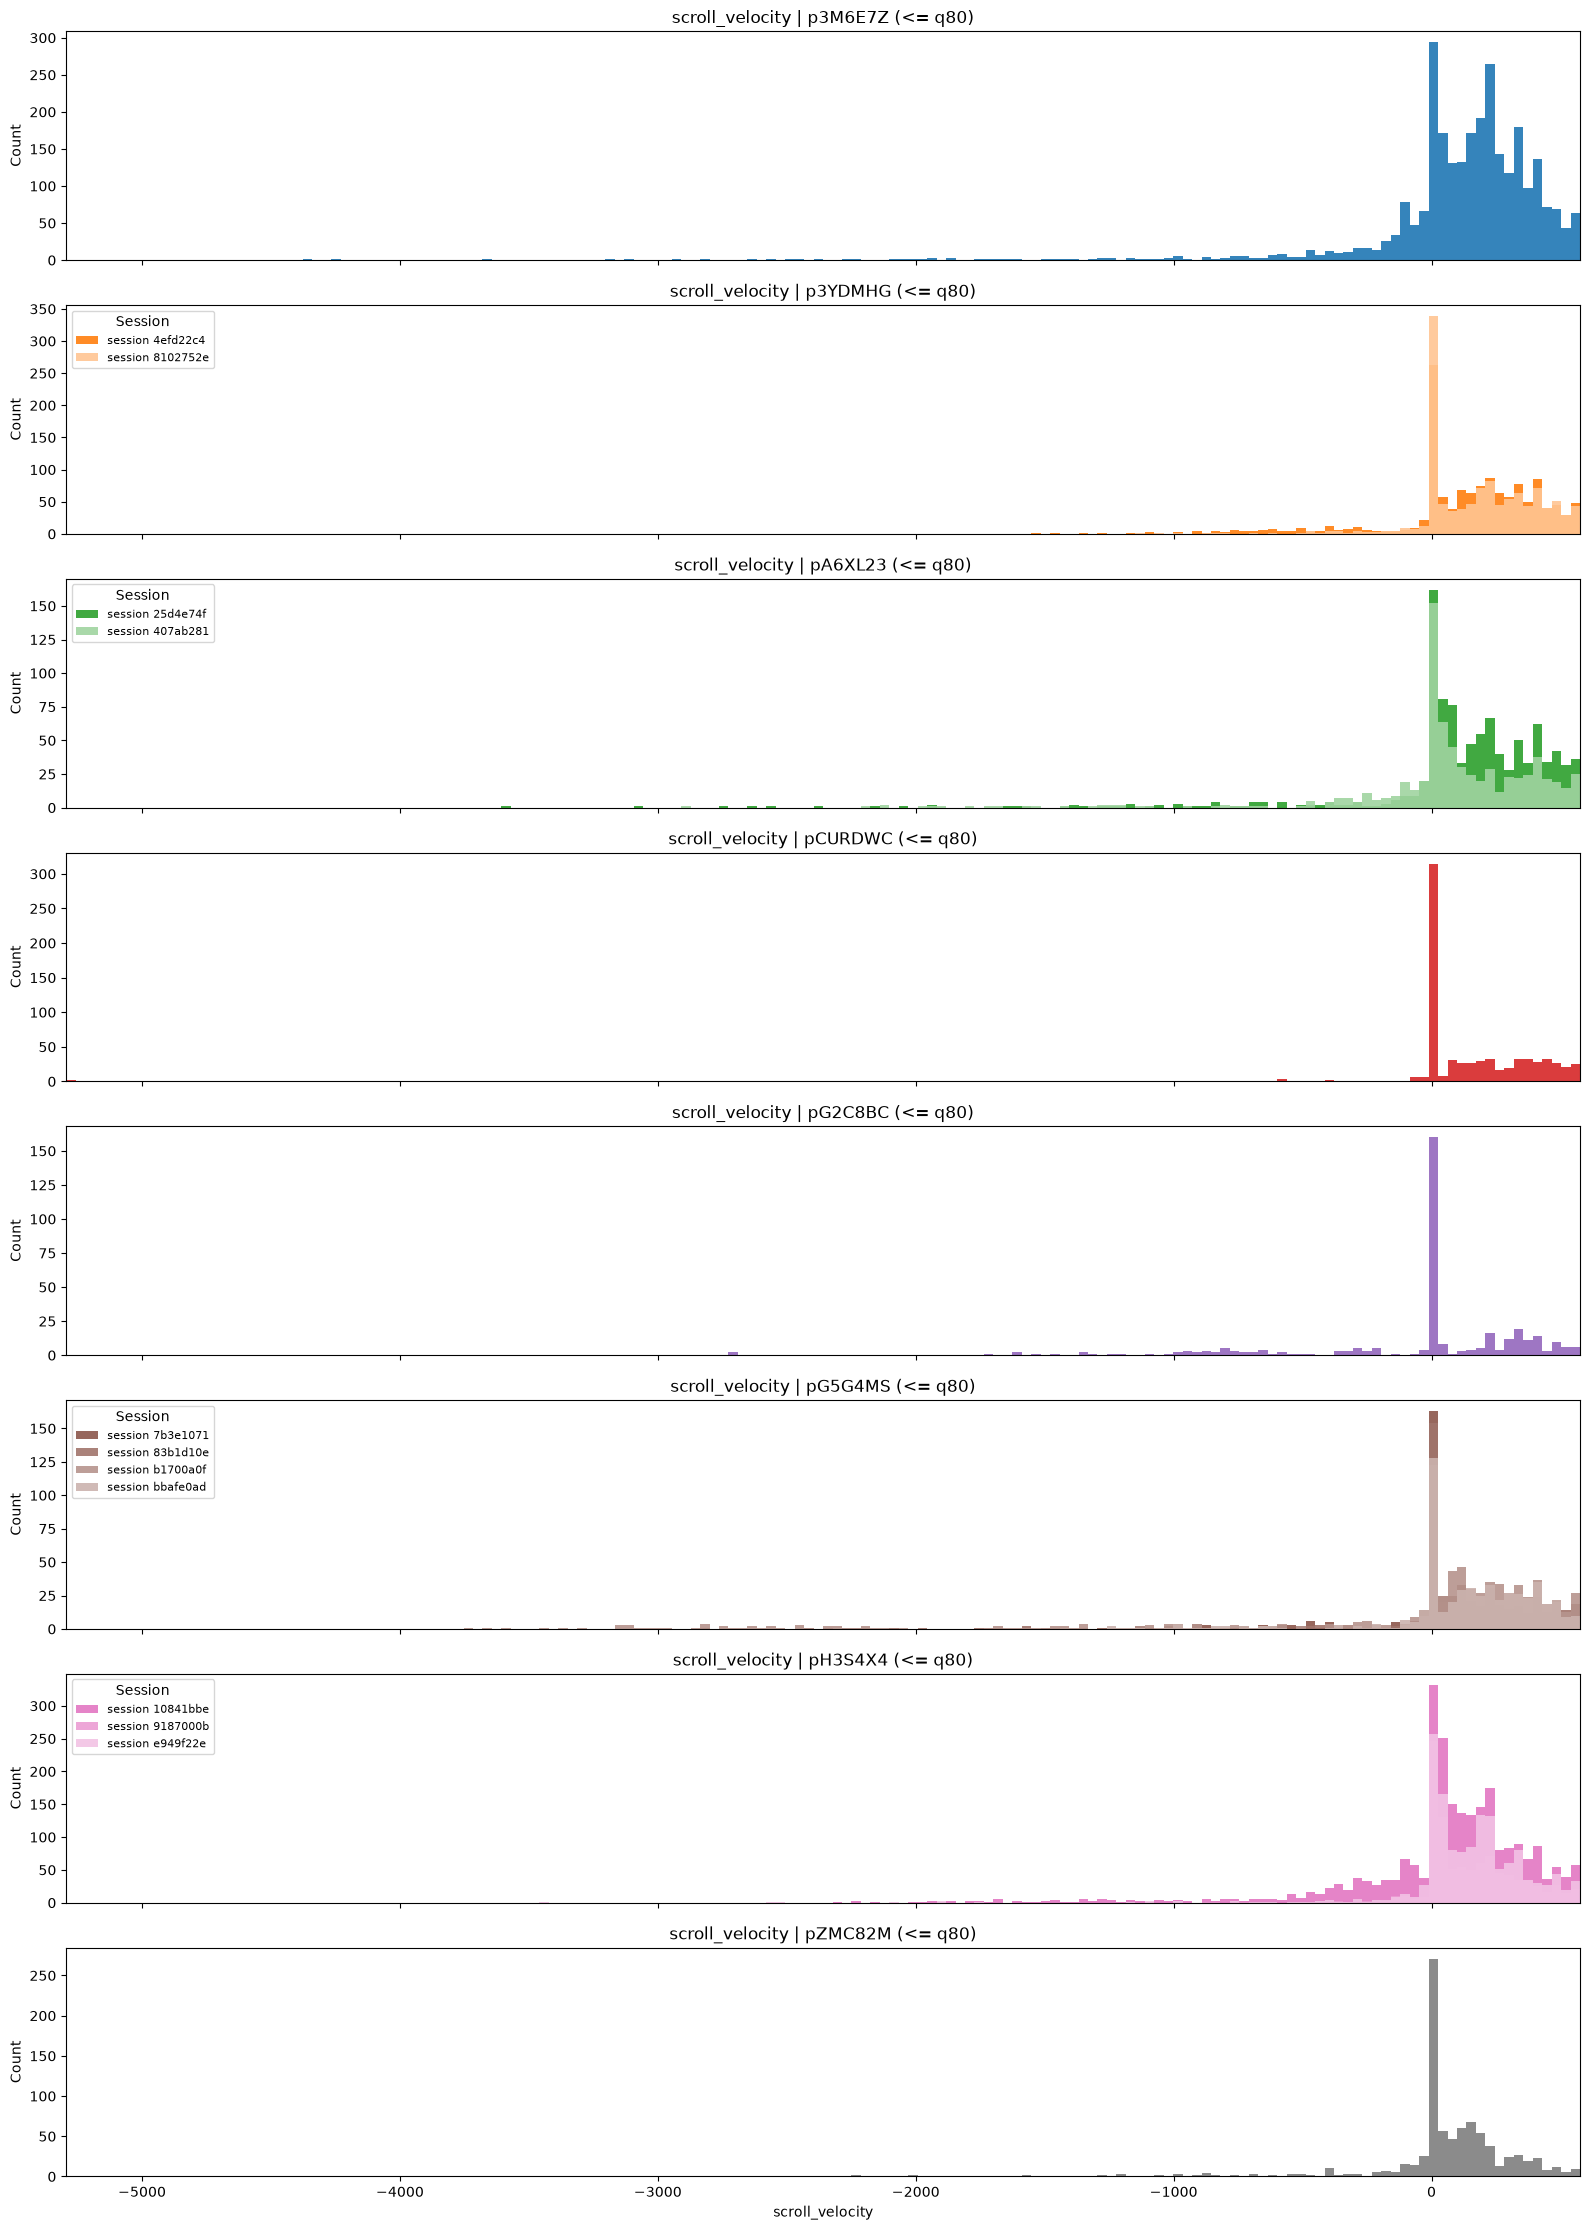

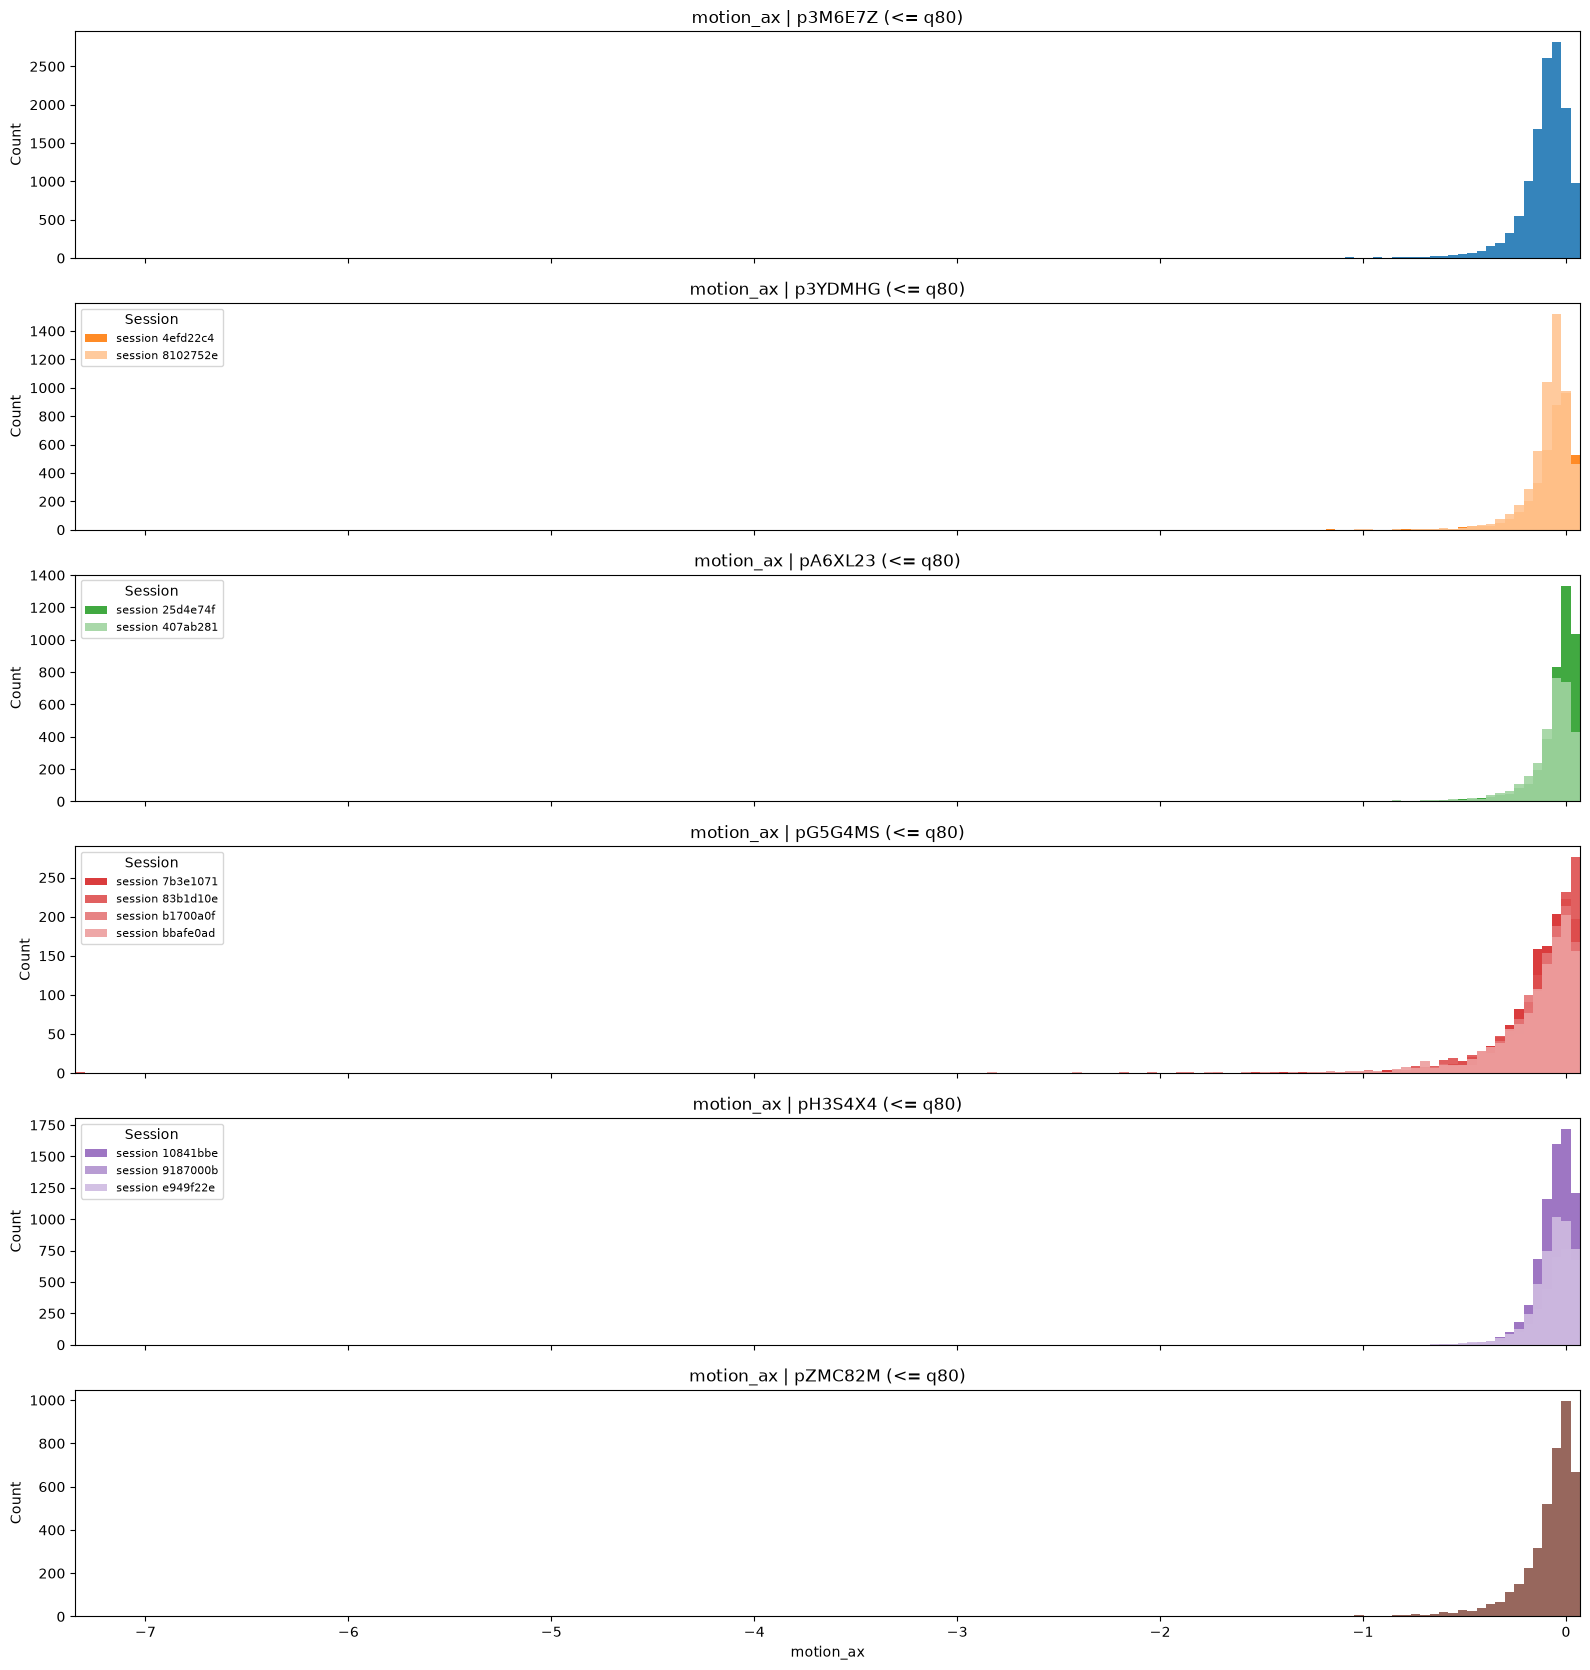

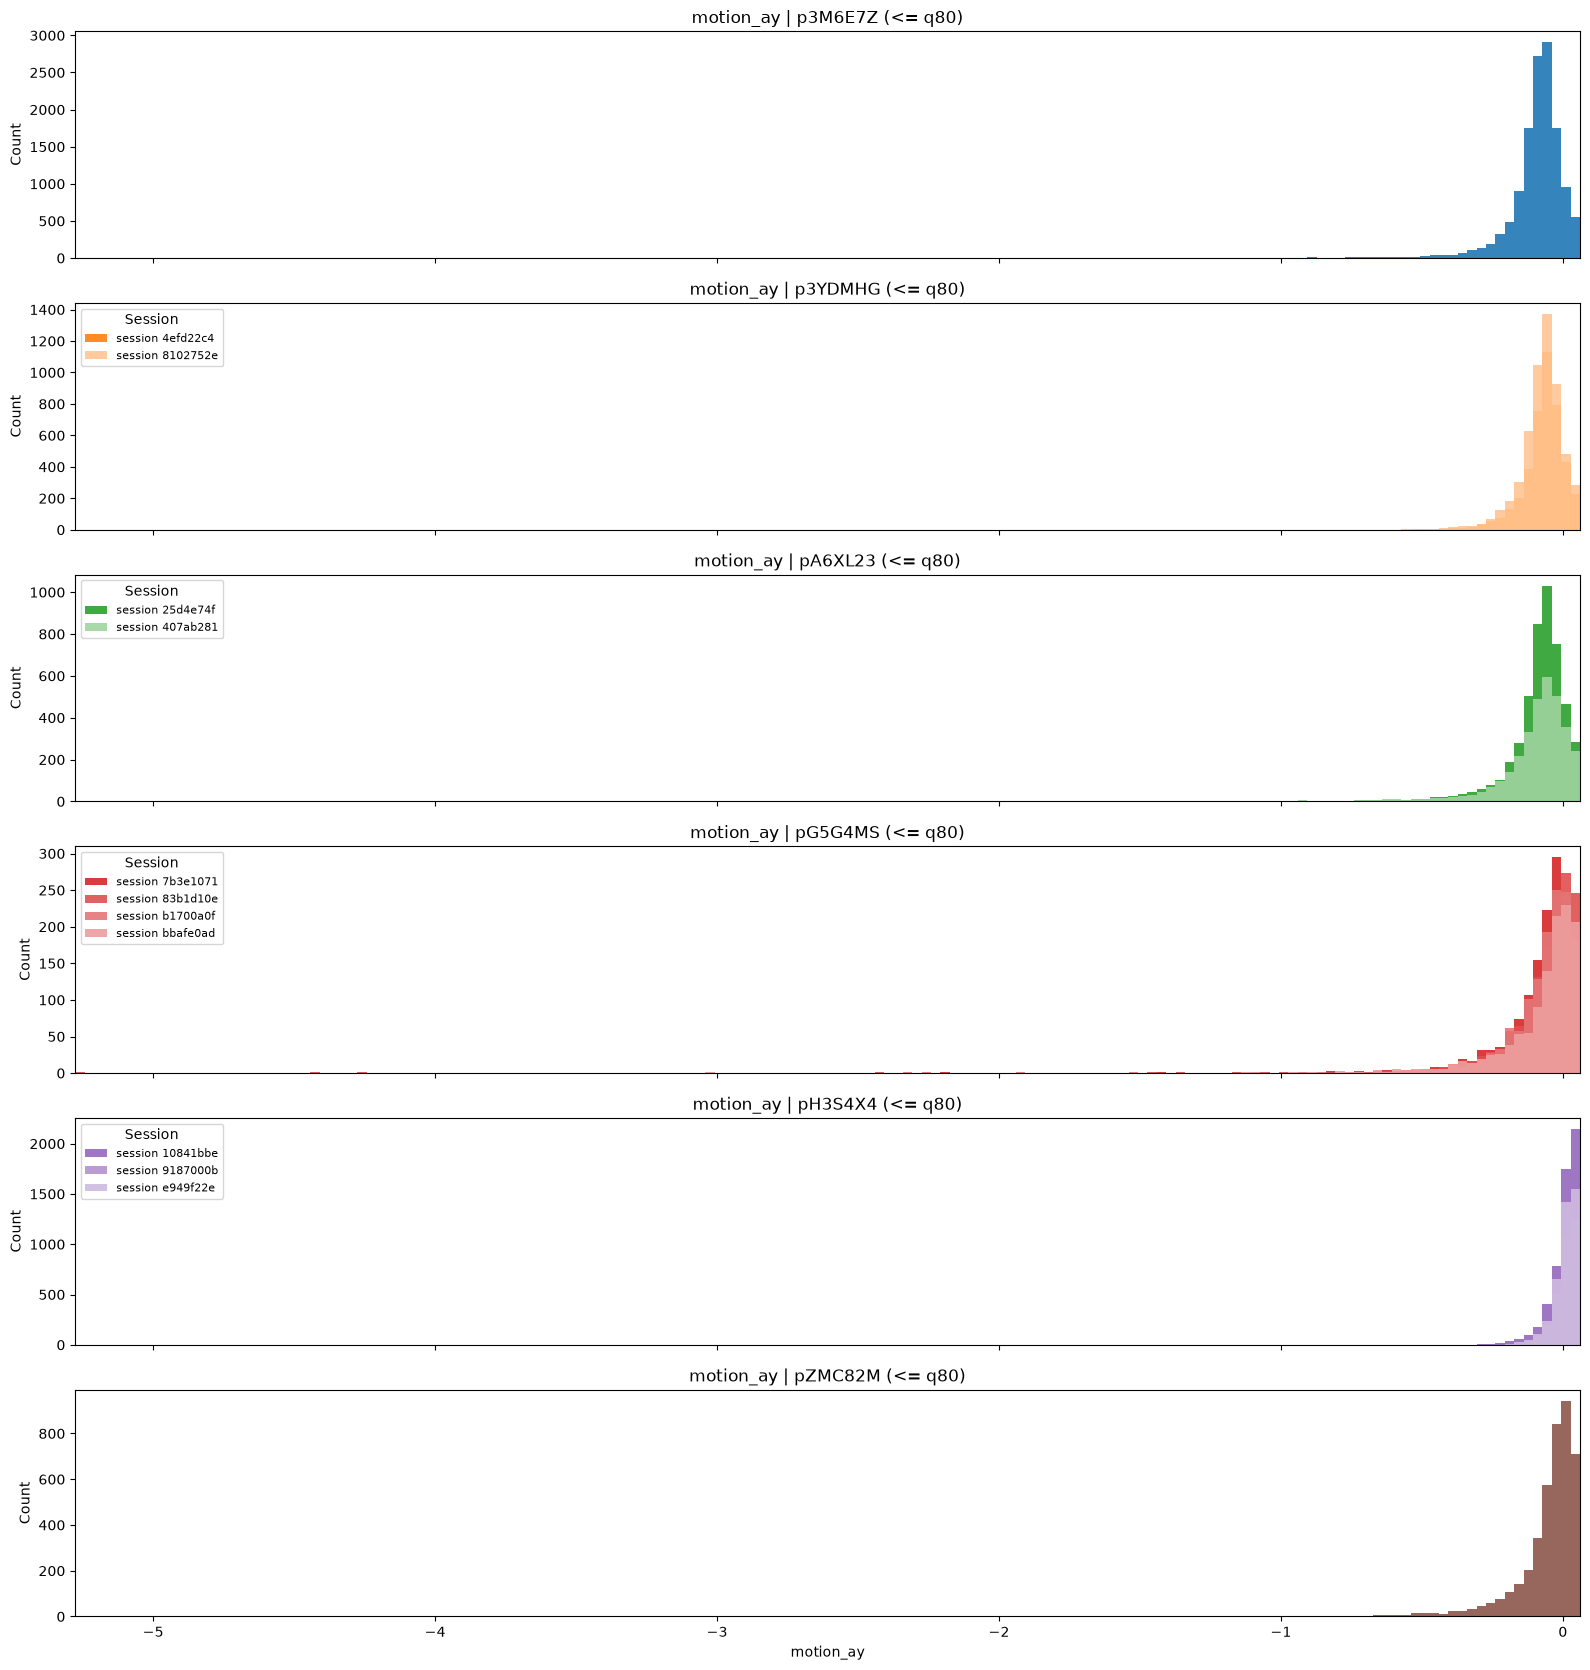

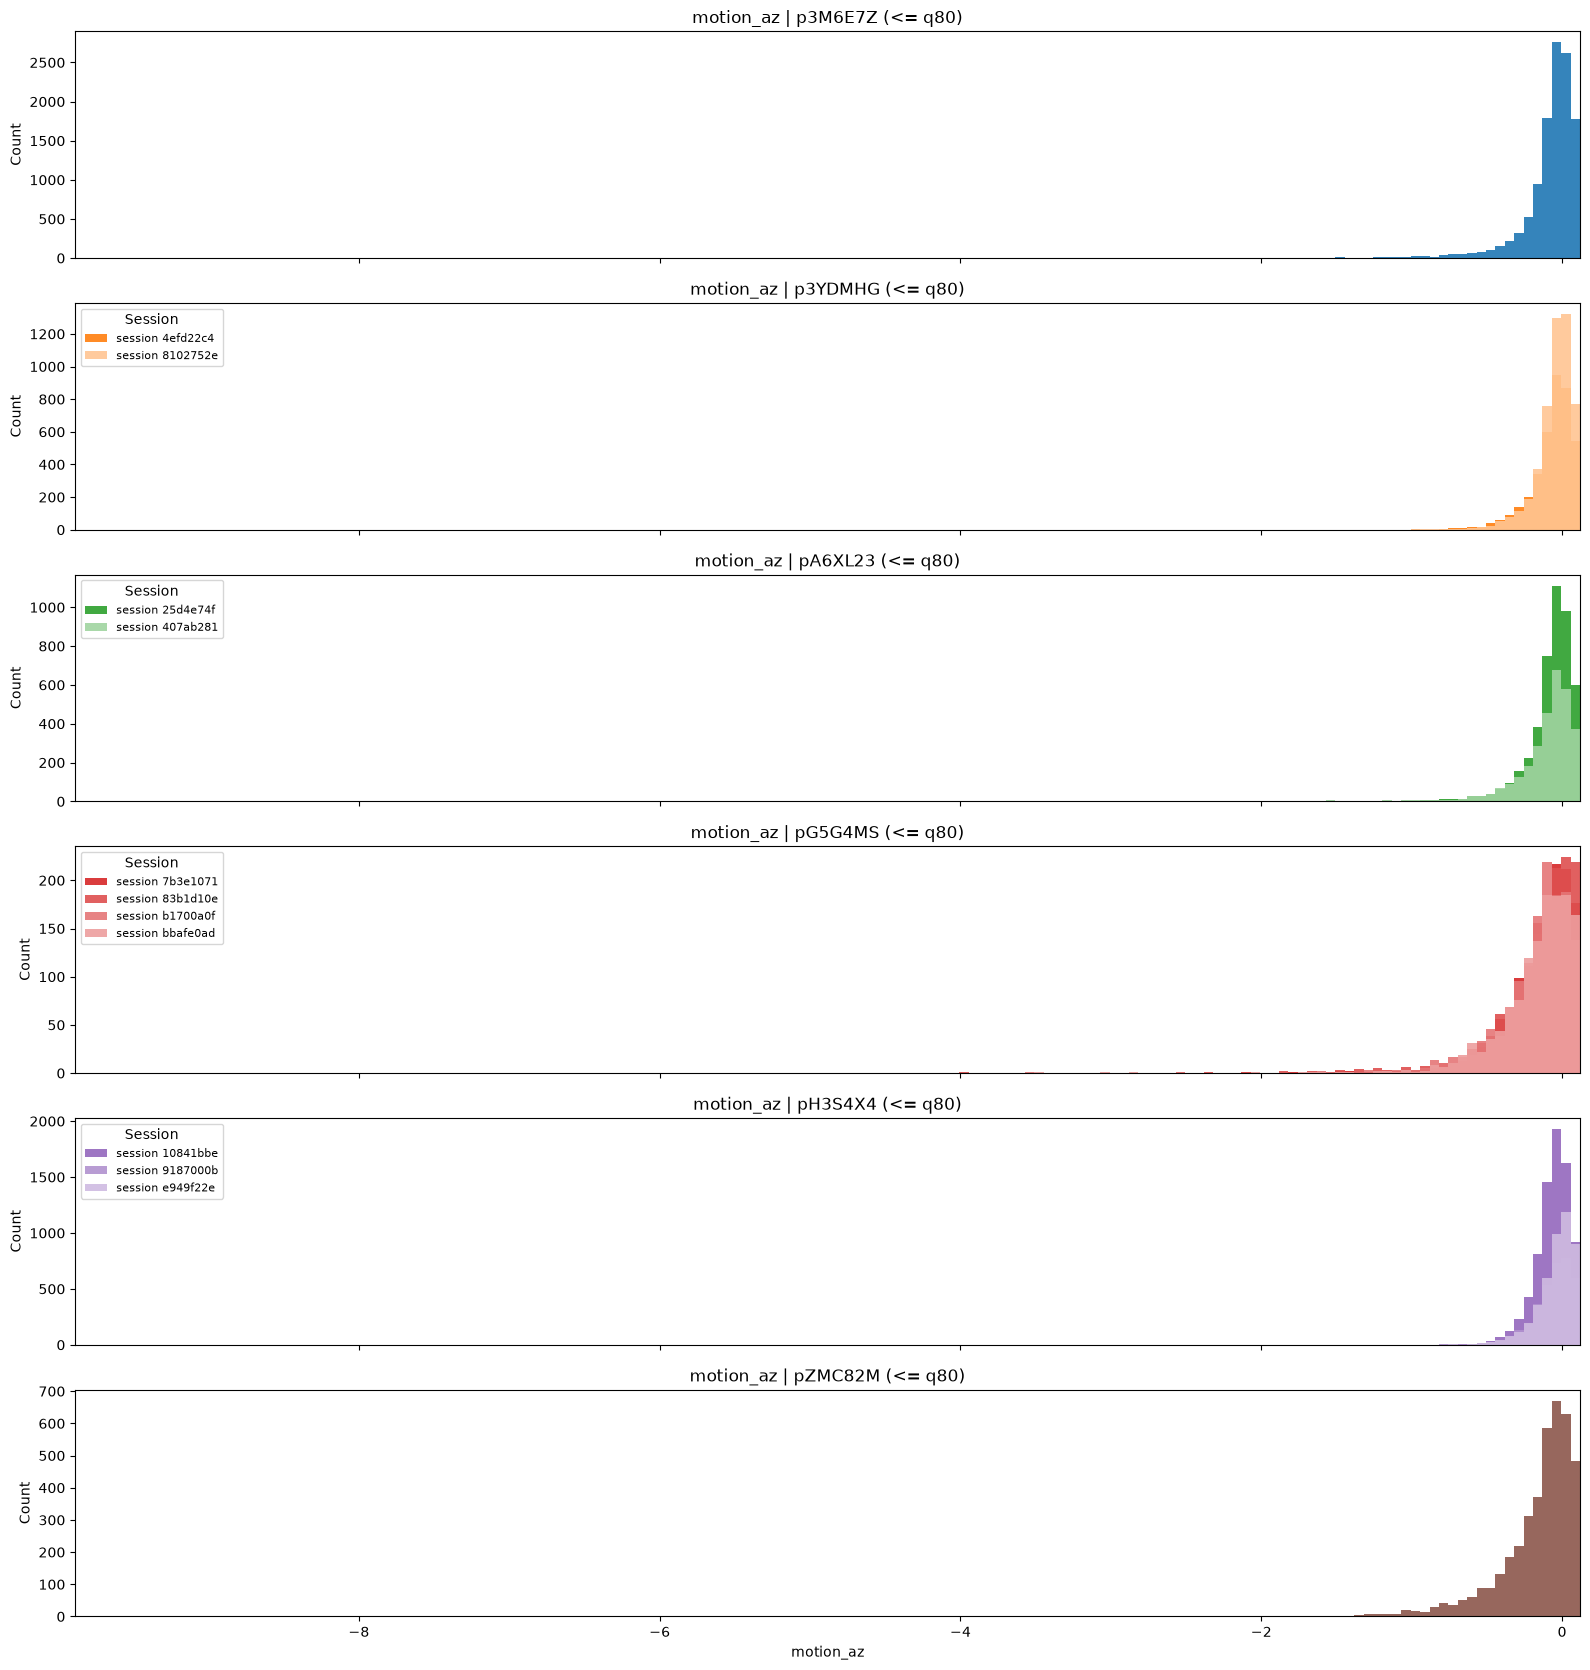

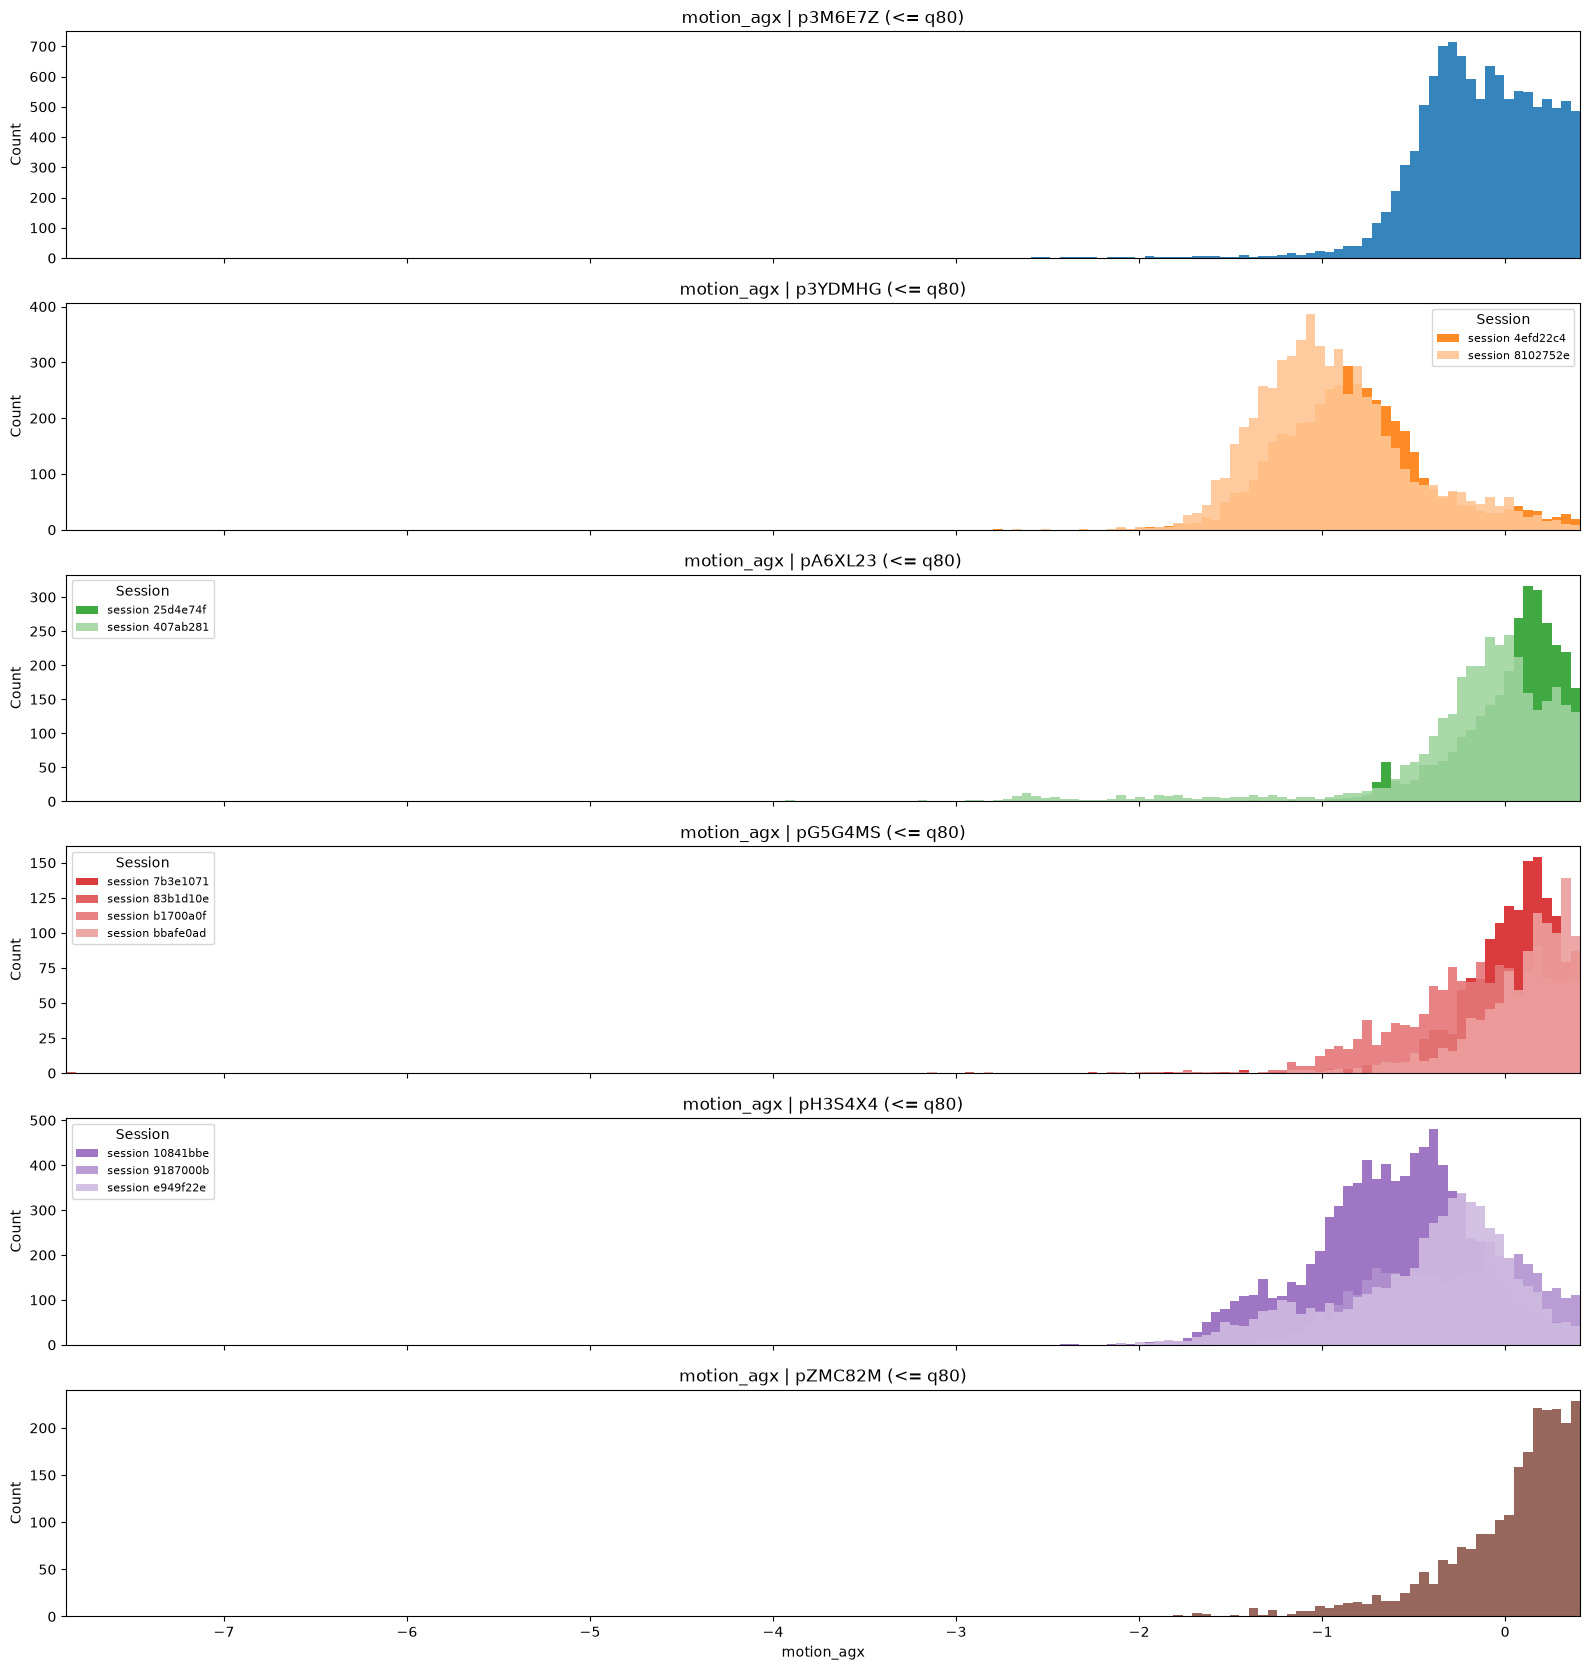

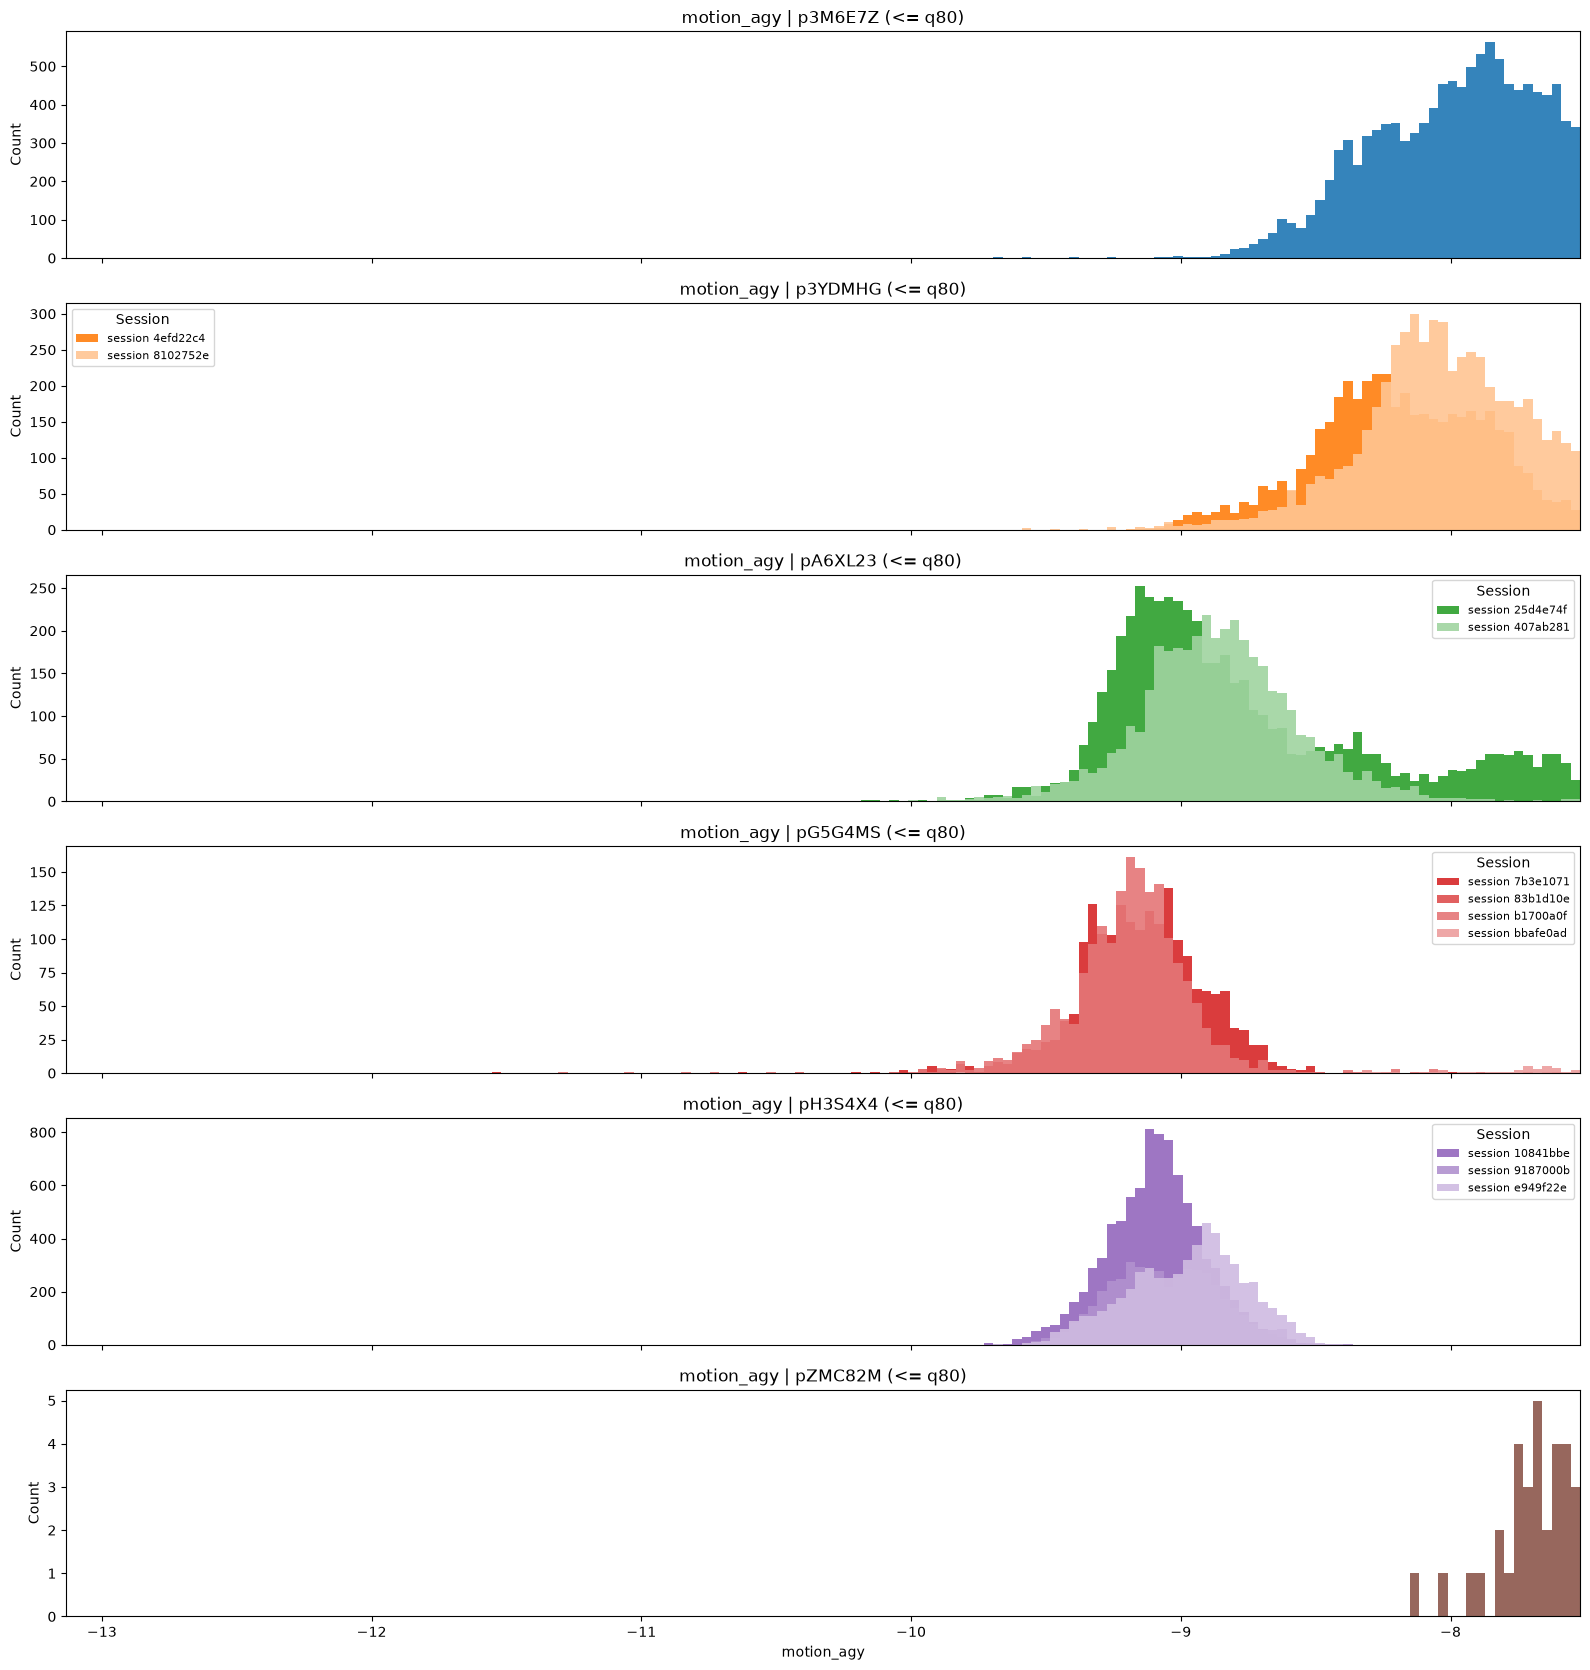

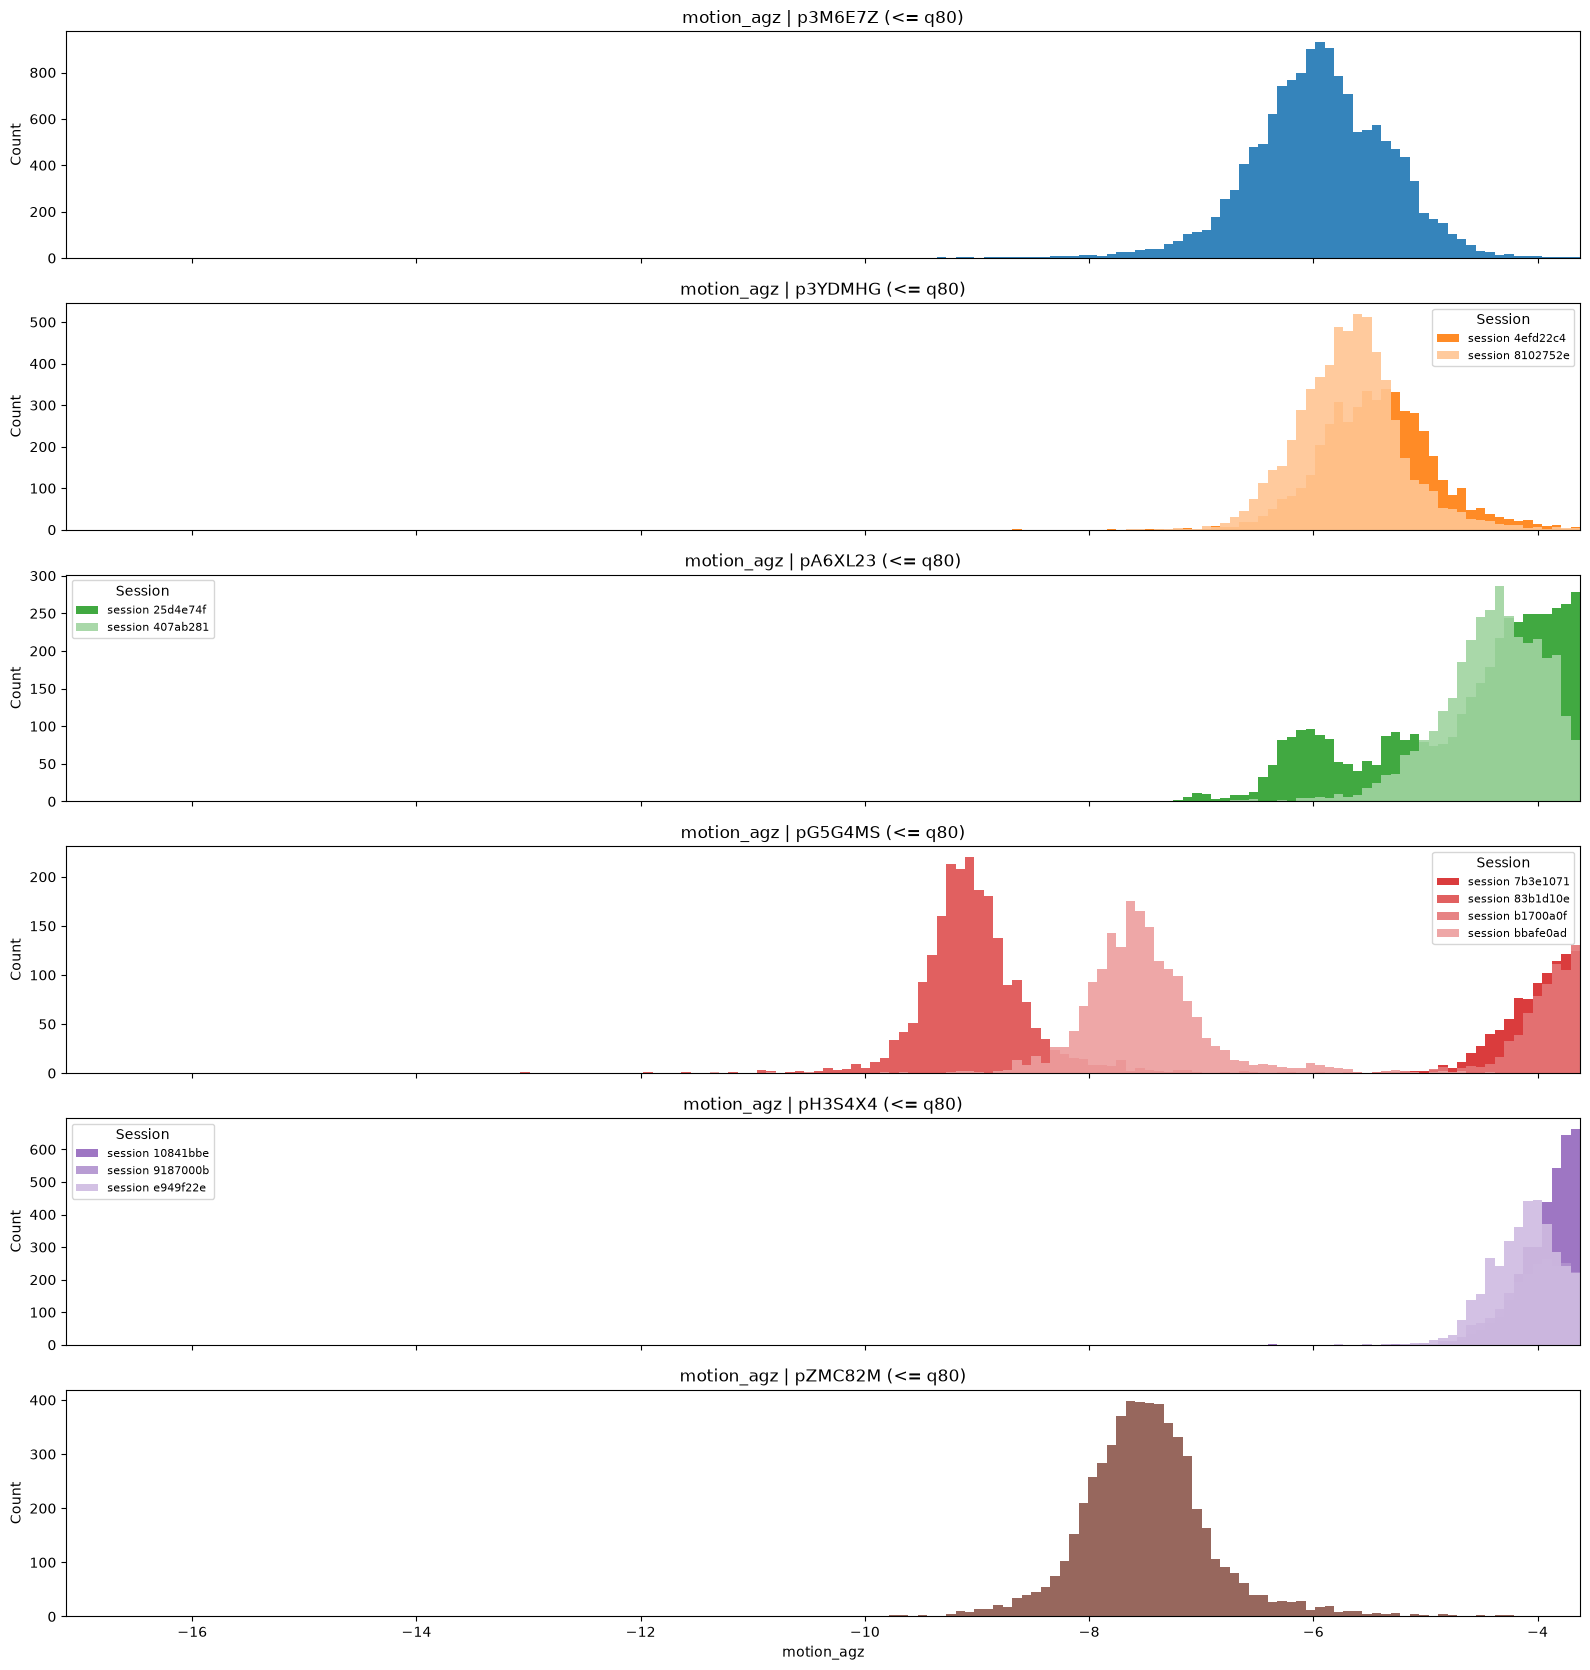

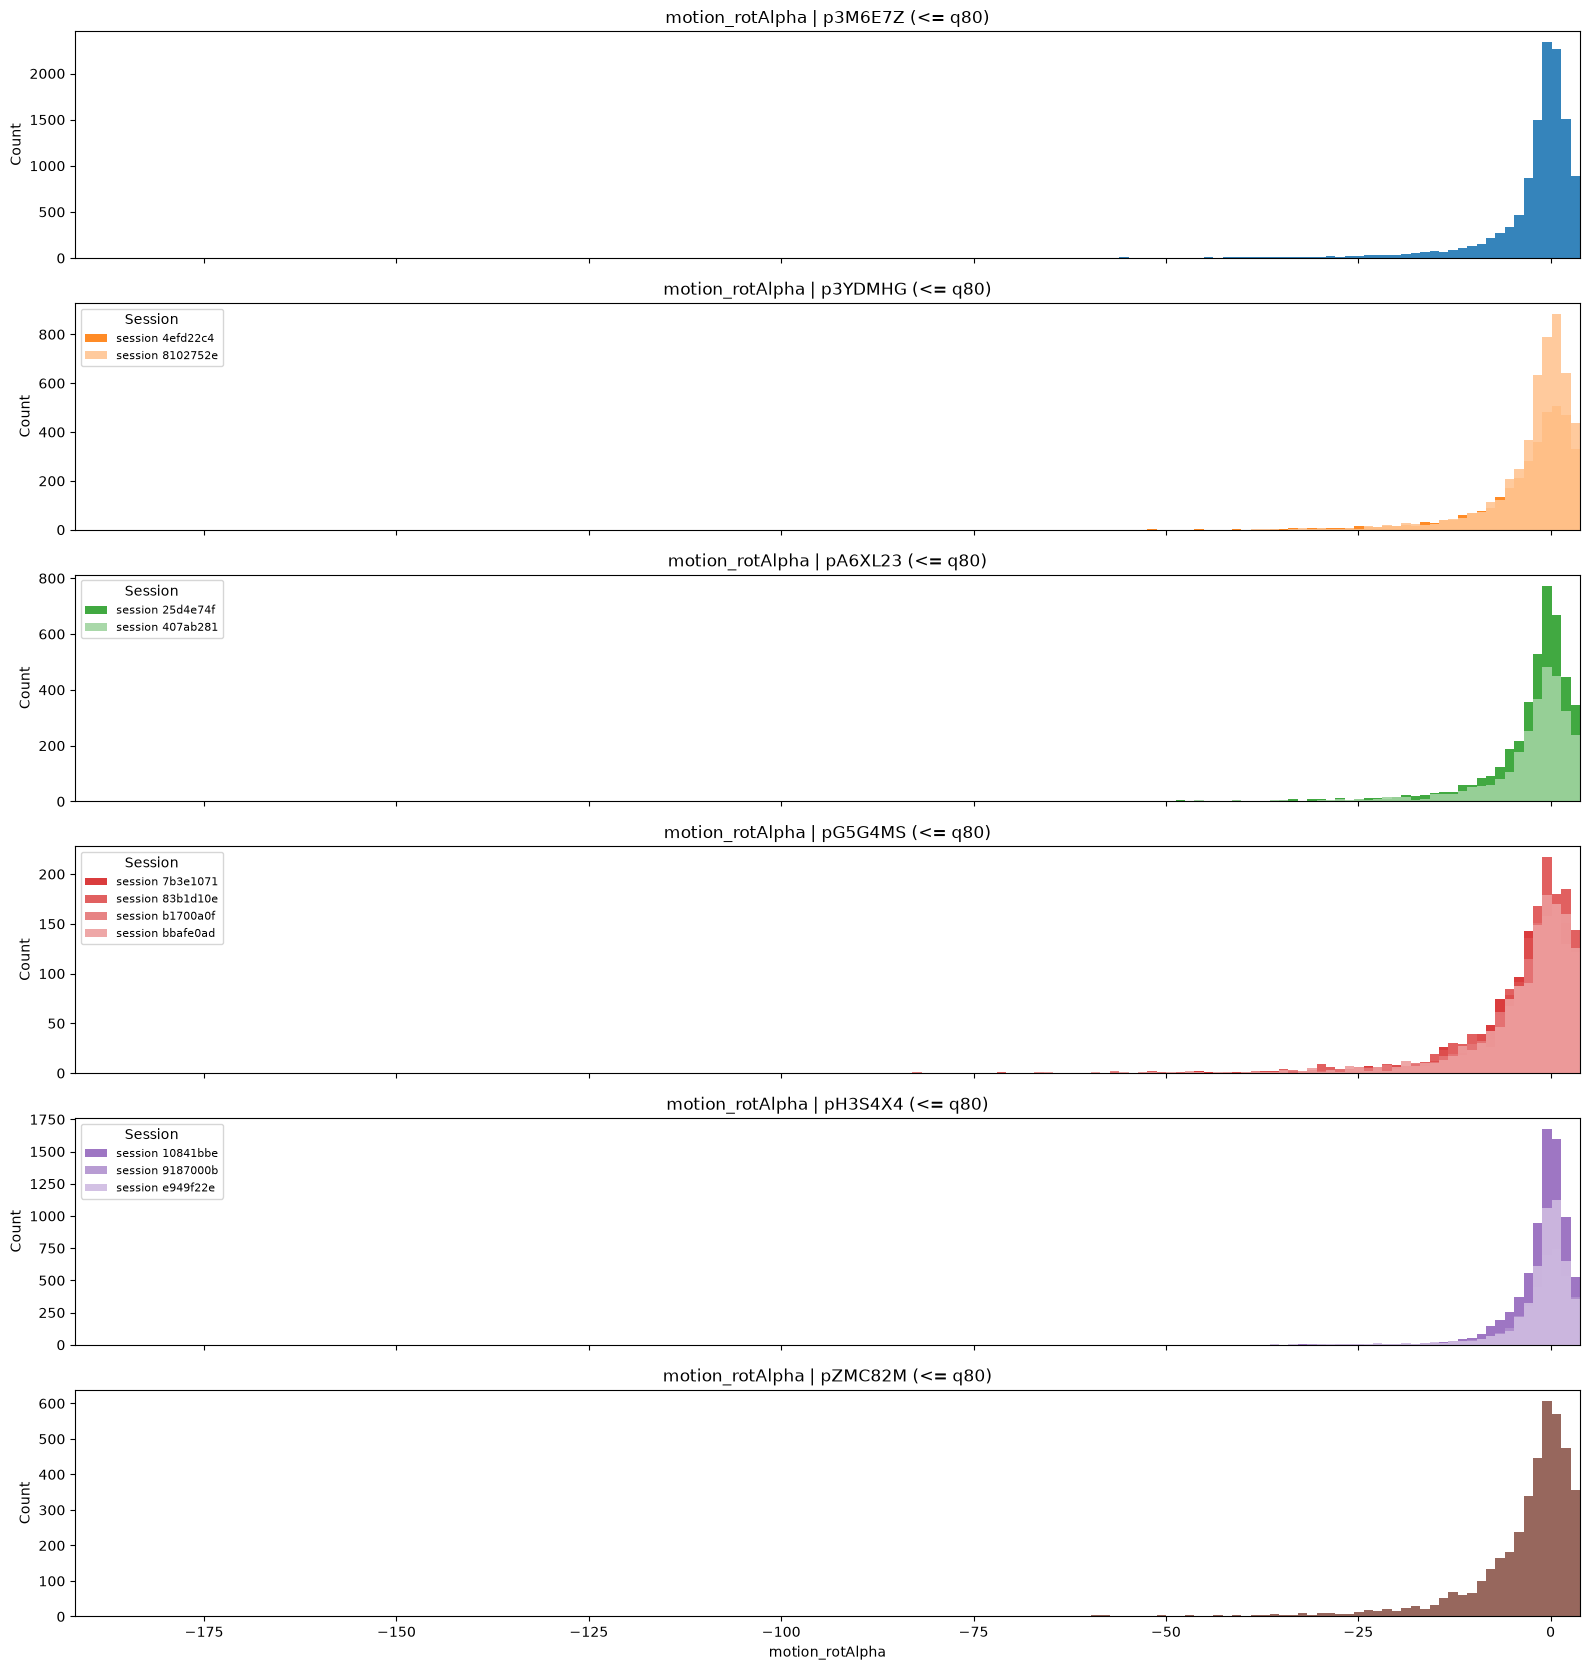

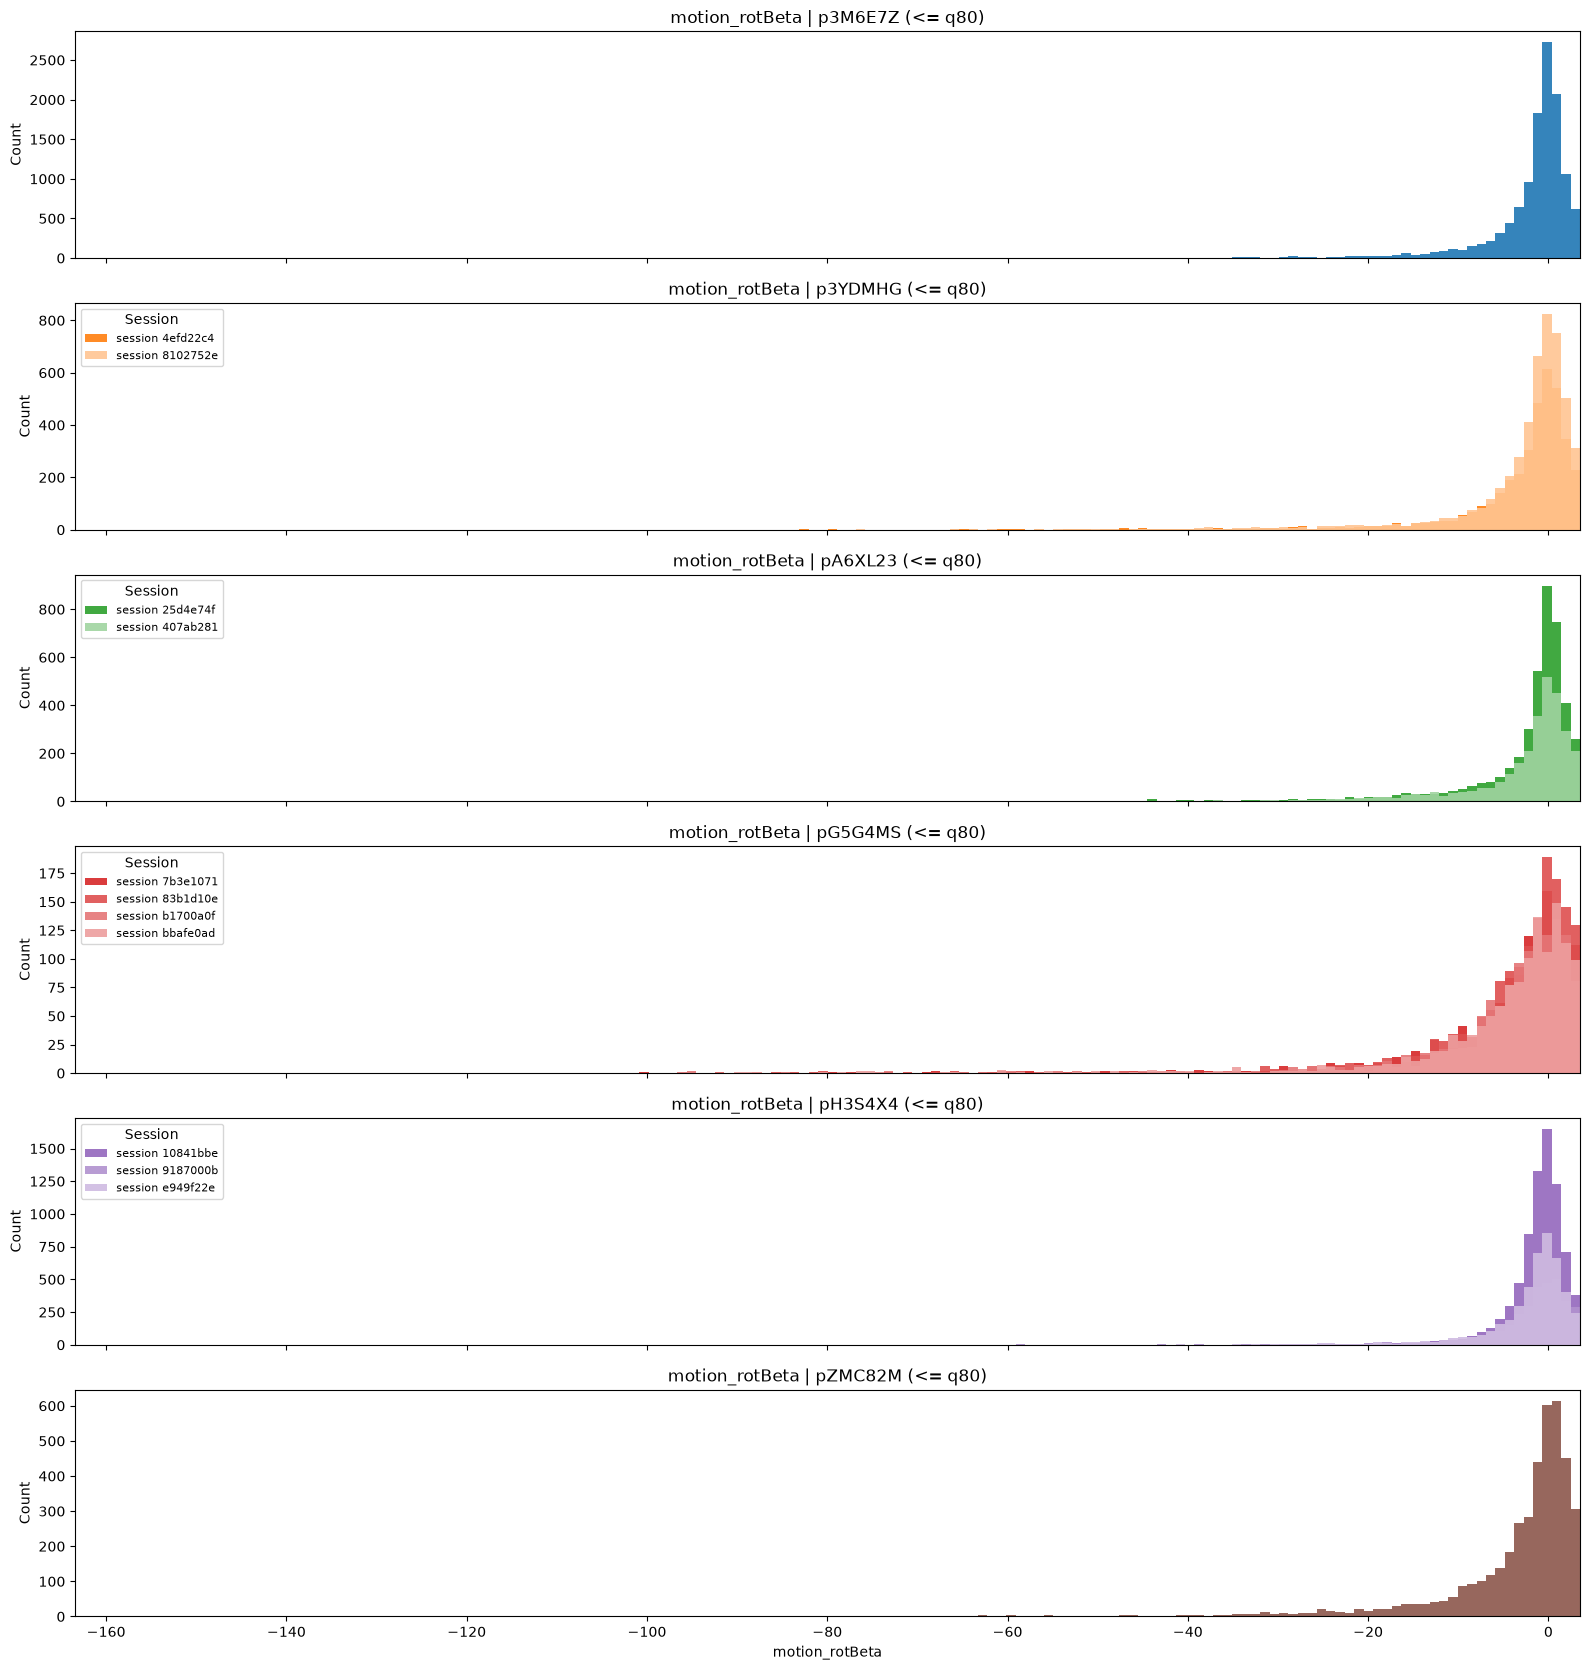

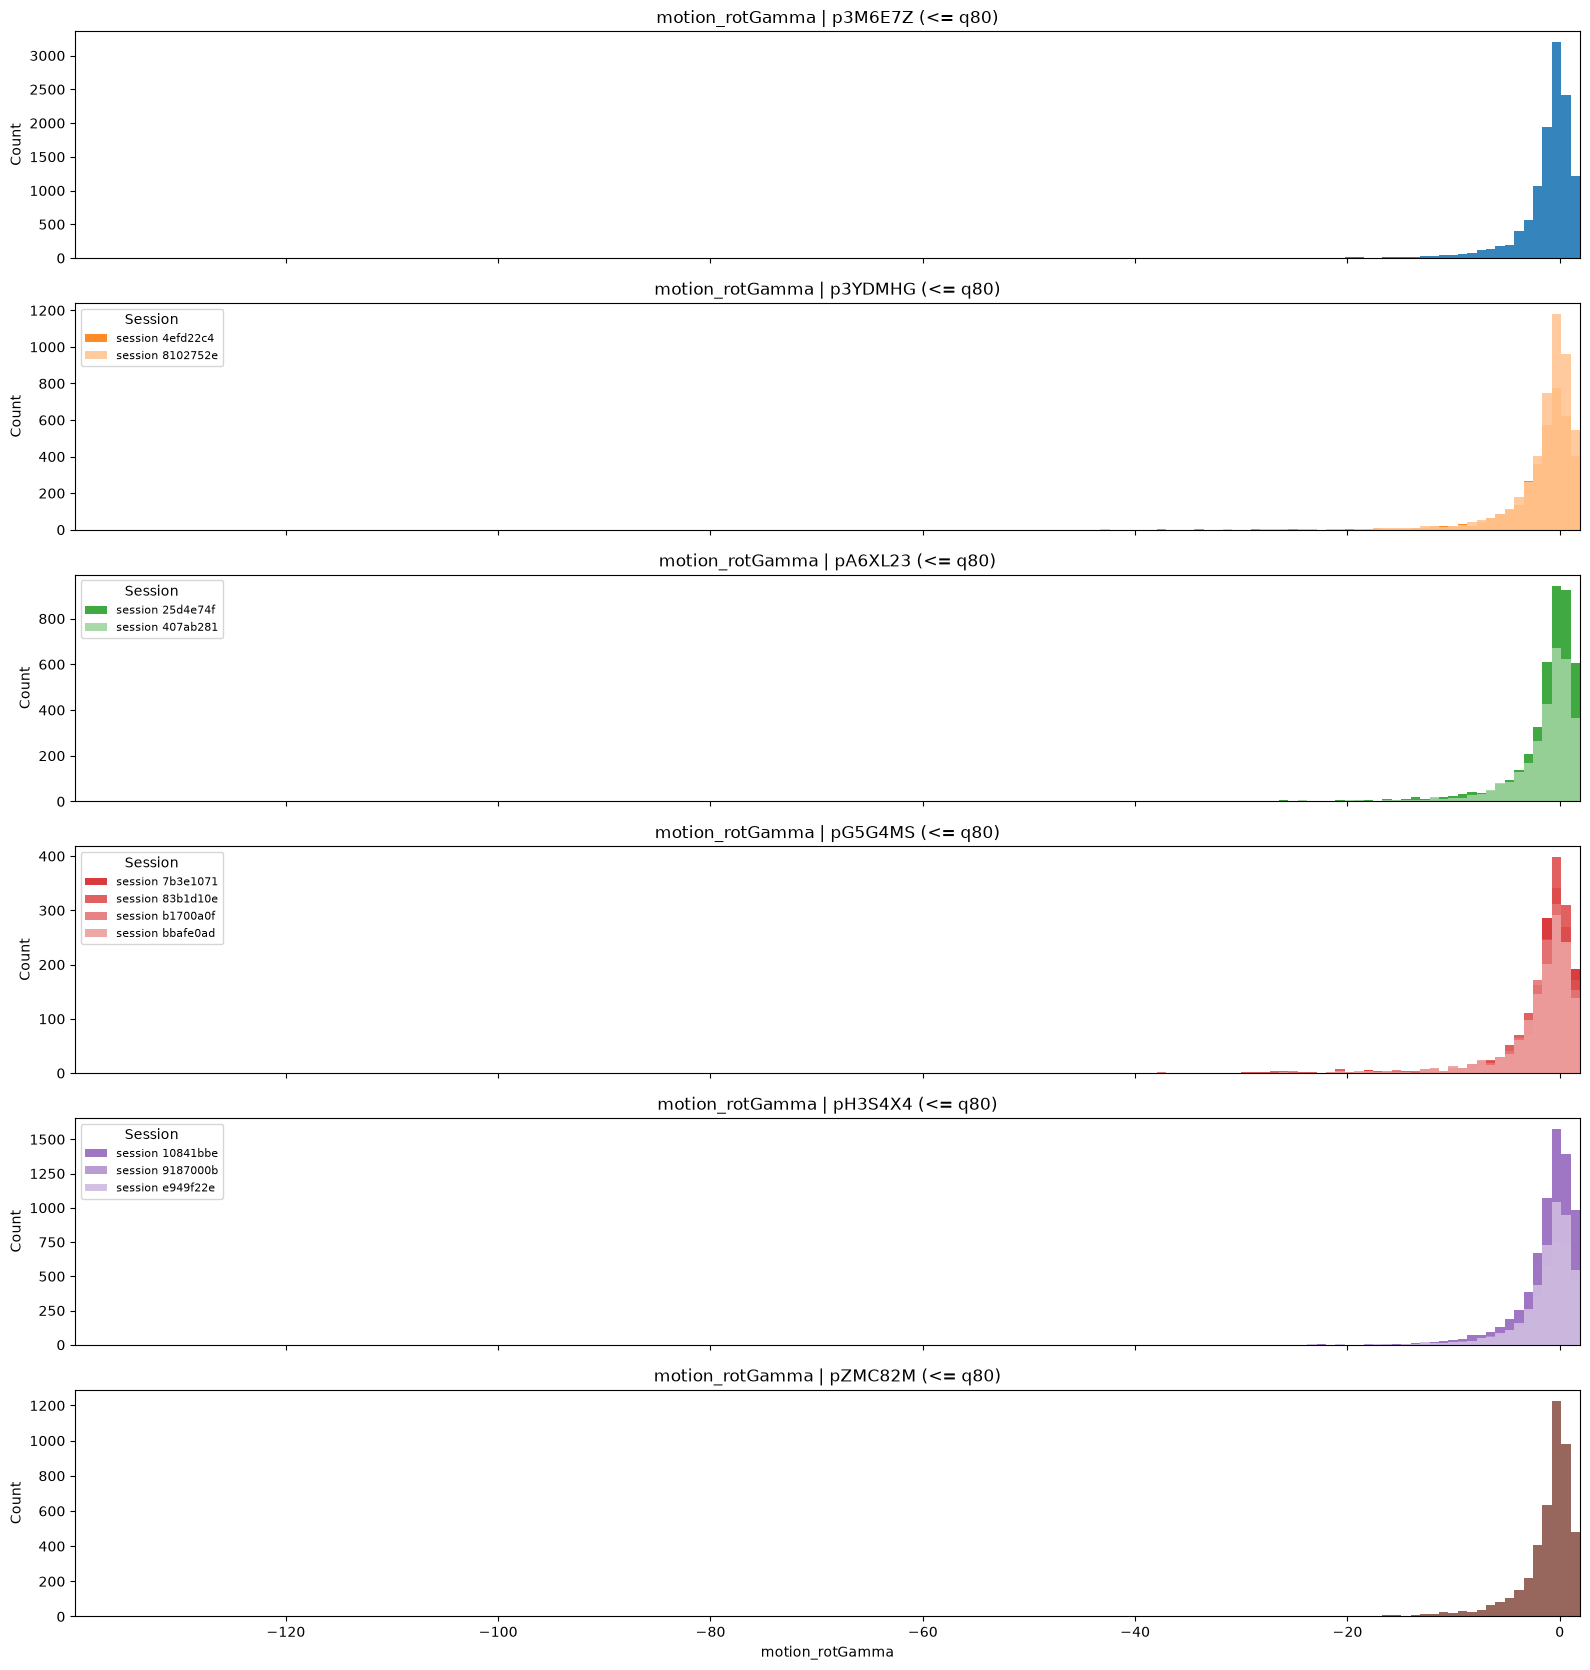

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3917815700.py:54: UserWarni

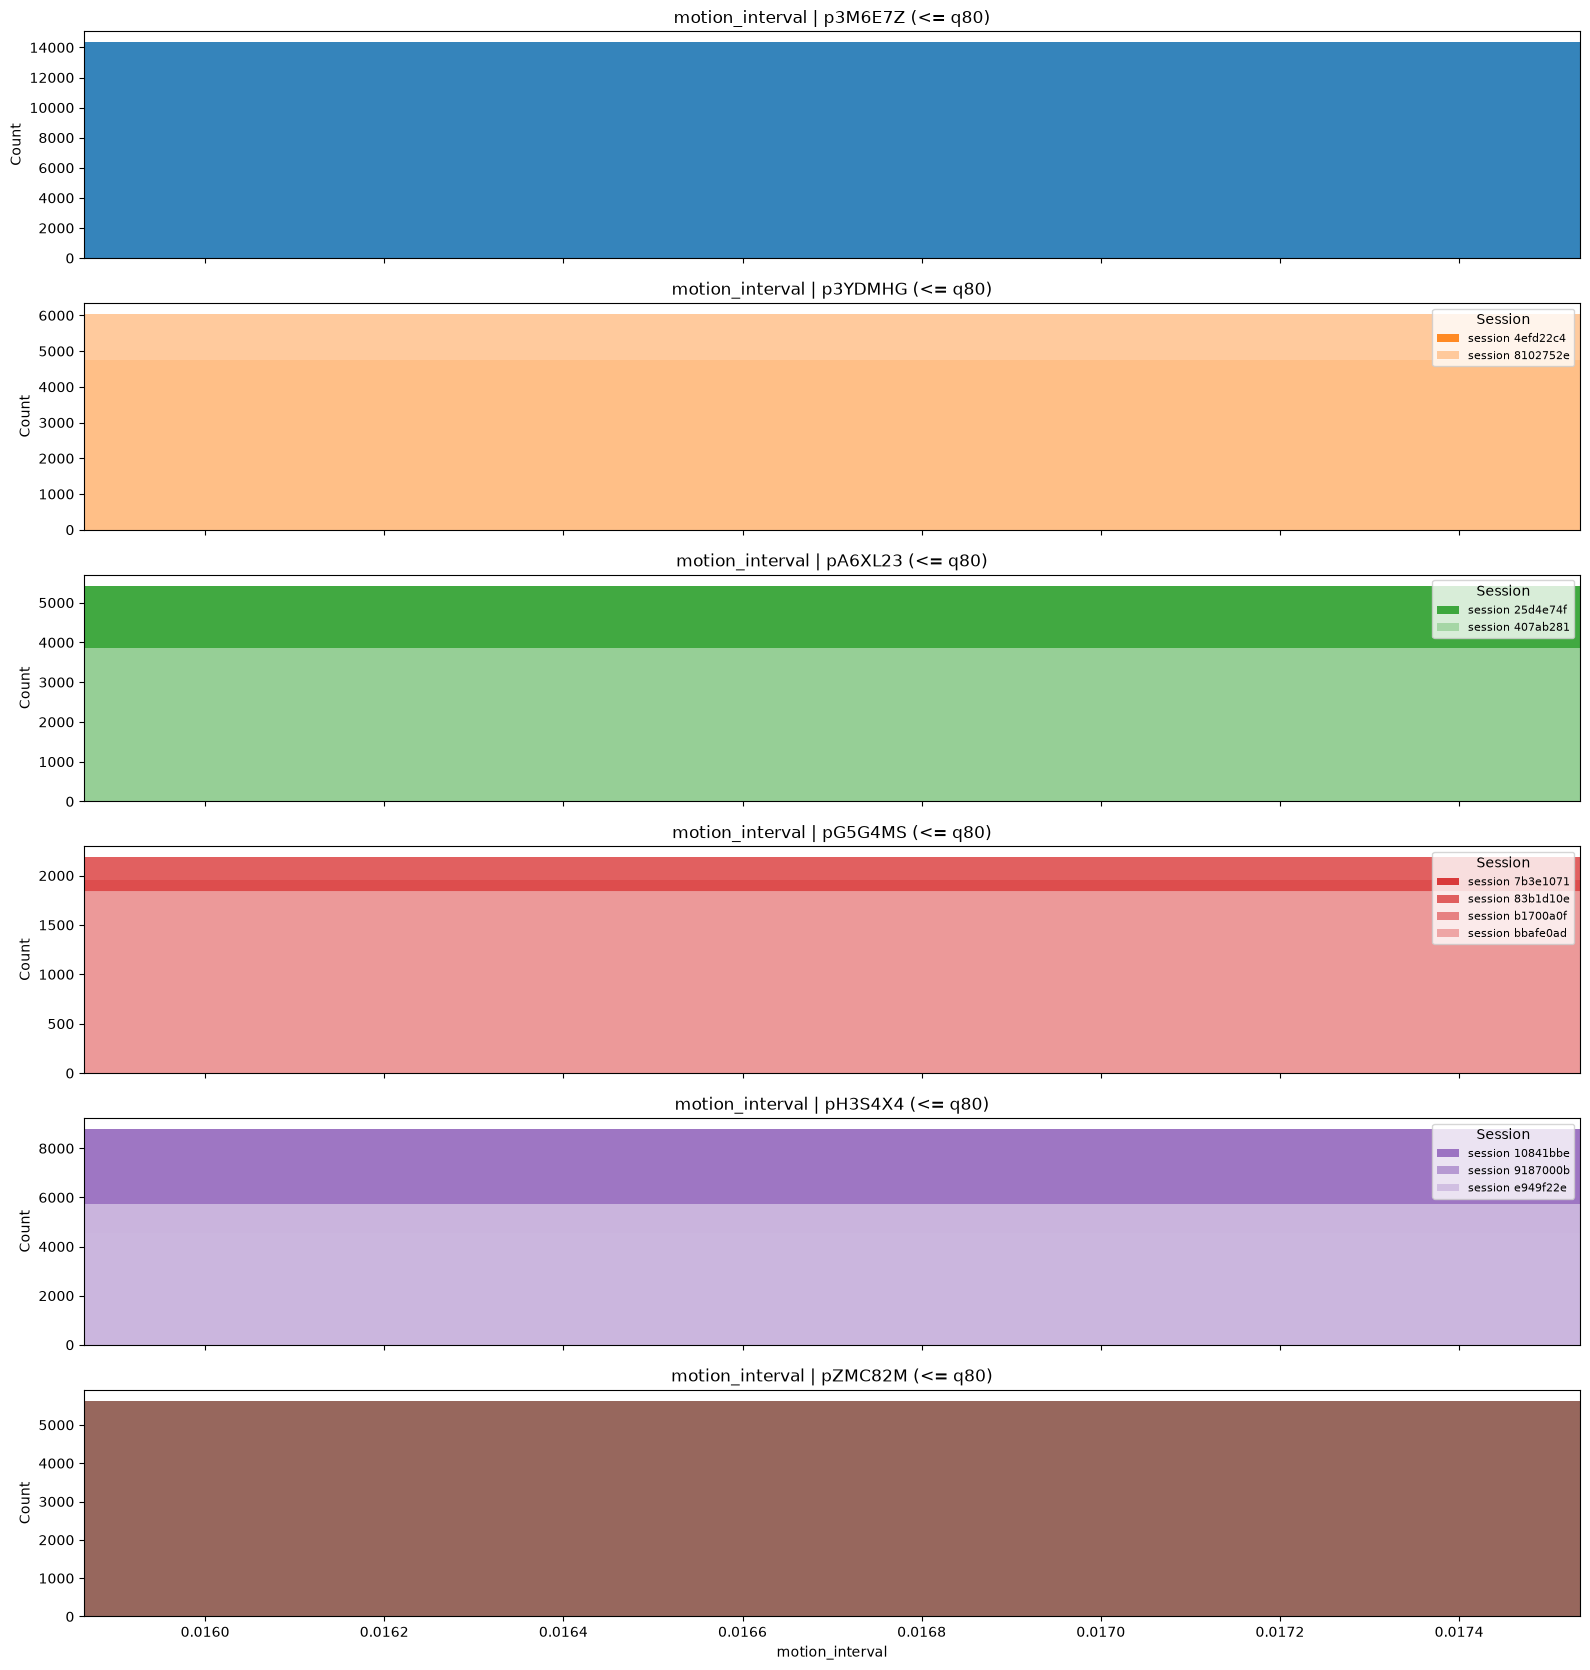

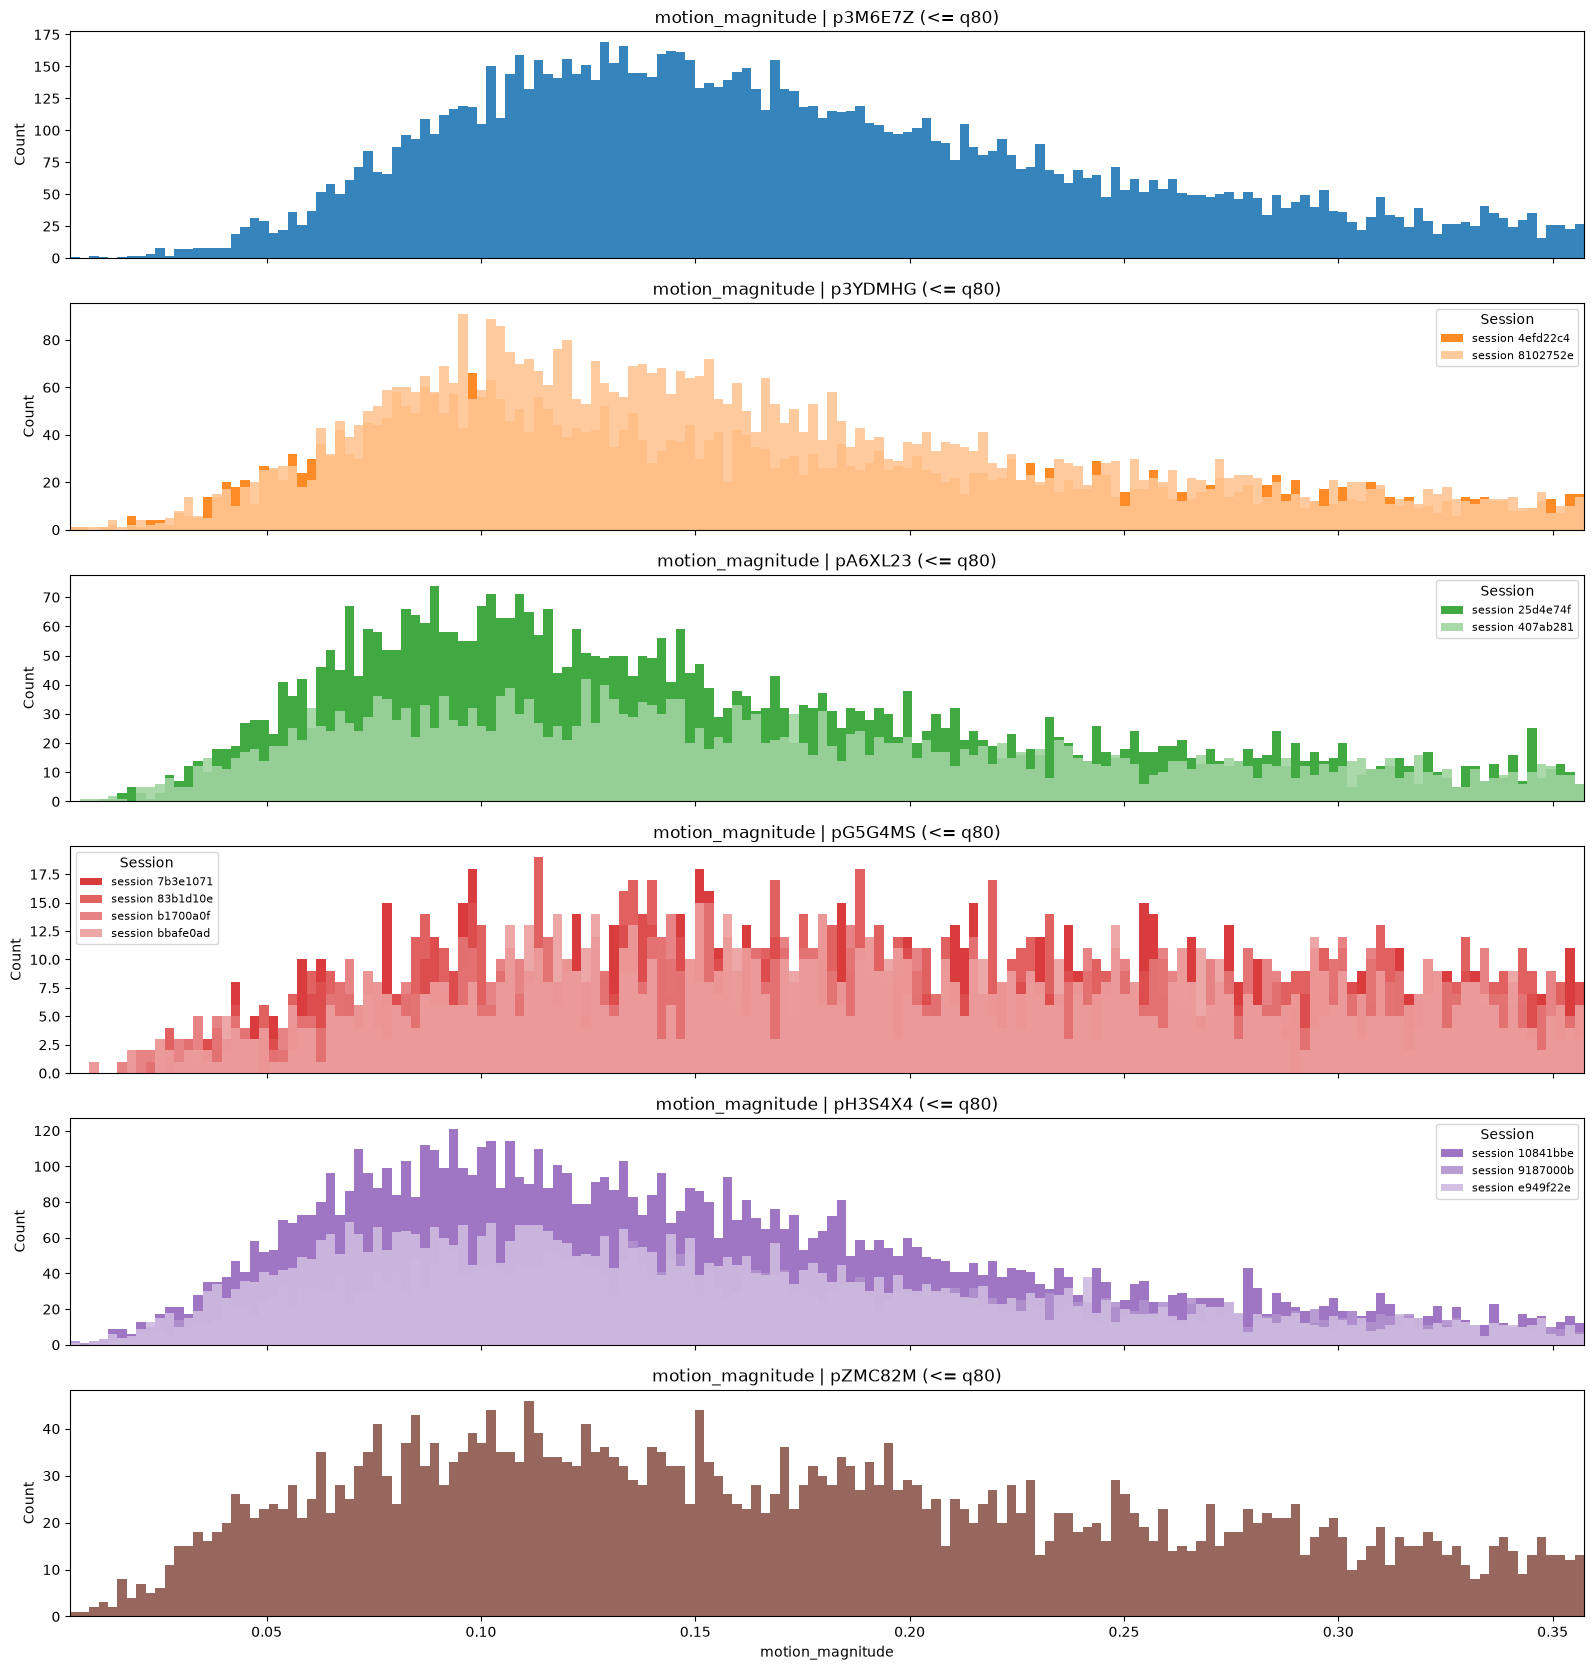

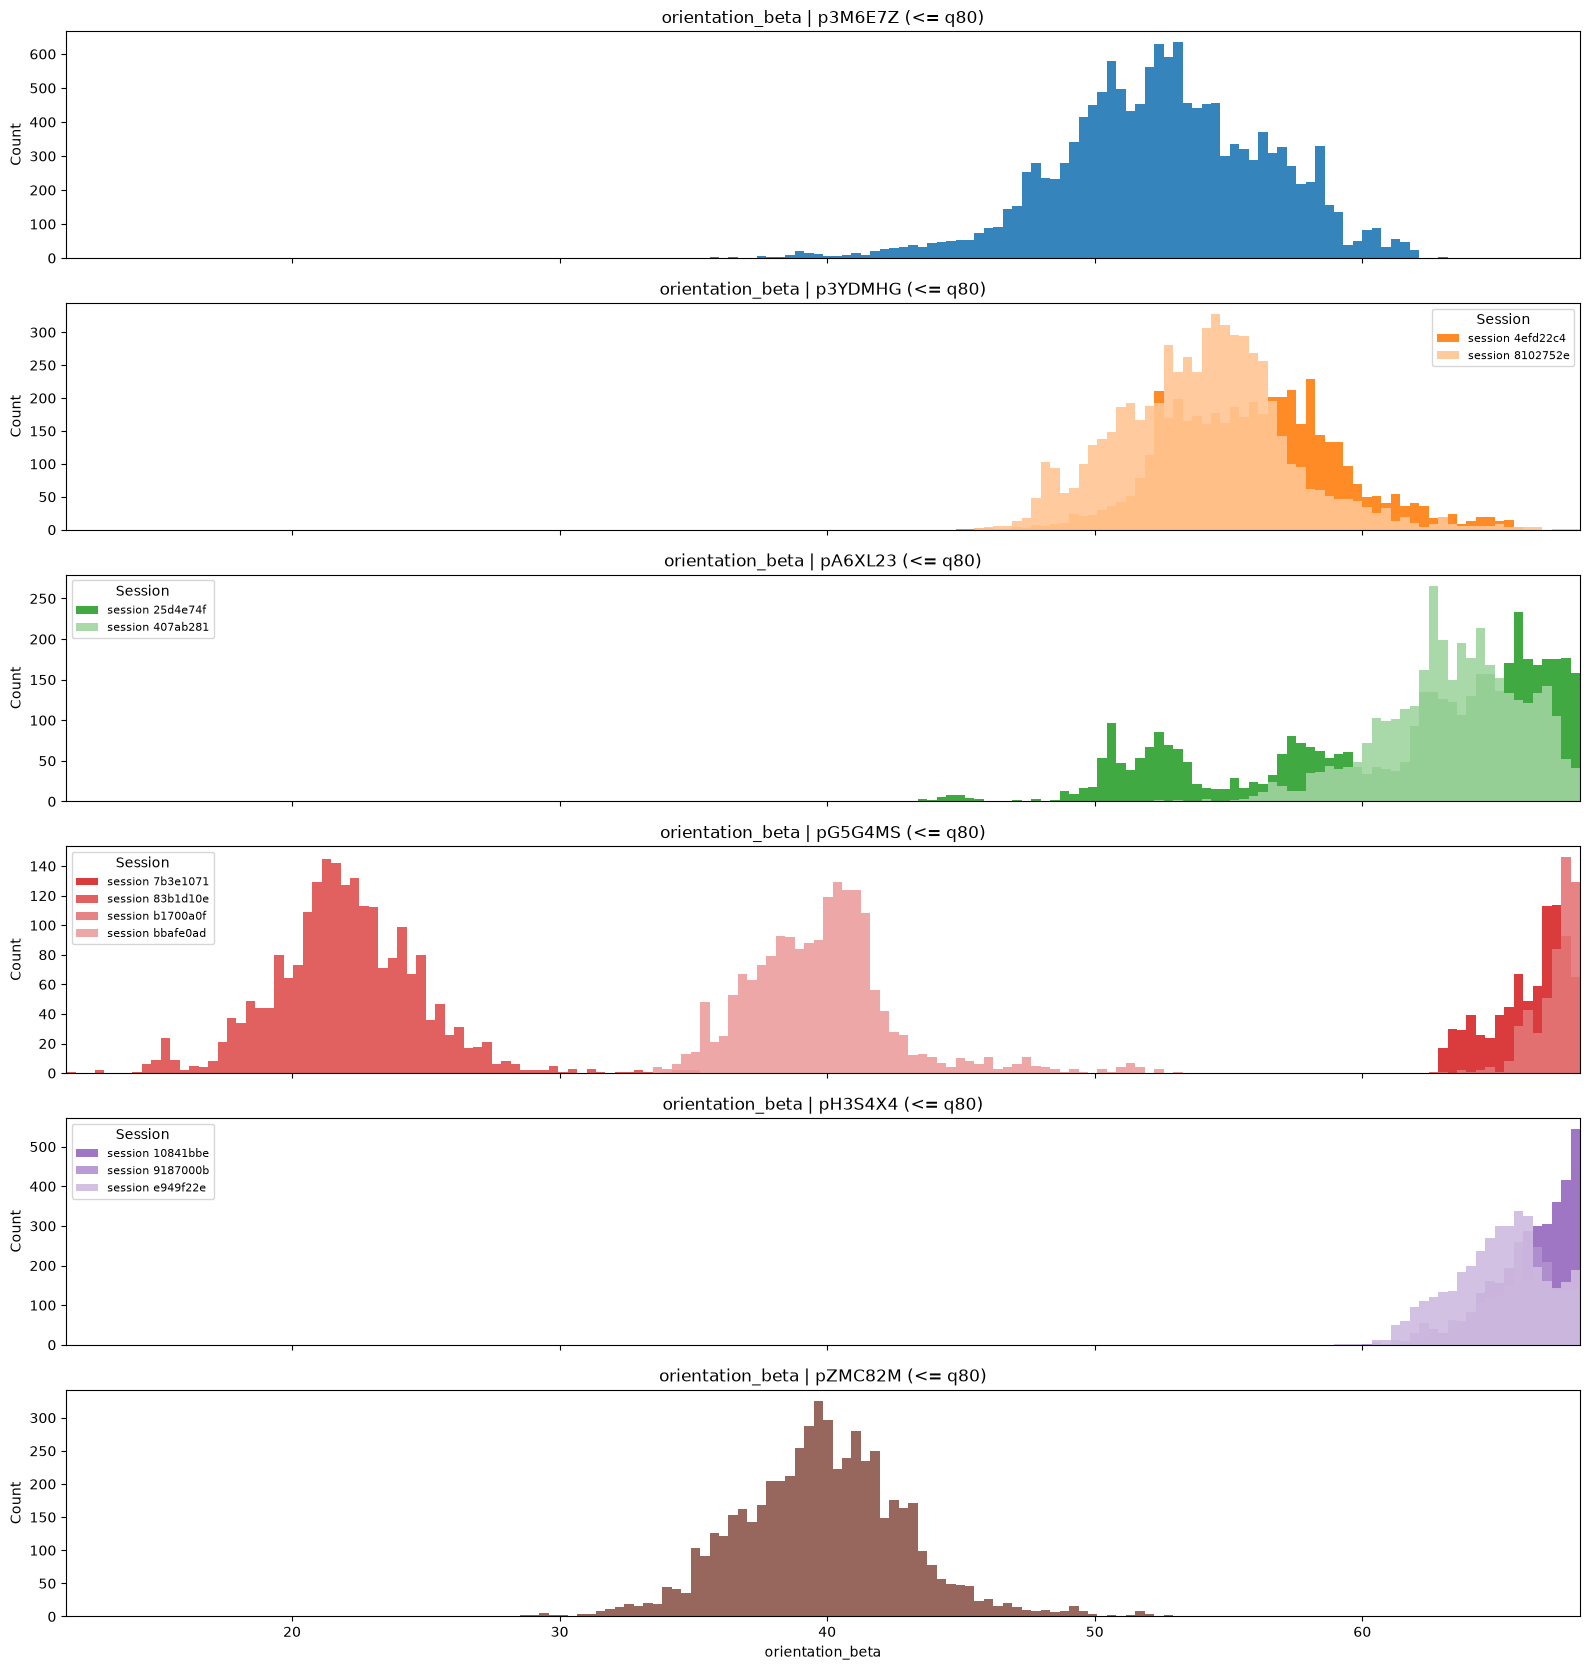

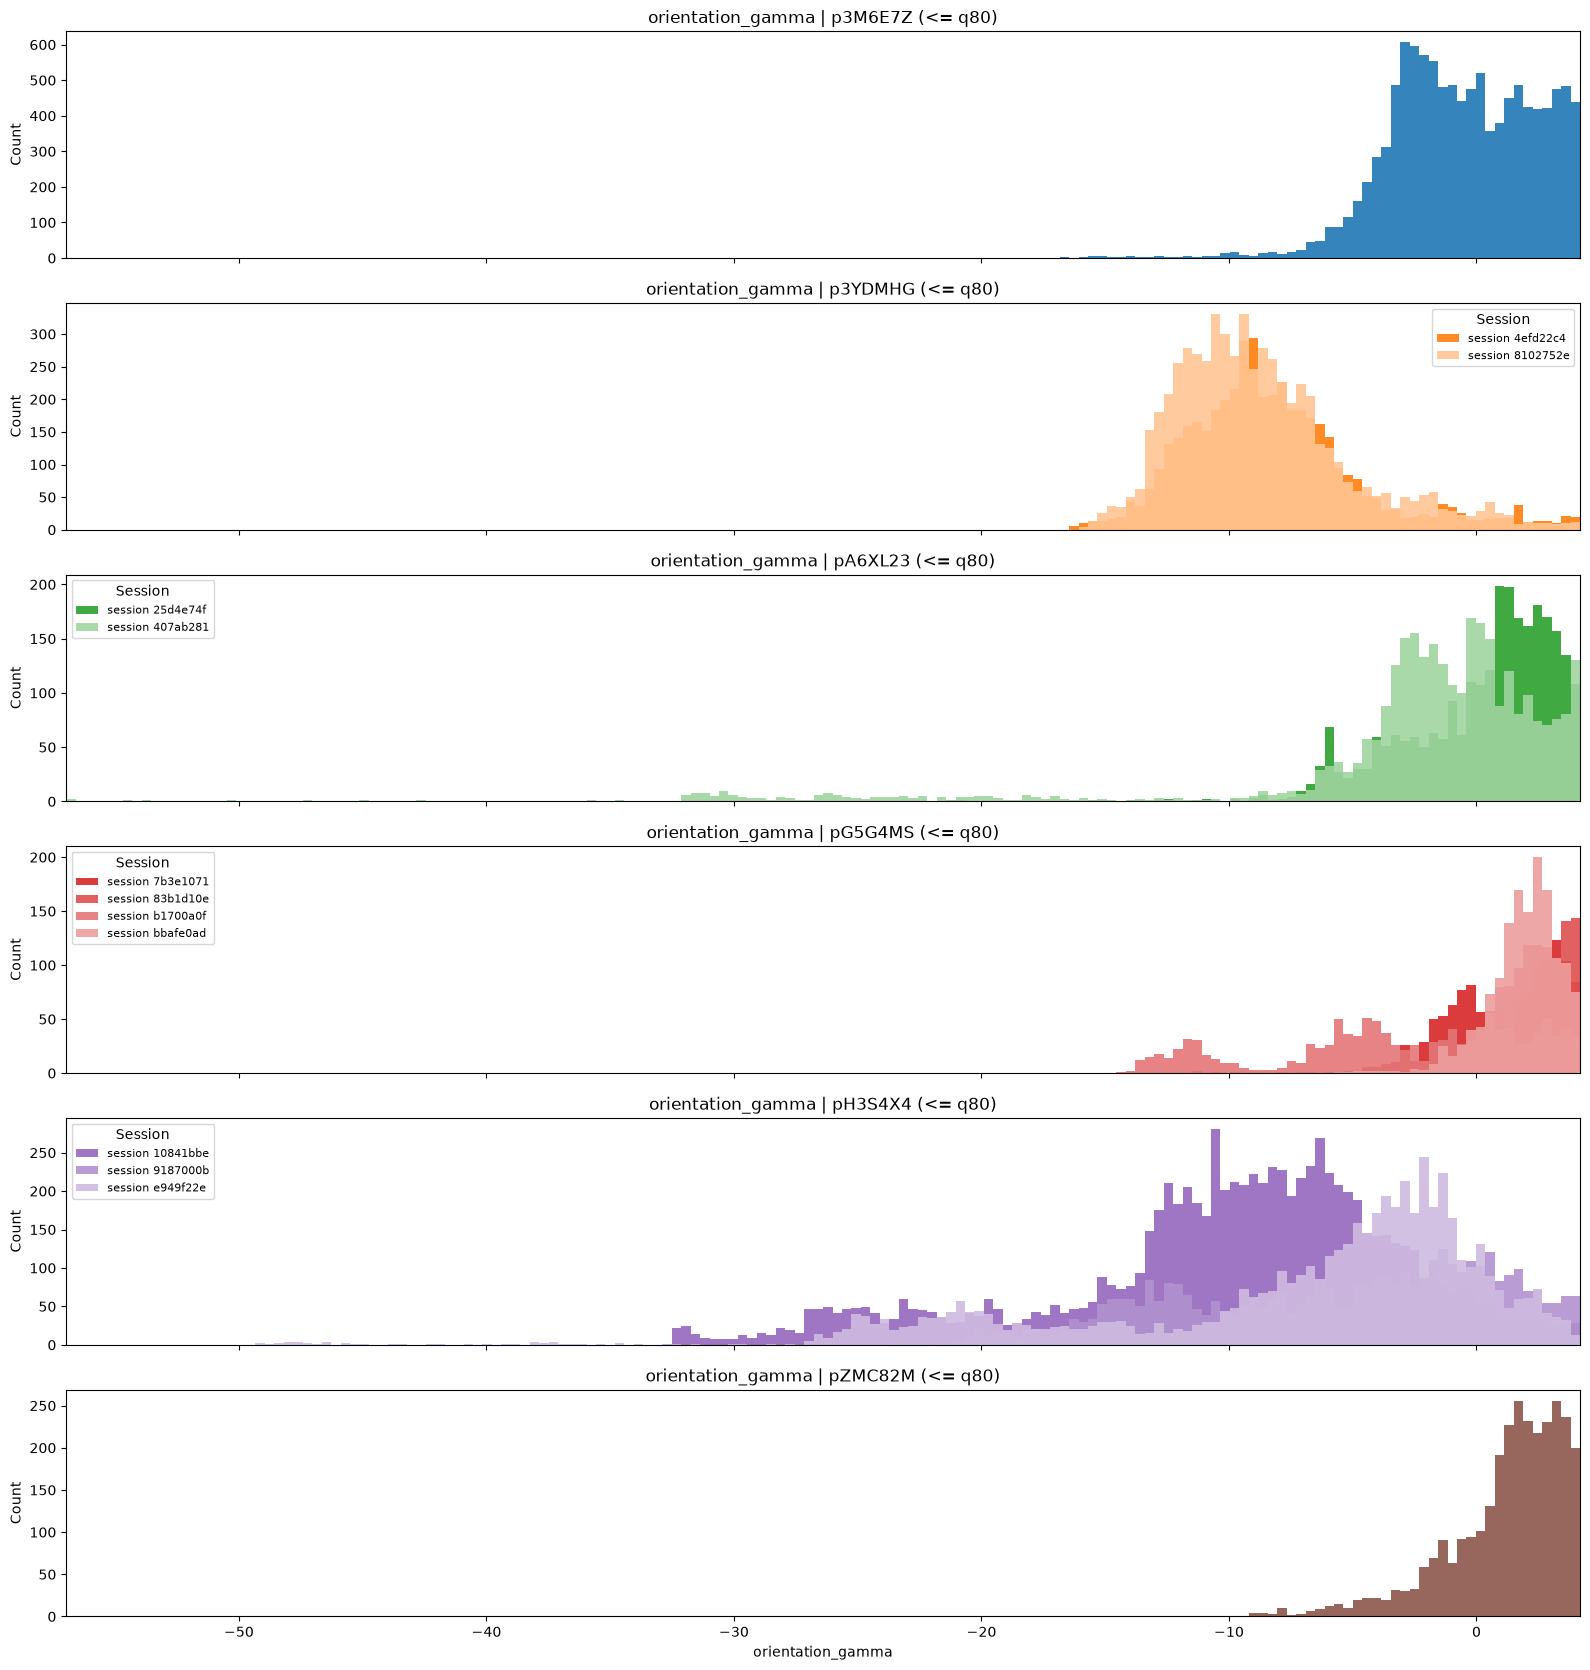

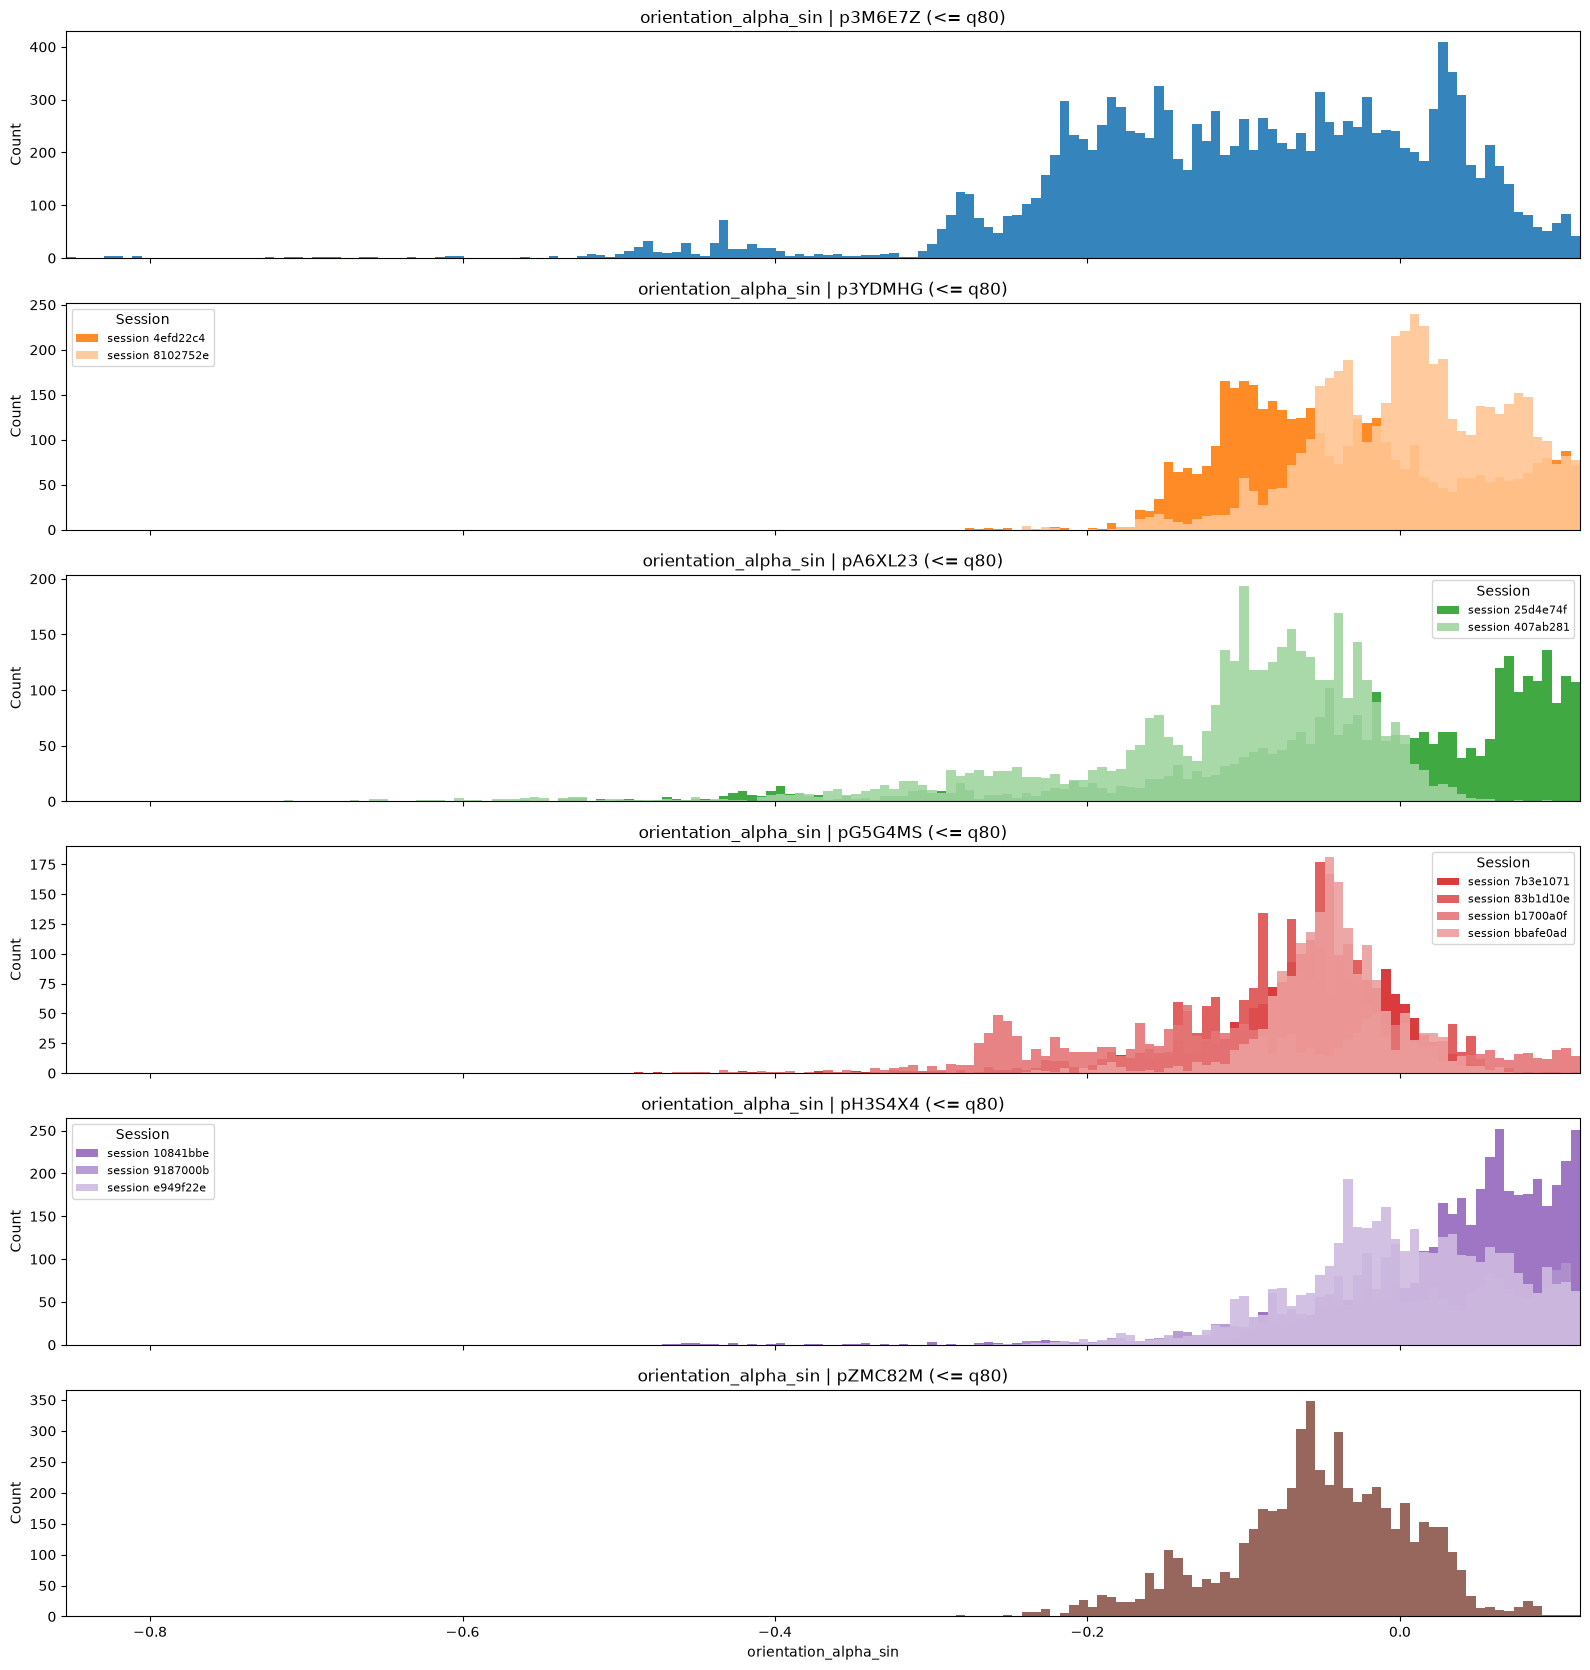

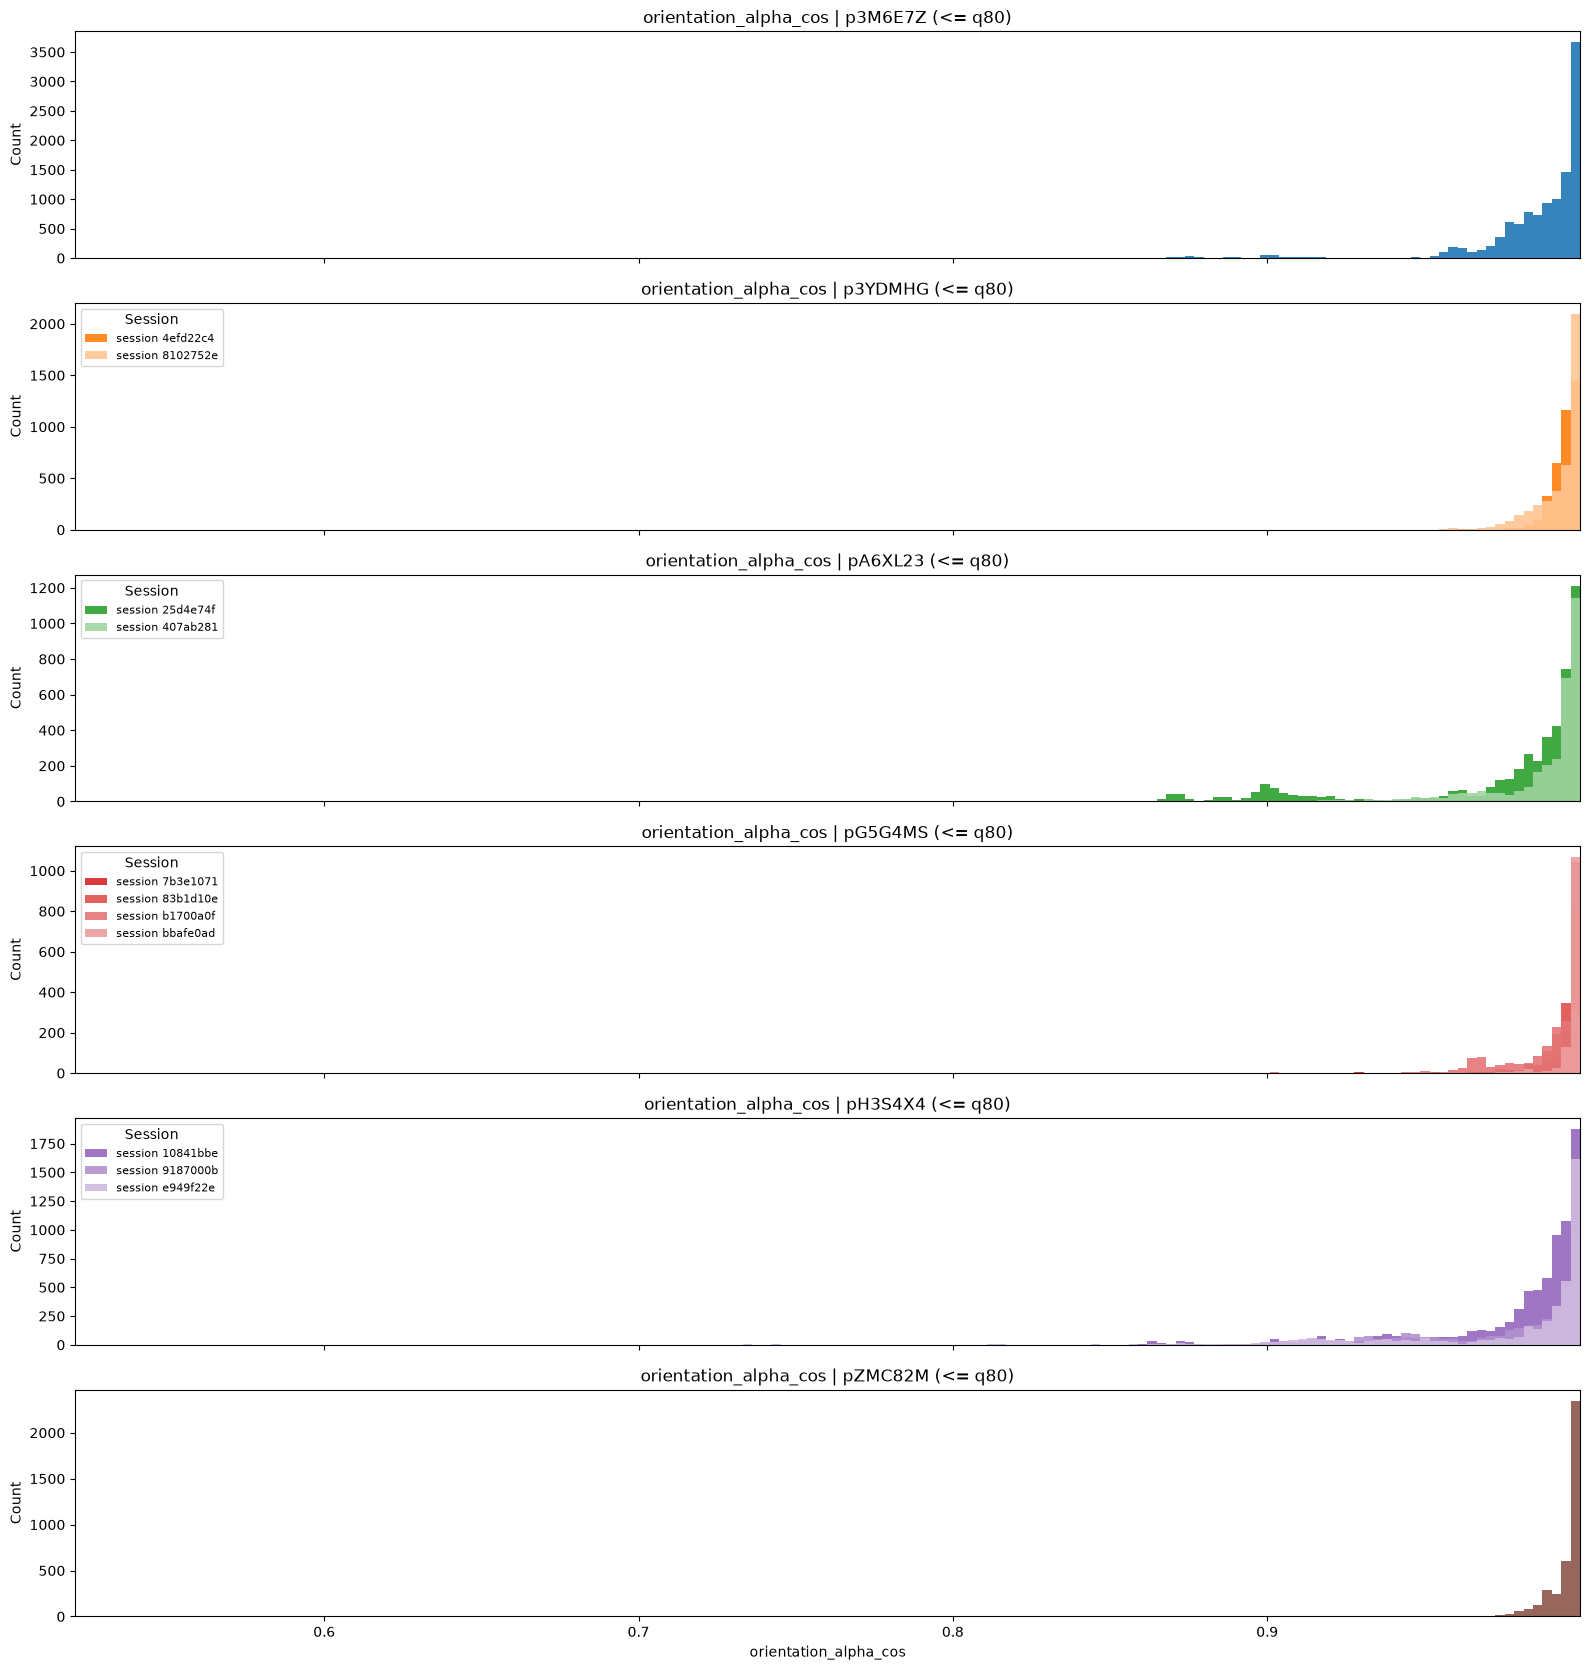

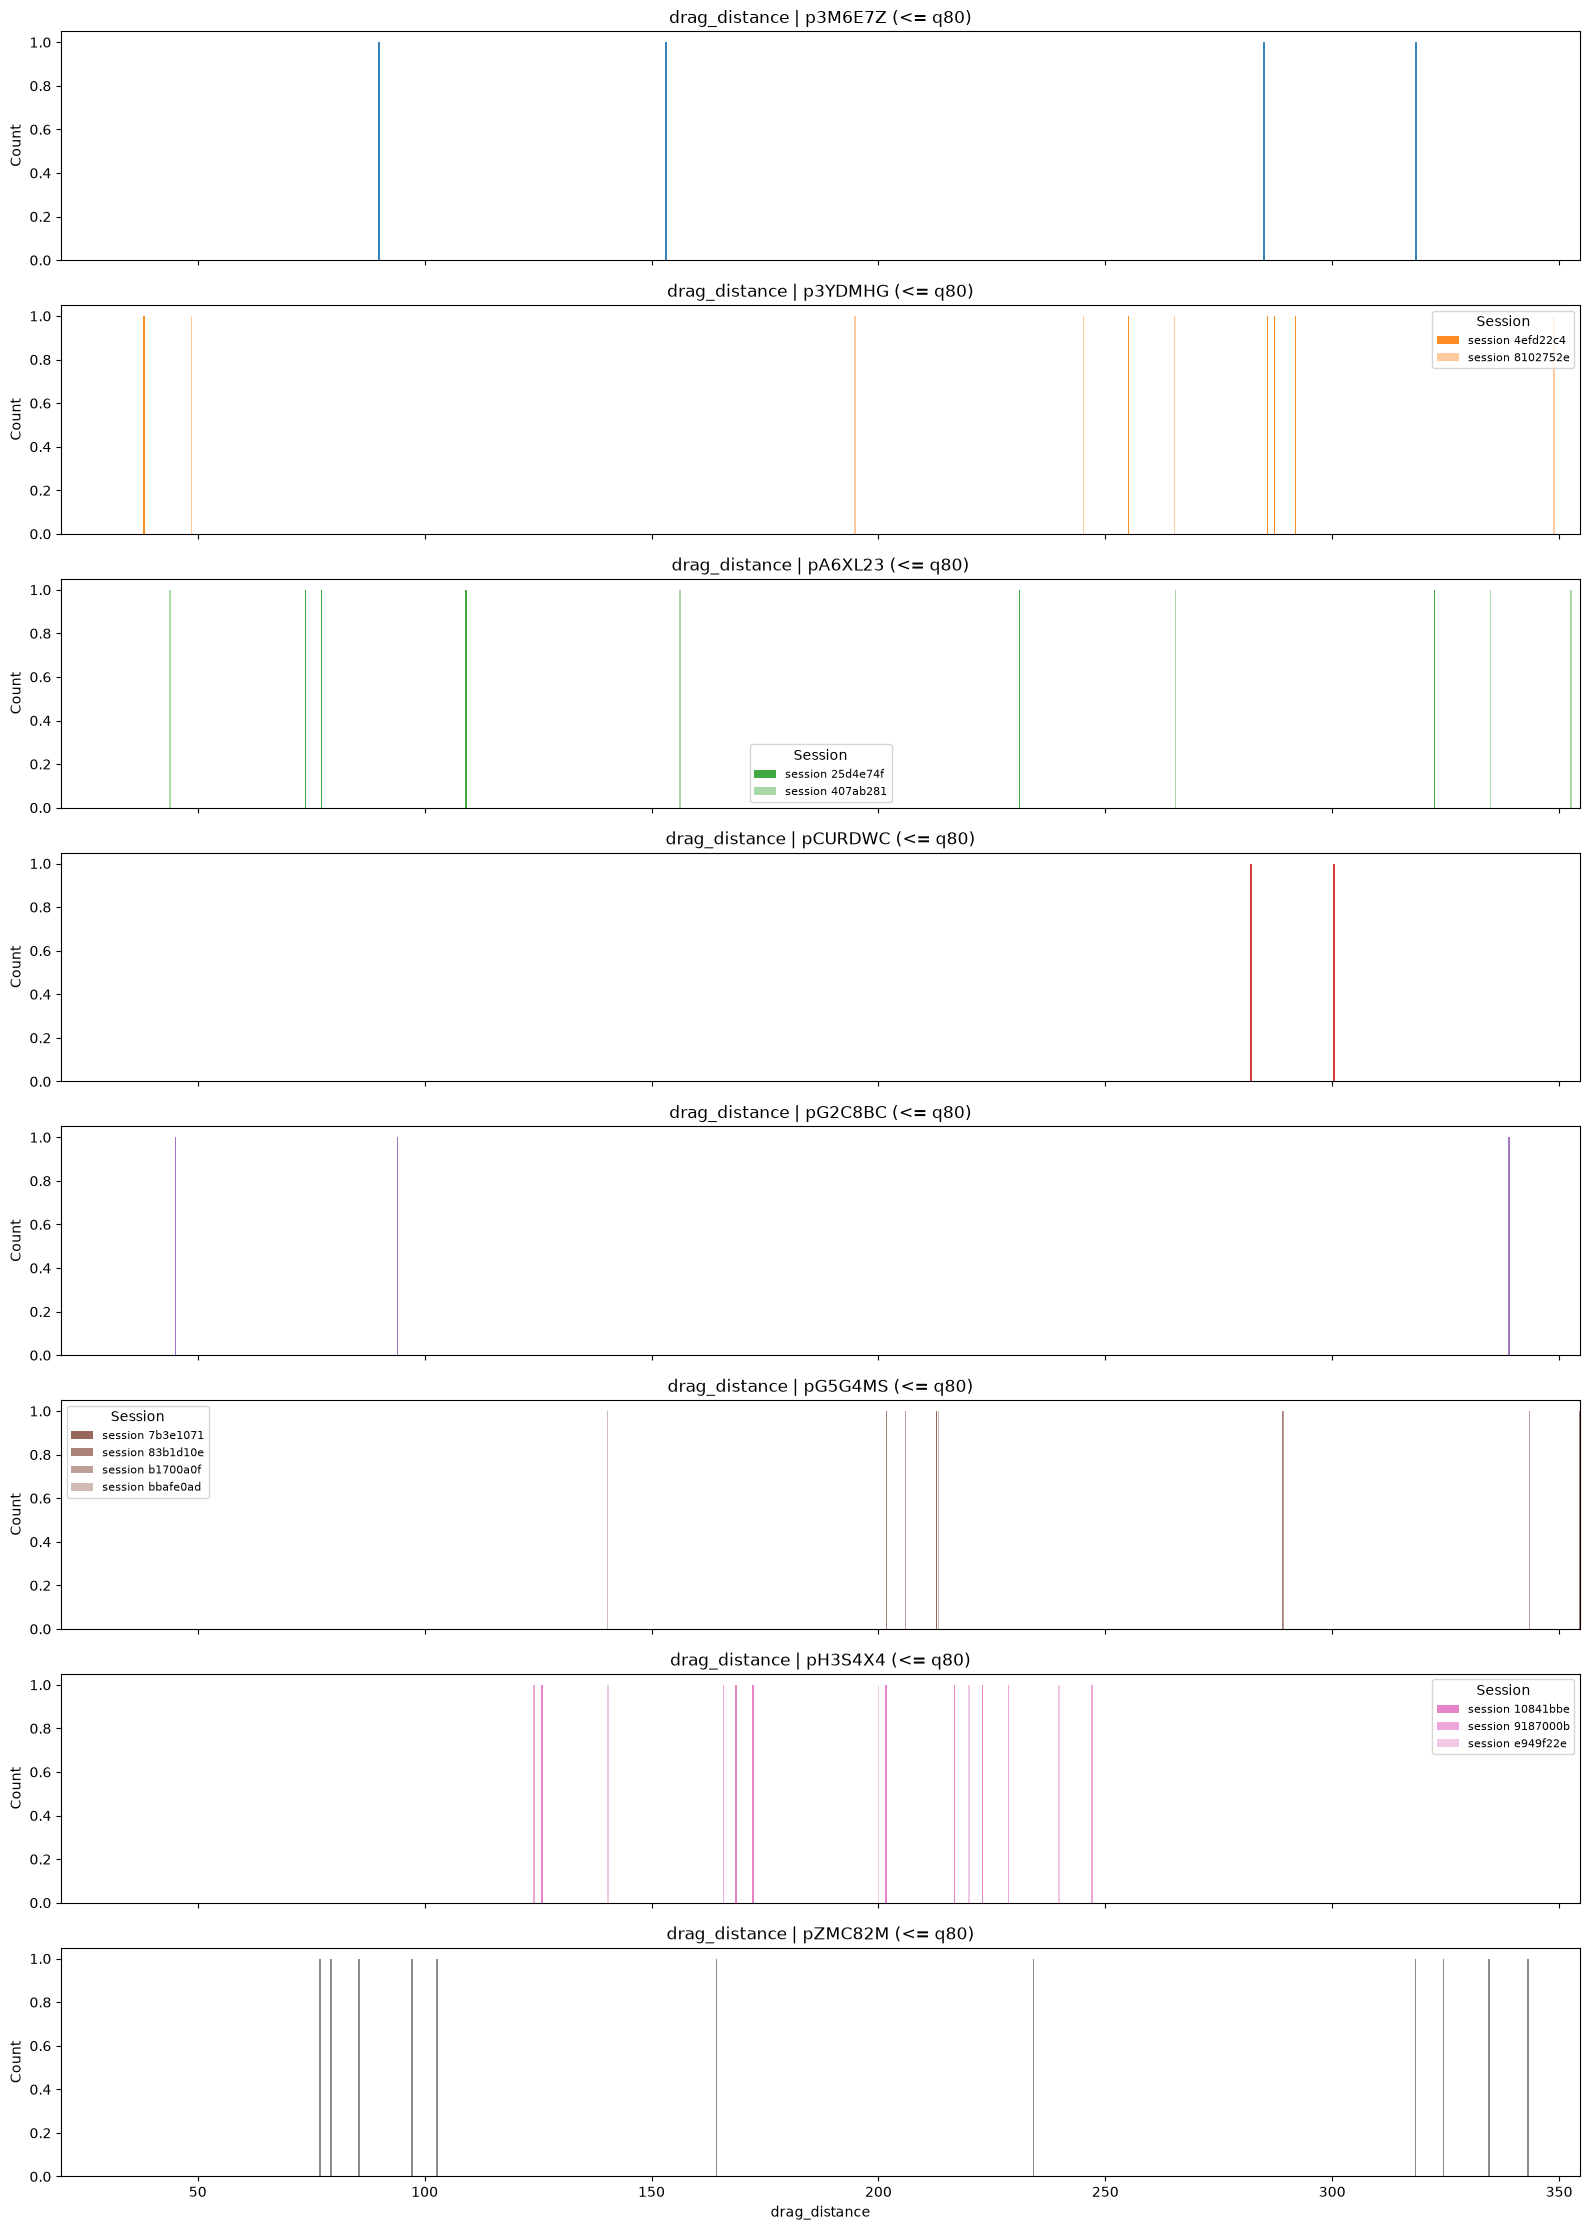

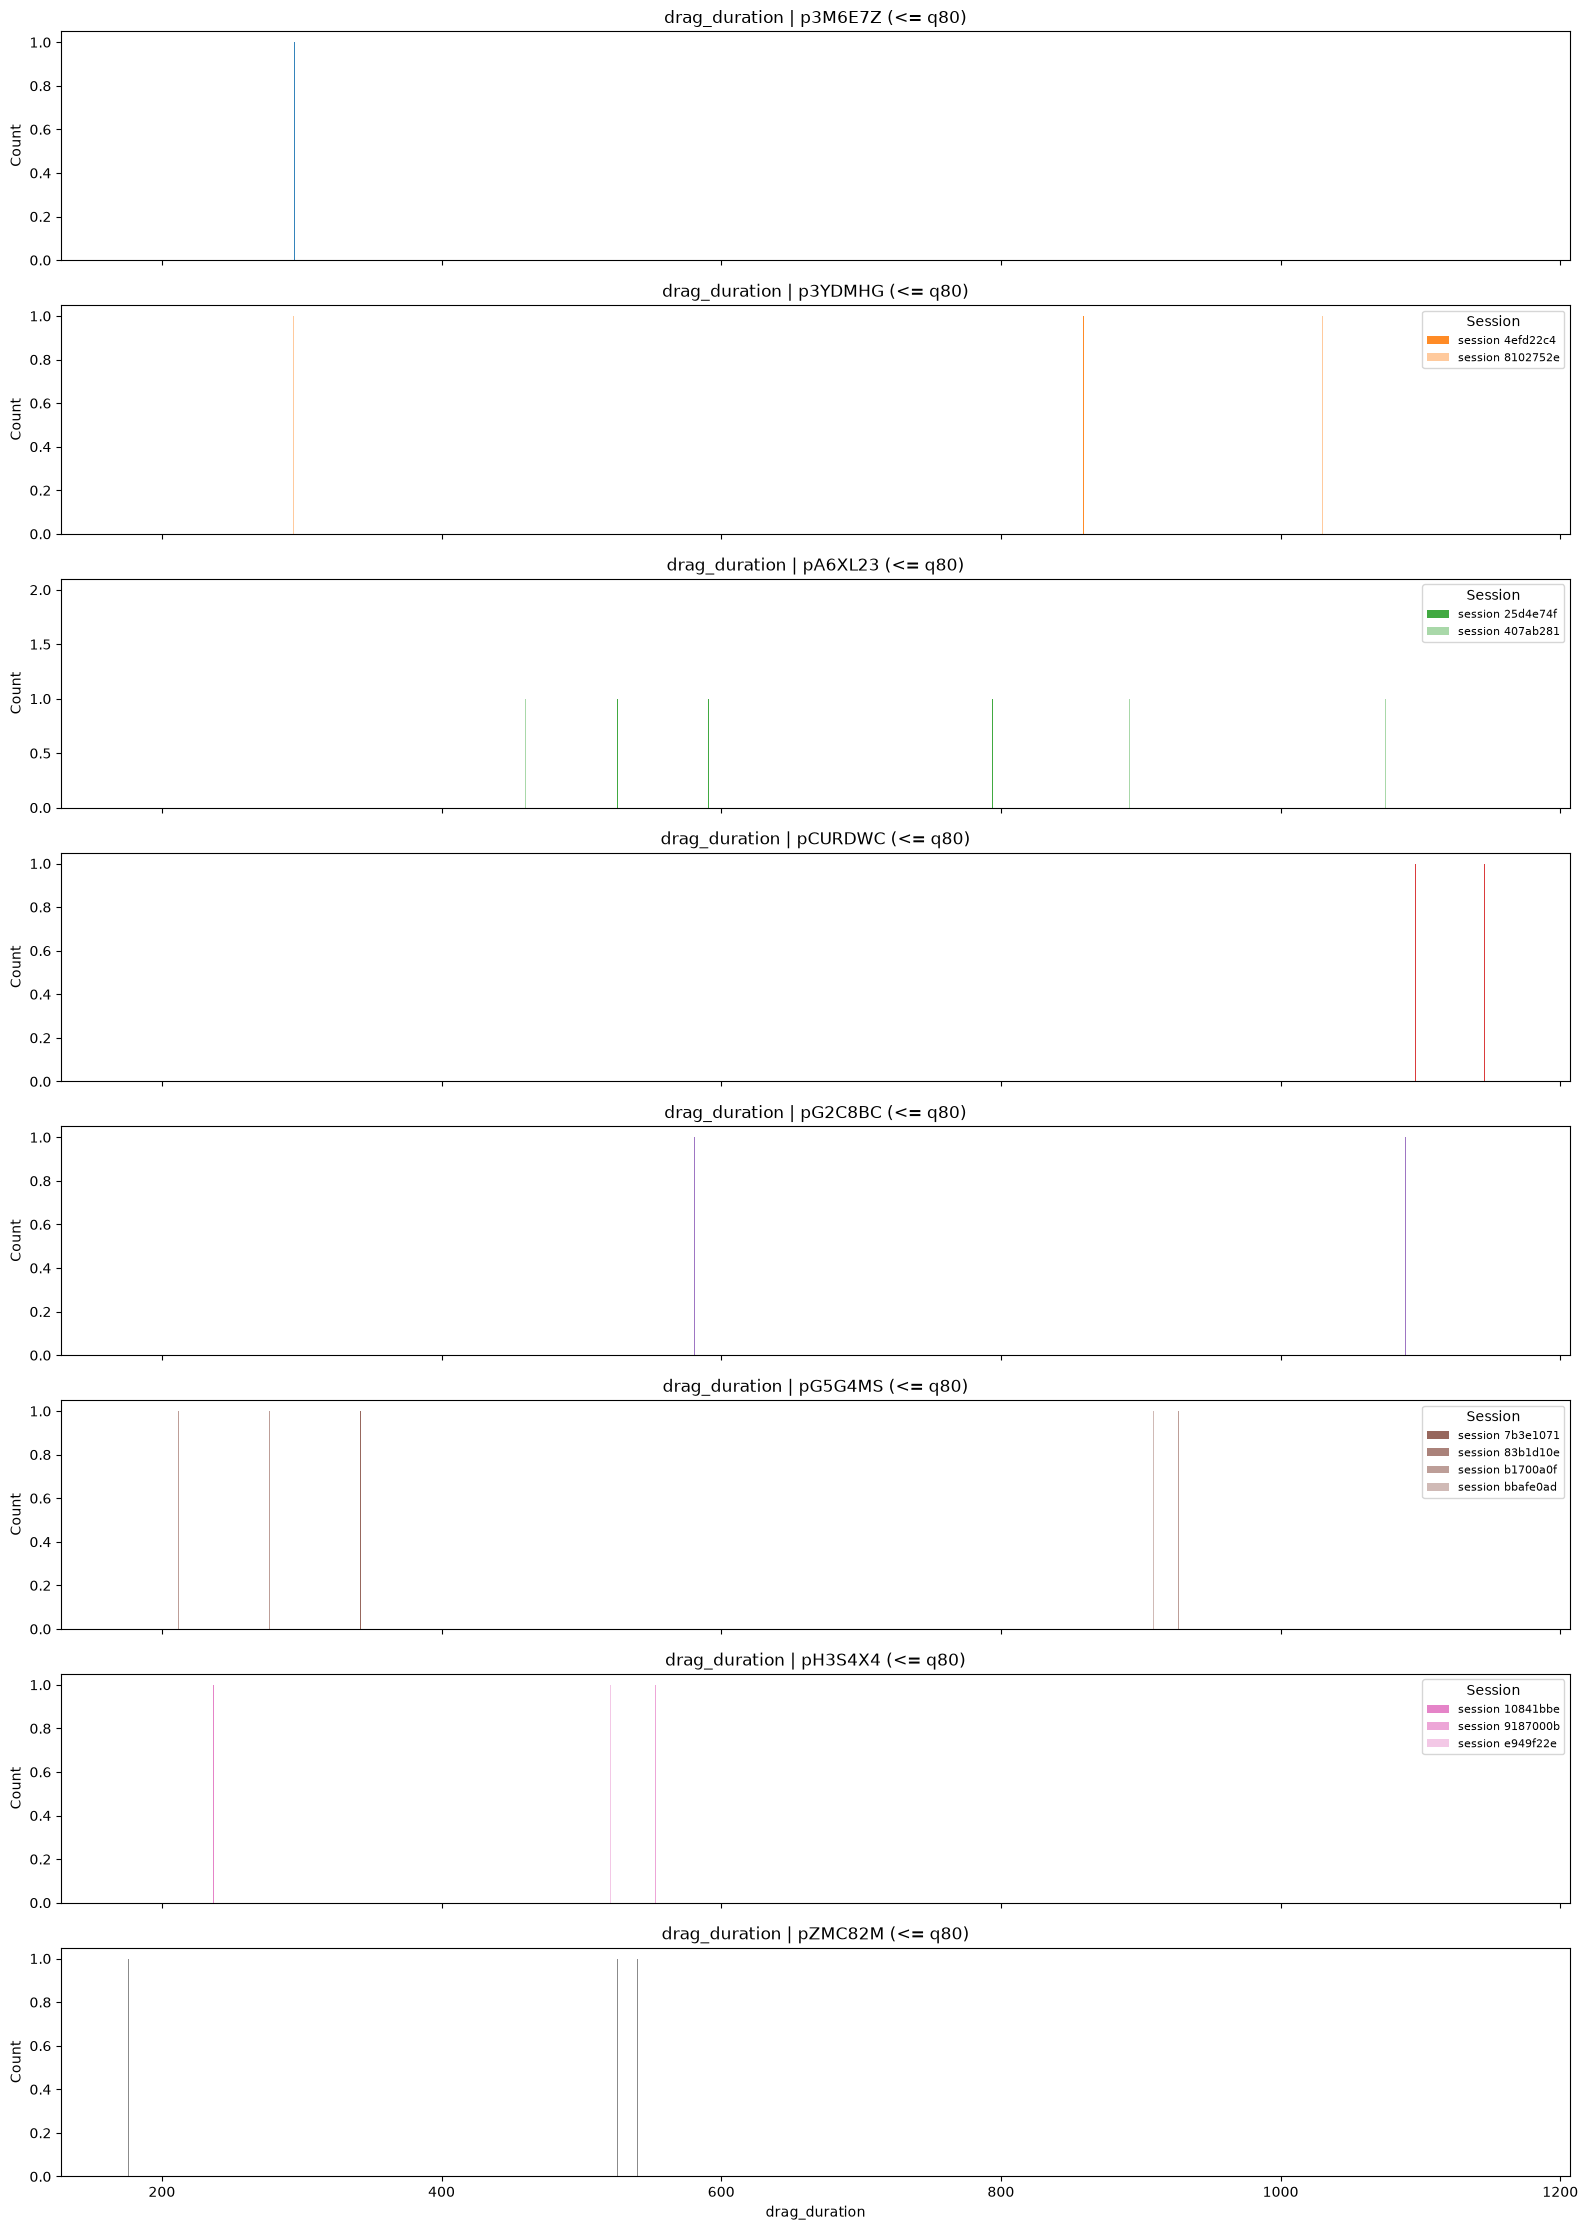

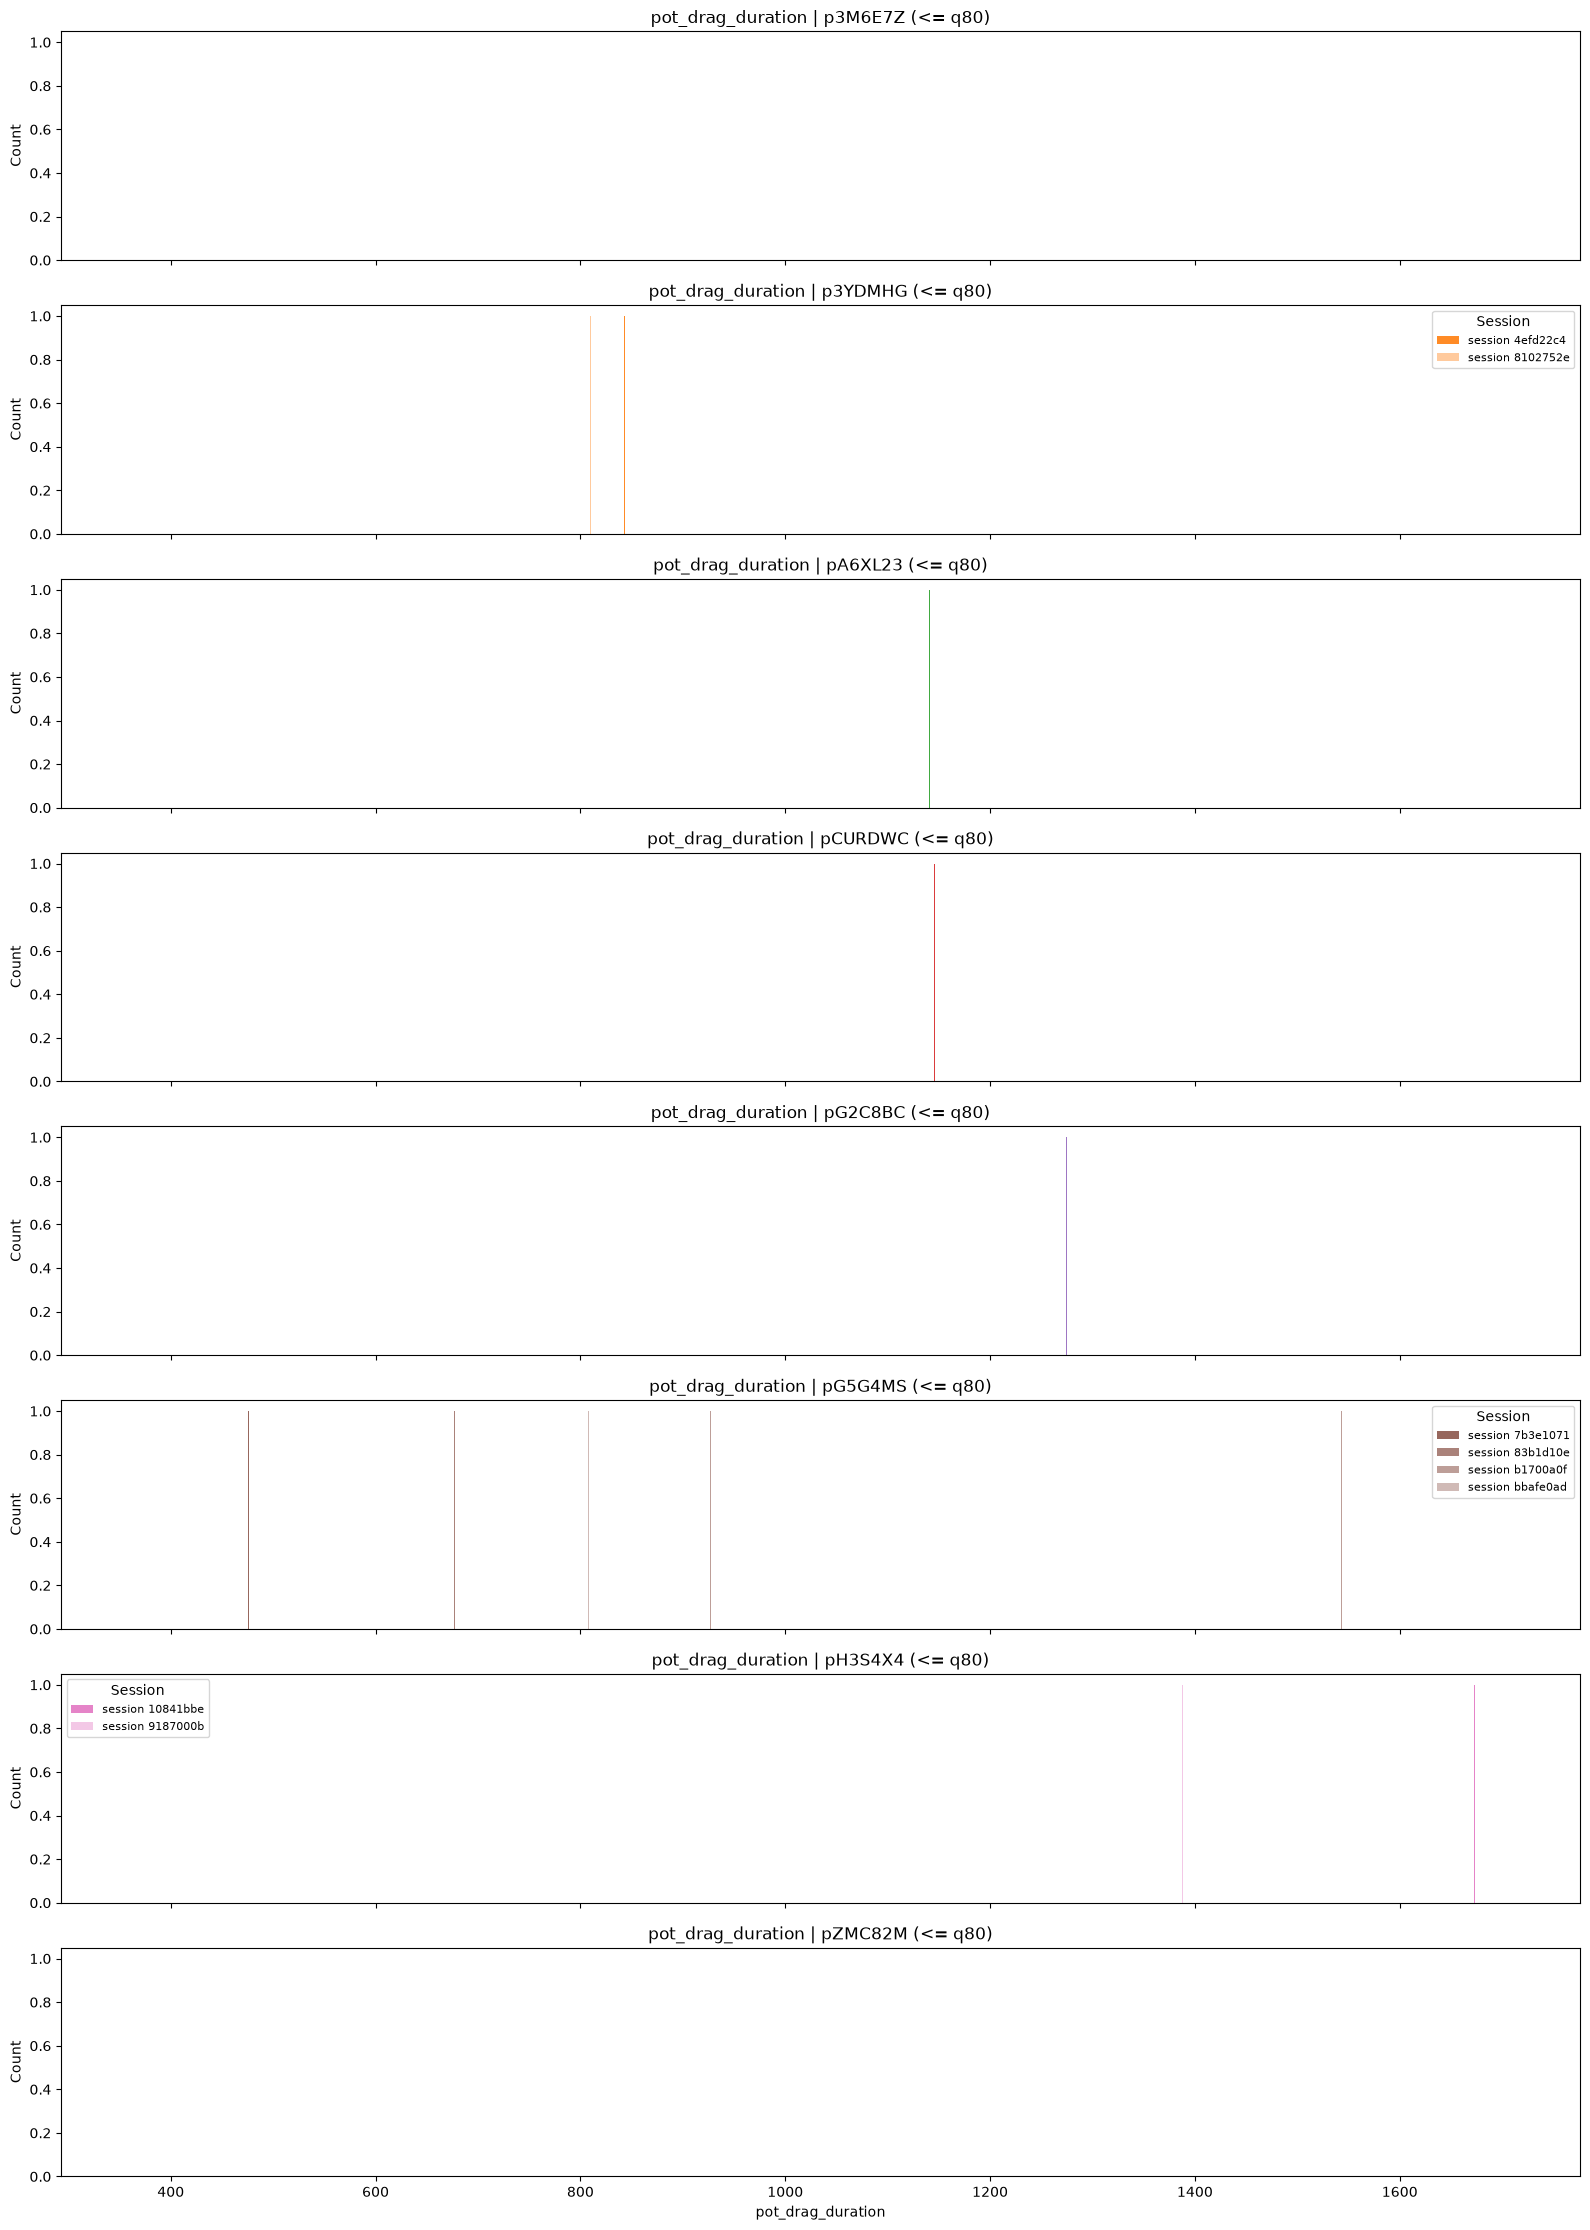

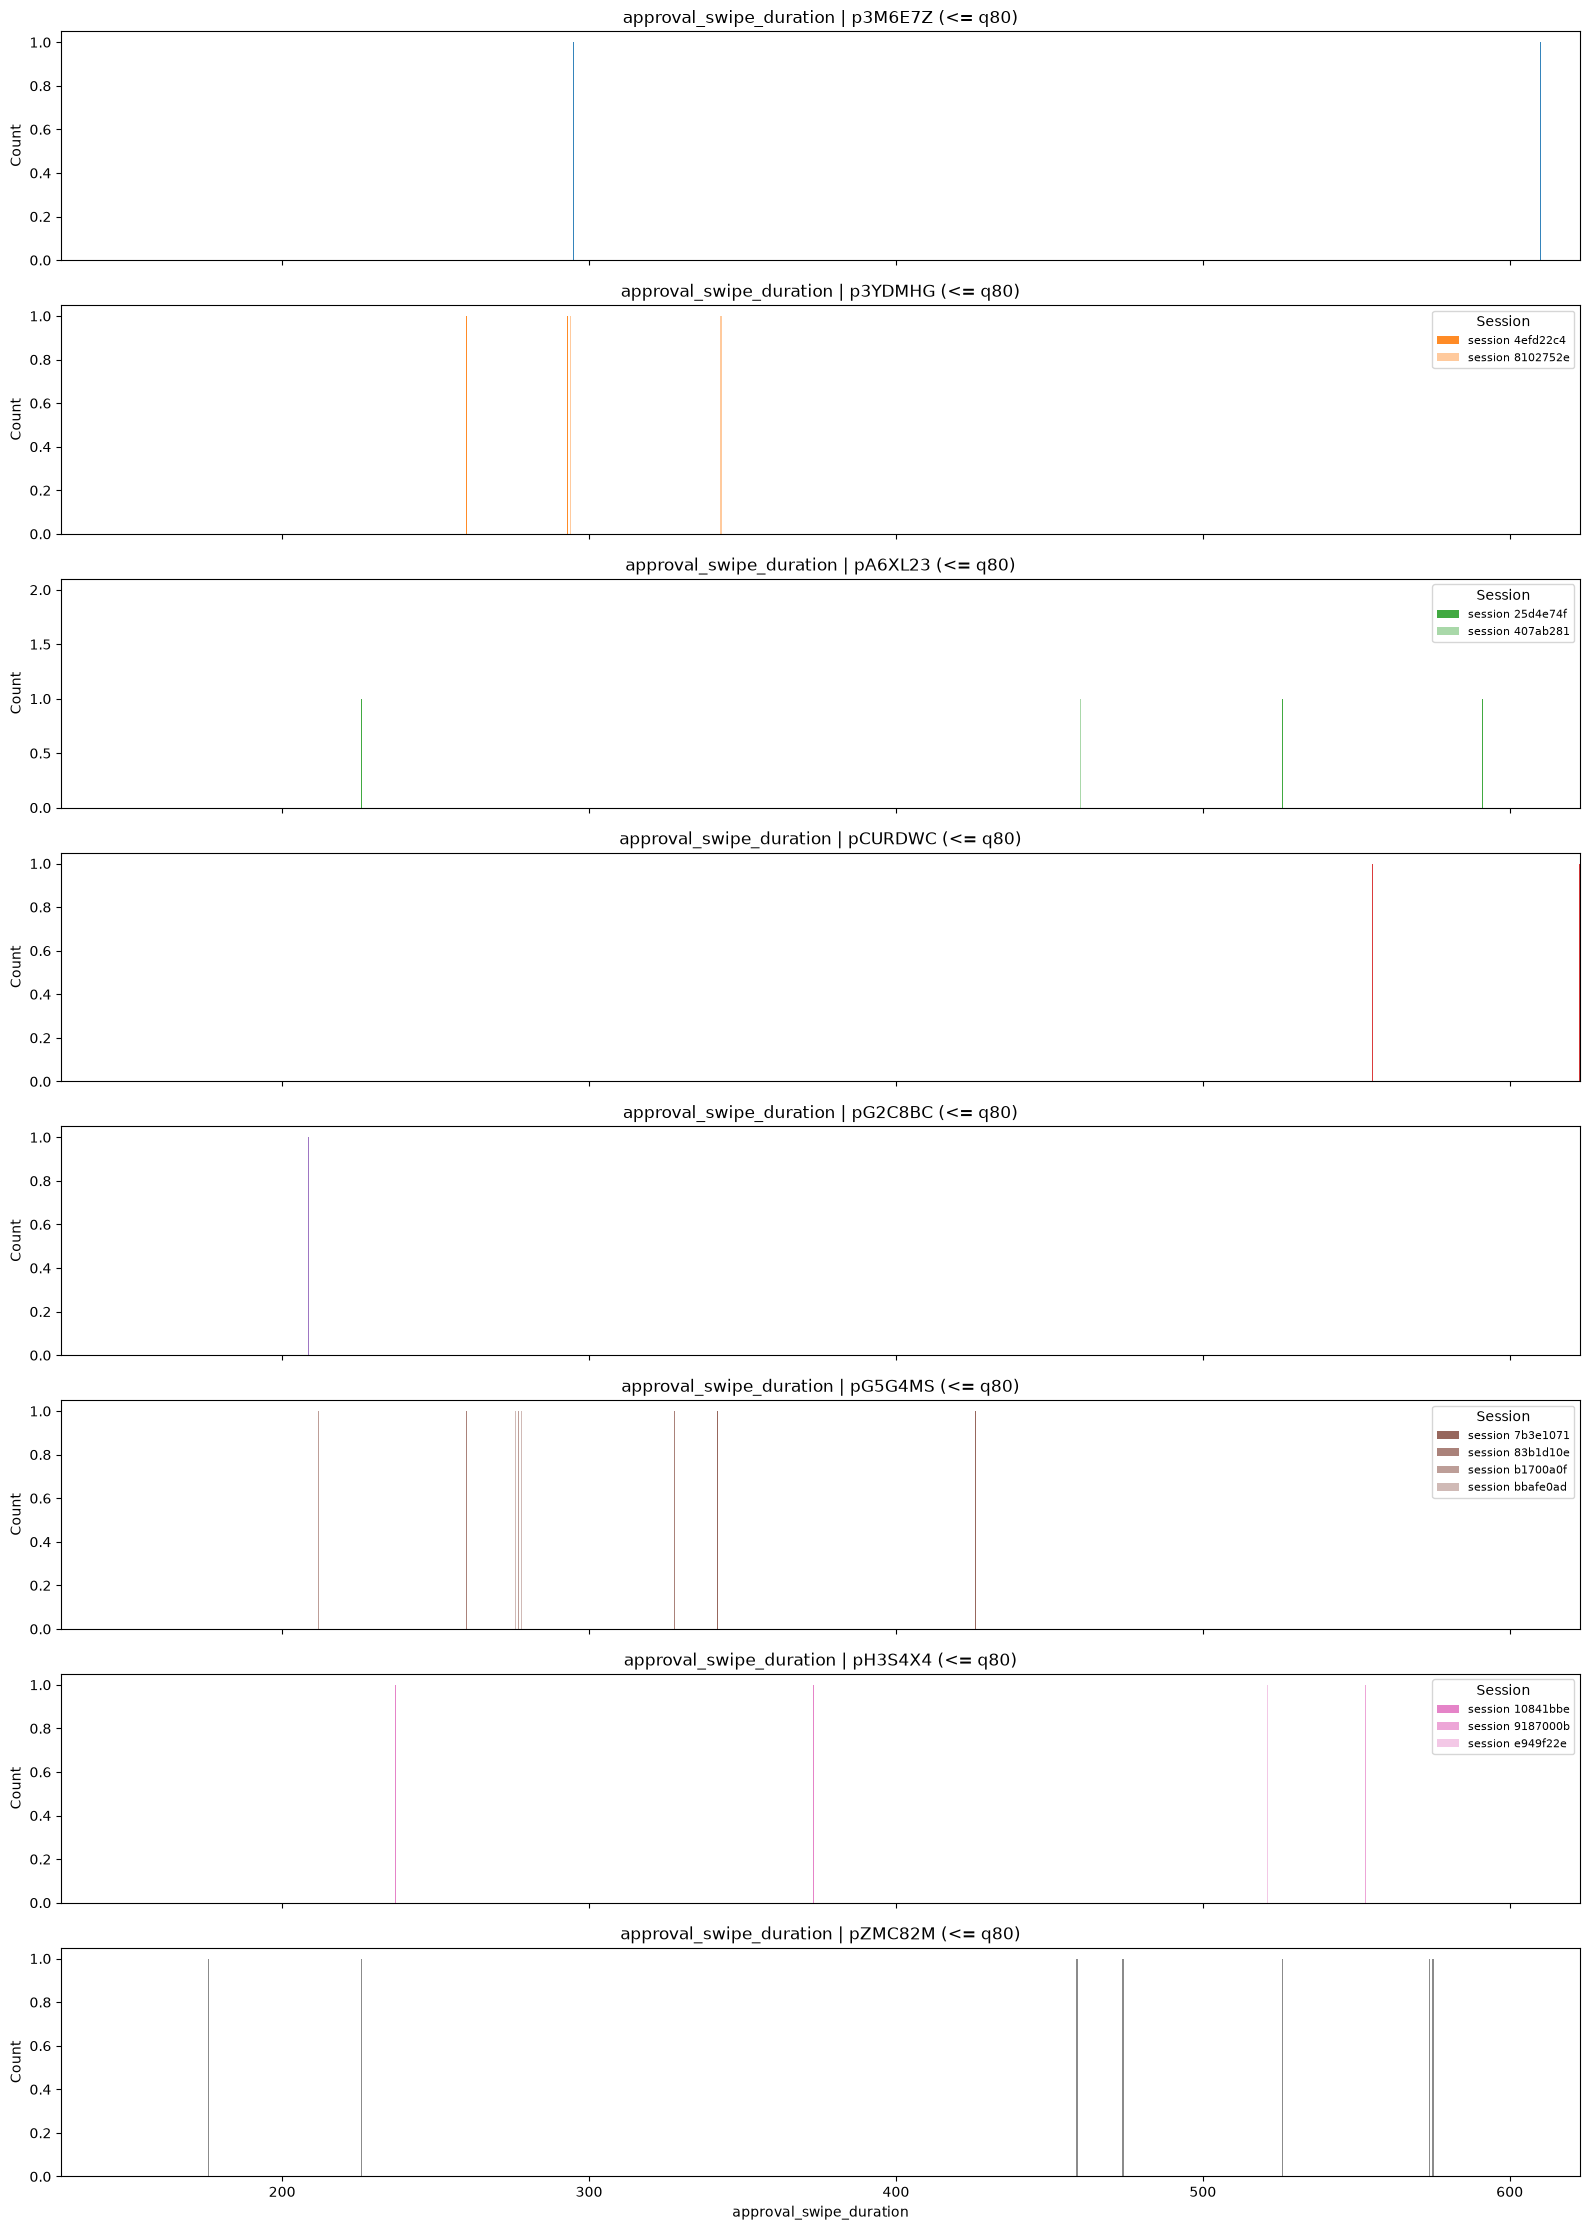

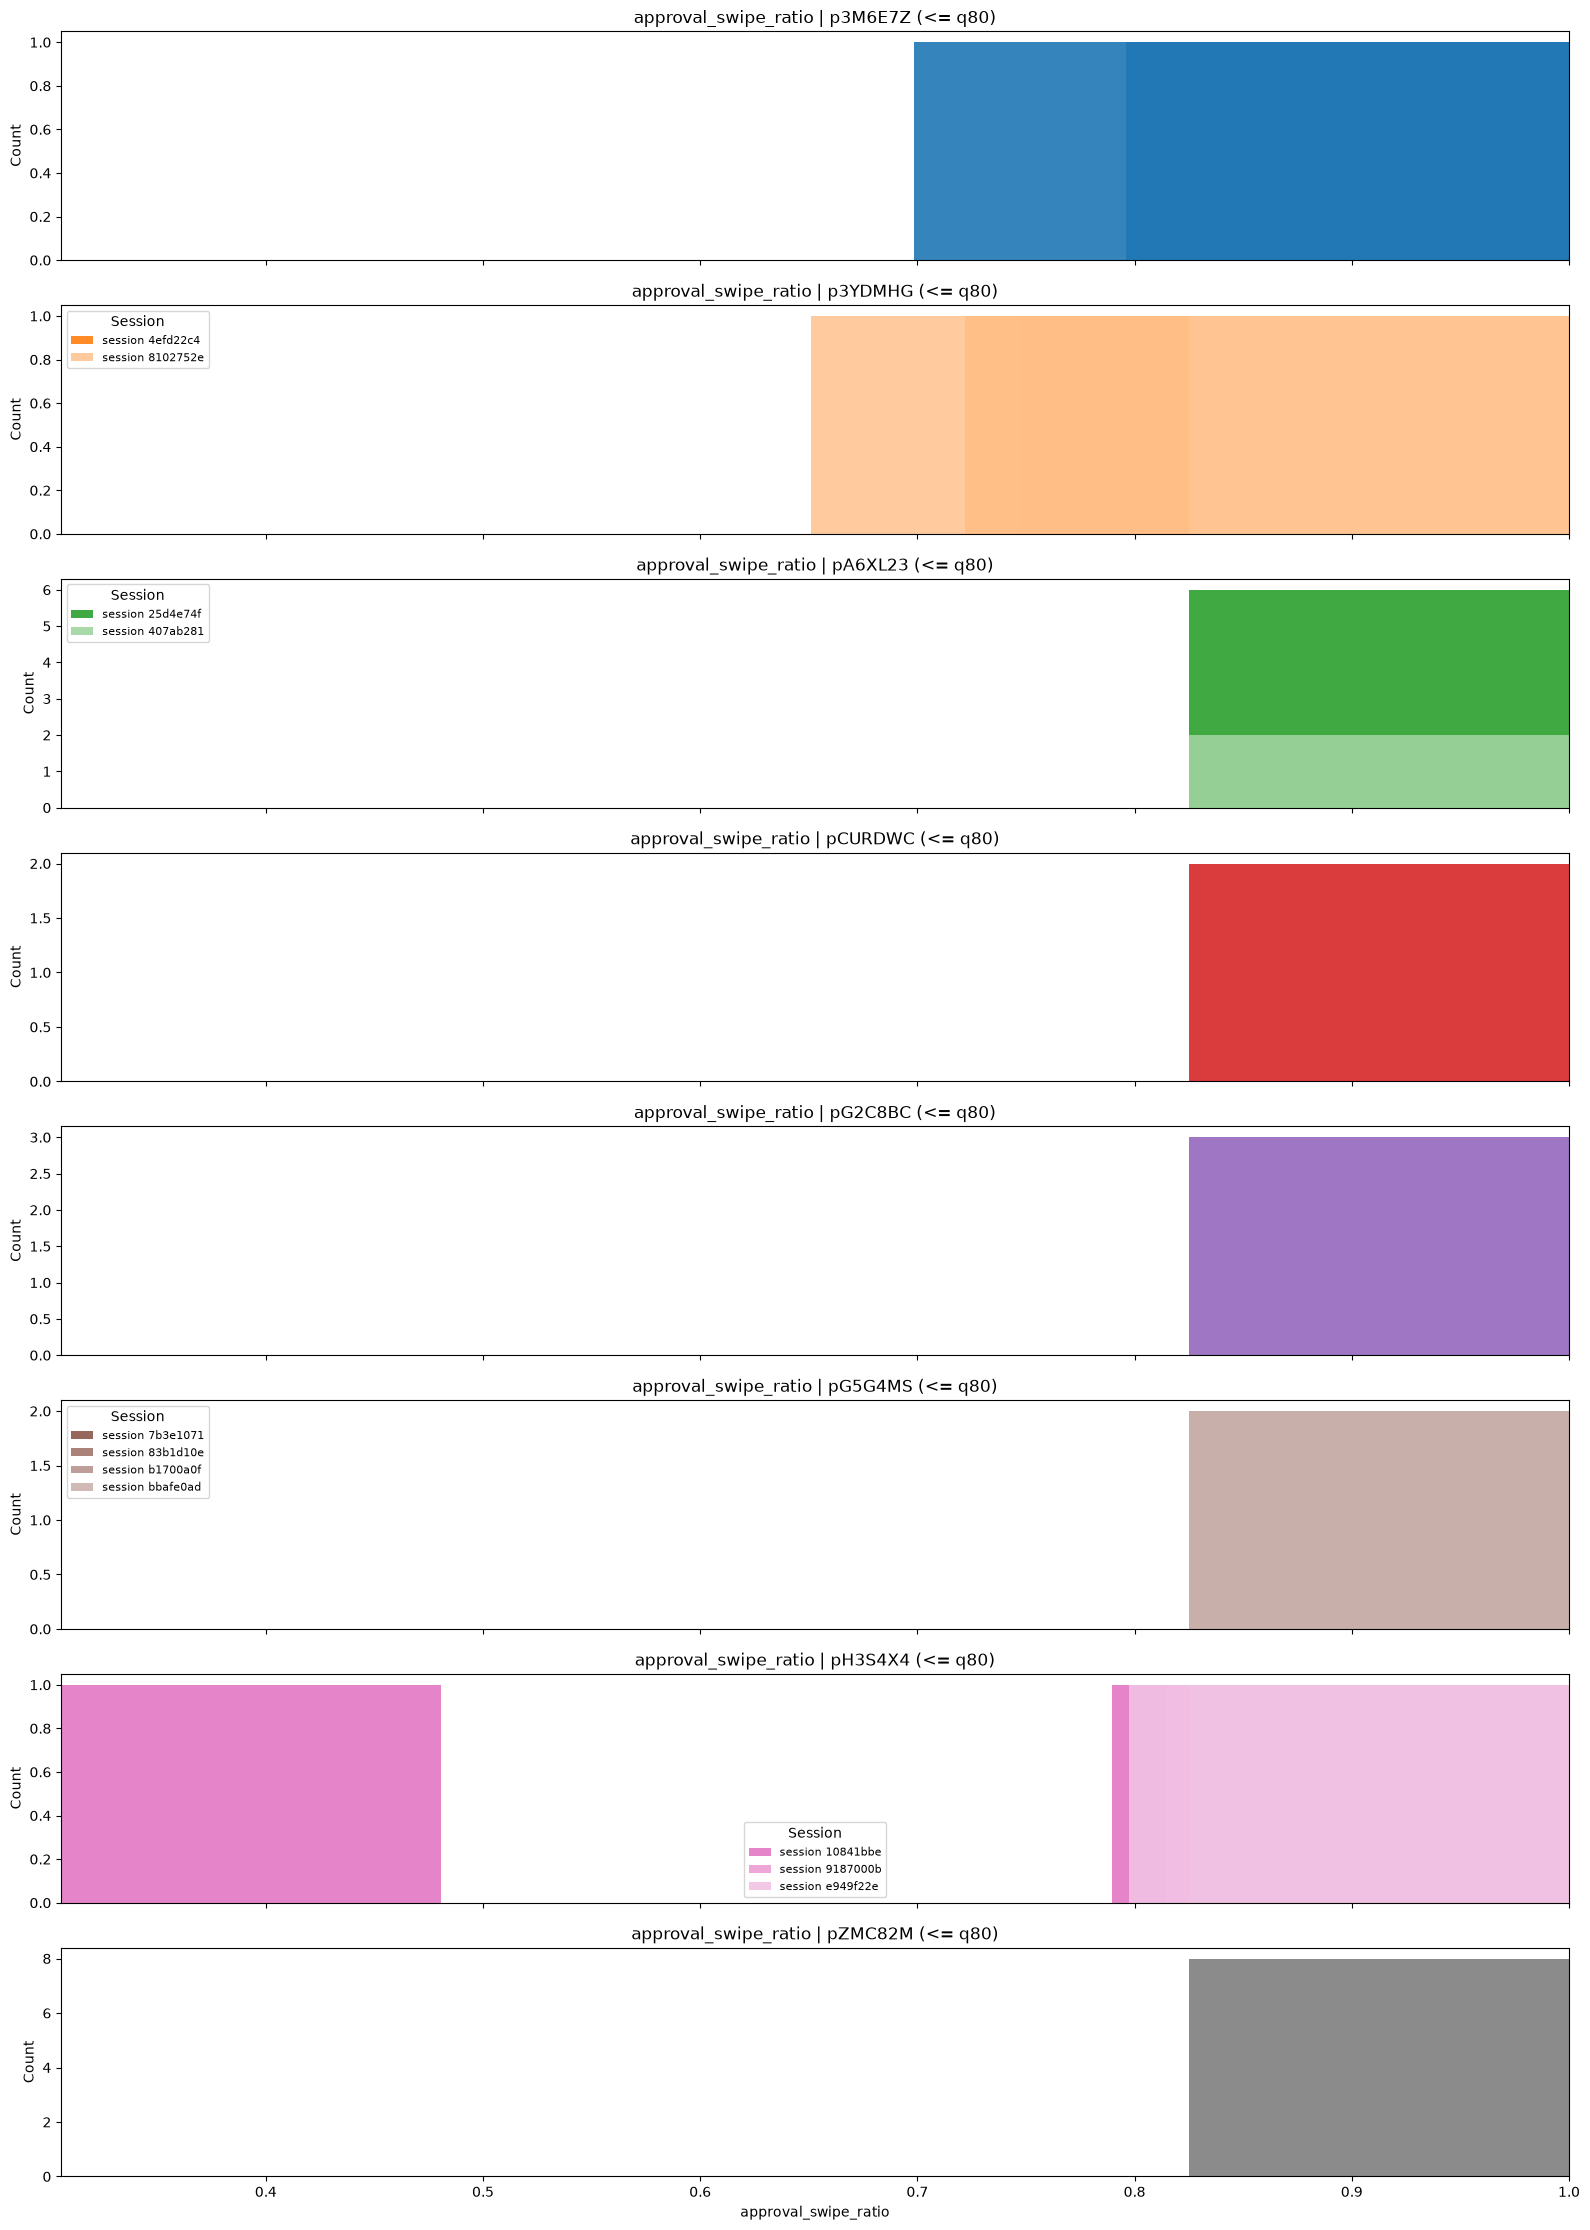

In [8]:
for m in metrics_in_scope:
    plot_metric_by_participant_session_stacked(raw_metric_df, m)

## Activity-type split — P2-specific, not in P1's version

Confirmed valuable in this project already: mixing all activities dilutes signal that's
strong within a single activity context (`00_data_audit.ipynb` §10). Same check, applied
here to every raw metric rather than the one or two we happened to check by hand.

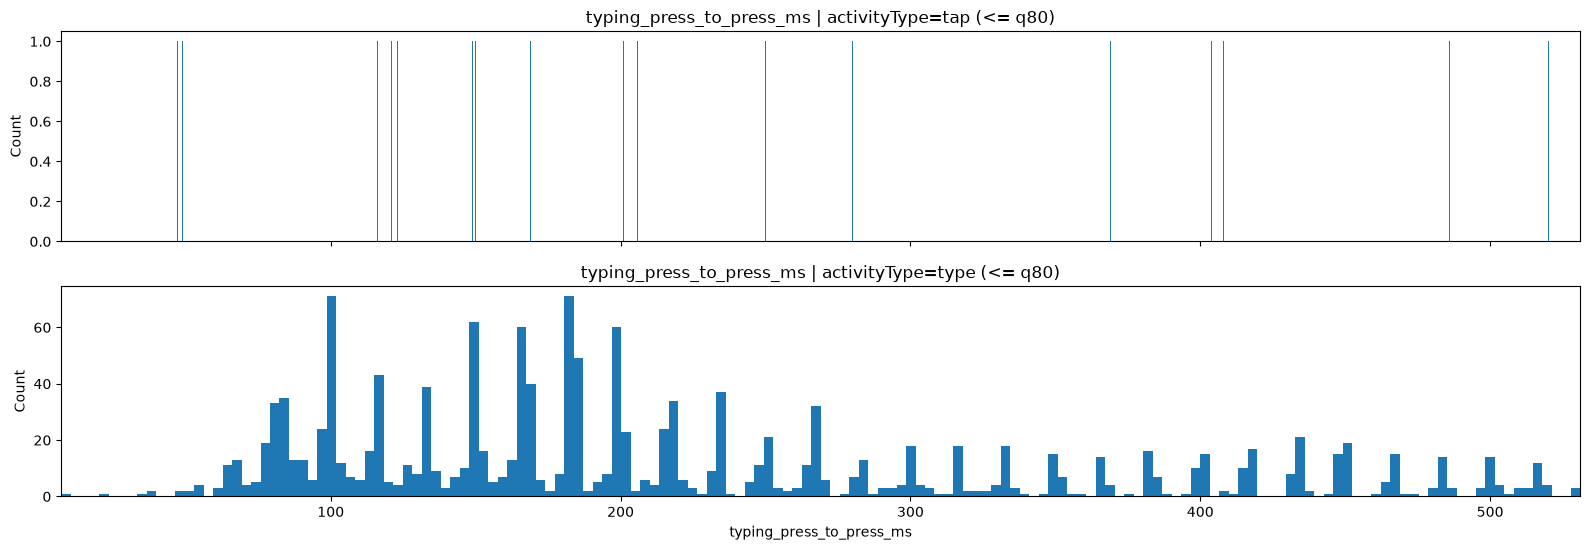

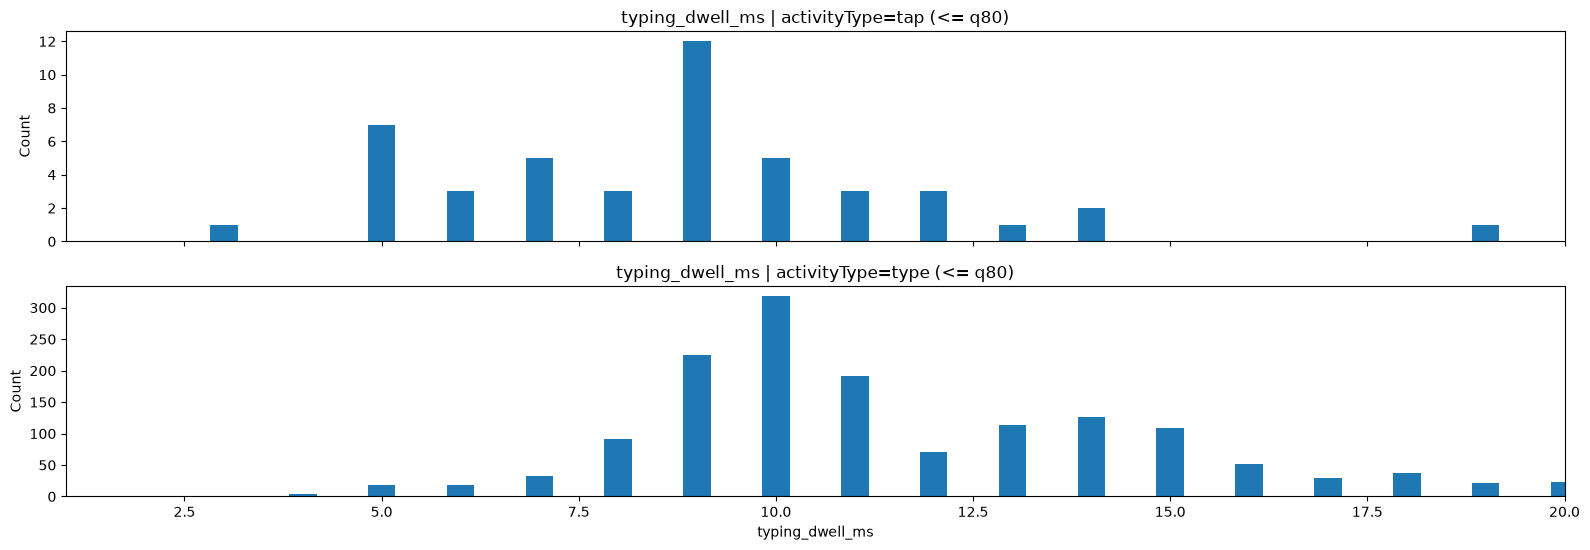

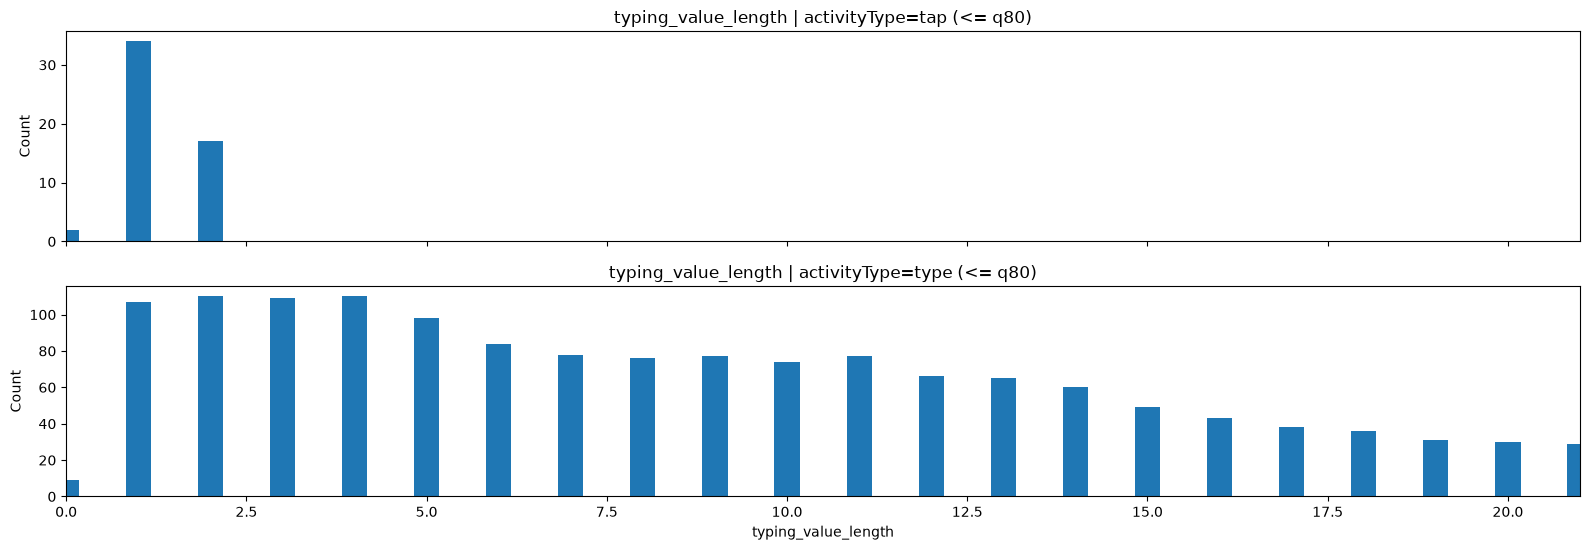

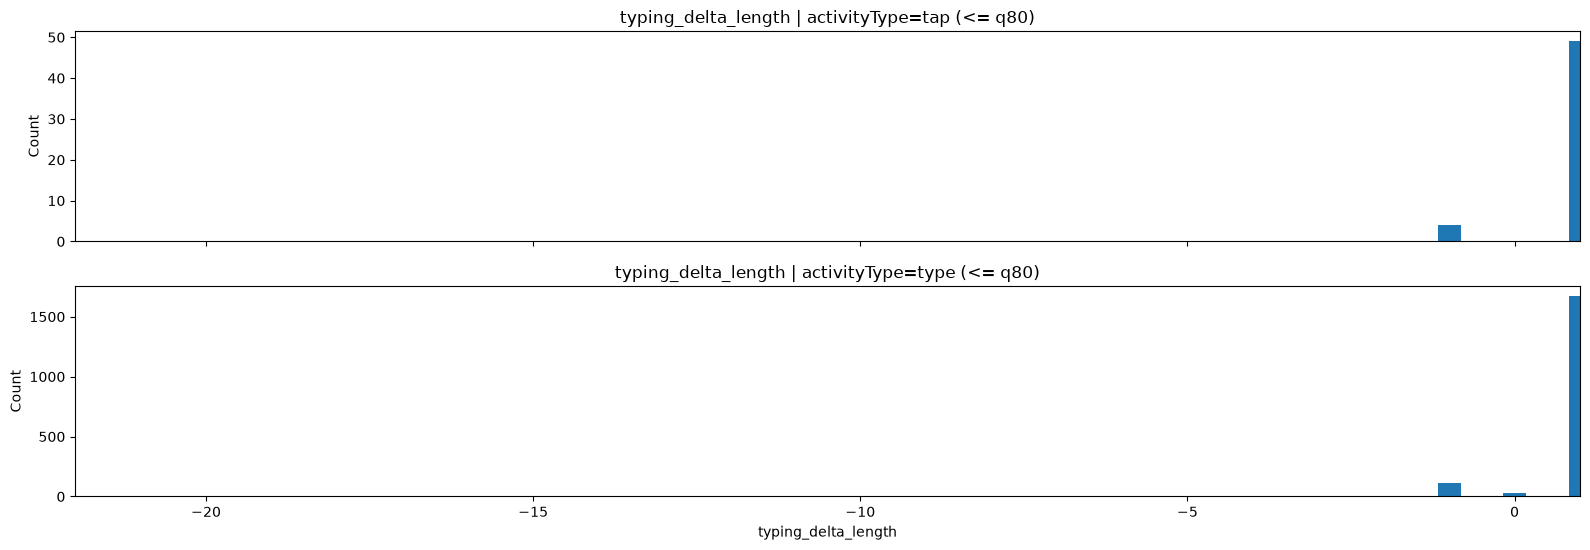

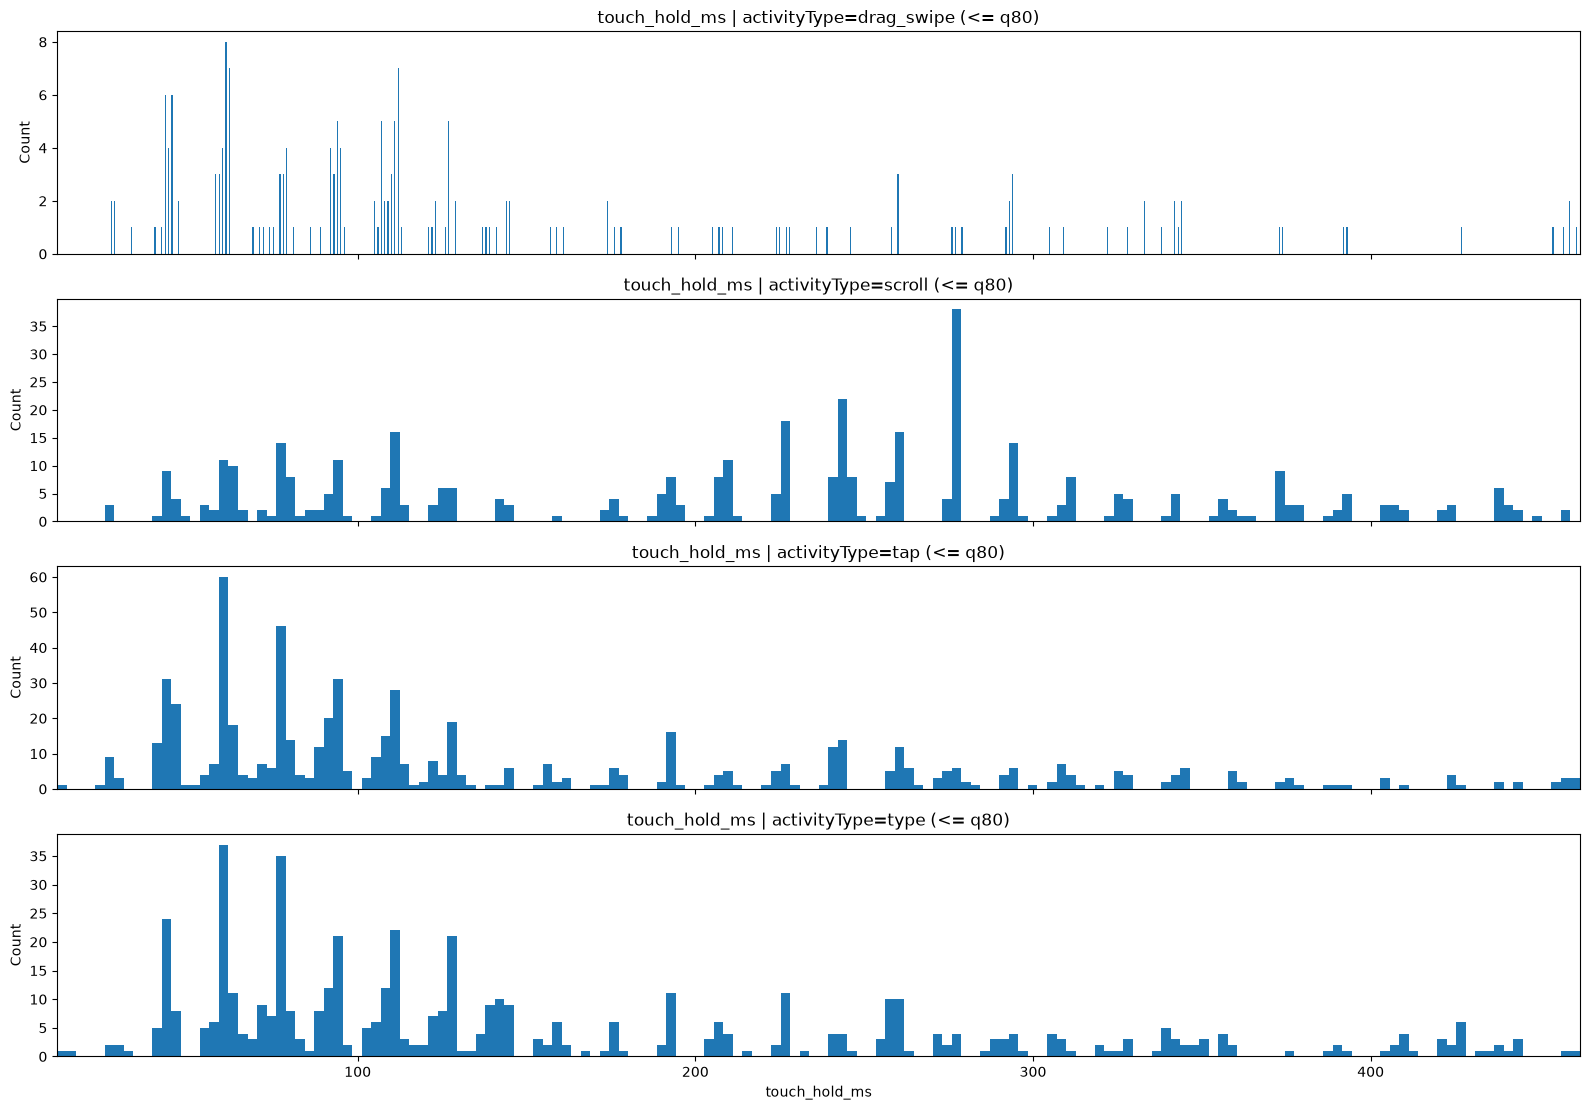

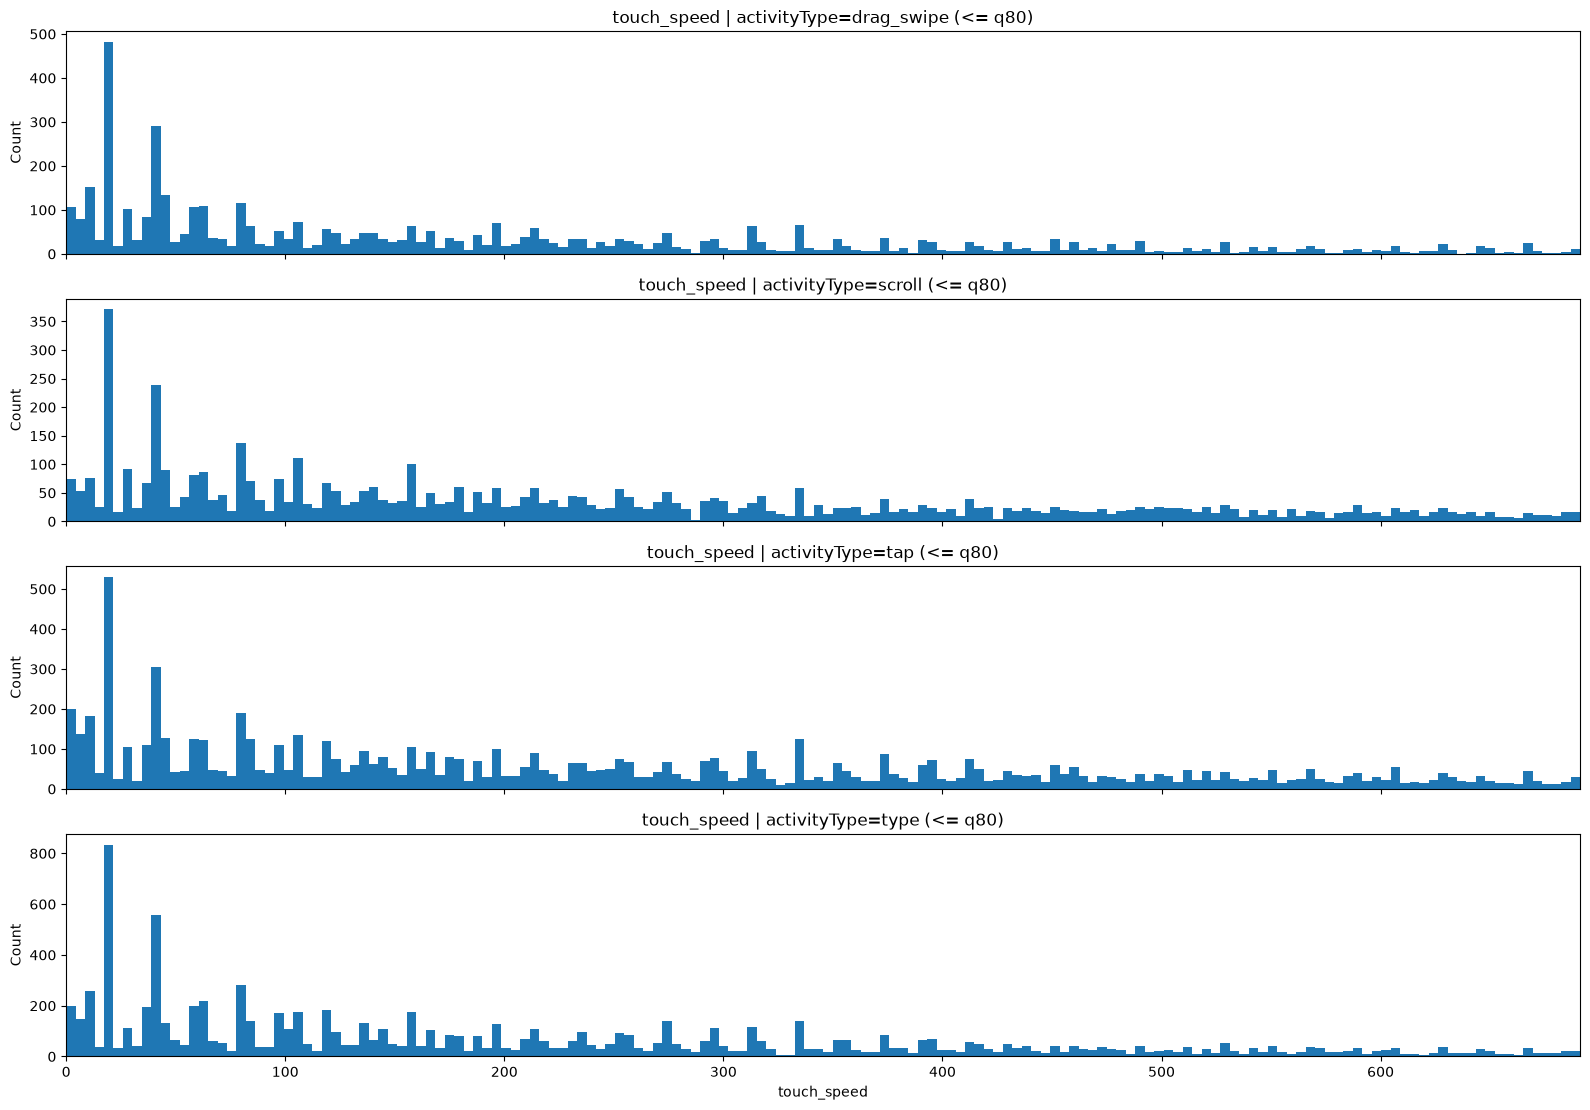

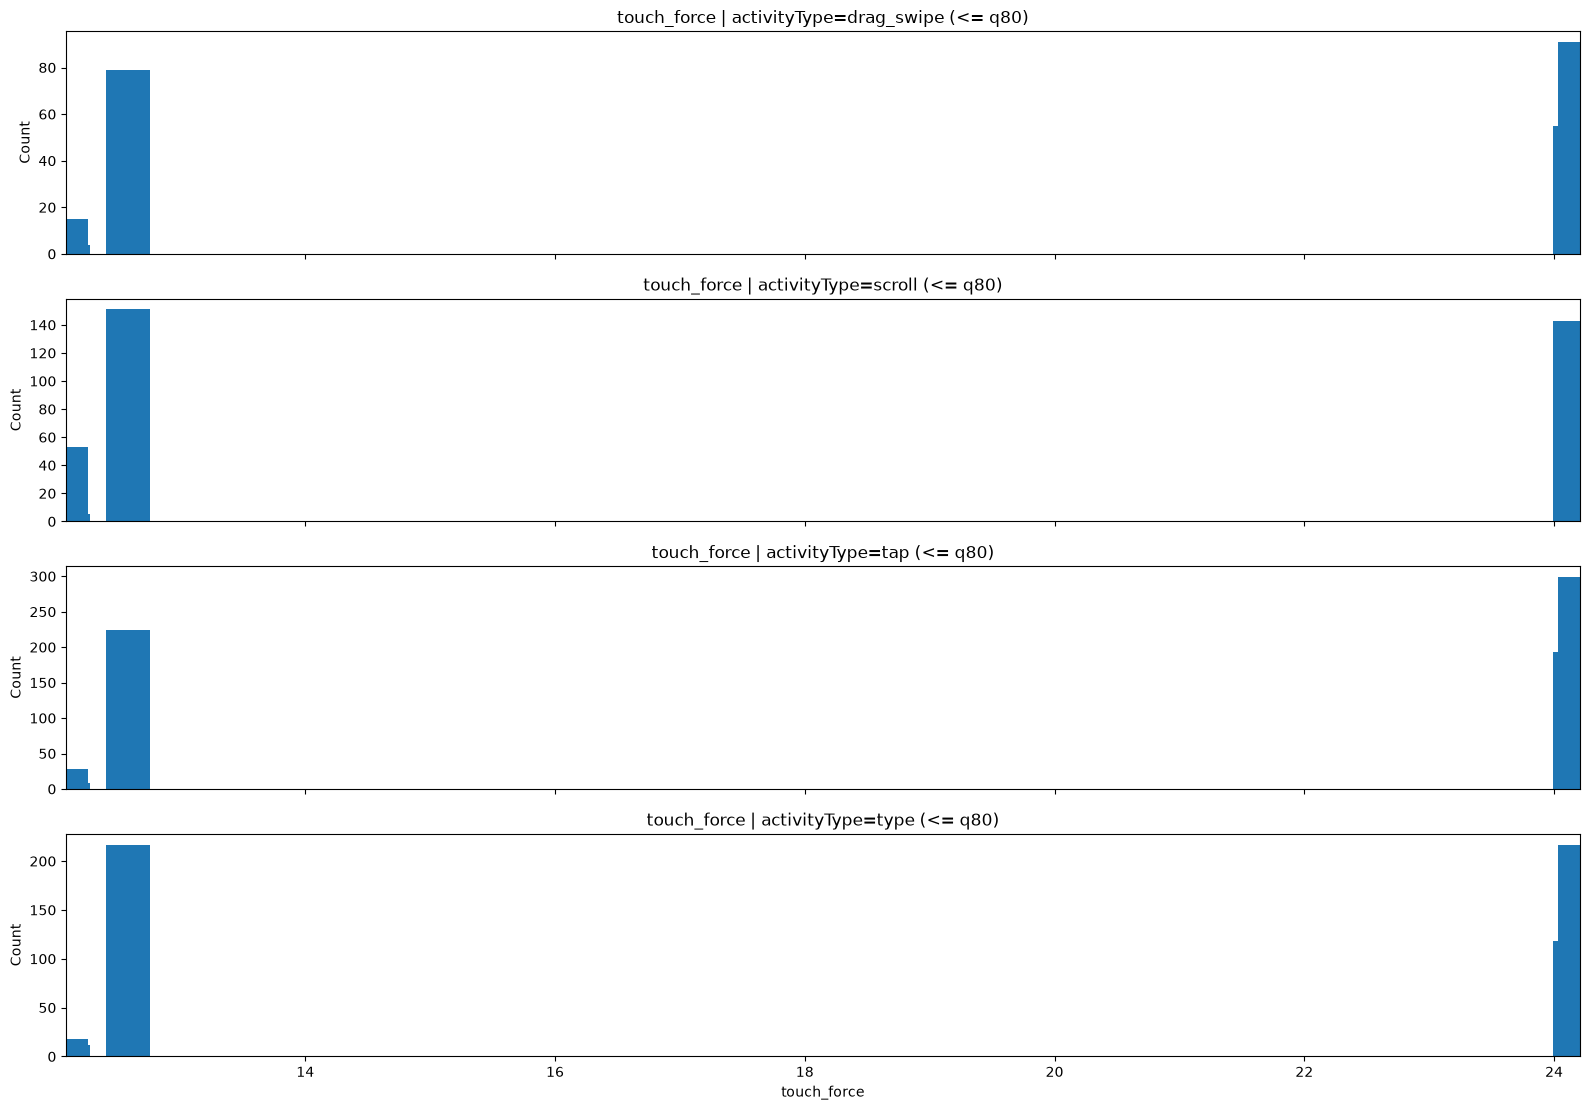

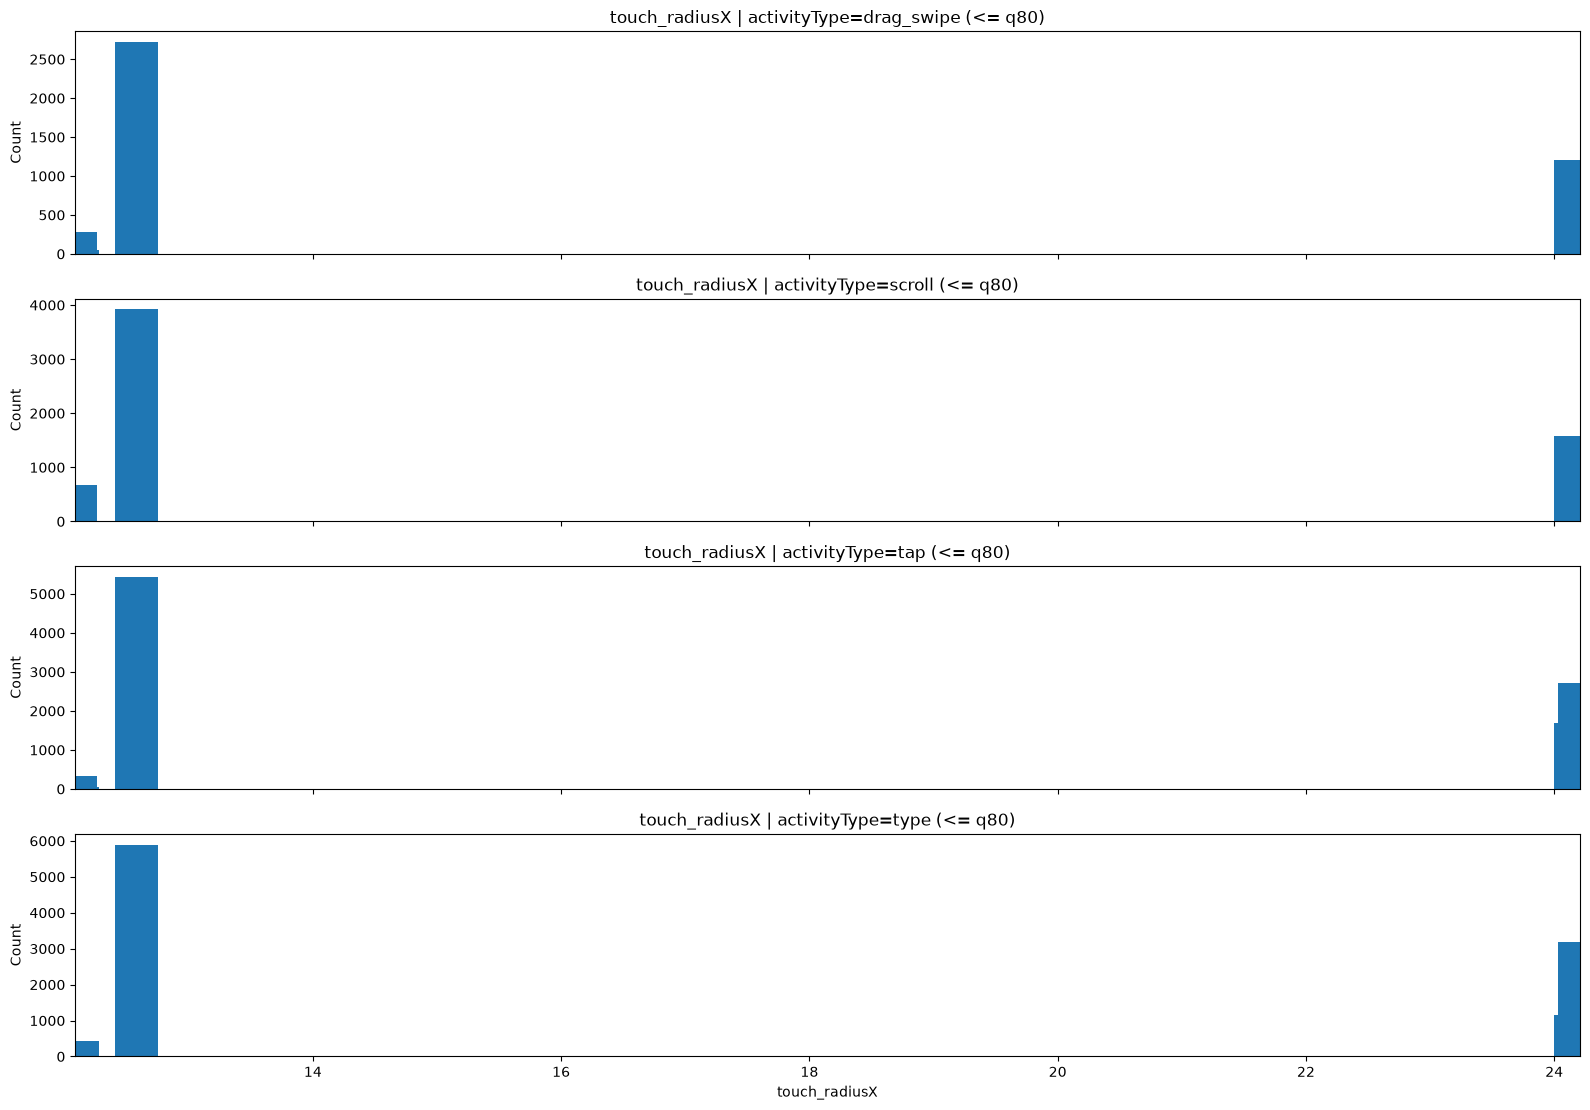

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)


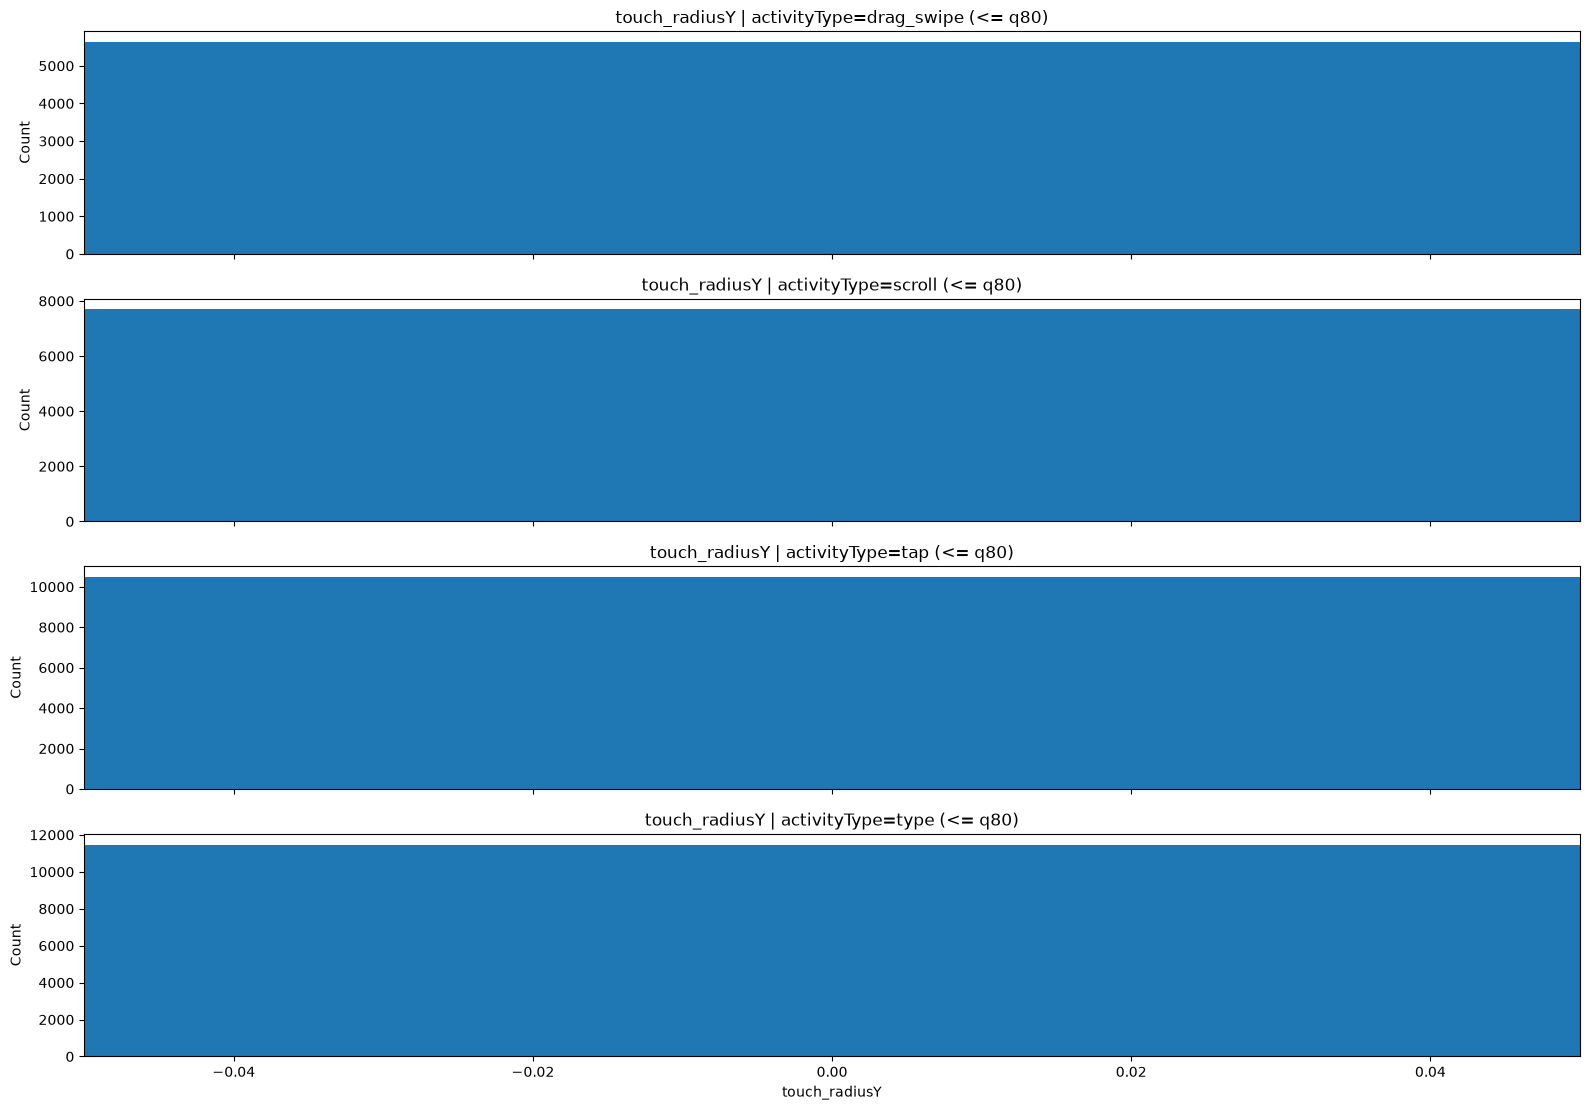

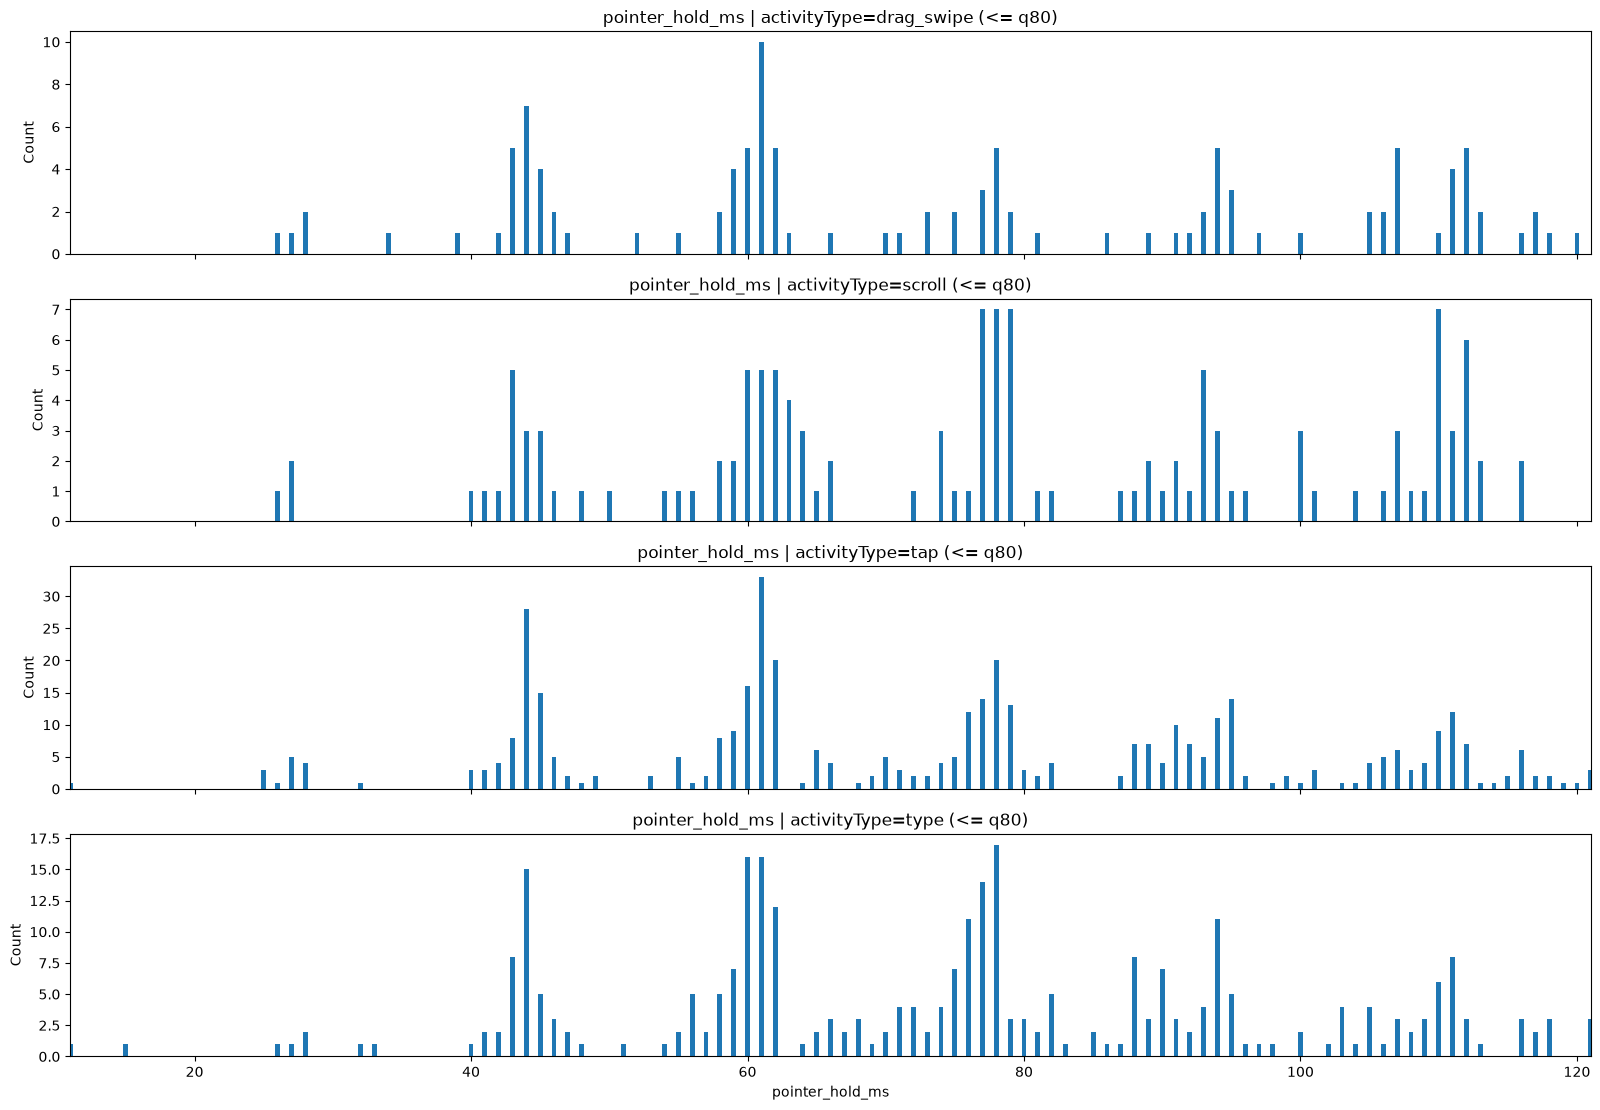

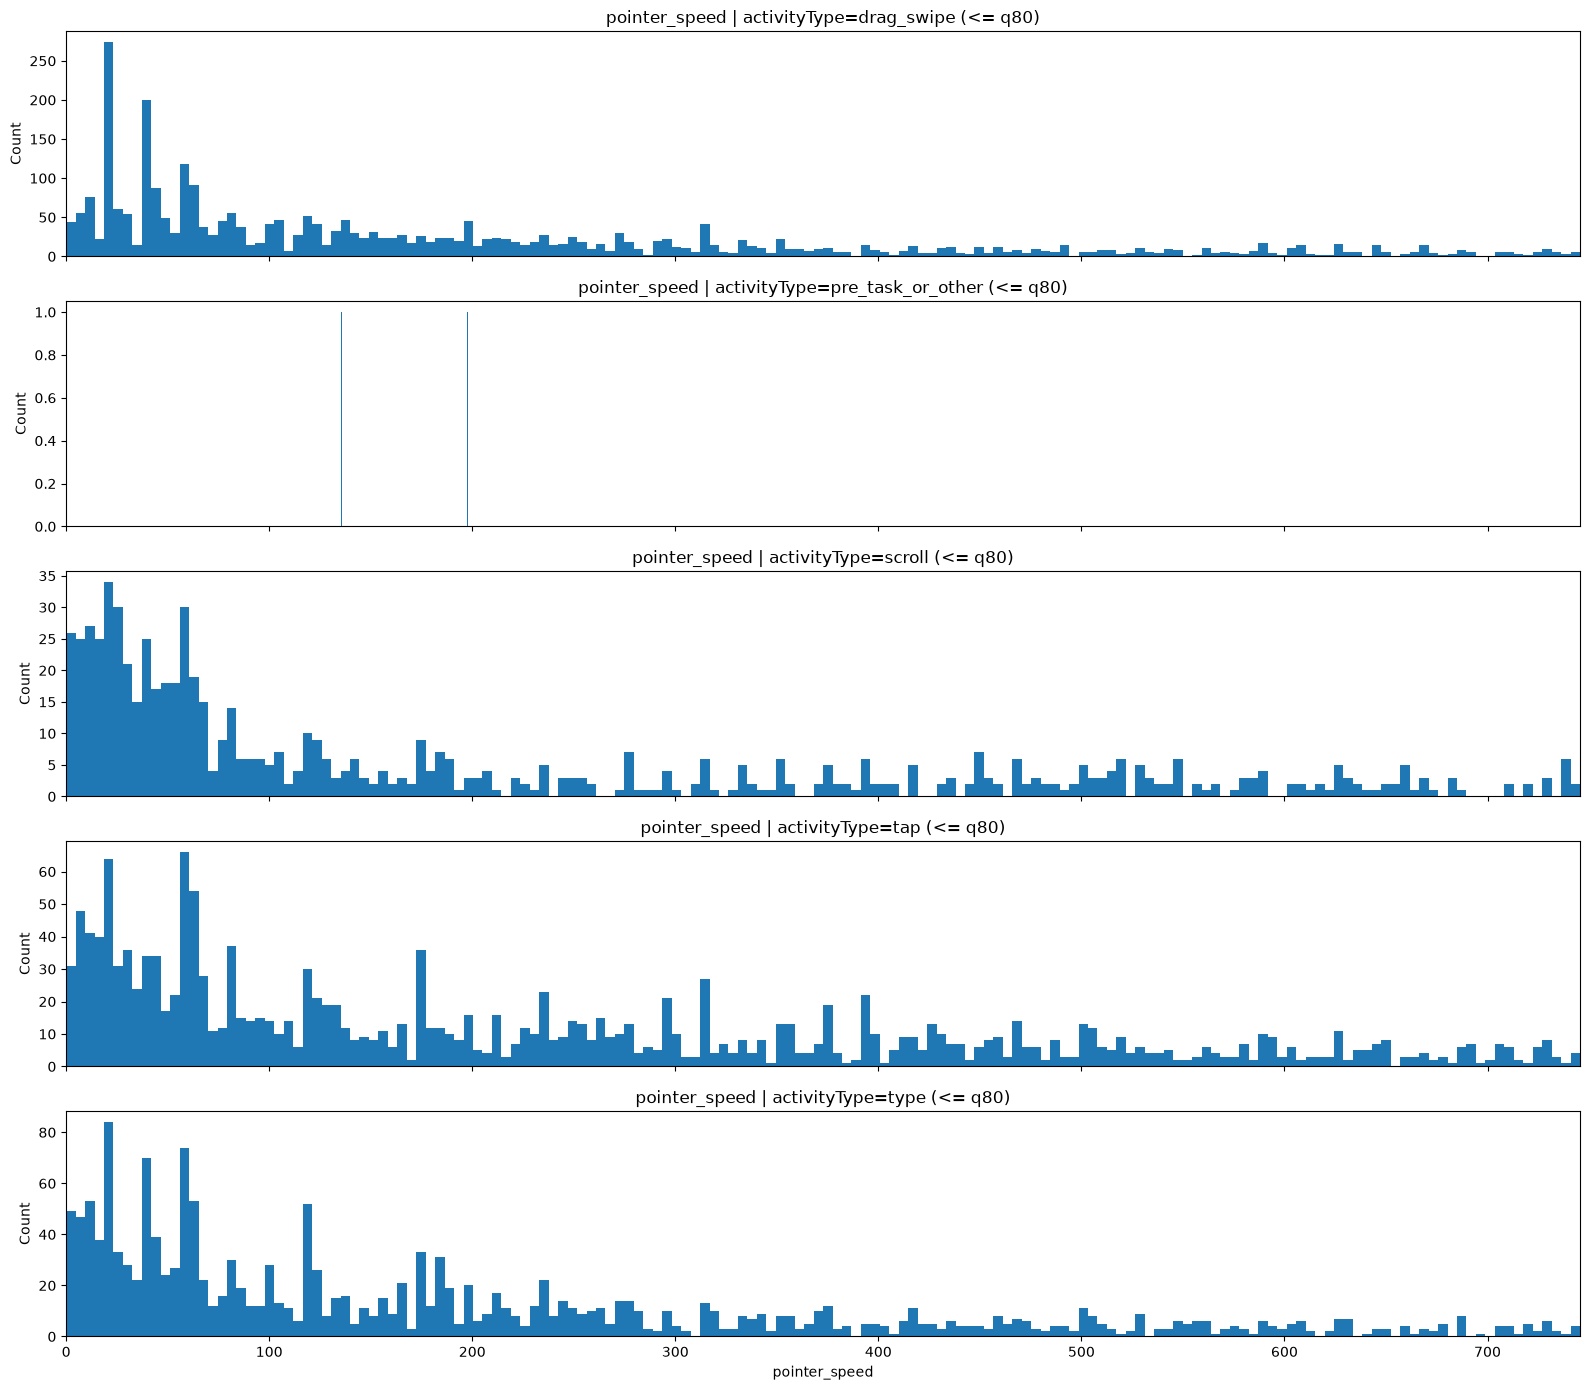

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarni

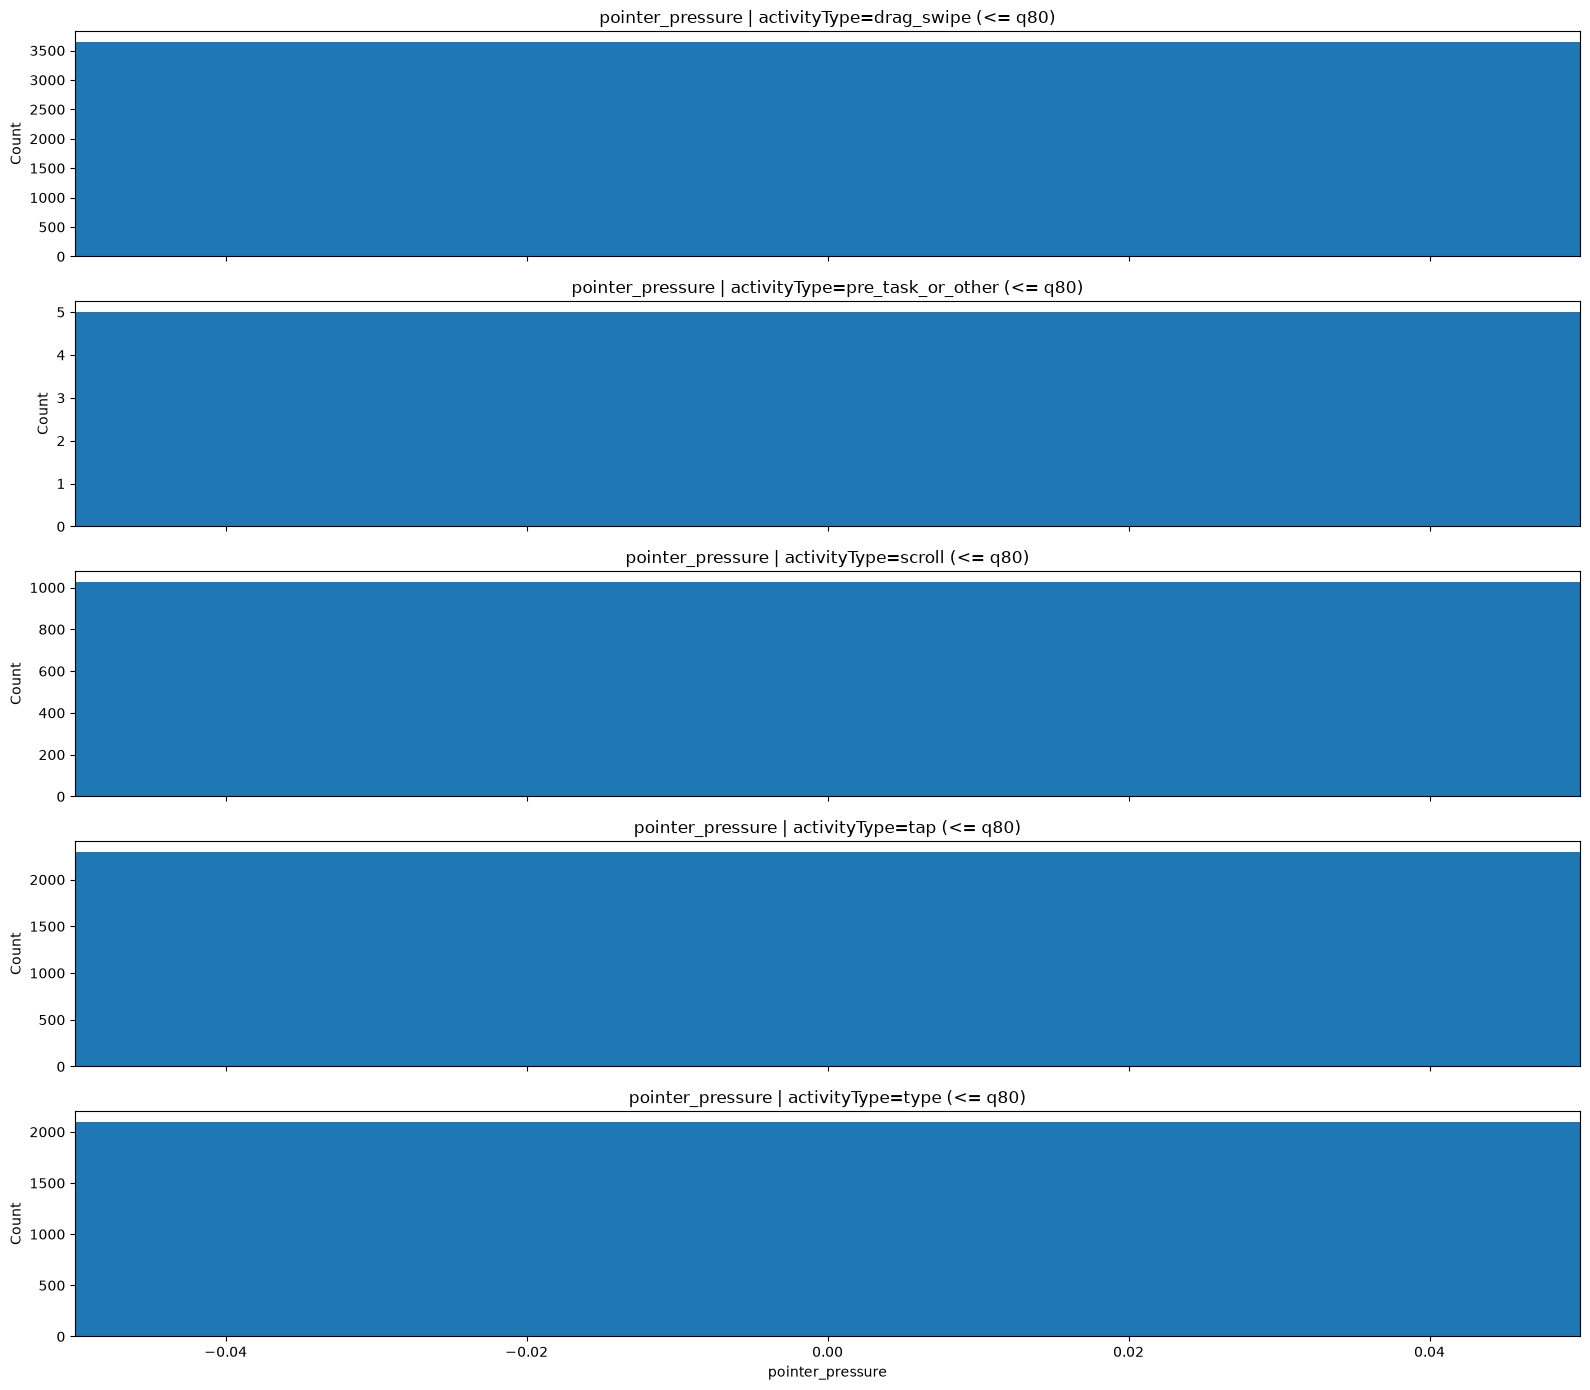

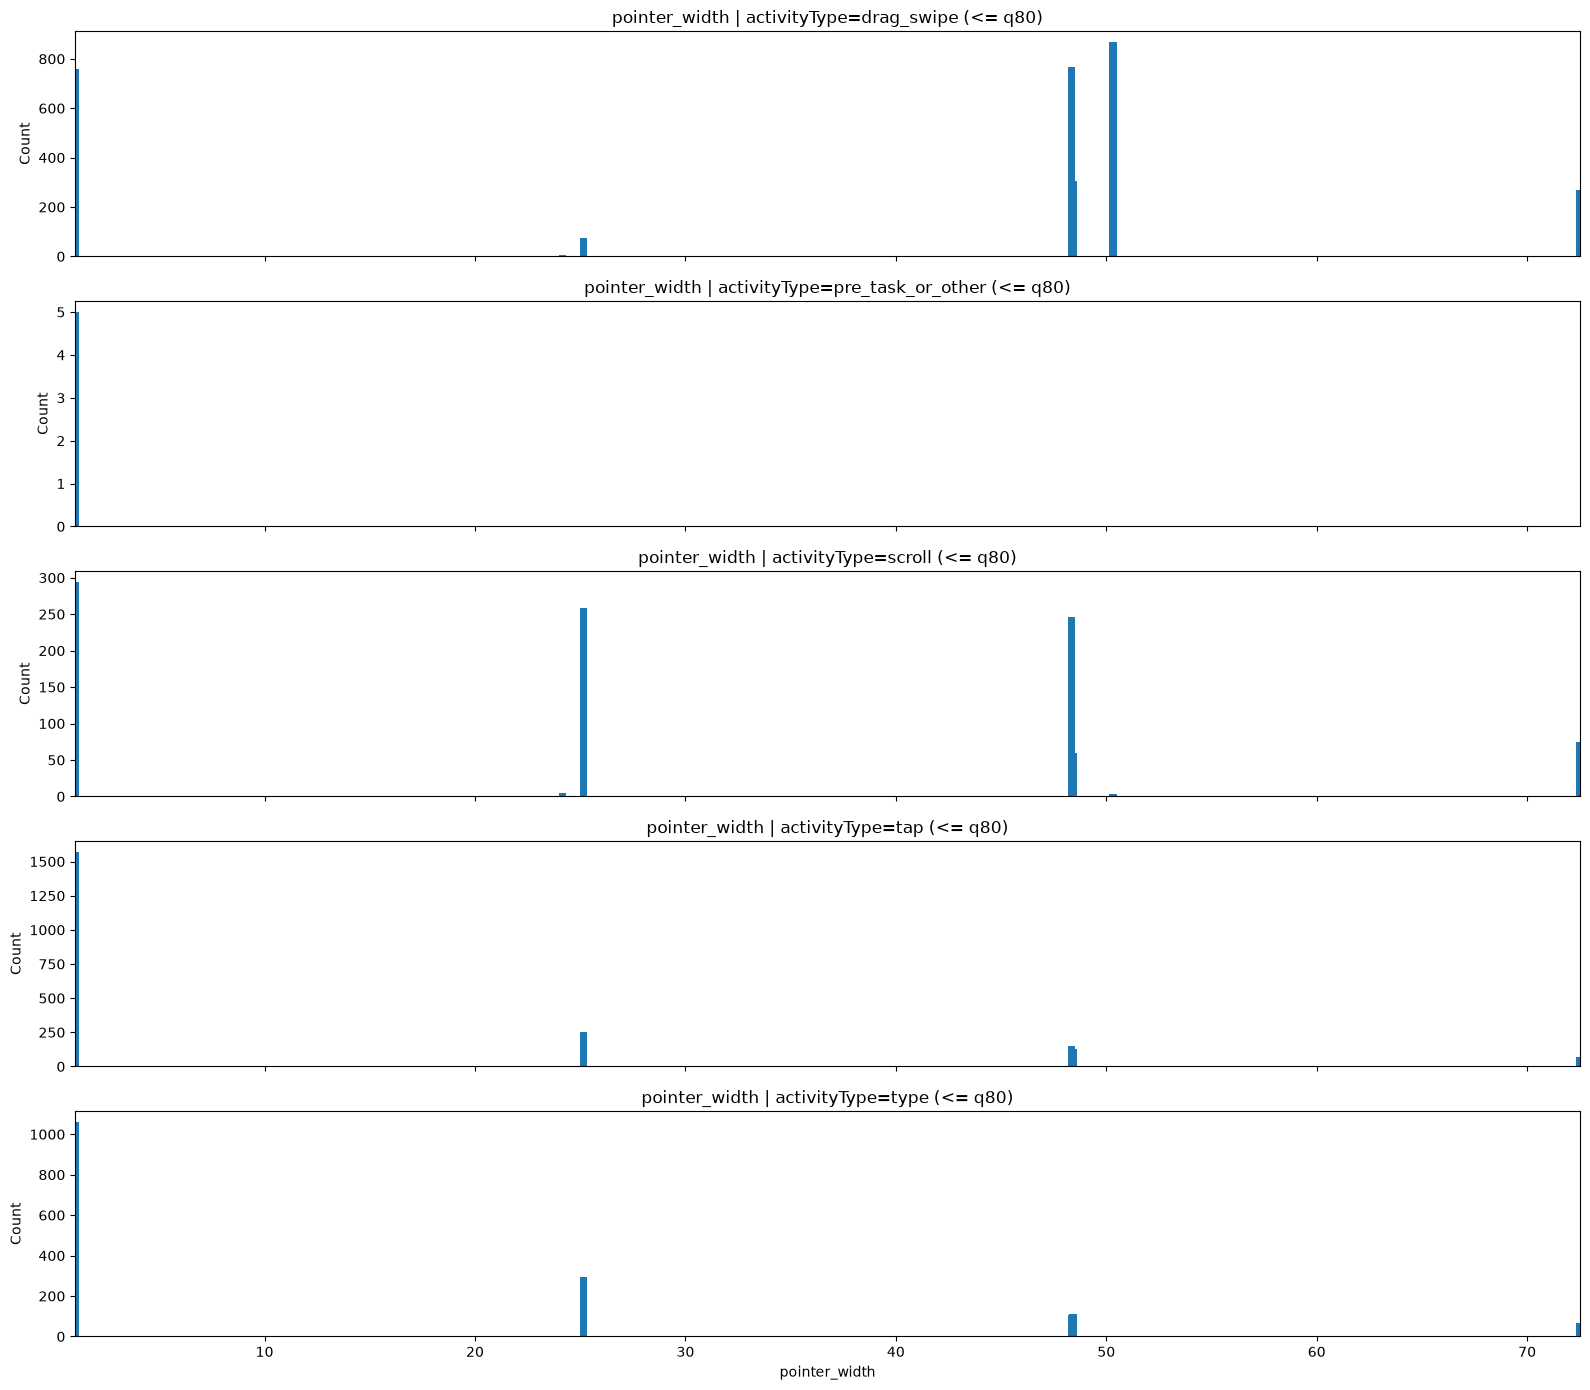

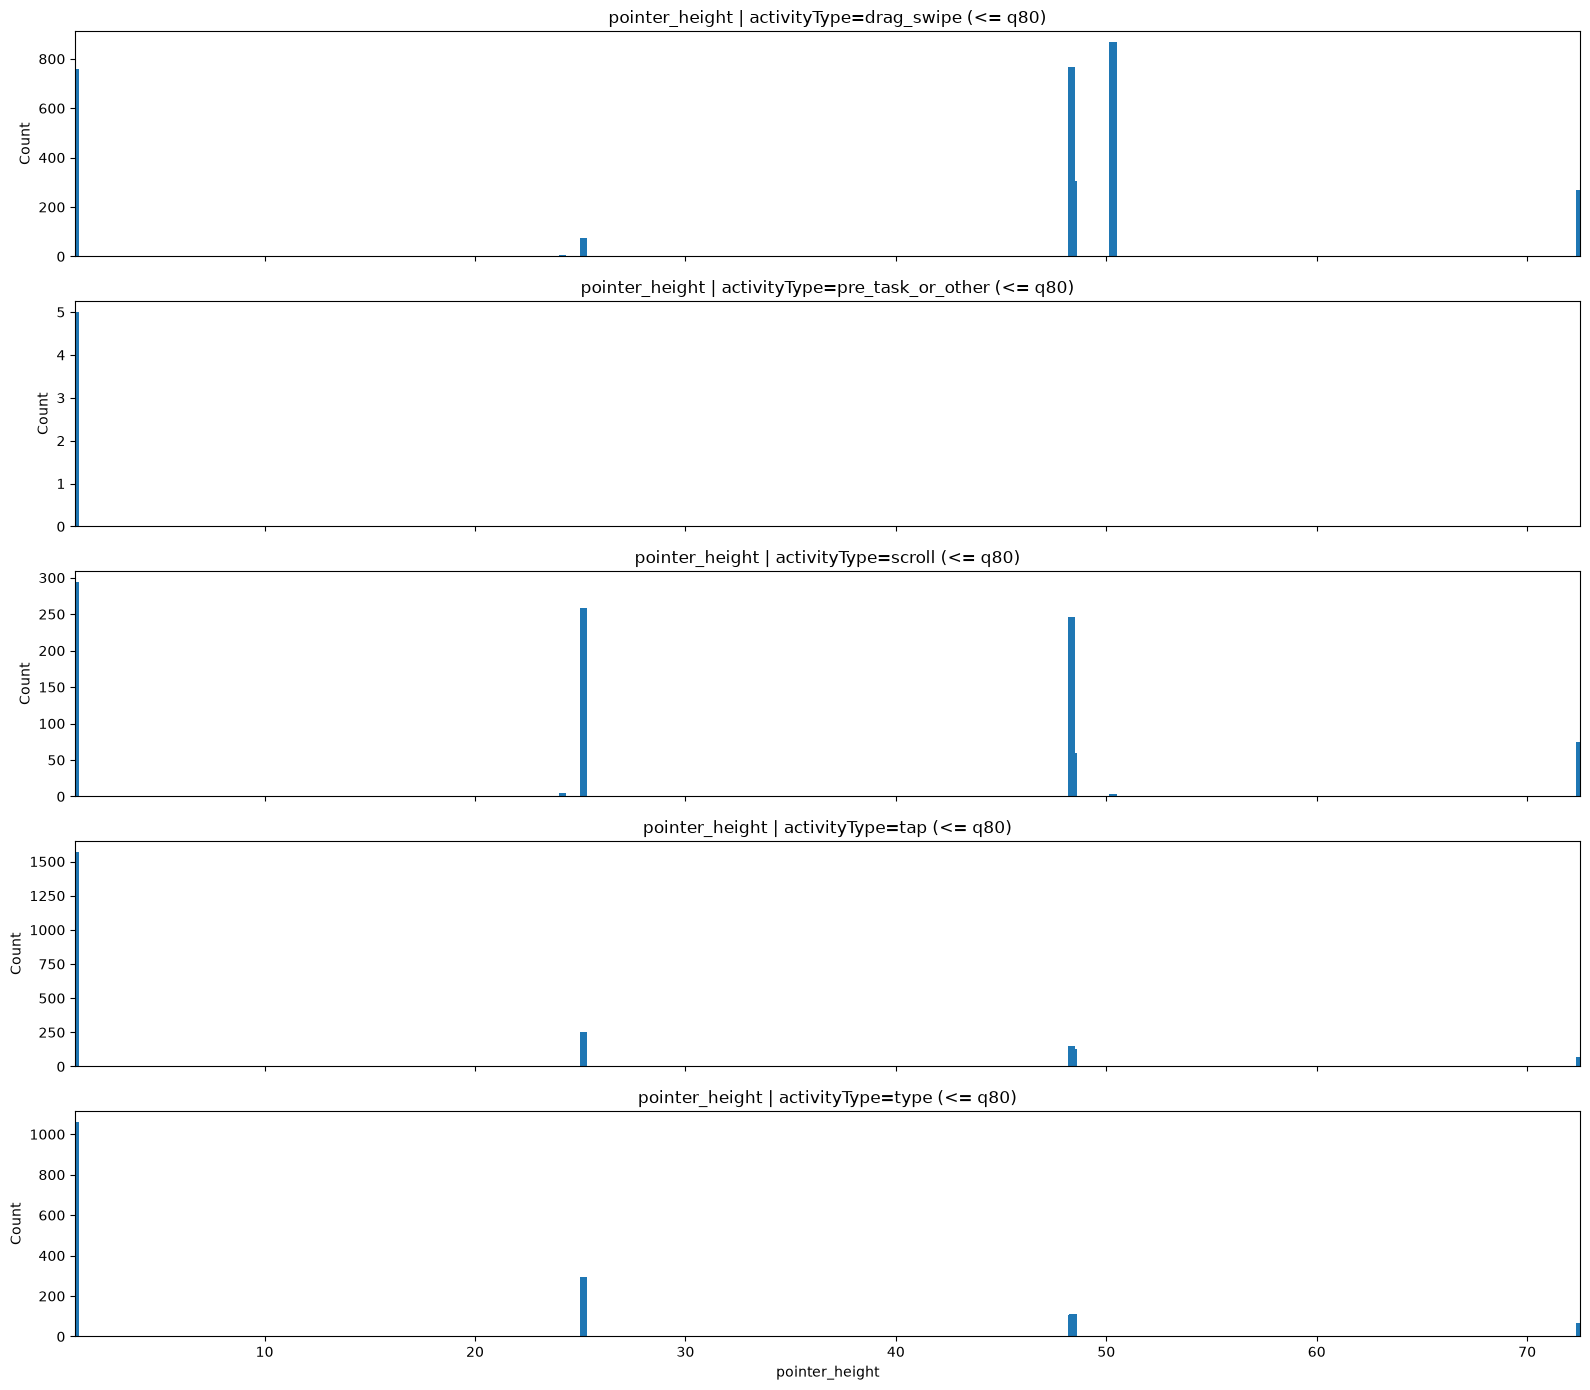

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarni

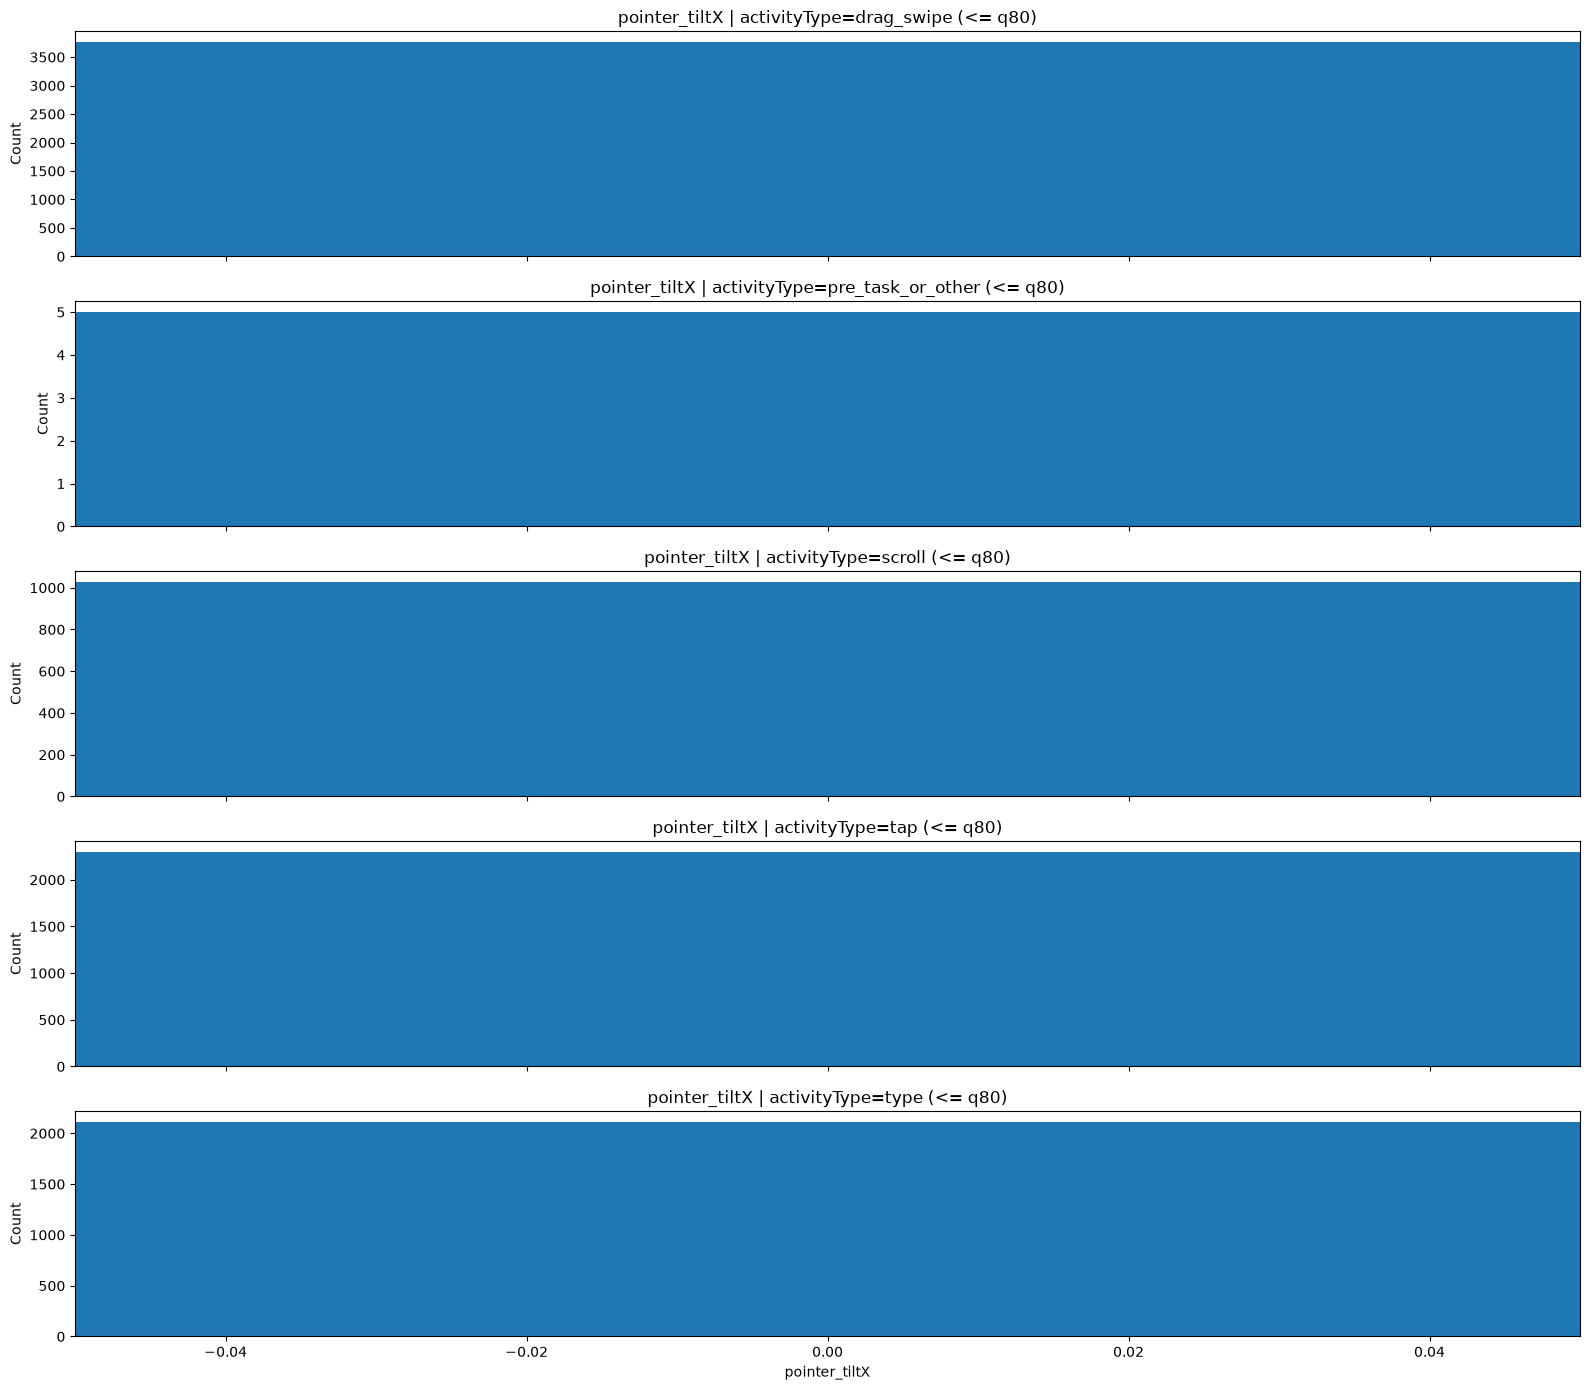

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarni

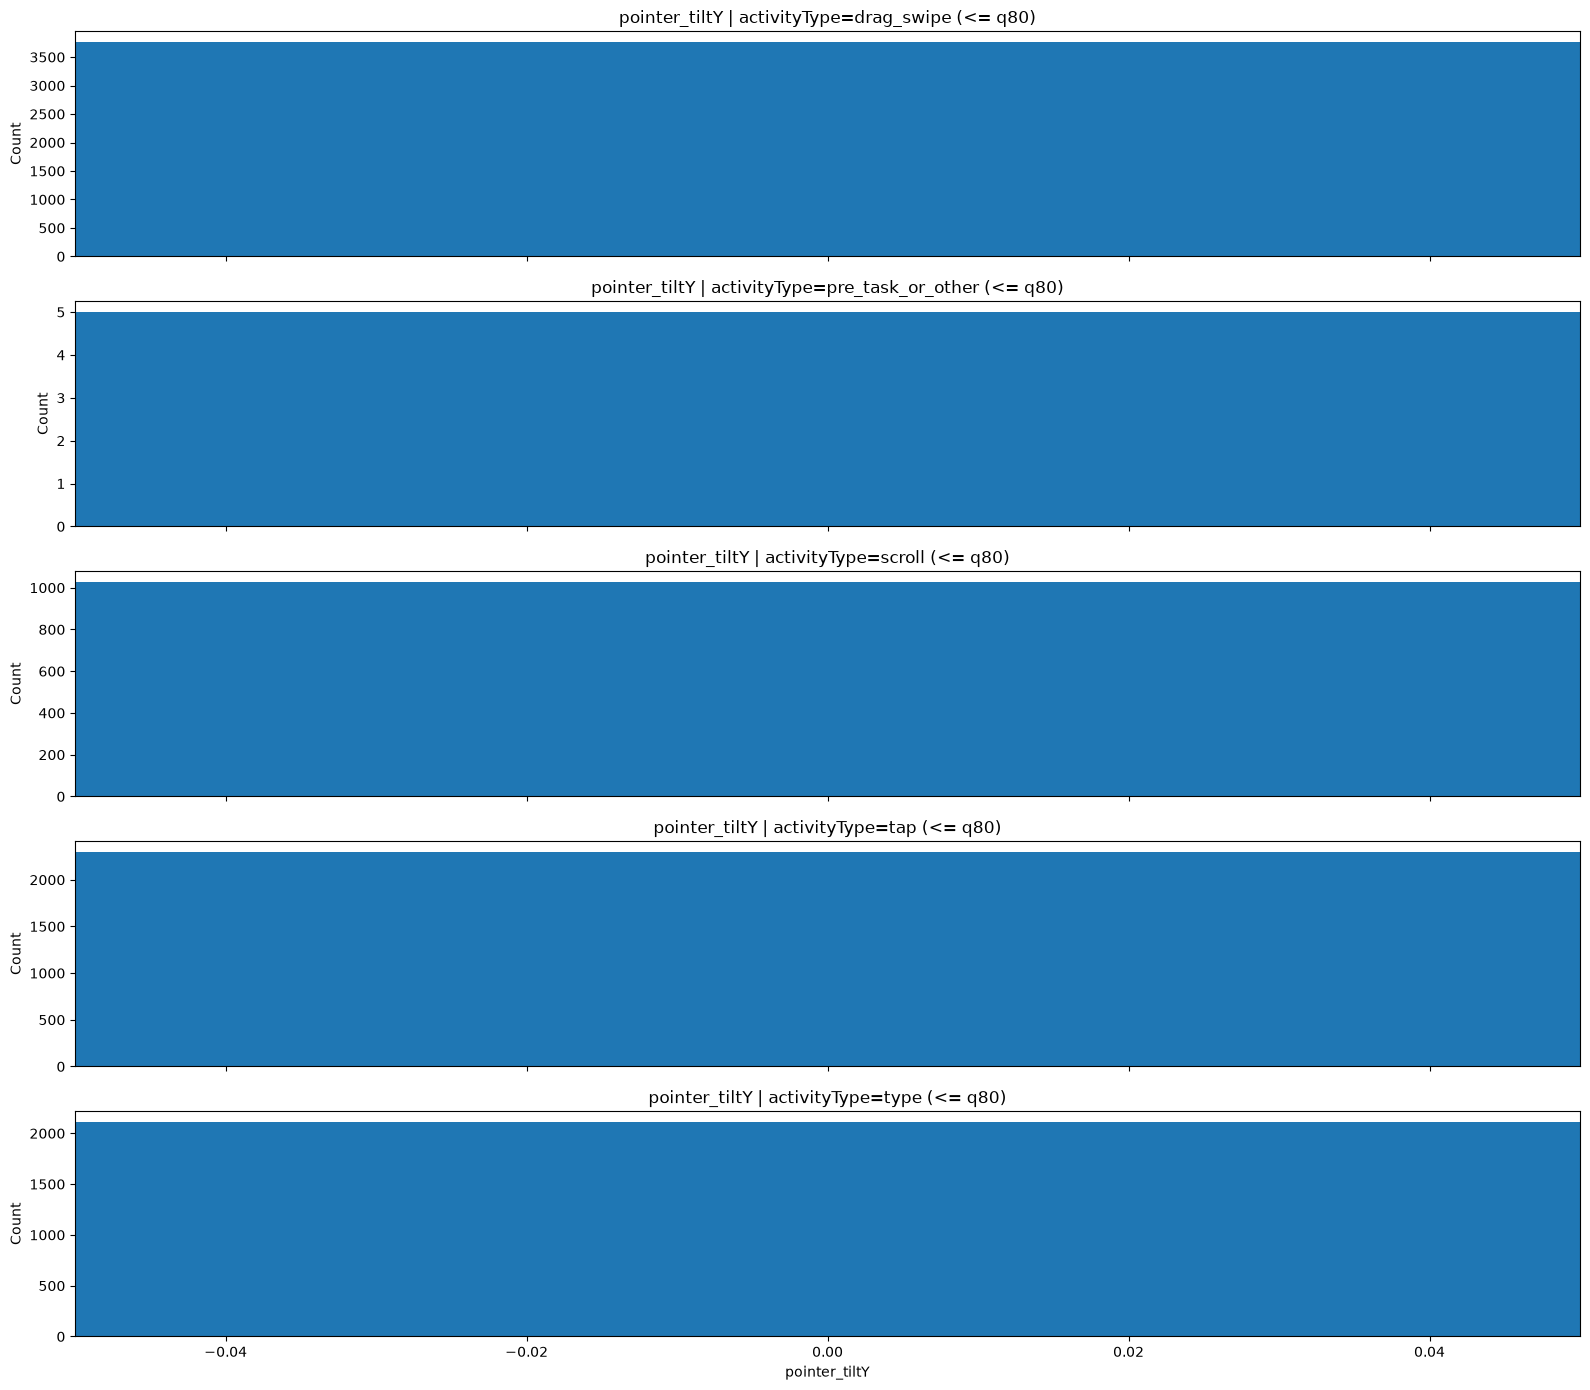

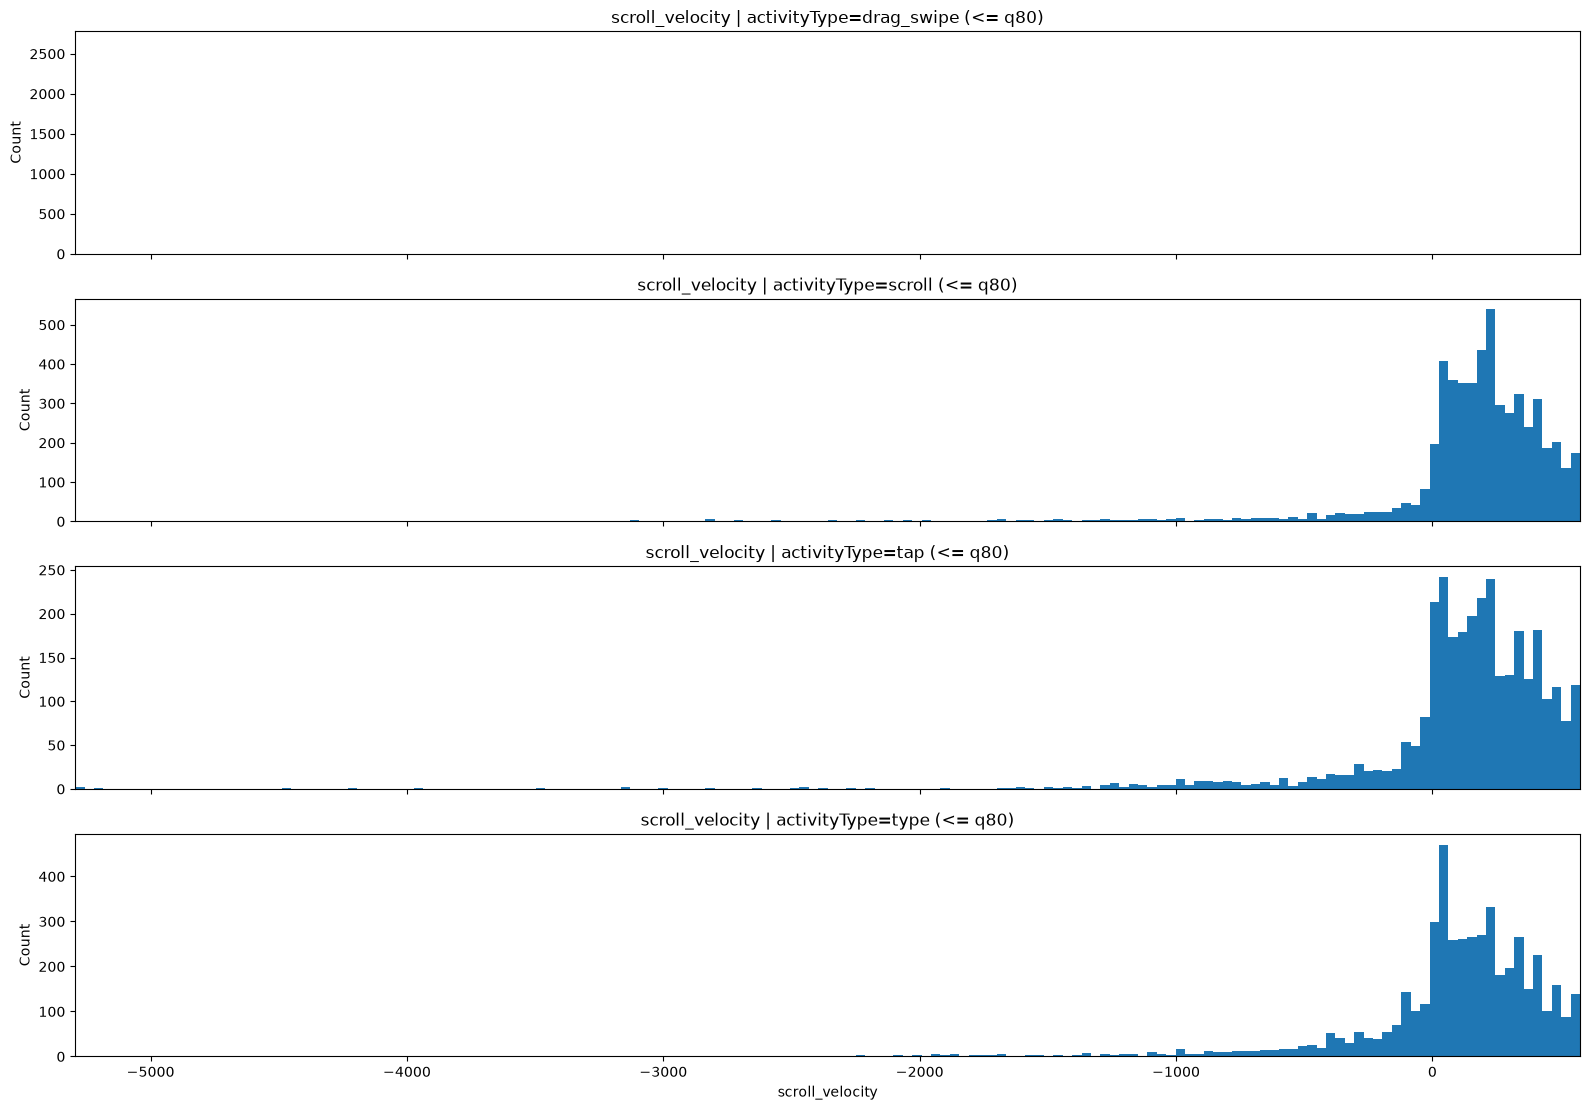

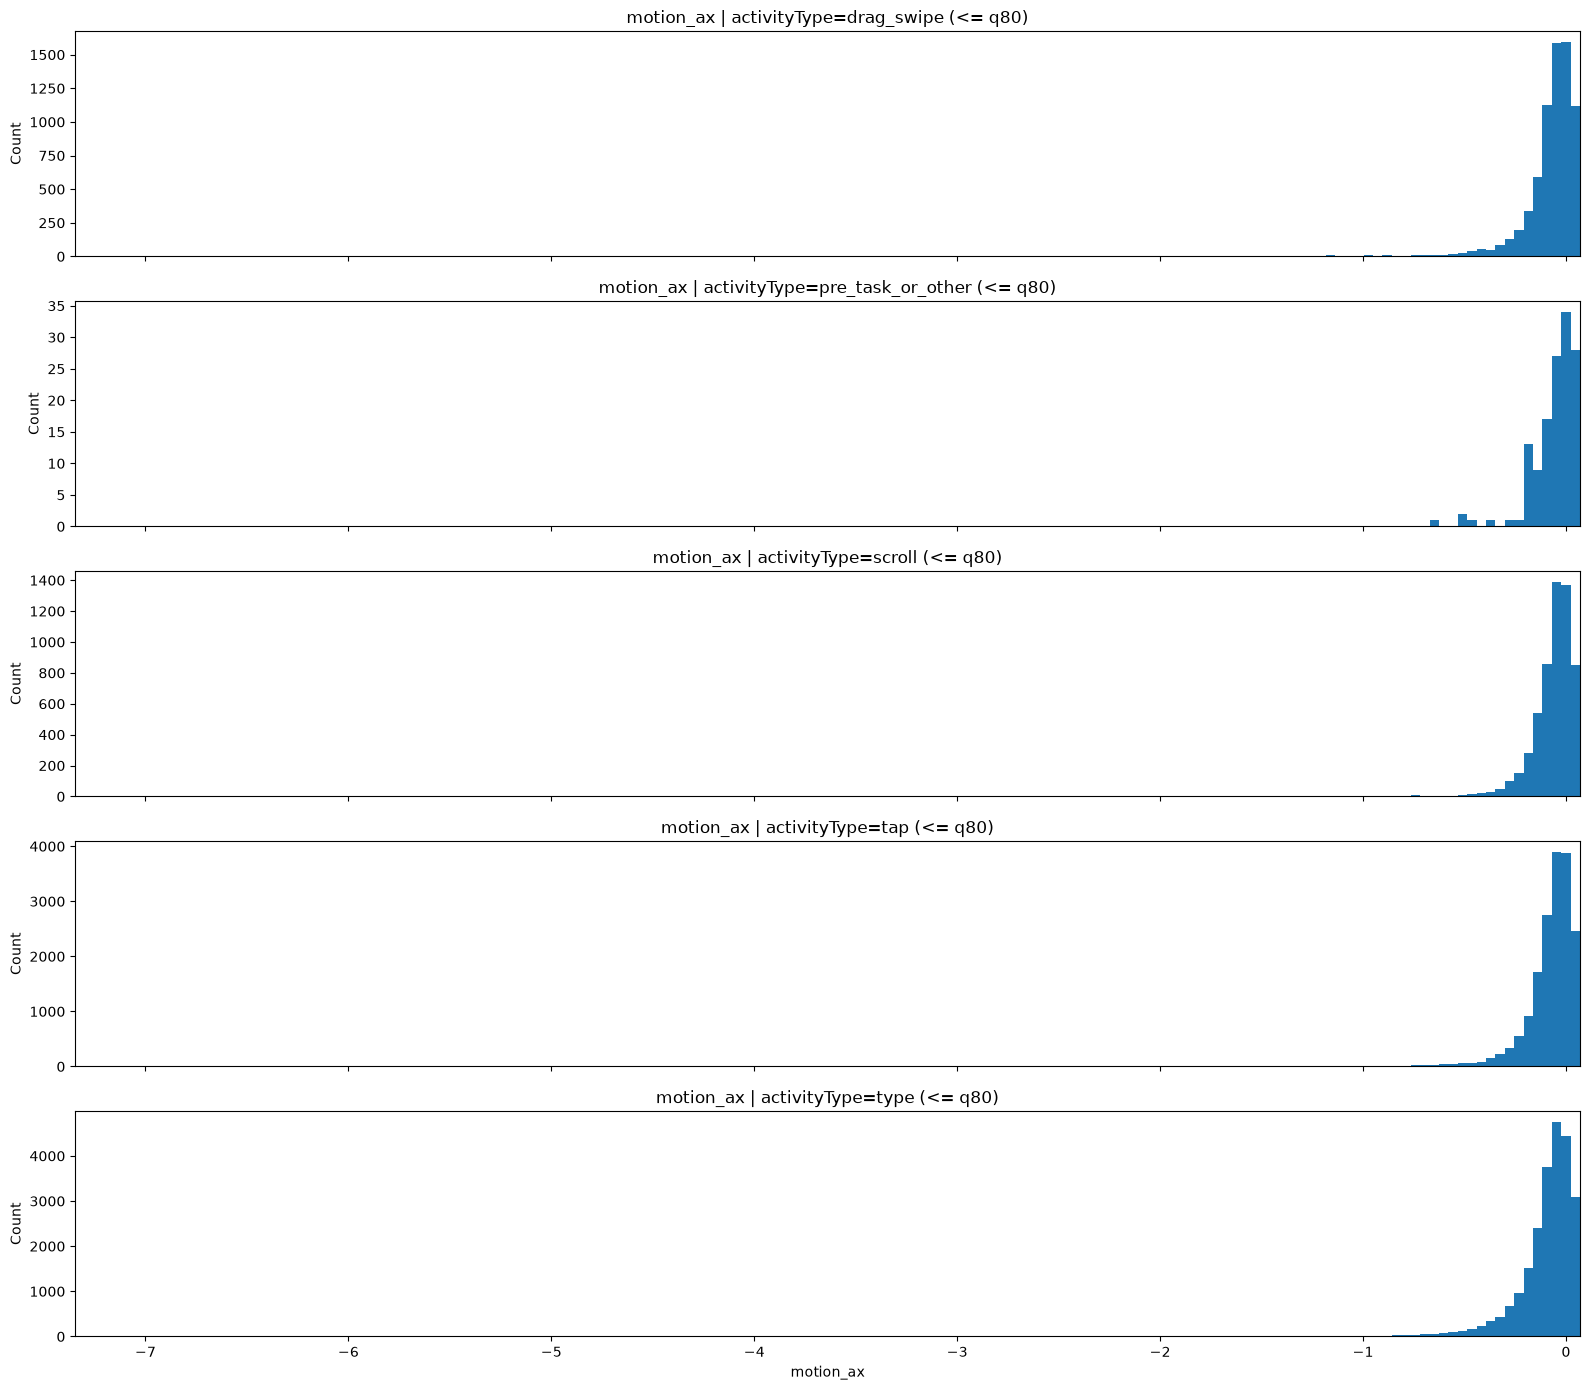

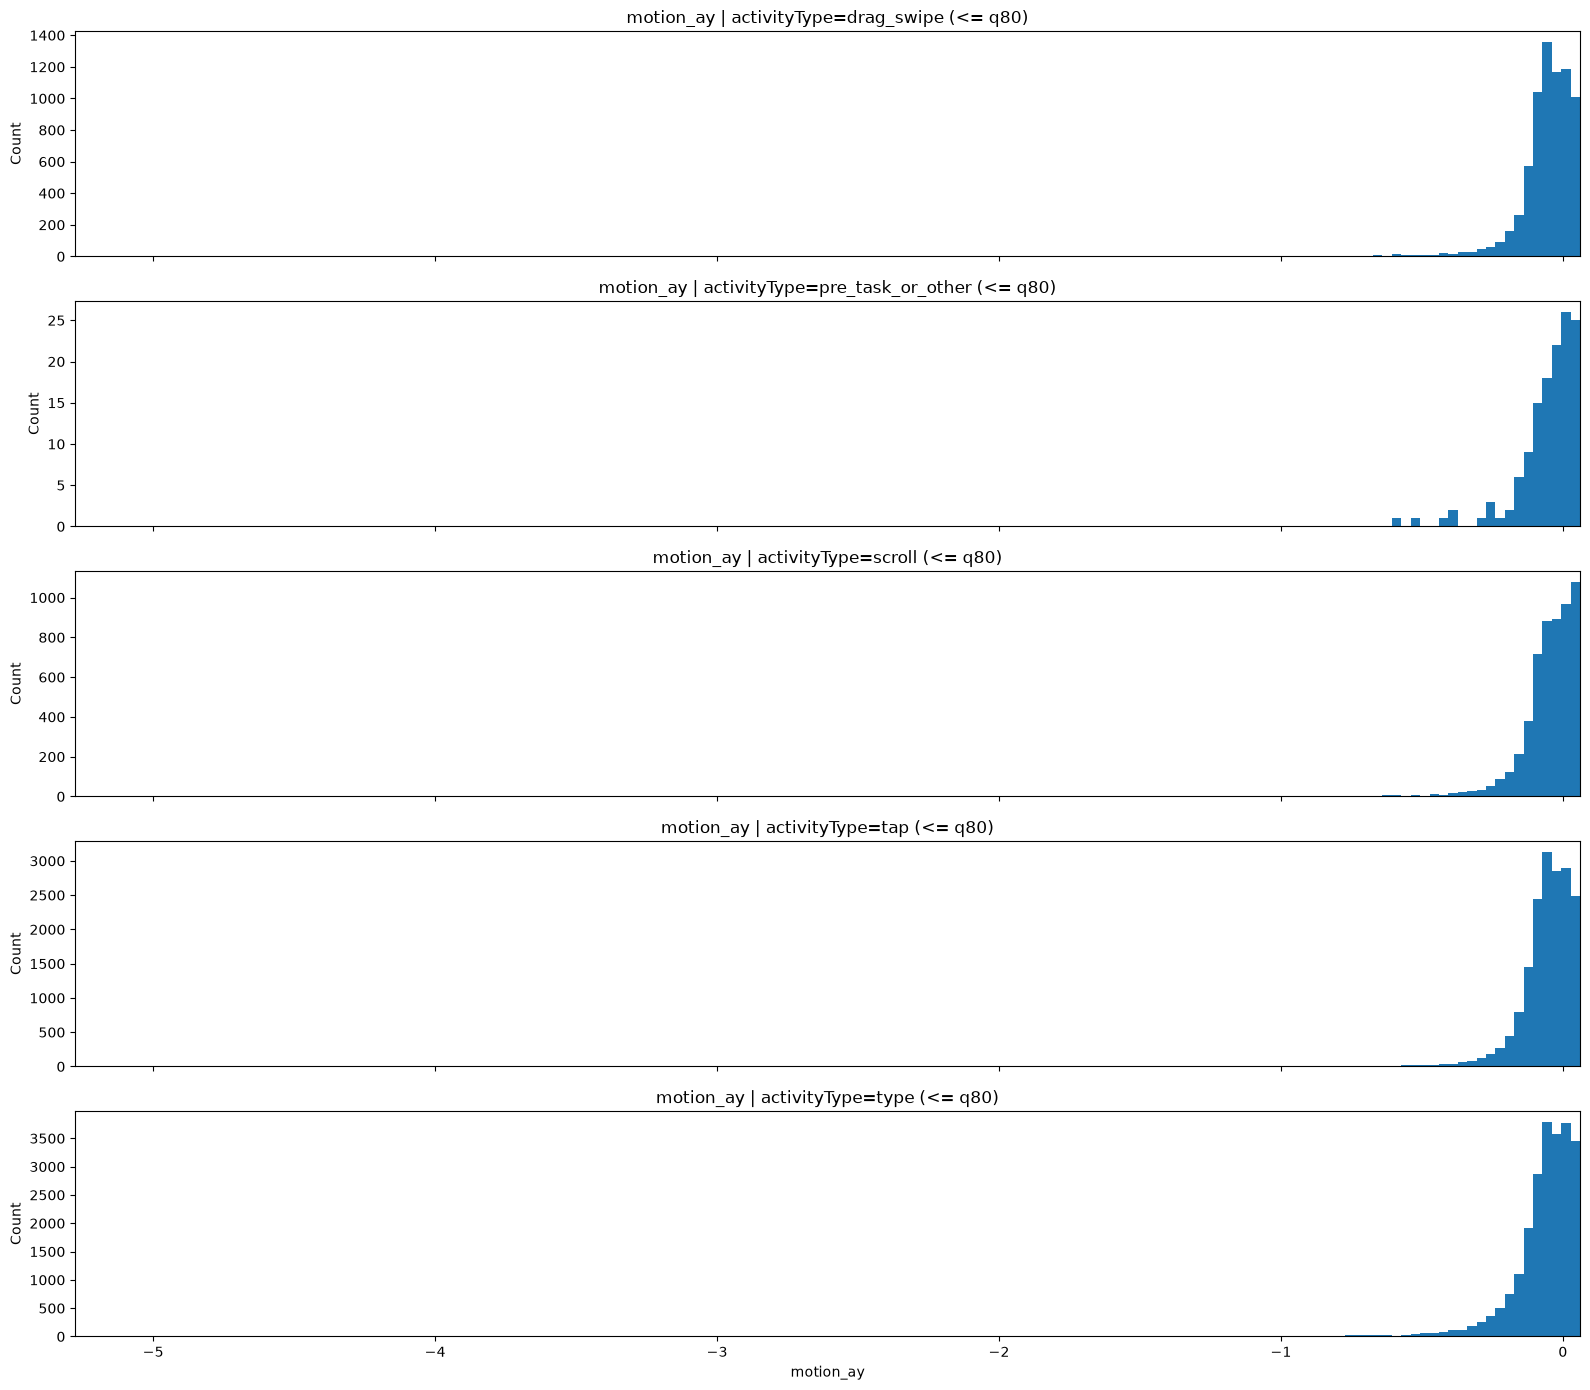

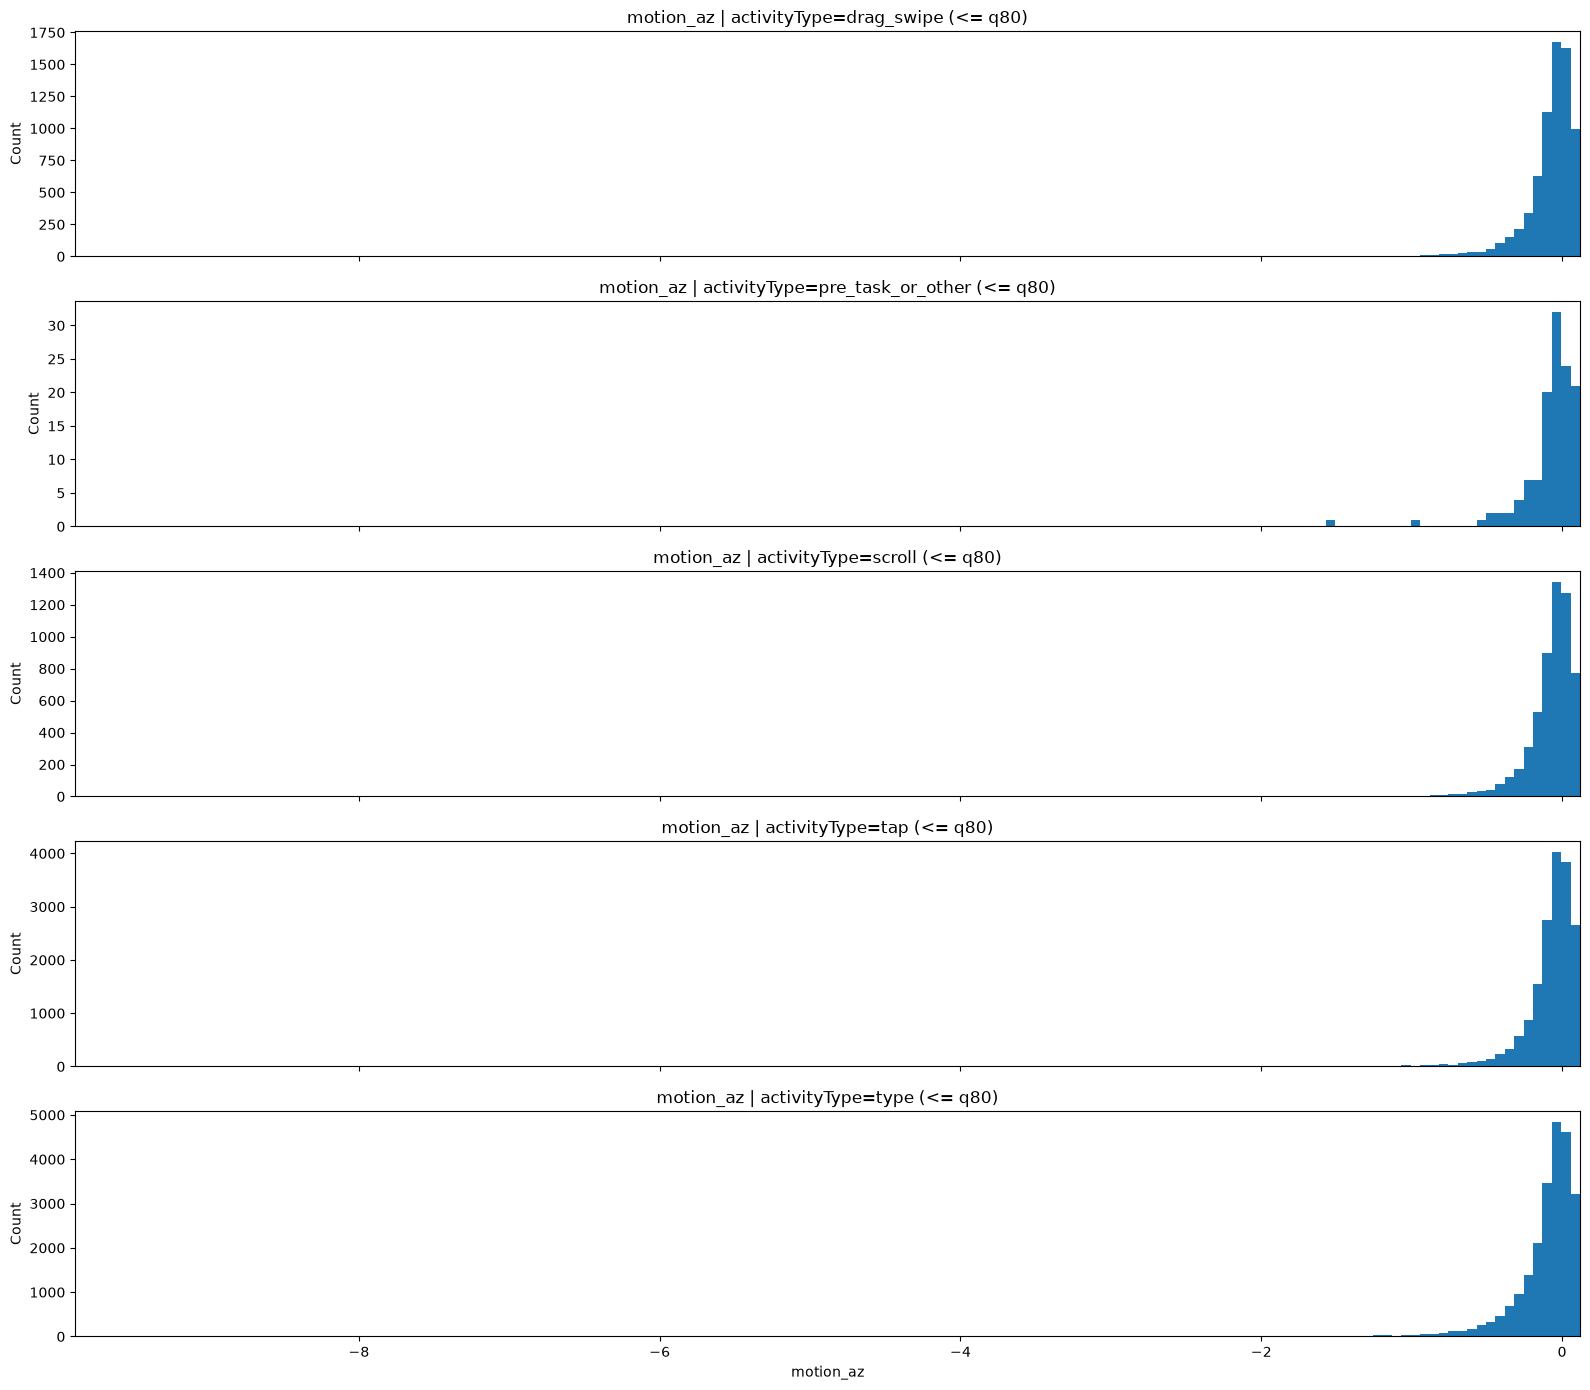

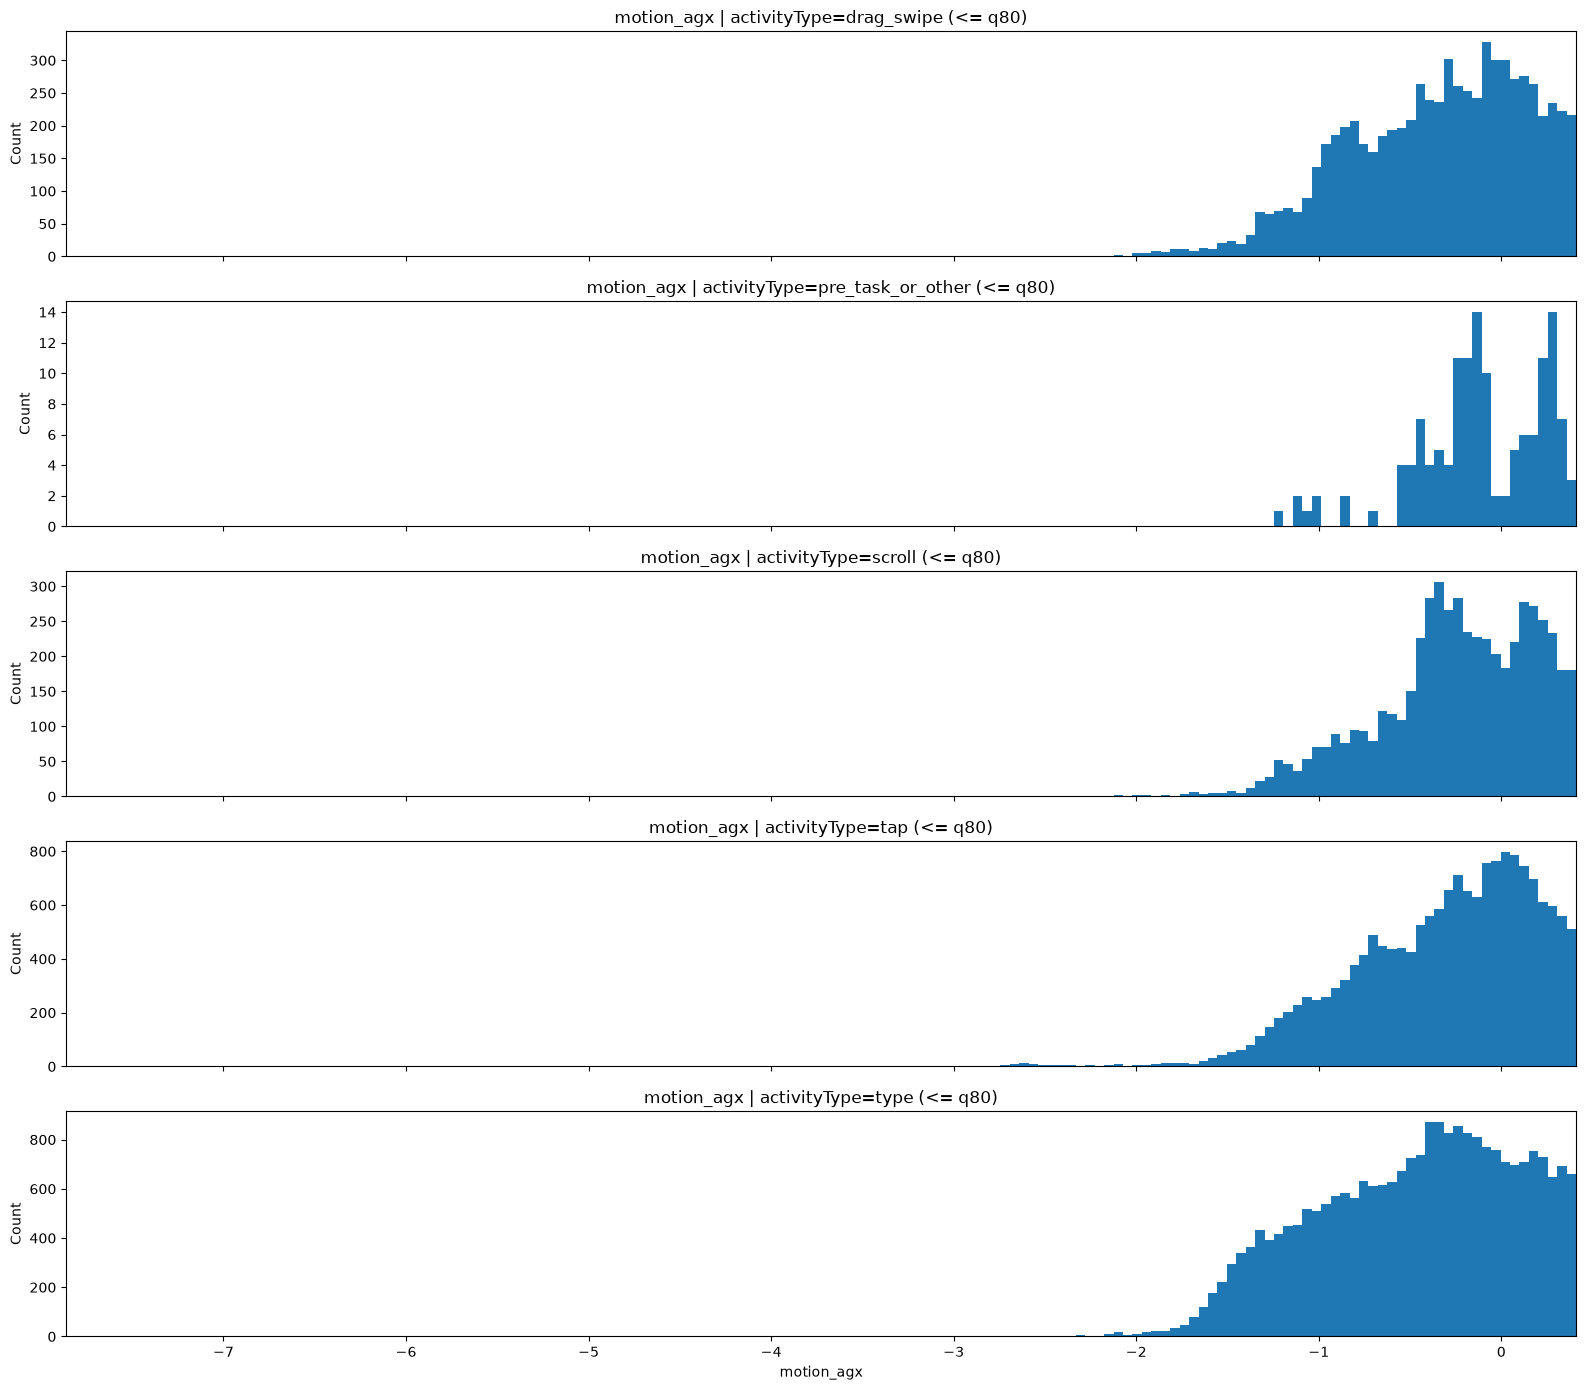

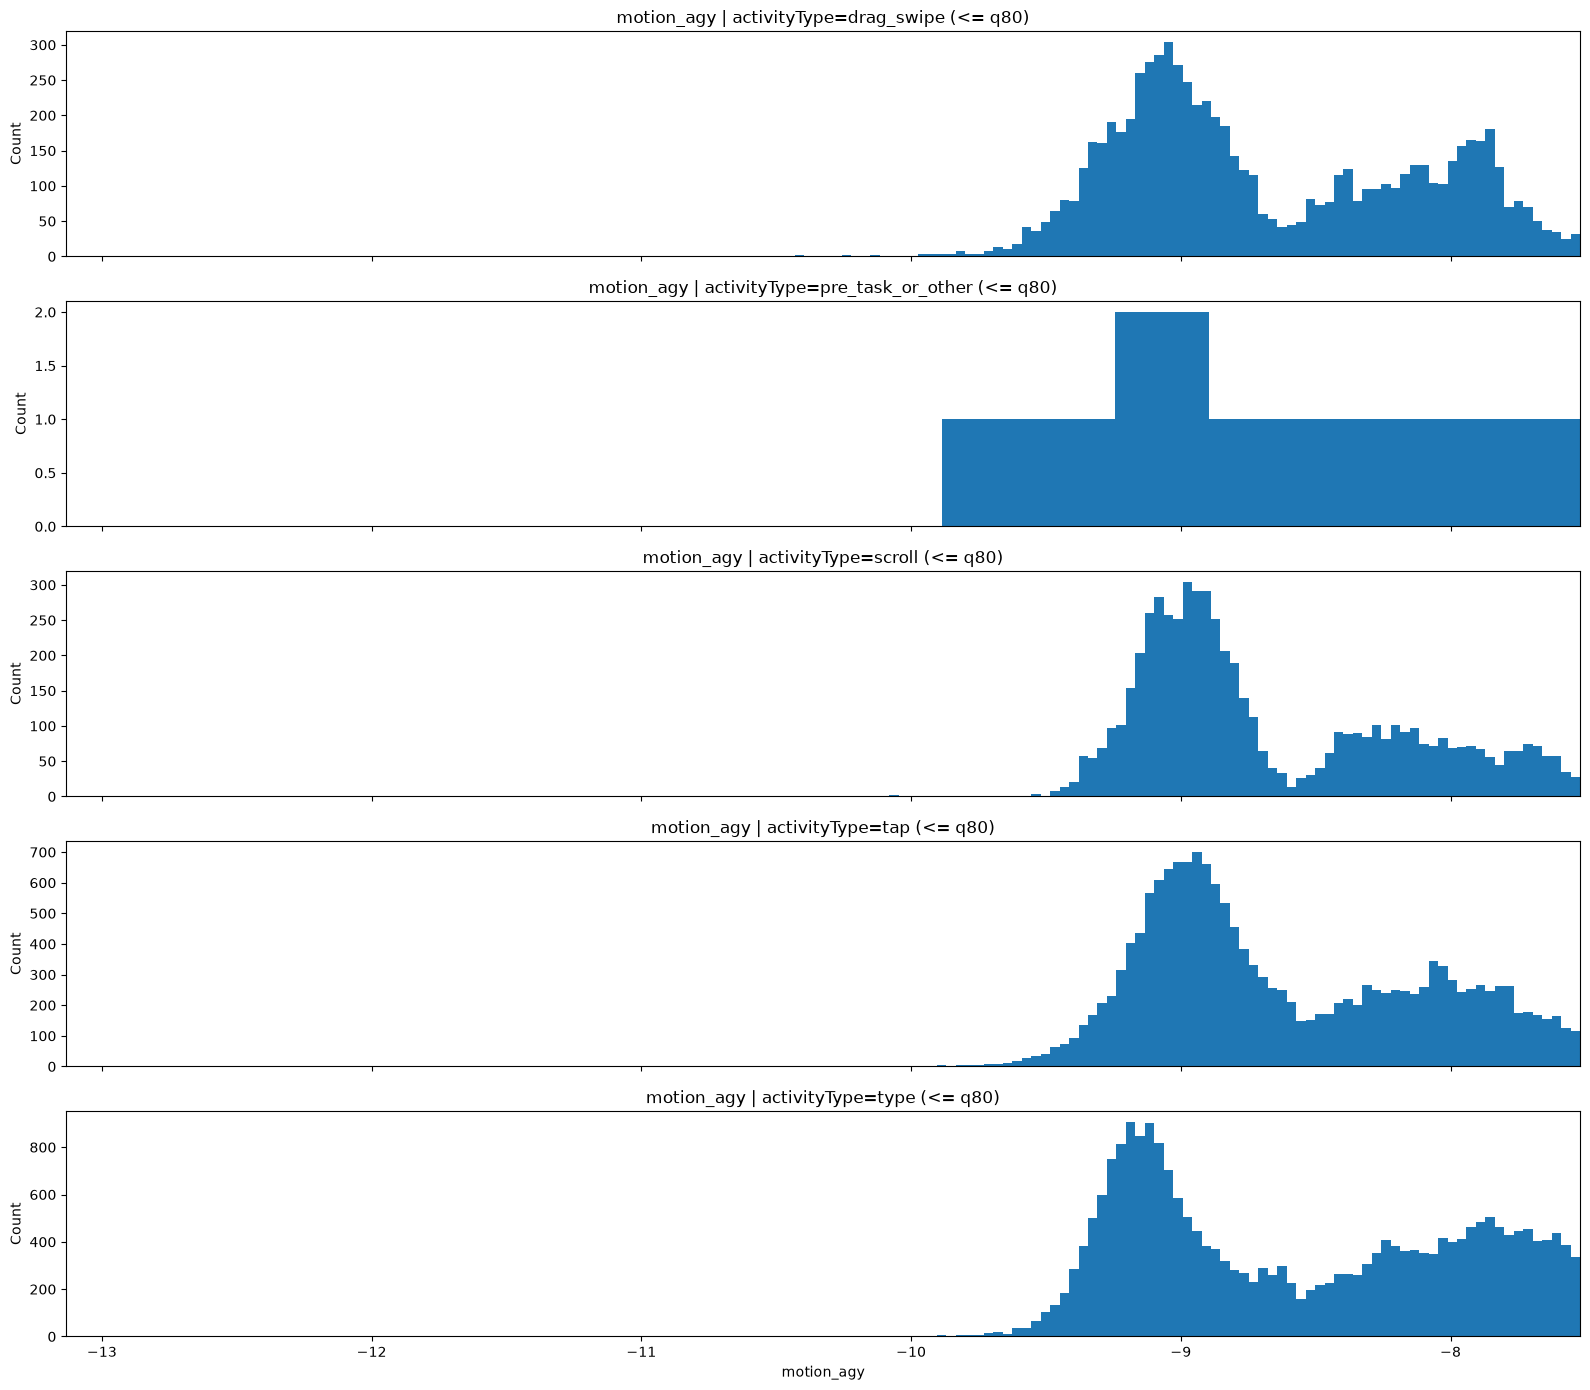

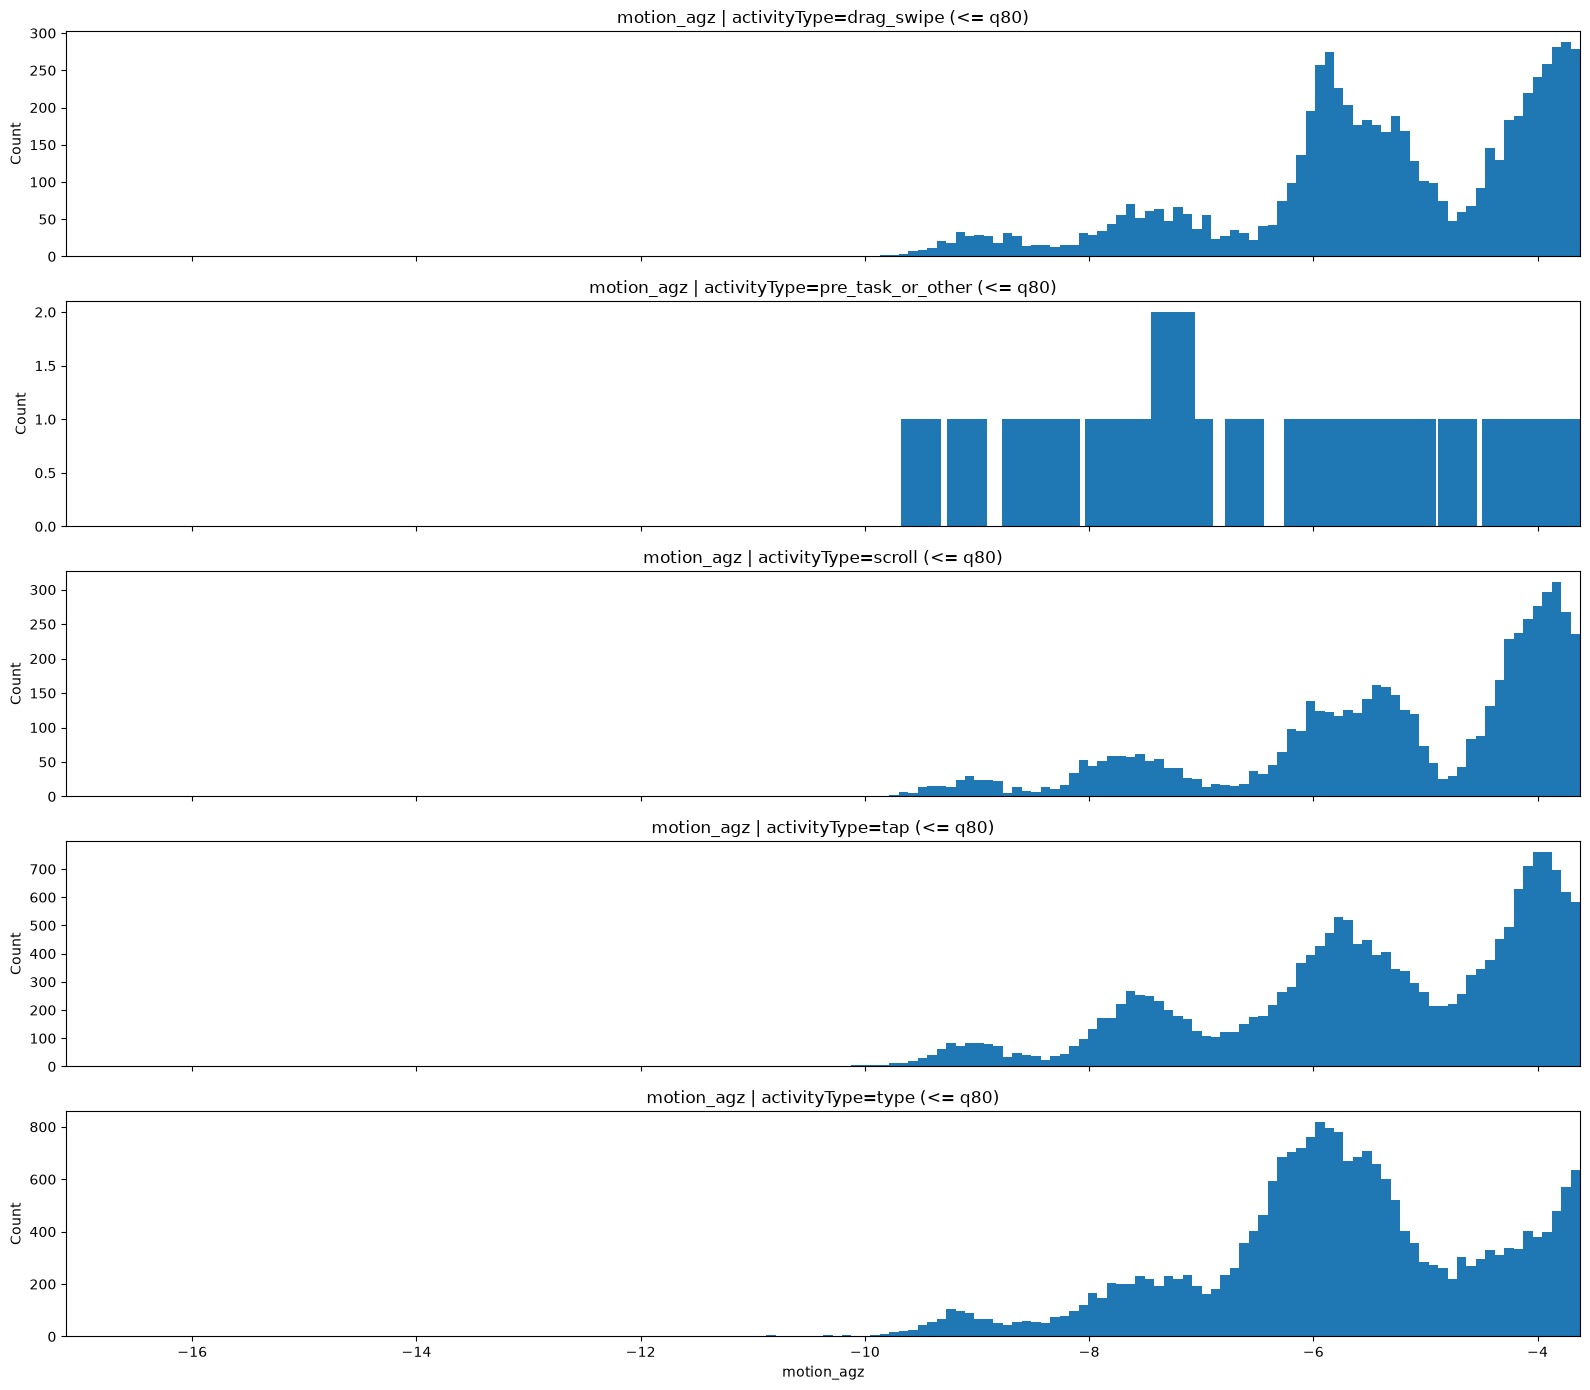

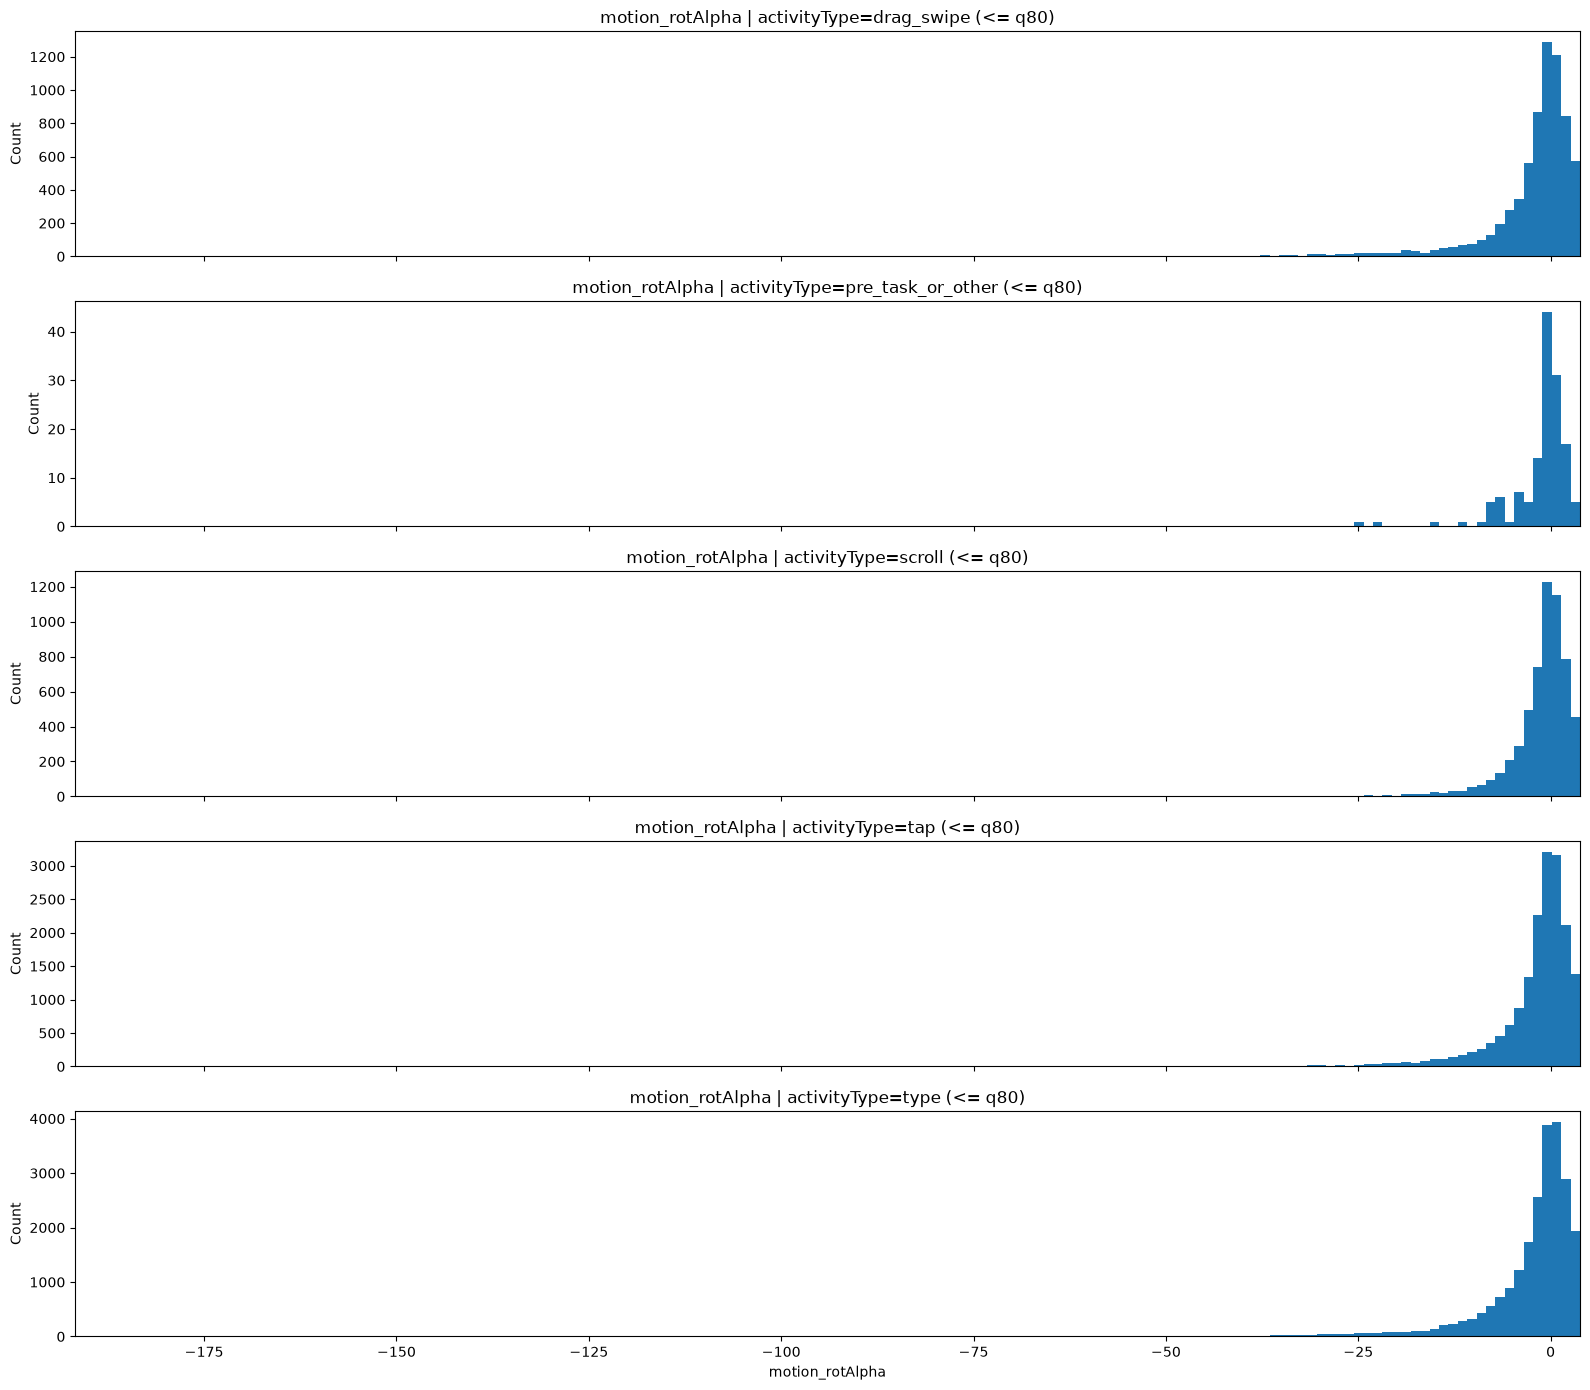

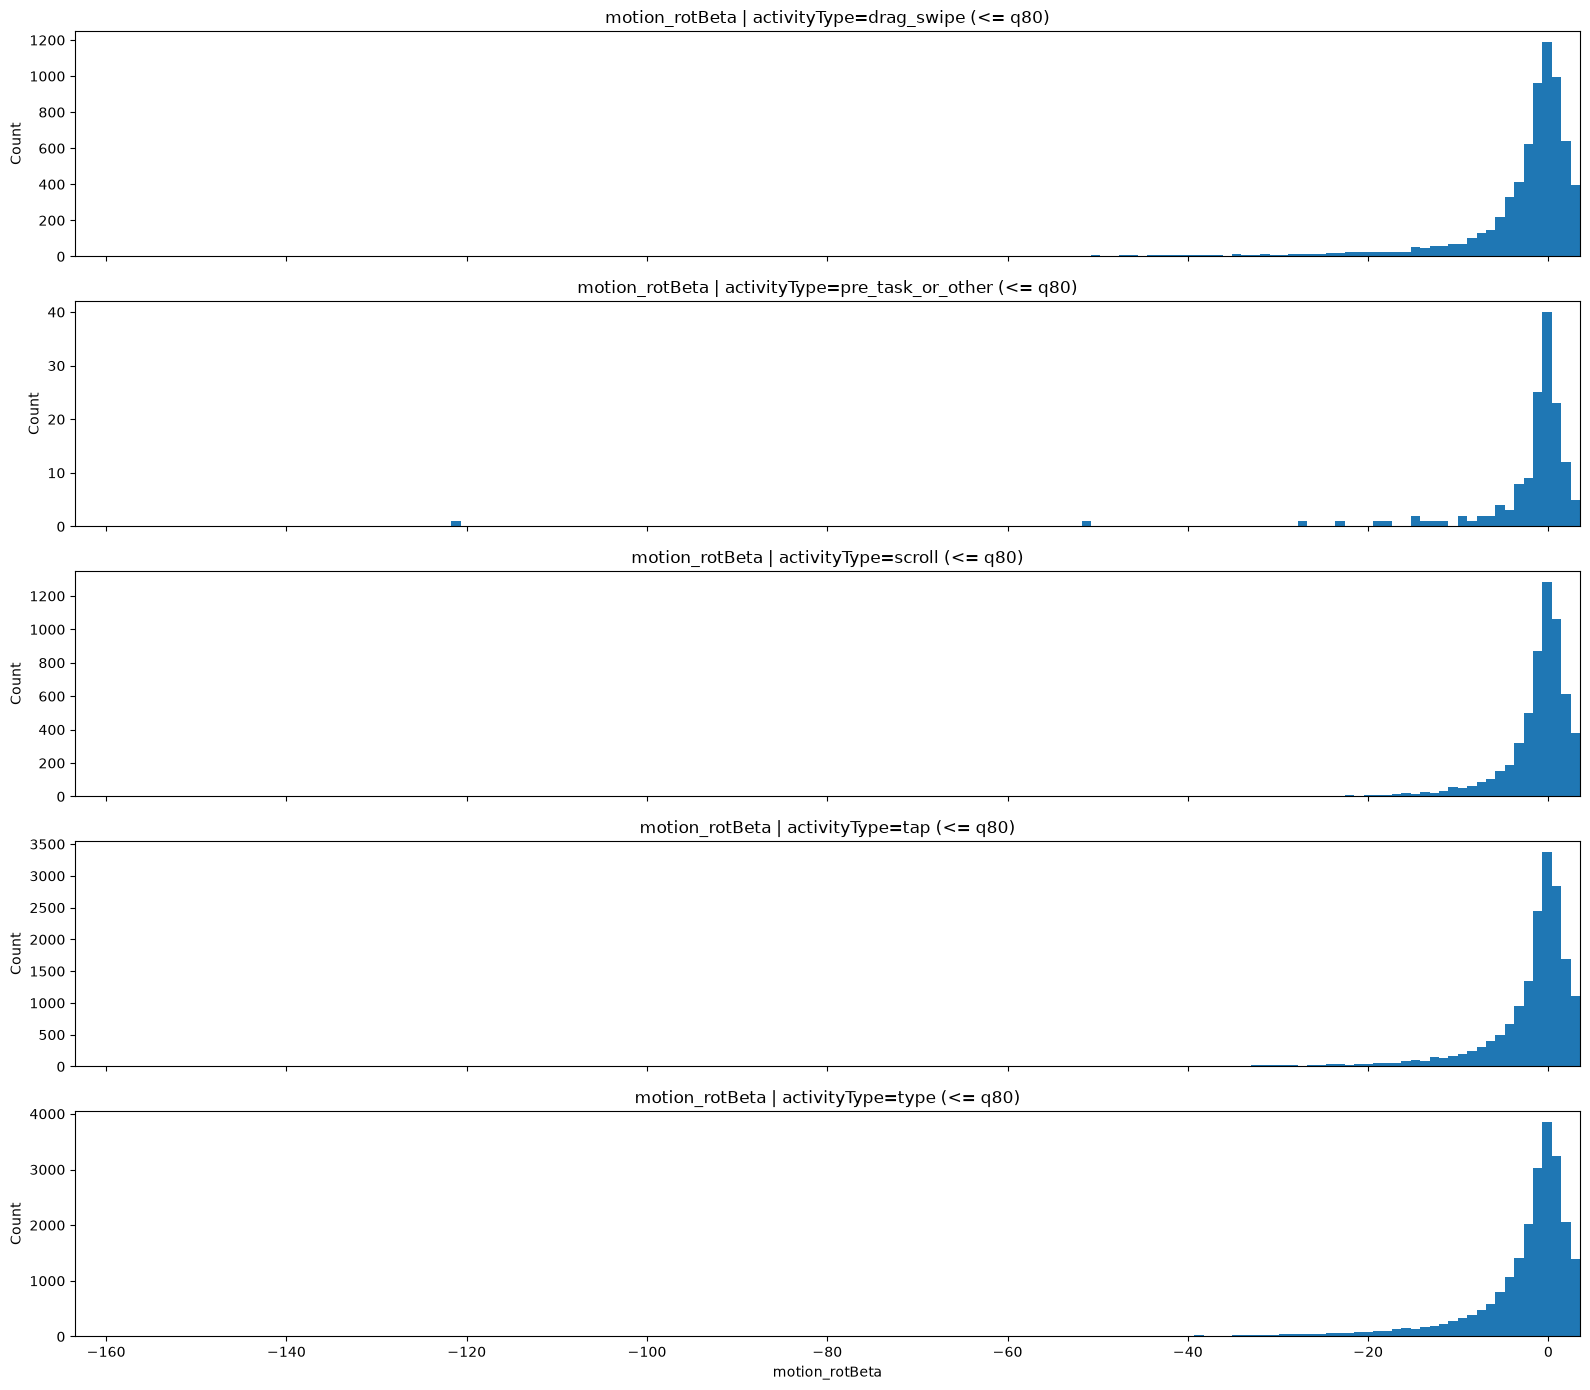

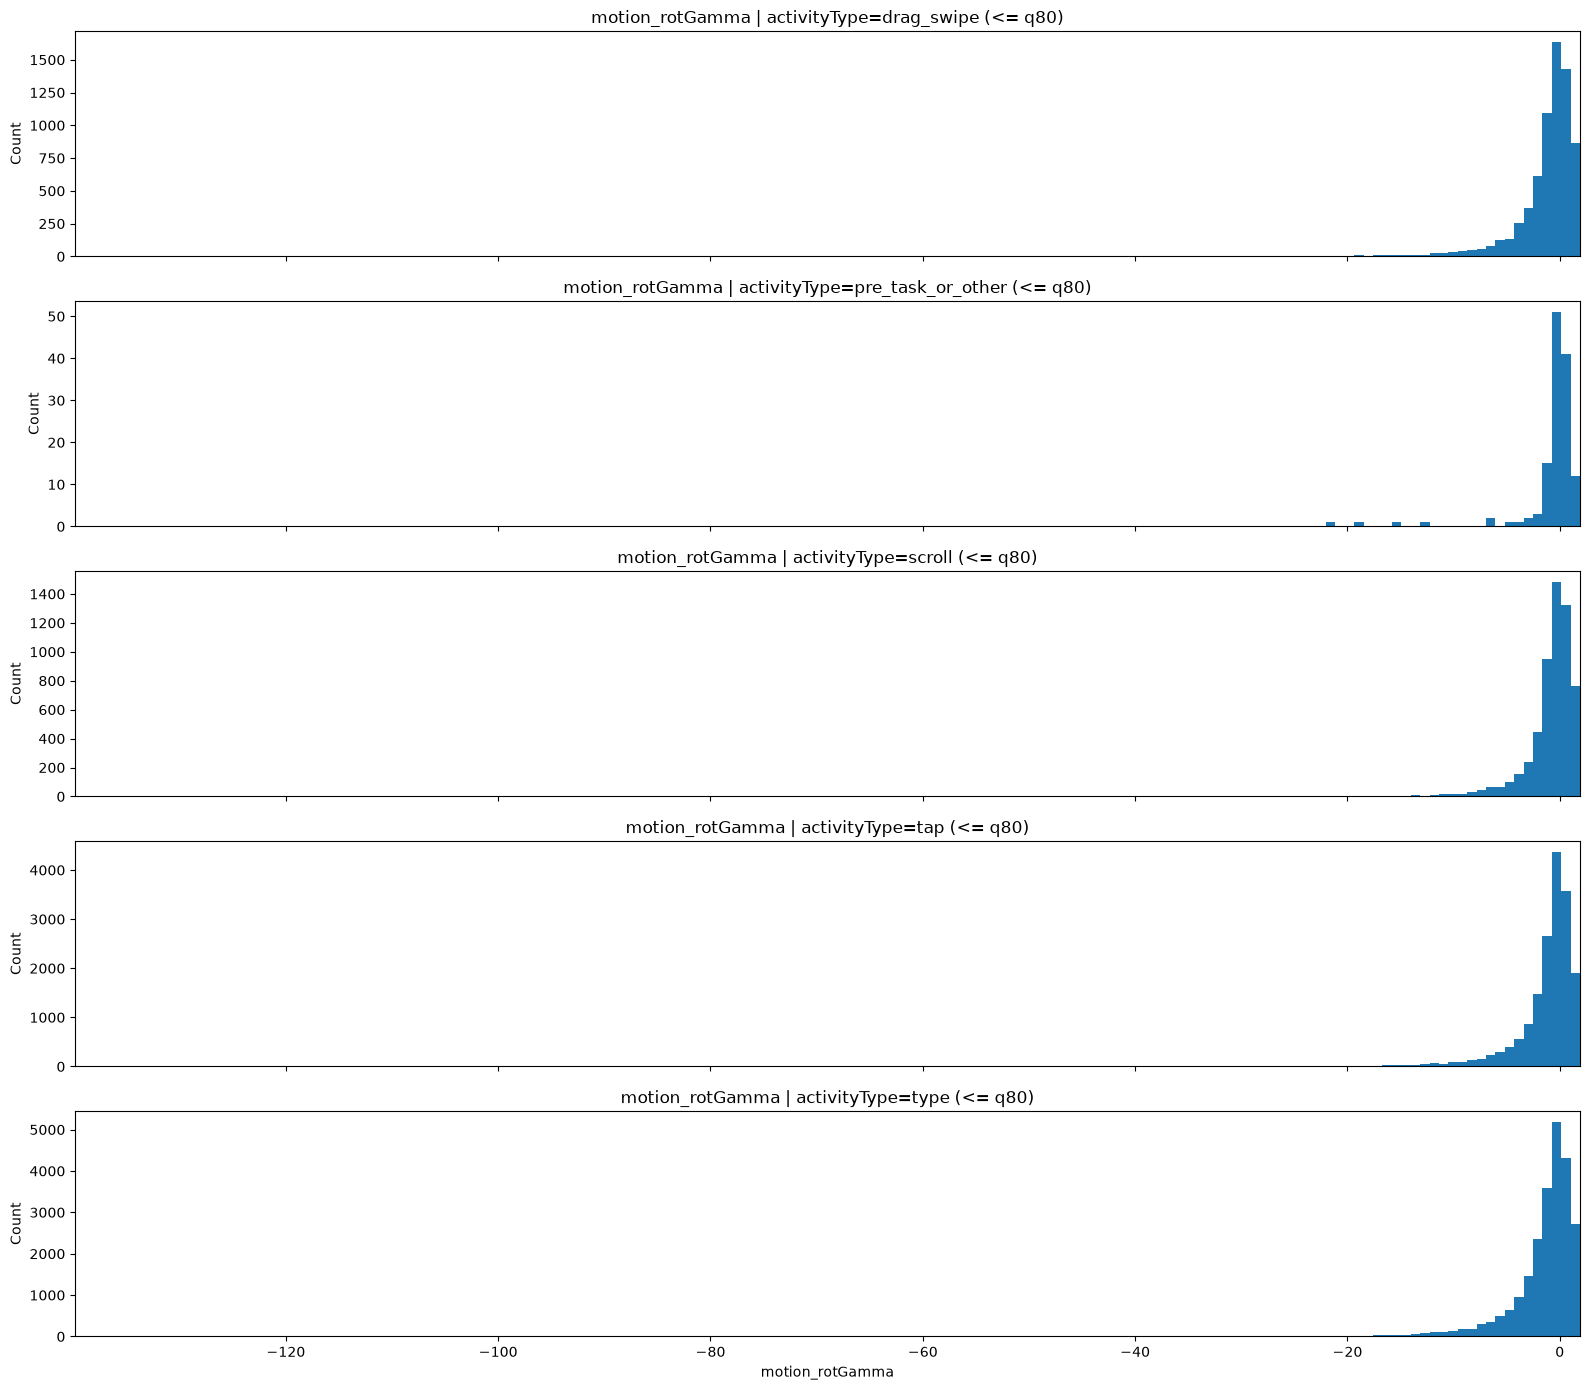

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_32799/3374763667.py:48: UserWarni

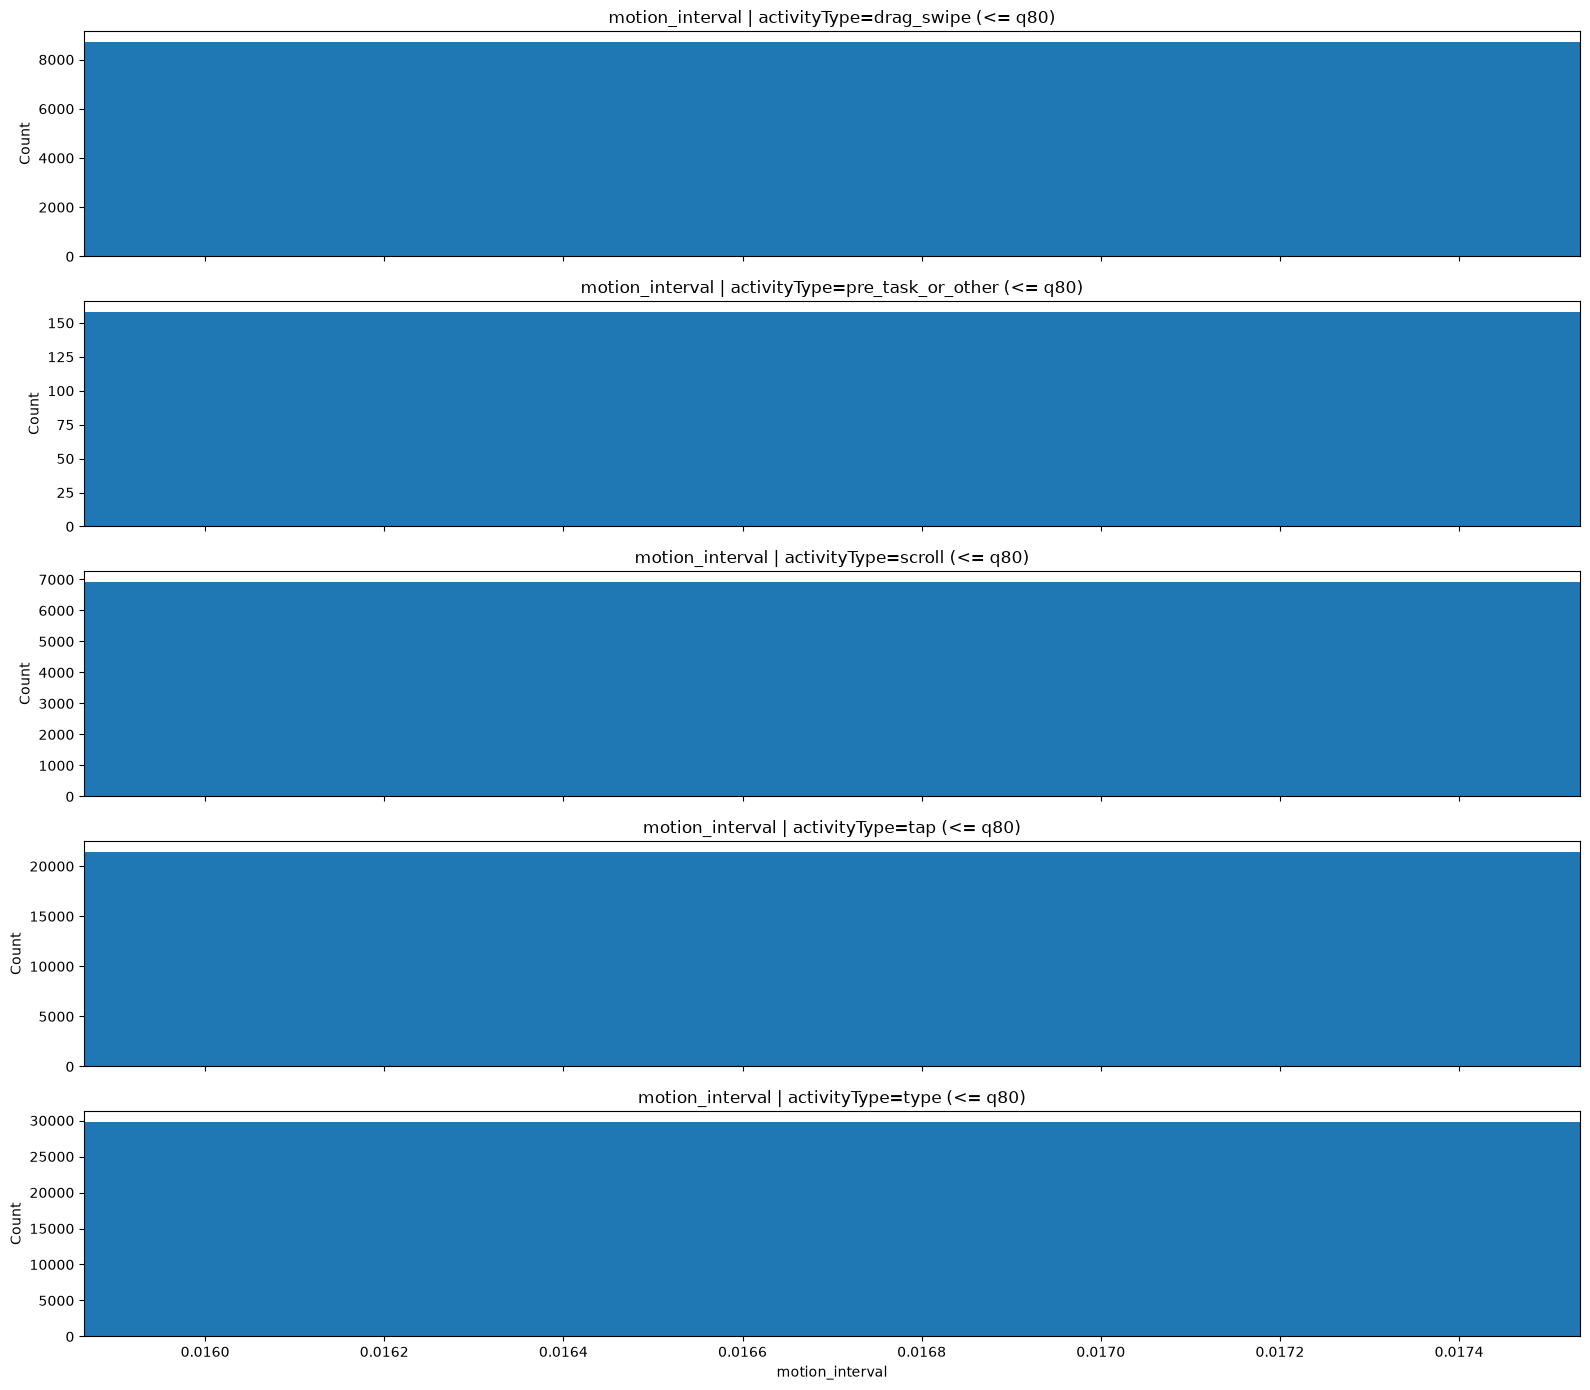

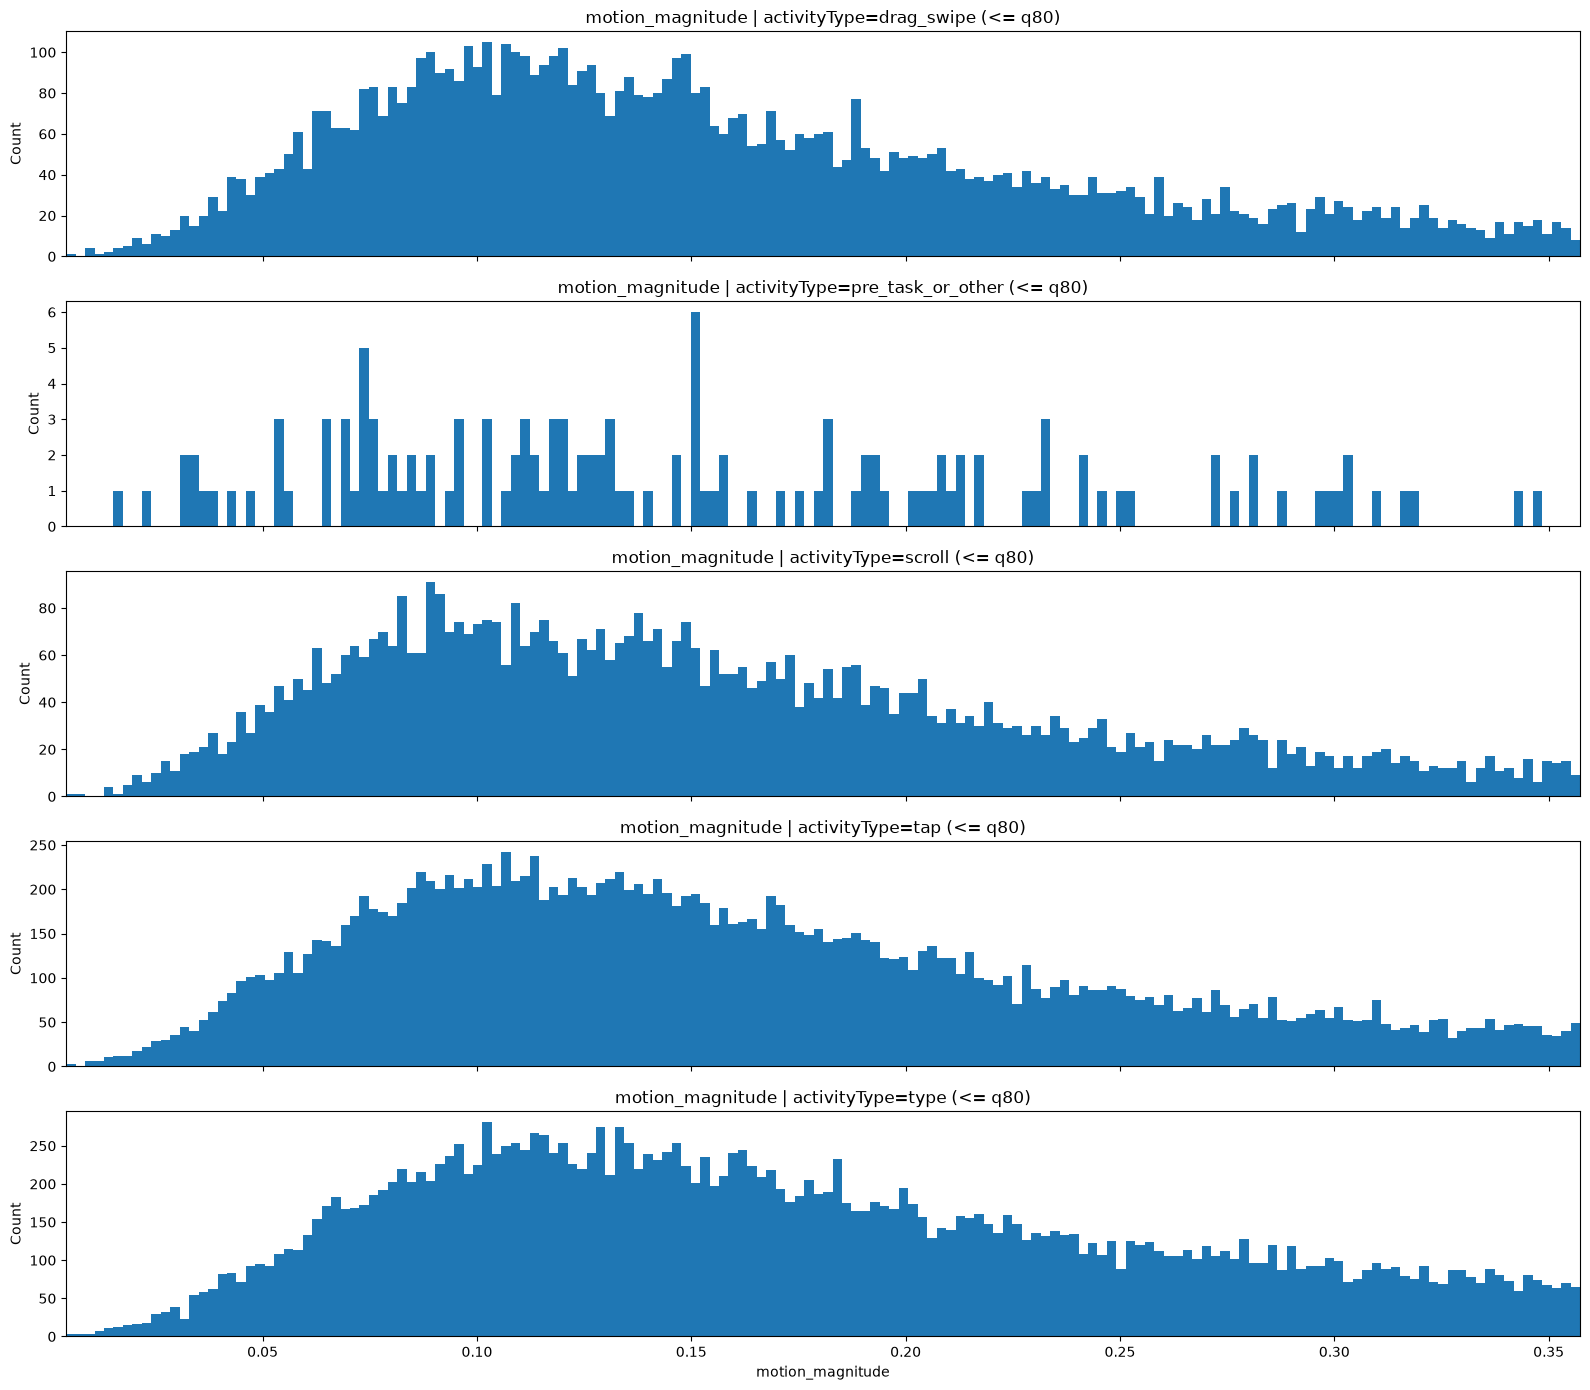

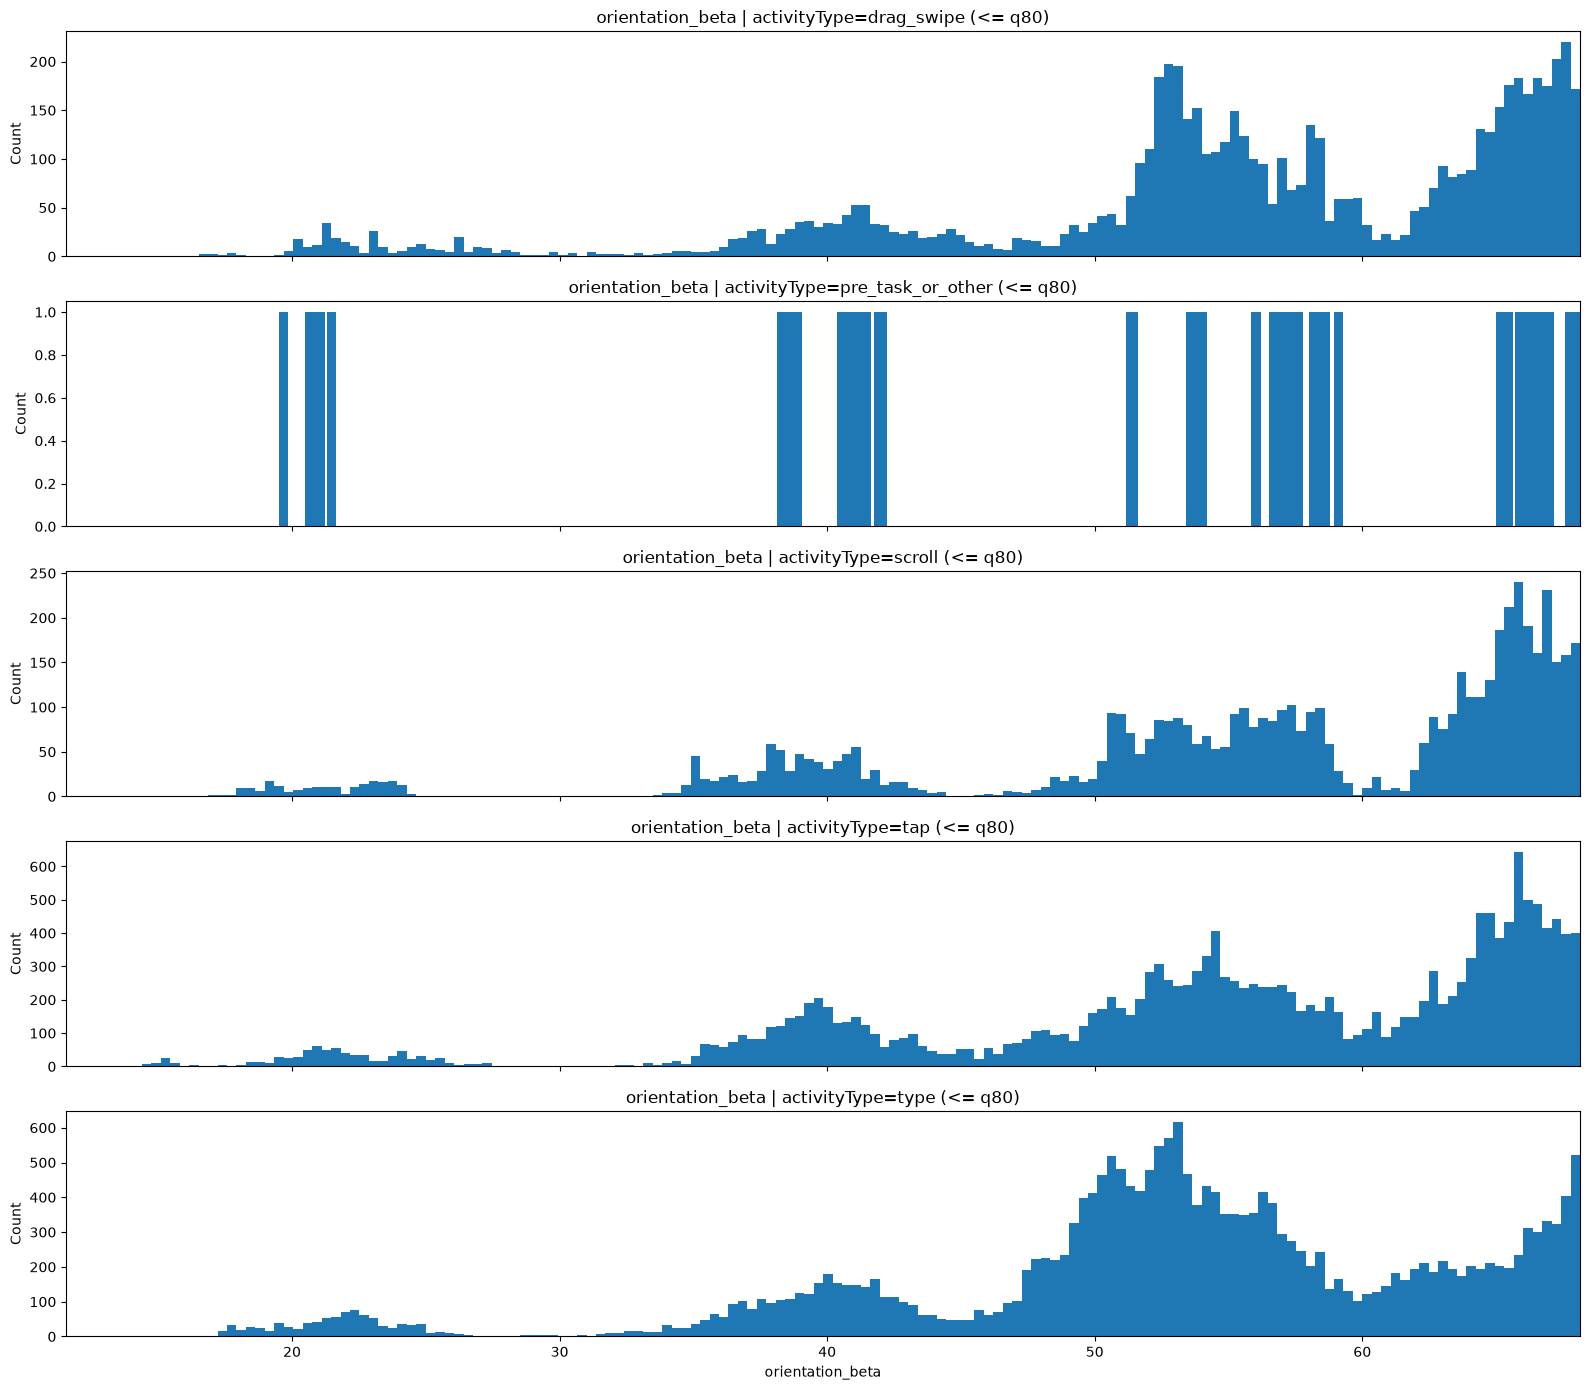

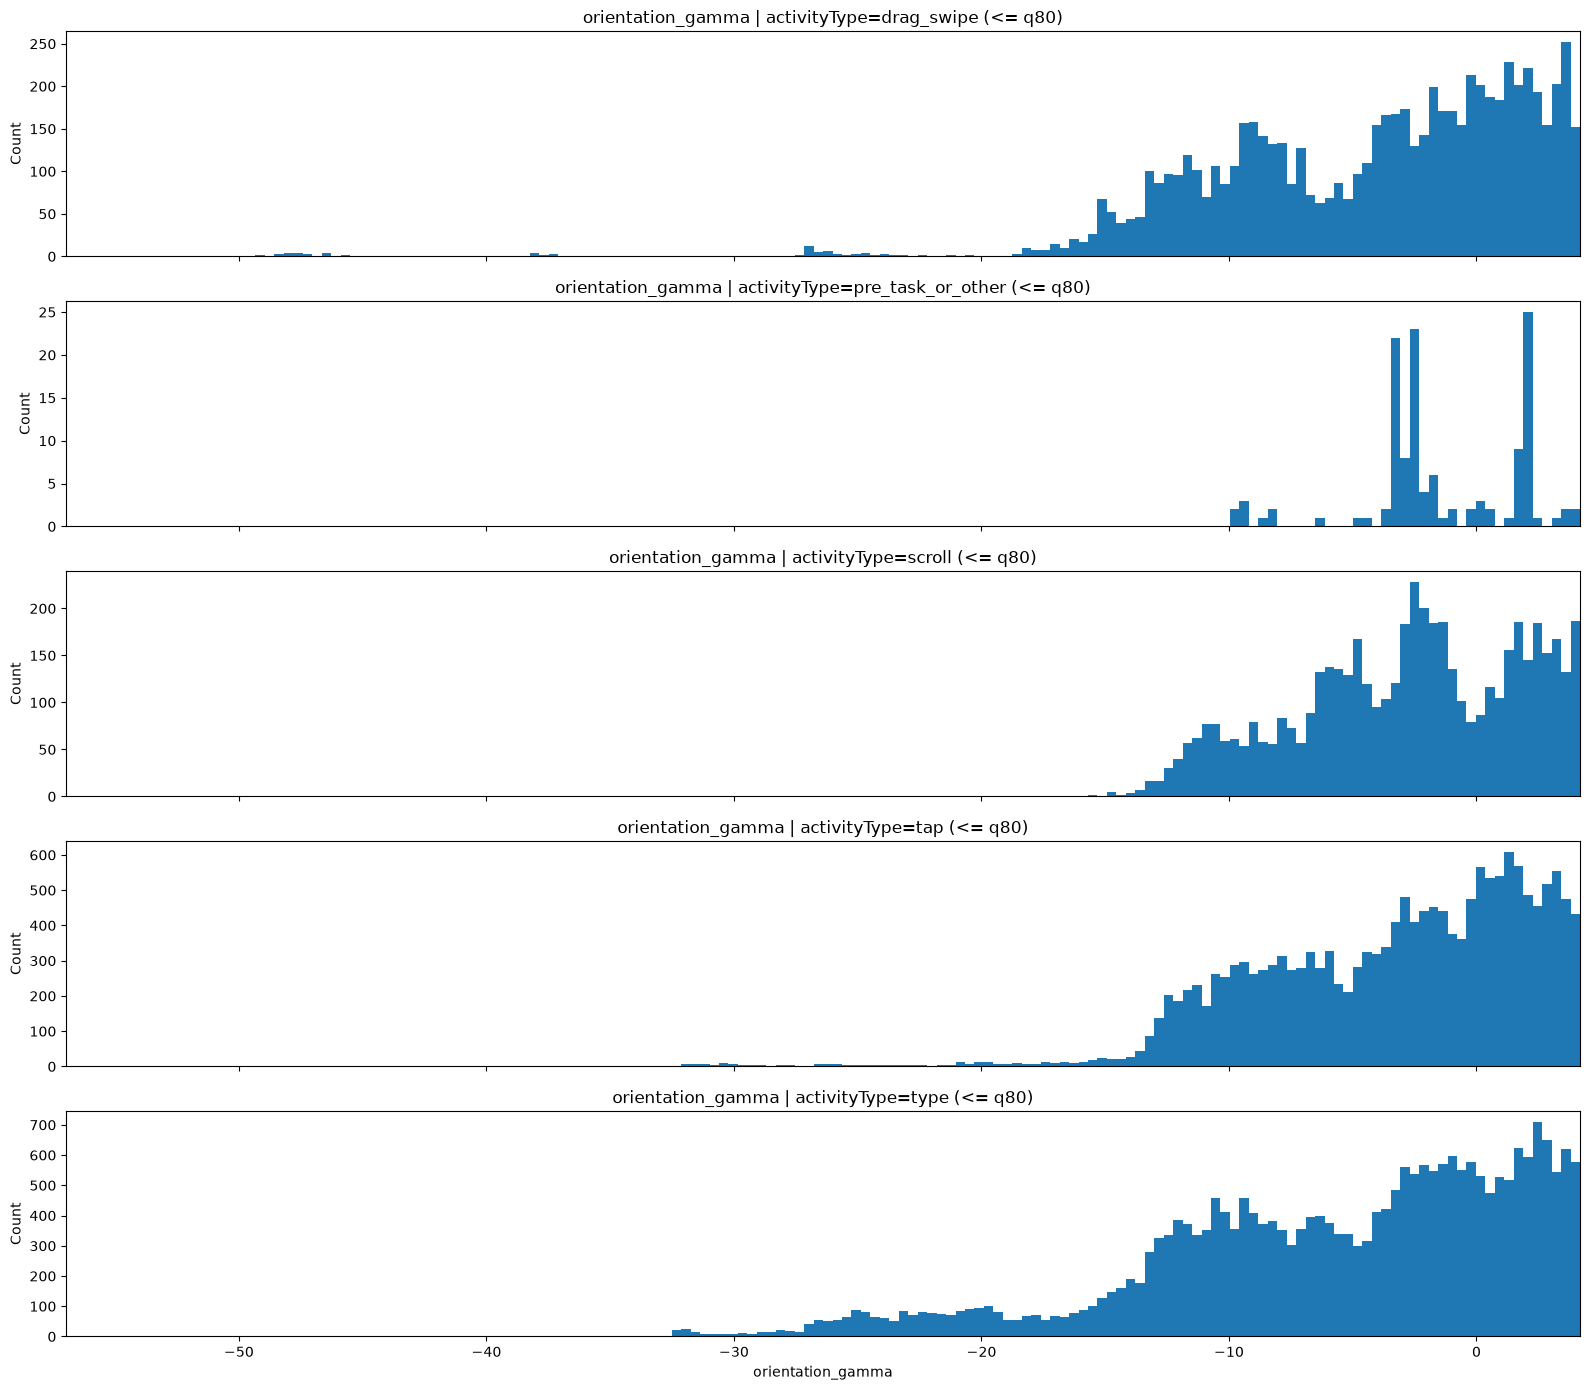

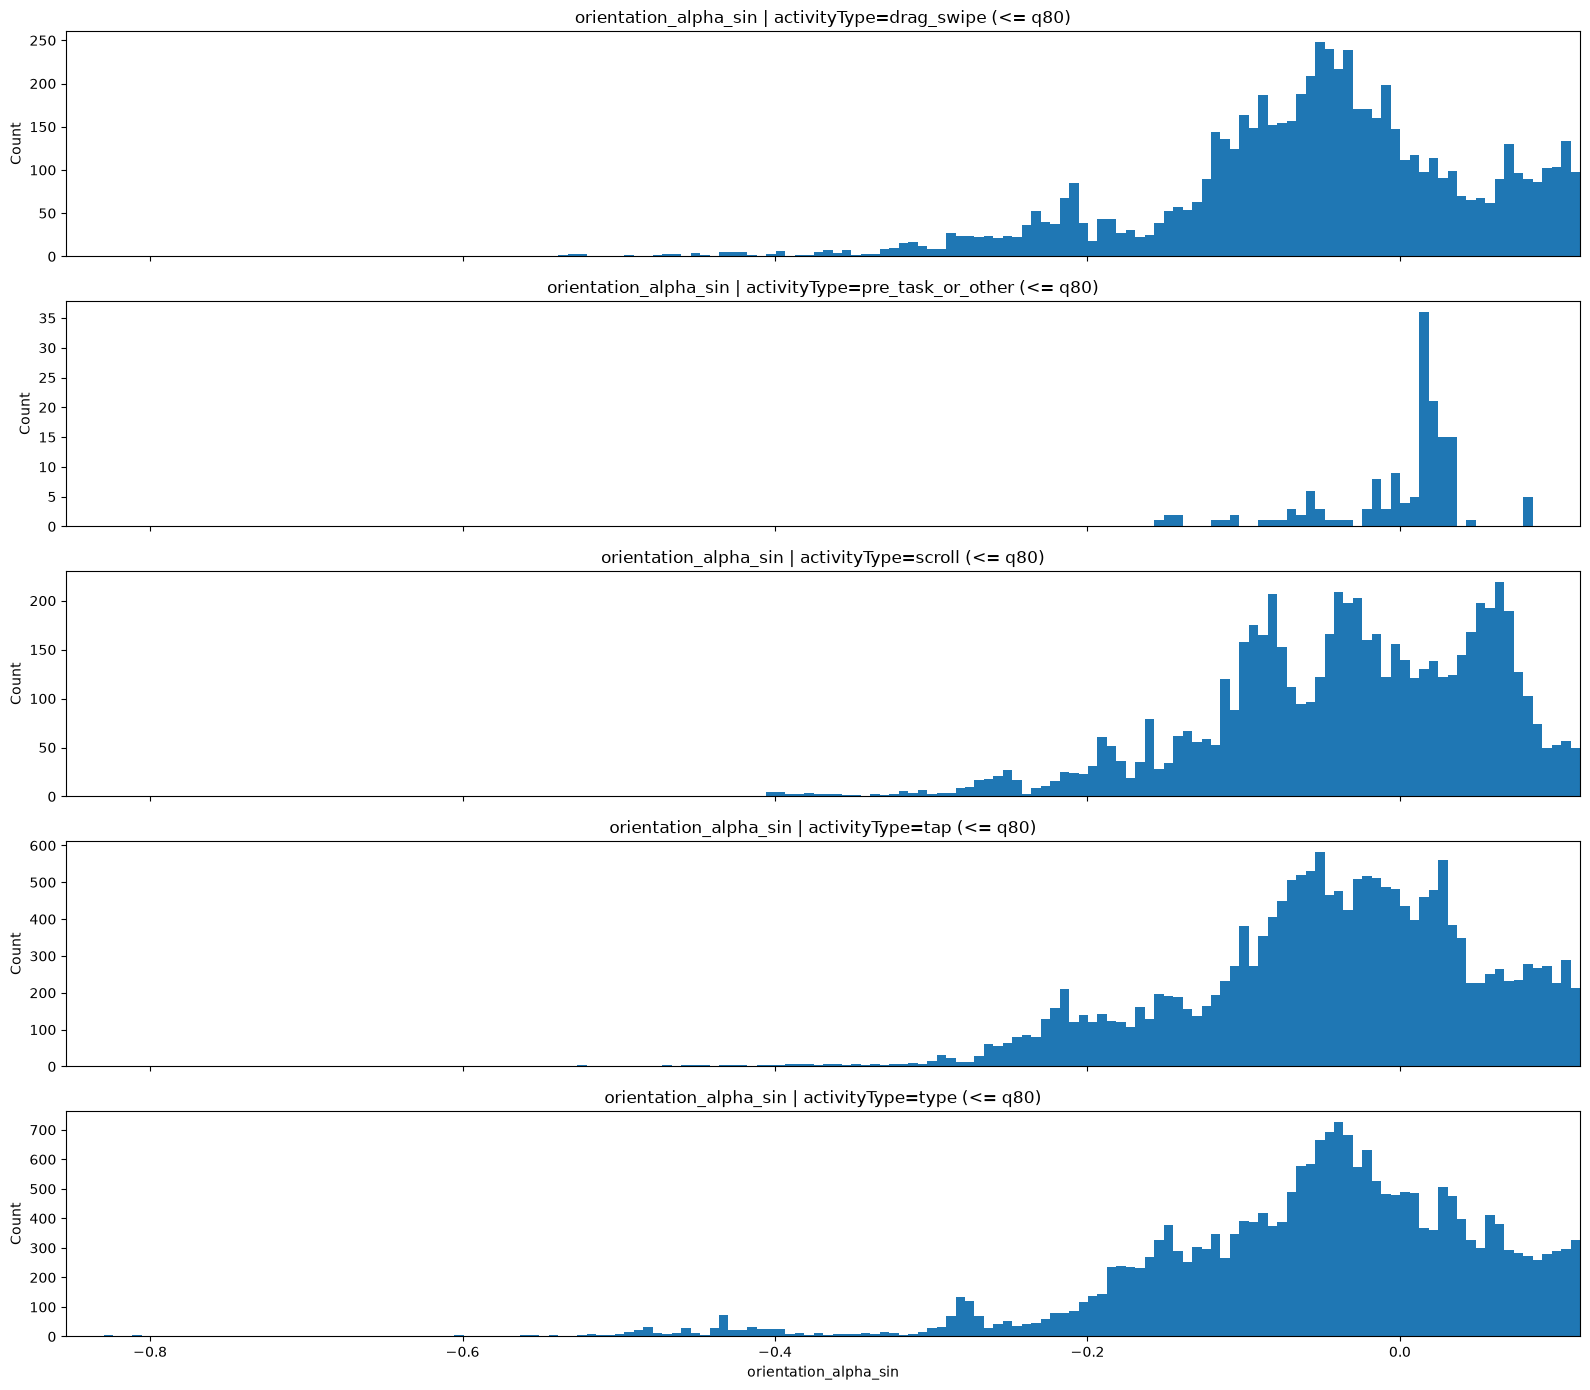

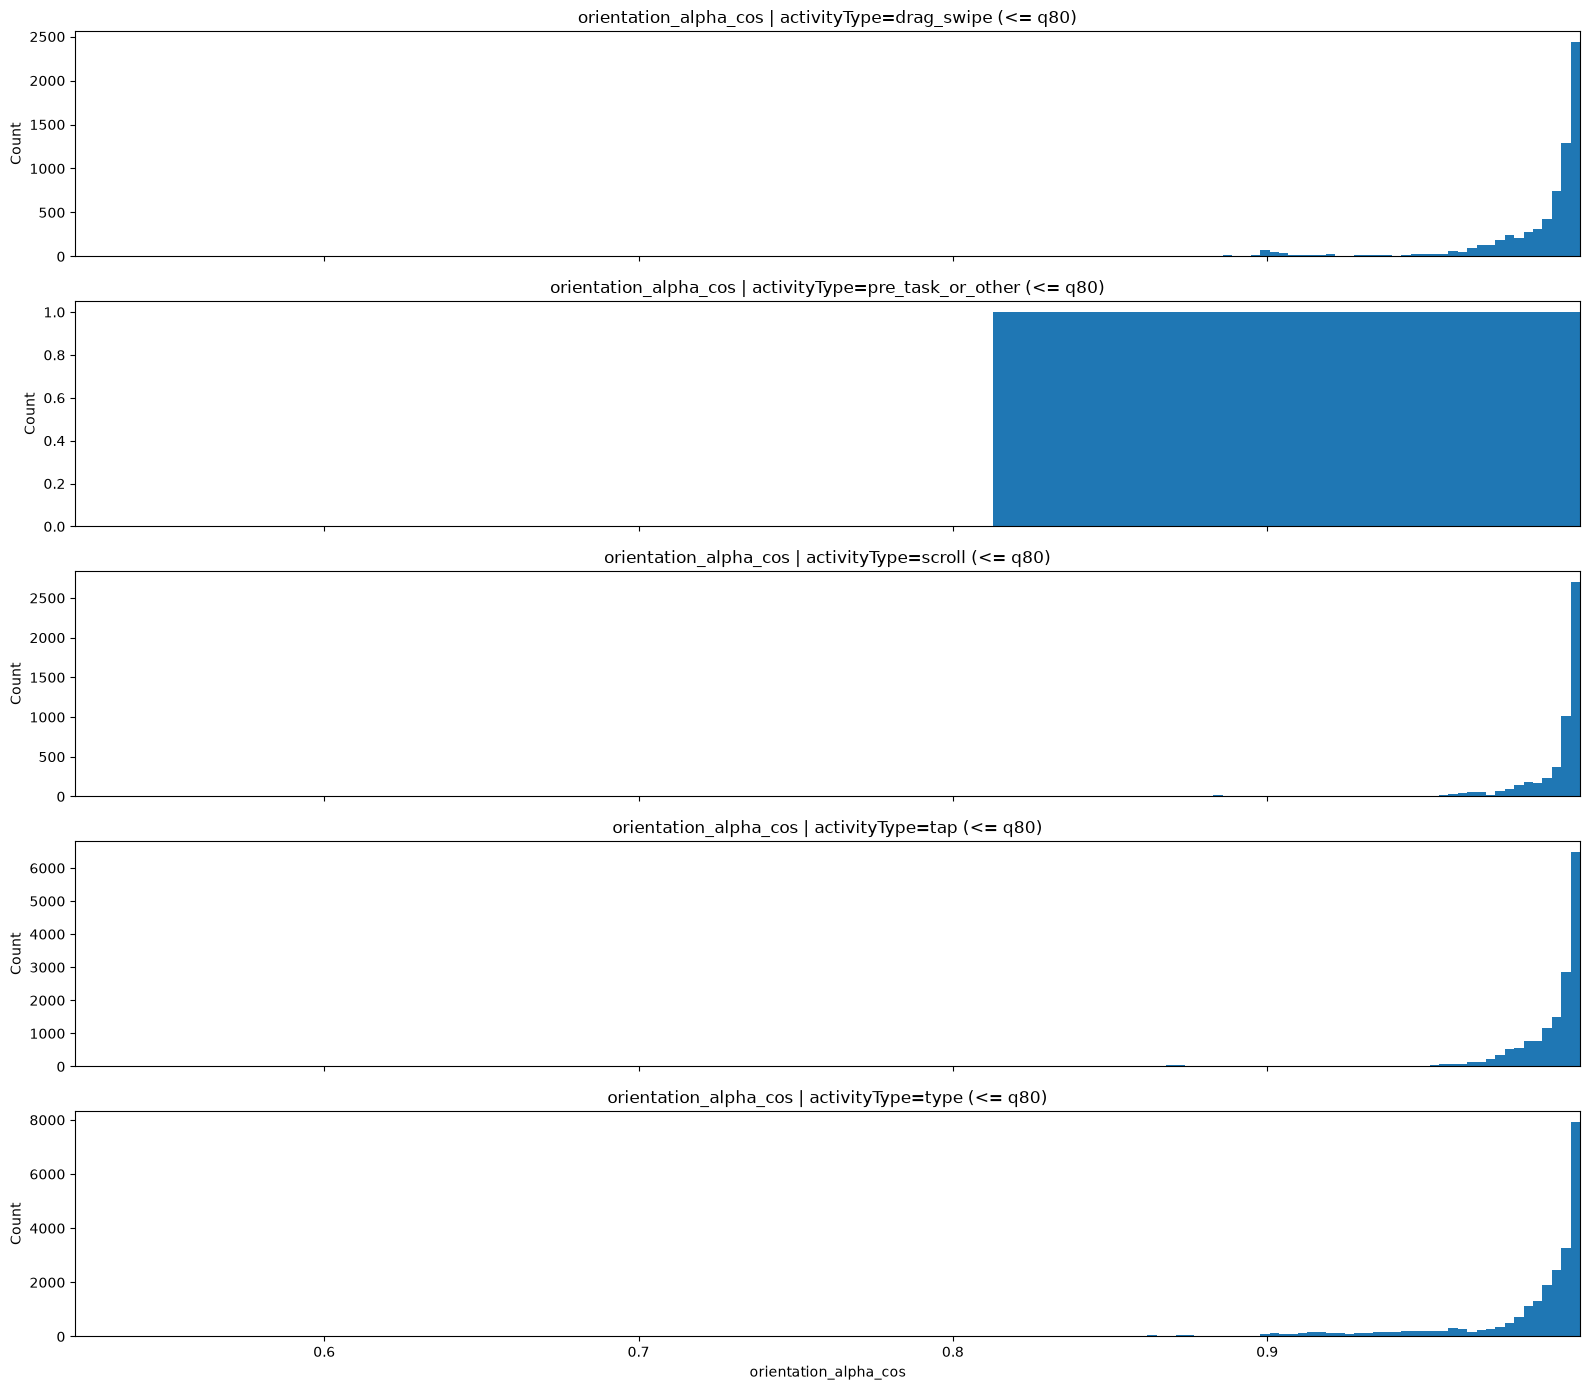

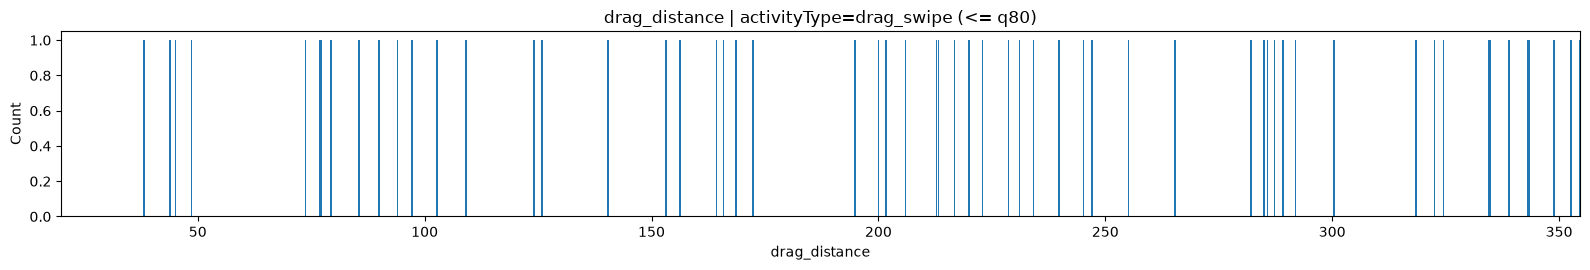

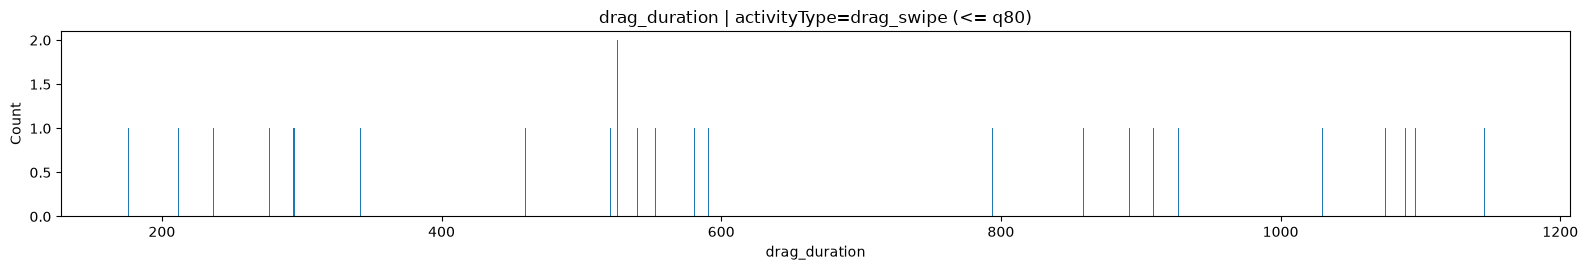

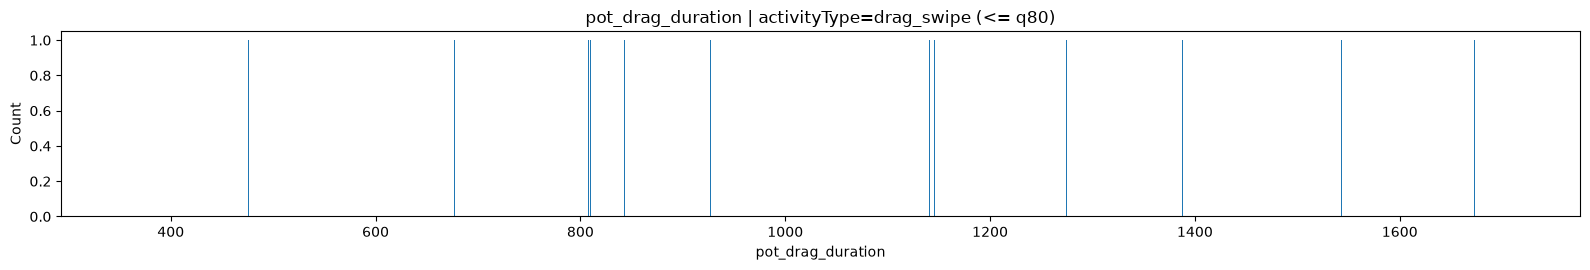

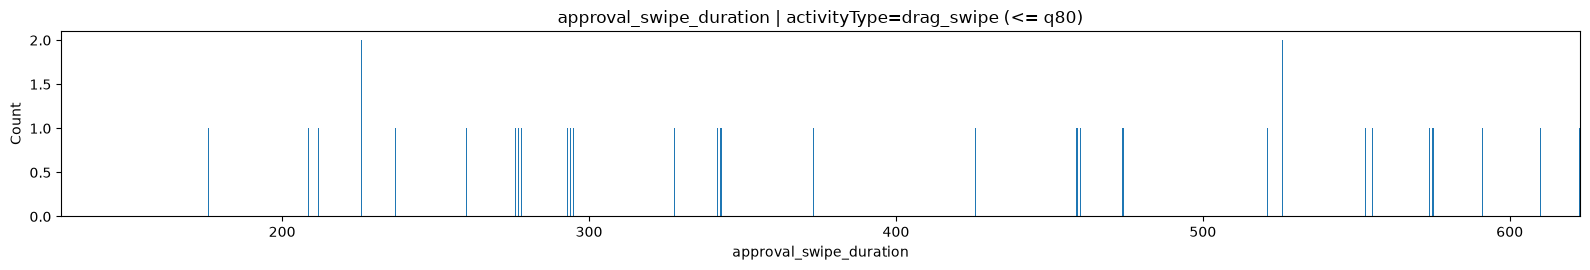

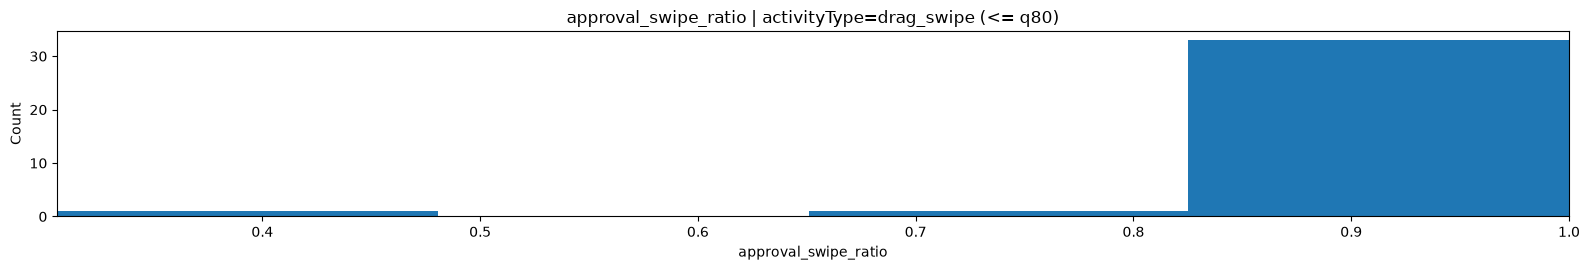

In [9]:
for m in metrics_in_scope:
    plot_metric_split(raw_metric_df, m, 'activityType')

## Quantisation summary

Automatic version of the manual checks that found `touchstart.force`'s 4 fixed values
and `pointer_pressure`'s constant `0`. Low `unique_ratio` = few distinct values relative
to sample count = likely a device/OS constant, not real behavioural variation.
`min_nonzero_step` is the smallest real gap between distinct values — a large, regular
step is itself a signature of hardware quantisation (e.g. `touchstart.force`'s ~12.1
step).

In [10]:
def quantisation_summary(df, metrics, group_col='deviceFamily'):
    rows = []
    for metric in metrics:
        msub = df.loc[df['metric'] == metric]
        if msub.empty:
            continue
        for grp, gsub in msub.groupby(group_col):
            vals = gsub['value'].dropna()
            if vals.empty:
                continue
            uniq = np.sort(vals.unique())
            min_nonzero_step = np.nan
            if len(uniq) >= 2:
                diffs = np.diff(uniq)
                nz = diffs[diffs > 0]
                min_nonzero_step = nz.min() if len(nz) else np.nan
            rows.append({
                'metric': metric, group_col: grp, 'n_obs': len(vals),
                'n_unique': vals.nunique(), 'unique_ratio': round(vals.nunique() / len(vals), 4),
                'min': vals.min(), 'median': vals.median(), 'max': vals.max(),
                'min_nonzero_step': min_nonzero_step,
            })
    return pd.DataFrame(rows).sort_values('unique_ratio')

quant_df = quantisation_summary(raw_metric_df, raw_metric_df['metric'].unique().tolist())
quant_df.head(30)

,metric,deviceFamily,n_obs,n_unique,unique_ratio,min,median,max,min_nonzero_step
39,motion_interval,mobile,66964,1,0.0000,0.016700,0.016700,0.016700,NaN
12,touch_radiusY,mobile,35286,1,0.0000,0.000000,0.000000,0.000000,NaN
26,pointer_tiltY,mobile,5516,1,0.0002,0.000000,0.000000,0.000000,NaN
24,pointer_tiltX,mobile,5516,1,0.0002,0.000000,0.000000,0.000000,NaN
18,pointer_pressure,mobile,5516,1,0.0002,0.000000,0.000000,0.000000,NaN
19,pointer_width,desktop,3686,1,0.0003,1.000000,1.000000,1.000000,NaN
23,pointer_tiltX,desktop,3686,1,0.0003,0.000000,0.000000,0.000000,NaN
25,pointer_tiltY,desktop,3686,1,0.0003,0.000000,0.000000,0.000000,NaN
11,touch_radiusX,mobile,35286,9,0.0003,12.085100,12.580600,48.340400,1.880000e-02
21,pointer_height,desktop,3686,1,0.0003,1.000000,1.000000,1.000000,NaN


**Read this as**: metrics near the top (lowest `unique_ratio`) are the most quantised —
candidates to exclude from behavioural modelling entirely, or to flag as device fingerprints
rather than person signal. Cross-check against the earlier confirmed-dead list
(`touch_force`, `pointer_pressure`, `pointer_tiltX/Y`, `touch_radiusY`, `motion_interval`)
— they should all surface near the top here automatically.

## Systematic separability screen

**This is the section P1 never had and P2 specifically needs.** Not a distribution check —
a direct, quantitative answer to "does this metric actually separate people," screened
across every metric × activity type × device family combination rather than the handful
checked by hand so far in this project. Same separation-score method used to find the
`payload_ay` / tap-activity result earlier, now built as permanent, reusable
infrastructure rather than a one-off calculation.

Separation score = `|difference in participant medians| / average within-participant IQR`.
Rough guide: **> 0.5** is a real, visually-noticeable gap; **< 0.15** is noise. Needs at
least 2 participants with a reasonable sample in the same activity/device slice to compute
at all — results will only get more trustworthy as the cohort grows past today's n=2-3.

In [11]:
def separation_score(df, metric, activity=None, device=None, min_n=5):
    sub = df.loc[df['metric'] == metric].copy()
    if activity is not None:
        sub = sub.loc[sub['activityType'] == activity]
    if device is not None:
        sub = sub.loc[sub['deviceFamily'] == device]
    sub = sub.dropna(subset=['value', 'participantId'])
    if sub['participantId'].nunique() < 2:
        return None

    counts = sub.groupby('participantId').size()
    if (counts < min_n).any():
        return None

    med = sub.groupby('participantId')['value'].median()
    iqr = sub.groupby('participantId')['value'].apply(lambda x: x.quantile(.75) - x.quantile(.25))
    pooled_iqr = iqr.mean()
    if pooled_iqr == 0 or pd.isna(pooled_iqr):
        return None

    # pairwise max separation across all participant pairs present
    meds = med.values
    max_sep = 0.0
    for i in range(len(meds)):
        for j in range(i + 1, len(meds)):
            max_sep = max(max_sep, abs(meds[i] - meds[j]) / pooled_iqr)
    return round(max_sep, 3)


ACTIVITY_TYPES = [a for a in raw_metric_df['activityType'].dropna().unique() if a != 'pre_task_or_other']
DEVICE_FAMILIES = raw_metric_df['deviceFamily'].dropna().unique().tolist()

screen_rows = []
for metric in raw_metric_df['metric'].unique():
    # whole-session, no split
    s = separation_score(raw_metric_df, metric)
    if s is not None:
        screen_rows.append({'metric': metric, 'split': 'none', 'separation': s})
    for activity in ACTIVITY_TYPES:
        s = separation_score(raw_metric_df, metric, activity=activity)
        if s is not None:
            screen_rows.append({'metric': metric, 'split': f'activity={activity}', 'separation': s})
    for device in DEVICE_FAMILIES:
        s = separation_score(raw_metric_df, metric, device=device)
        if s is not None:
            screen_rows.append({'metric': metric, 'split': f'device={device}', 'separation': s})

separability_df = pd.DataFrame(screen_rows).sort_values('separation', ascending=False)
print(f"Screened {len(separability_df)} metric x split combinations")
separability_df.head(30)

Screened 151 metric x split combinations


,metric,split,separation
57,pointer_height,activity=drag_swipe,23.706
51,pointer_width,activity=drag_swipe,23.706
54,pointer_height,activity=type,23.670
48,pointer_width,activity=type,23.670
47,pointer_width,none,11.615
53,pointer_height,none,11.615
49,pointer_width,activity=tap,7.894
56,pointer_height,activity=scroll,7.894
55,pointer_height,activity=tap,7.894
50,pointer_width,activity=scroll,7.894


**Read this as a candidate priority list, not a conclusion.** High separation scores
here are worth prioritising in `build_windows_dataset.py`'s feature set and in eventual
modelling — but every one of them is currently based on very few participants. A result
that recurs across multiple splits of the *same* metric (the way `payload_ay` held up
across all four activity types earlier) is much more trustworthy than a single high score
in one narrow slice.

**Re-run this whole notebook every time the cohort grows** — that's the actual point of
building it as reusable infrastructure rather than a one-off script. The ranking here
should visibly stabilise (or reshuffle in informative ways) as more sessions come in.

In [12]:
top_metrics = separability_df.loc[separability_df['split'] != 'none', 'metric'].value_counts()
print("Metrics appearing most often near the top across different splits (cross-context consistency):")
consistent = (
    separability_df[separability_df['separation'] > 0.5]
    .groupby('metric')
    .size()
    .sort_values(ascending=False)
)
consistent.head(15)

Metrics appearing most often near the top across different splits (cross-context consistency):


metric
pointer_hold_ms          7
orientation_gamma        6
motion_agx               6
motion_agy               6
motion_agz               6
motion_ay                6
motion_magnitude         6
touch_speed              6
orientation_alpha_sin    6
orientation_beta         6
pointer_height           6
touch_hold_ms            6
pointer_width            6
touch_radiusX            5
touch_force              4
dtype: int64

## Notes

Use this notebook to decide, per raw metric:
- **plausibly behavioural** — real spread, not obviously quantised, shows separation in
  the systematic screen
- **quantised / device constant** — flag via §5, exclude from modelling regardless of
  any apparent separation (a device fingerprint masquerading as a person signal)
- **device-family dependent** — needs the same `identity_id = participant + device`
  treatment P1 used, confirmed necessary again via the very first P2 laptop session
  (typing dwell: ~95ms laptop vs. ~12ms mobile median)
- **worth prioritising for `build_windows_dataset.py`** — high, cross-context-consistent
  separation score in §6

This notebook does not compute window-level features itself — it's a screening tool
that feeds decisions in `build_windows_dataset.py` and `build_behavioural_dataset.py`,
not a replacement for either.

## Participant / session colour overlay — for the top candidate metrics from §6

The pooled/device-split/activity-split plots above group everyone together within each
panel — useful for spotting quantisation and device effects, but they don't show whether
individual *people* separate, which is the actual question this project cares about.

Rather than repeat that for all 37 metrics (which would roughly double an already-large
export), this section overlays each participant in a distinct colour — one line per
participant, sessions of the same participant sharing that colour — specifically for the
metrics §6's separability screen already flagged as worth a closer look. This is the
visual counterpart to those separation scores, not a blind completeness pass.

Adjust `N_TOP_METRICS` to see more or fewer.

In [13]:
def plot_metric_by_participant_overlay(df, metric, clip_q=0.8, bins=60, activity=None, device=None):
    sub = df.loc[df['metric'] == metric].copy()
    if activity is not None:
        sub = sub.loc[sub['activityType'] == activity]
    if device is not None:
        sub = sub.loc[sub['deviceFamily'] == device]
    sub = sub.dropna(subset=['value', 'participantId'])
    if sub.empty:
        print(f"No data for {metric}" + (f" | activity={activity}" if activity else "") + (f" | device={device}" if device else ""))
        return

    upper = sub['value'].quantile(clip_q)
    sub = sub.loc[sub['value'] <= upper]
    if sub.empty:
        return

    participants = sorted(sub['participantId'].astype(str).unique())
    cmap = plt.get_cmap('tab10')
    color_map = {p: cmap(i % 10) for i, p in enumerate(participants)}

    x_min, x_max = sub['value'].min(), sub['value'].max()
    bin_edges = np.linspace(x_min, x_max, bins + 1)

    fig, ax = plt.subplots(figsize=(16, 4.2))
    for pid in participants:
        psub = sub.loc[sub['participantId'].astype(str) == pid]
        n_sessions = psub['sessionId'].nunique()
        ax.hist(
            psub['value'], bins=bin_edges, histtype='step', linewidth=2.2,
            color=color_map[pid], label=f"{pid} (n_sessions={n_sessions}, n_obs={len(psub)})",
            density=True,
        )
    title = f"{metric} | by participant"
    if activity:
        title += f" | activity={activity}"
    if device:
        title += f" | device={device}"
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("Density")
    ax.legend(title="Participant", fontsize=9)
    plt.tight_layout()
    plt.show()

In [14]:
N_TOP_METRICS = 12

# Pull the top candidates straight from §6's separability screen, deduplicated on metric
# (keep the split with the strongest score for each metric, since that's the most
# informative single view to lead with).
top_candidates = (
    separability_df.sort_values('separation', ascending=False)
    .drop_duplicates(subset='metric')
    .head(N_TOP_METRICS)
)
print(top_candidates[['metric', 'split', 'separation']])

                    metric                split  separation
57          pointer_height  activity=drag_swipe      23.706
51           pointer_width  activity=drag_swipe      23.706
31           touch_radiusX  activity=drag_swipe       5.882
25             touch_force      activity=scroll       5.773
4          typing_dwell_ms                 none       4.015
134      orientation_gamma      activity=scroll       3.013
86              motion_agx      activity=scroll       2.942
96              motion_agz        activity=type       2.884
34         pointer_hold_ms        activity=type       2.804
126       orientation_beta        activity=type       2.717
90              motion_agy        activity=type       2.348
138  orientation_alpha_sin        activity=type       2.013


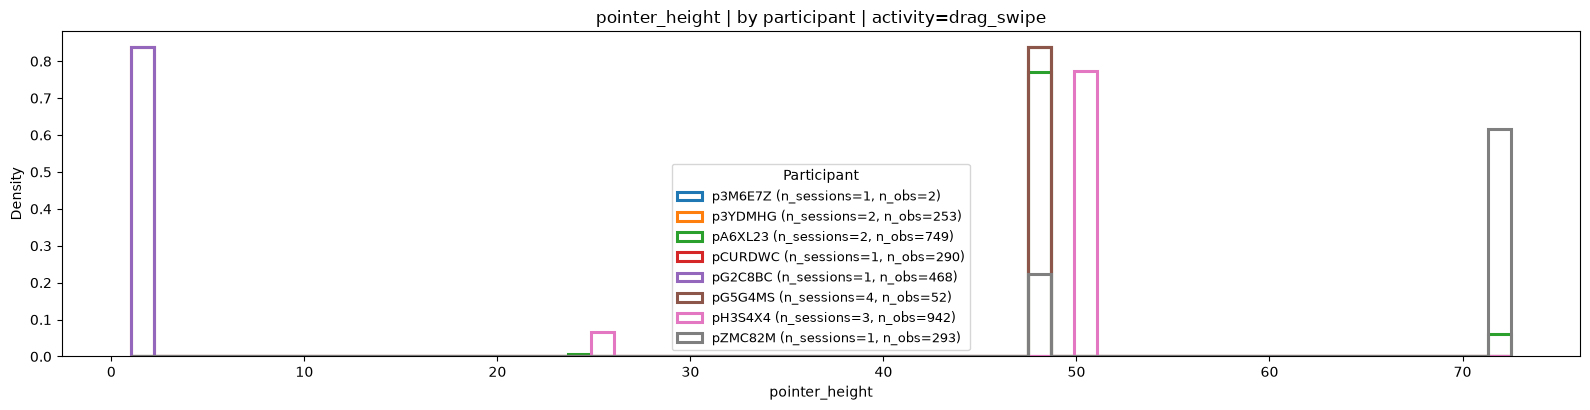

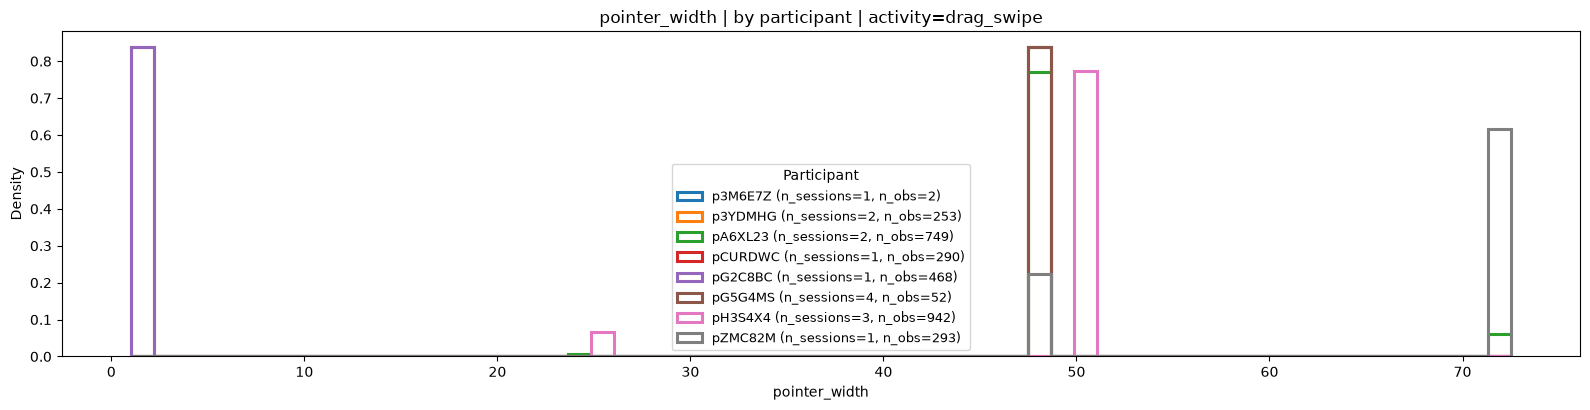

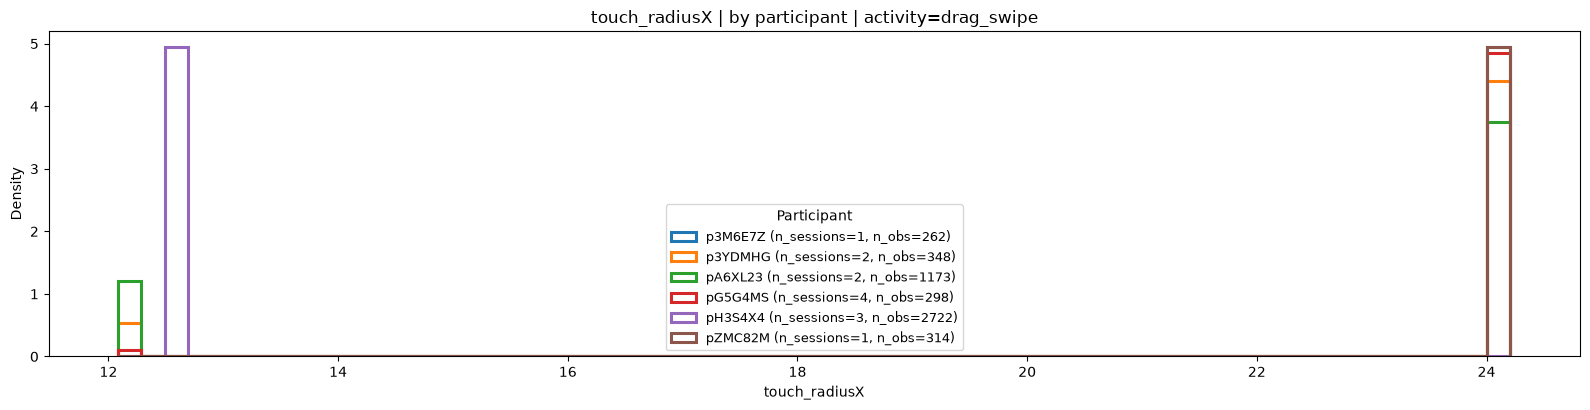

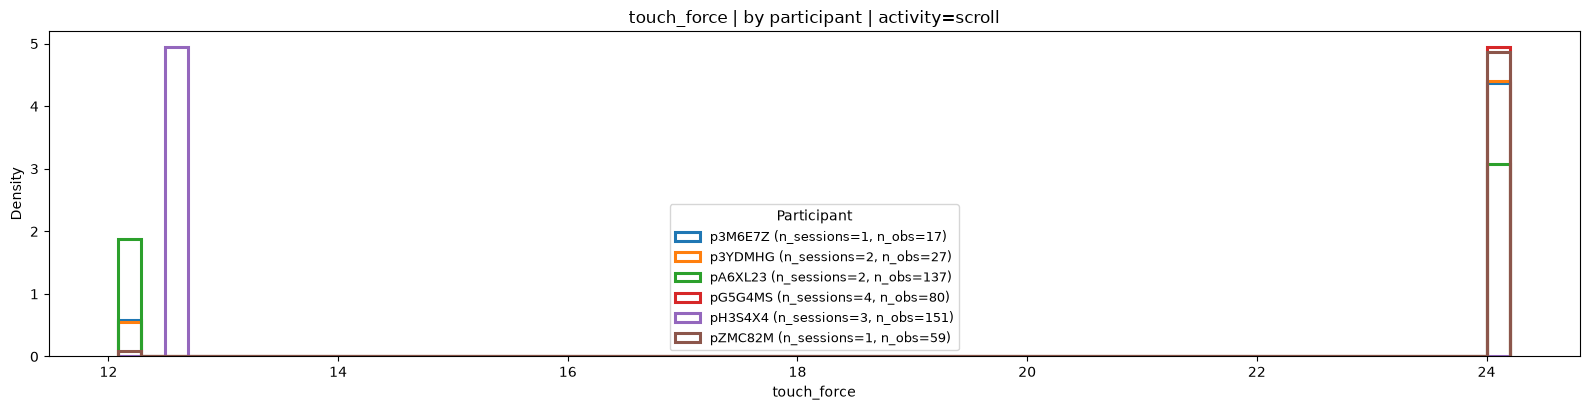

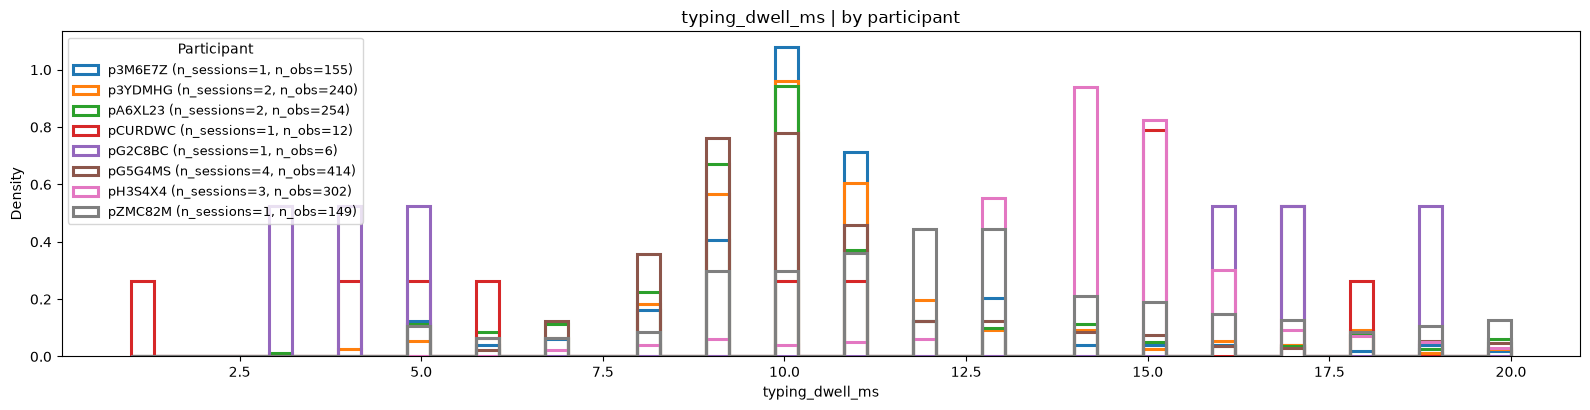

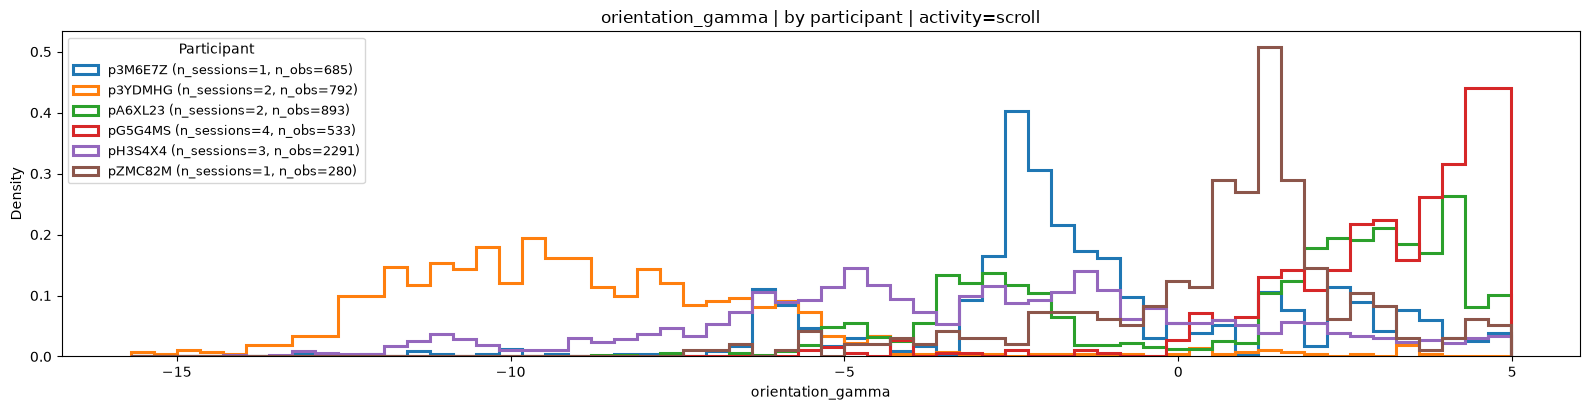

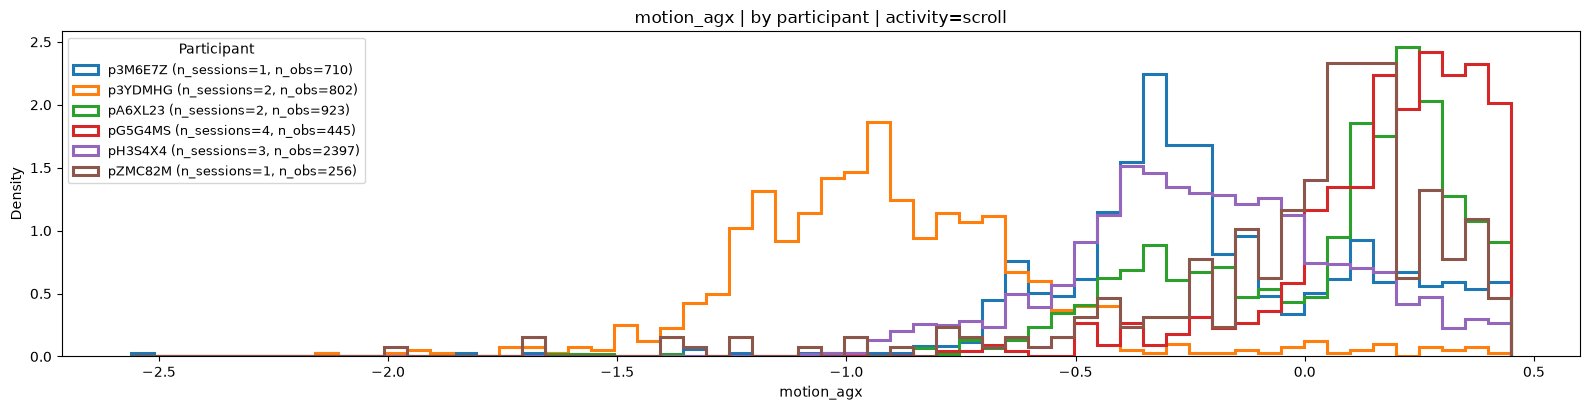

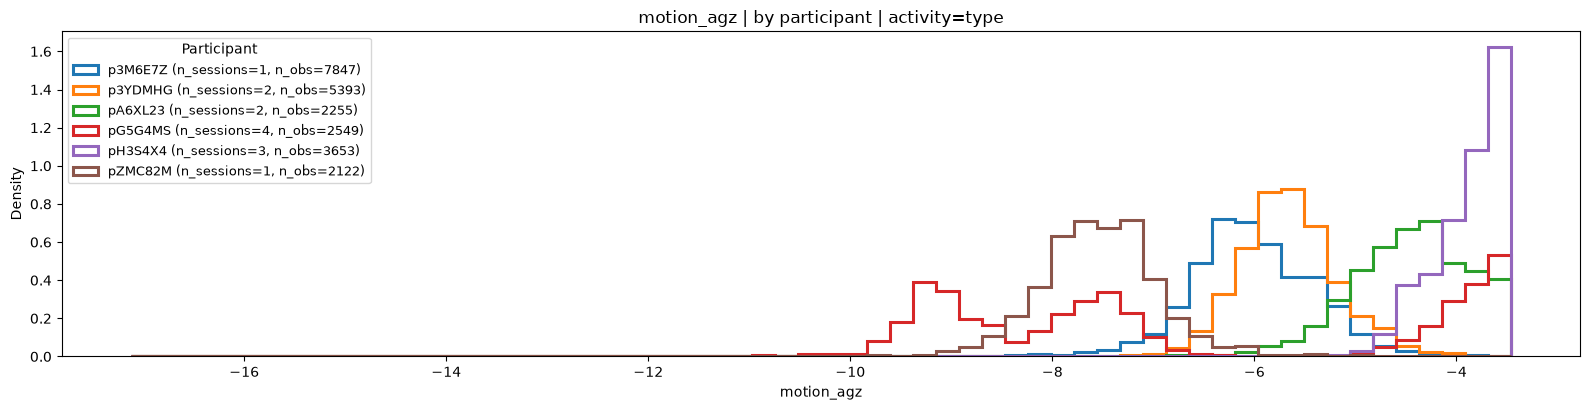

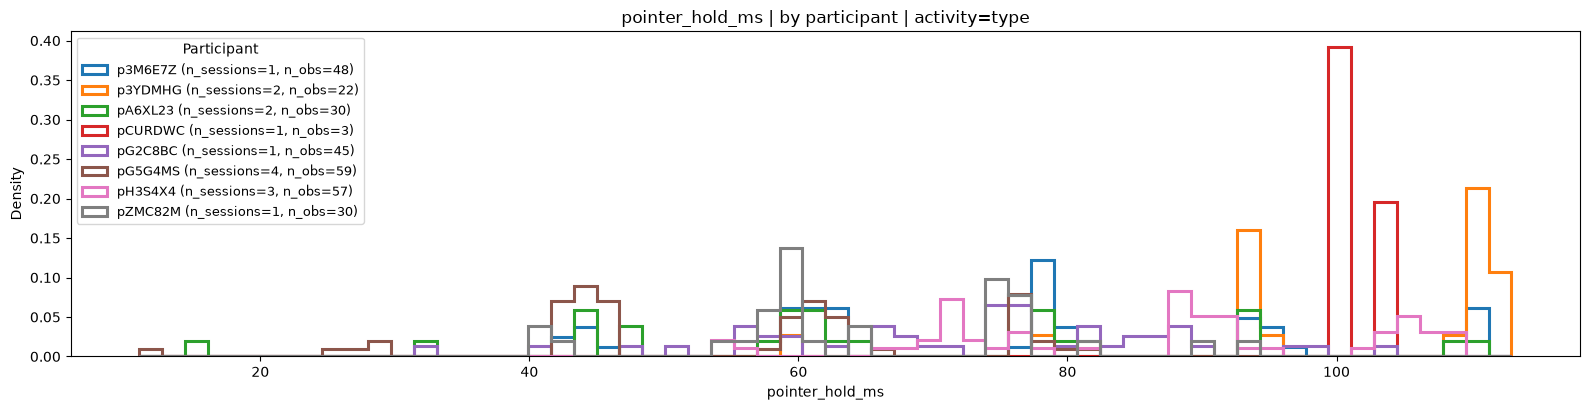

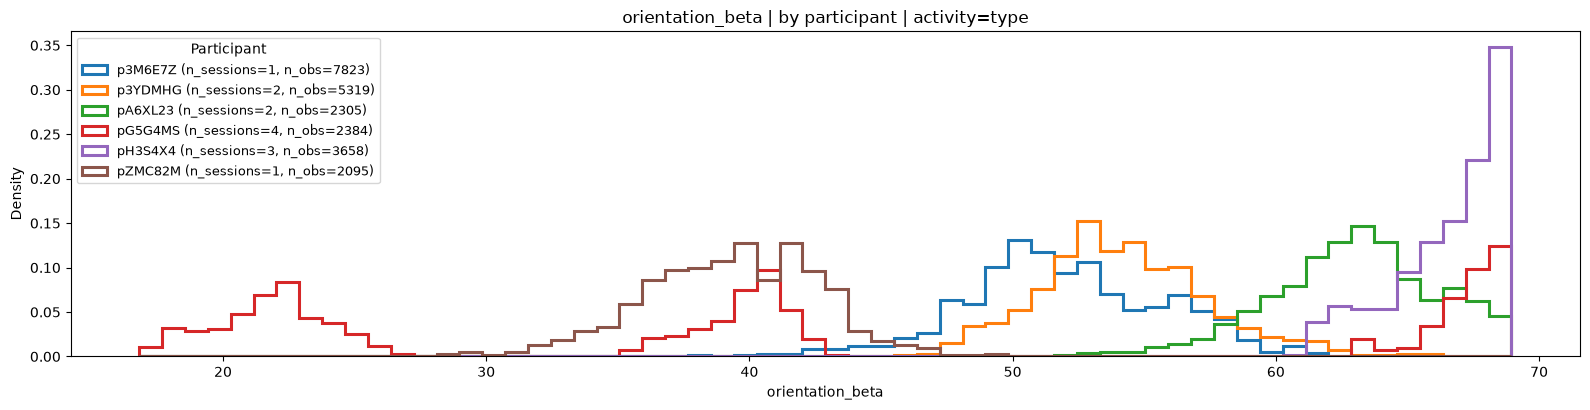

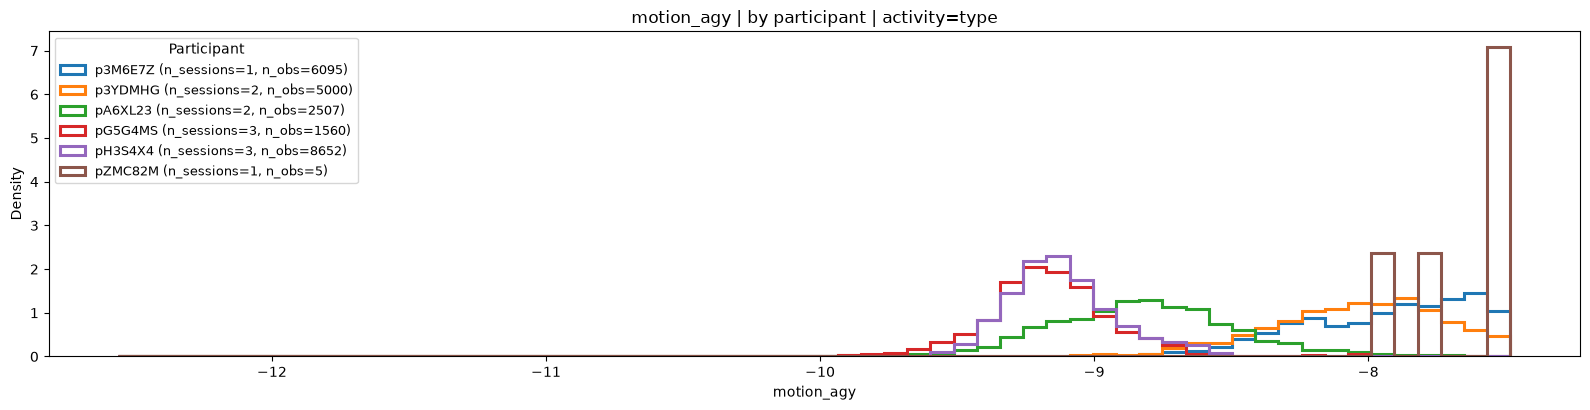

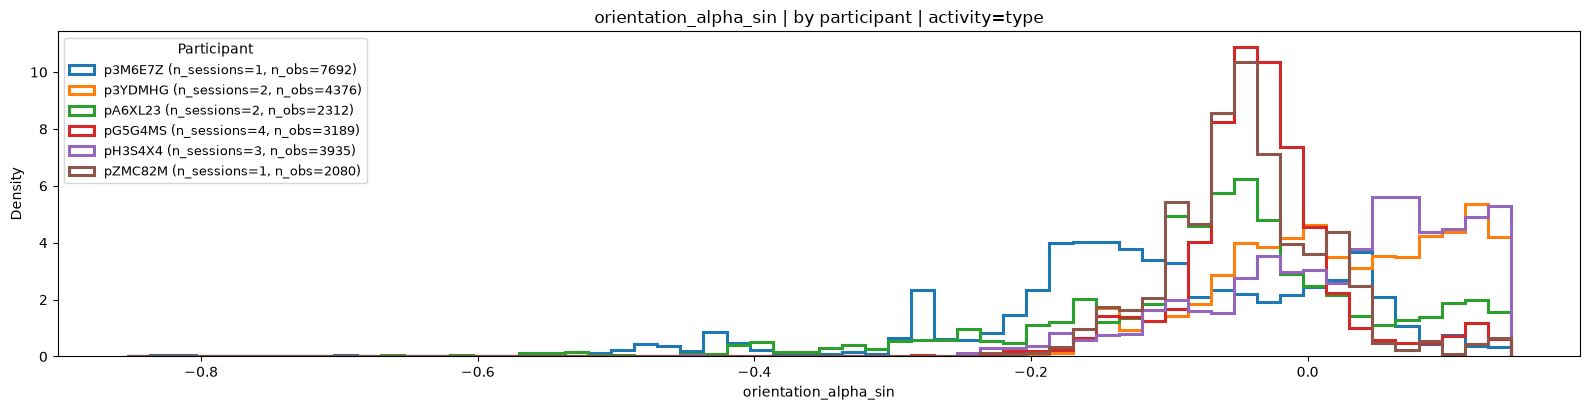

In [15]:
for _, row in top_candidates.iterrows():
    metric = row['metric']
    split = row['split']
    activity = split.split('=')[1] if split.startswith('activity=') else None
    device = split.split('=')[1] if split.startswith('device=') else None
    plot_metric_by_participant_overlay(raw_metric_df, metric, activity=activity, device=device)

**Read this as**: distinct, non-overlapping curves confirm the separation score with
your own eyes — clusters that visibly sit apart are the strongest candidates. Curves that
look more tangled than the score suggested are worth a second look at the score's
reliability (small `n`, per §6's caveat) before trusting them.

Cross-check against §5's quantisation table before getting excited about any single
curve here — a metric can show clean visual separation *and* turn out to be a device
constant (exactly what happened with `pointer_width`/`pointer_height` earlier in this
project — perfect-looking separation that was actually two different fixed hardware
values, not two different people).